<a href="https://colab.research.google.com/github/vedantikanade/Data_Mining_Colabs_Assignment2/blob/main/final_intro_to_linear_algebra_zero_to_hero_for_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔢 Intro to Linear Algebra: Zero to Hero (for Machine Learning)
## A refresher that assumes you have forgotten all of it

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com)
![Python](https://img.shields.io/badge/Python-3.10+-blue.svg)
![No installs](https://img.shields.io/badge/installs-none%20needed-brightgreen.svg)
![Prereqs](https://img.shields.io/badge/prerequisites-none-brightgreen.svg)
![Level](https://img.shields.io/badge/level-zero%20to%20hero-orange.svg)

---
<div style="background: linear-gradient(135deg, #3A1C71 0%, #D76D77 100%); padding: 28px; border-radius: 18px; color: white; margin: 12px 0;">


### A matrix is not a table of numbers. It is a verb.

That is the sentence this notebook exists to earn.

Most people meet matrices as grids you multiply by following a rule nobody explains, and the rule is strange — you go along the row and down the column, and it is not commutative, and there is no obvious reason for any of it. So it gets memorised and never understood.

The reason is this: **a matrix is something that DOES something to space.** It stretches, rotates, squashes and reflects. The multiplication rule is exactly the arithmetic required for that, and once you have seen it as motion, the rule stops being arbitrary.

Every layer of every neural network is a matrix doing that to your data. This notebook builds up to that from what a vector is.


</div>

<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📖 Who this is for, and how it works

**For you if** you have seen vectors and matrices, remember that multiplication is "rows times columns", and could not say why anyone would want to do that — and you now want to understand what a neural network layer is actually computing.

**No prerequisites.** Part 1 starts at what a vector is. Every symbol is named in words the first time it appears.

**Every rule is built before it is used**, and **every result is checked numerically in the same cell** — so if a derivation were wrong, the numbers would disagree and you would see it.

**One dataset runs throughout**: 200 flowers with two measurements each. A vector is one flower. A matrix is all of them. A transformation is something we do to them. In Part 9 we find the direction they actually vary along, which is PCA.

</div>

## 🎯 What you will be able to do

1. **Say what a vector is** — three ways (an arrow, a list, a point) — and know when each picture helps.
2. **Add and scale vectors**, and compute a length, from the definition.
3. **Explain the dot product** geometrically and algebraically, and say why it measures similarity.
4. **Read a matrix as a transformation** and predict what it will do to a picture before running it.
5. **Derive matrix multiplication** from the dot product, and say why it is not commutative.
6. **Solve a linear system**, invert a matrix, and recognise when you cannot.
7. **Explain eigenvectors** as the directions a transformation leaves pointing the same way.
8. **Read `y = Wx + b`** as a sentence, and implement PCA yourself.

---
## 🗺️ The Ten Parts

This is a **refresher that assumes you have forgotten everything**. Part 1 starts at what a function is. Nothing later depends on anything we did not build earlier, and every rule is derived before it is used.

| Part | What it covers | |
|---|---|---|
| **0** | Why vectors and matrices, and the dataset we use |  &larr; **you are here**
| **1** | Vectors: arrows, lists, and what they mean |
| **2** | Vector arithmetic: adding, scaling, and length |
| **3** | The dot product: the one operation that matters most |
| **4** | Matrices: tables of numbers that DO something |
| **5** | Matrix multiplication, built from the dot product |
| **6** | Transformations: what a matrix does to space |
| **7** | Systems, inverses, and when they fail |
| **8** | Eigenvectors, and the directions that survive |
| **9** | Linear algebra doing ML: a layer, PCA, and a capstone |

Parts 1-3 are the ideas. Parts 4-5 make derivatives usable. Parts 6-7 do the same for integrals and then show the two are one idea. Parts 8-9 are where it becomes machine learning.


## ⚙️ Setup

Nothing to install.

In [1]:
# ============================================================
#  Setup -- no installs, no downloads, no network.
# ============================================================
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (9, 4.5)
plt.rcParams["axes.grid"]      = True
plt.rcParams["grid.alpha"]     = 0.3
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["font.size"] = 11

C_F, C_SLOPE, C_AREA = "#2563EB", "#DC2626", "#059669"
C_APPROX, C_EXACT, C_GREY, C_SOFT = "#D97706", "#7C3AED", "#6B7280", "#E5E7EB"


print(f"numpy {np.__version__}")


numpy 2.1.3


---

# 0️⃣ The flowers

Two hundred flowers from two species, each measured twice: petal length and
petal width, both in centimetres. Generated rather than downloaded, so this
notebook runs offline and the numbers are reproducible.

Two measurements means each flower is a point on a flat page, which is the
whole reason for choosing two: **you can see everything.** Real data has
hundreds of dimensions and cannot be drawn, but every operation in this
notebook does exactly the same thing there as it does here. Learn it where you
can watch it.


In [2]:
# ============================================================
#  The running example -- 200 flowers, two measurements each.
#  Every idea in this notebook is shown ON this data: a vector
#  is one flower, a matrix is all of them, a transformation is
#  something we DO to them, and PCA at the end finds the
#  direction they actually vary along.
# ============================================================
import numpy as np

RNG = np.random.default_rng(3)

# two correlated measurements, in centimetres, for two species
n = 100
a = RNG.multivariate_normal([5.0, 3.4], [[0.35, 0.28], [0.28, 0.30]], n)
b = RNG.multivariate_normal([6.6, 2.9], [[0.40, 0.22], [0.22, 0.26]], n)

X       = np.vstack([a, b])                 # 200 x 2 -- the data matrix
species = np.array([0] * n + [1] * n)
FEATURES = ["petal length (cm)", "petal width (cm)"]

print(f"X is a {X.shape[0]} x {X.shape[1]} matrix: "
      f"{X.shape[0]} flowers, {X.shape[1]} measurements each")
print(f"one flower is a vector of length {X.shape[1]}: {X[0].round(2)}")
print(f"column means: {X.mean(axis=0).round(3)}")


X is a 200 x 2 matrix: 200 flowers, 2 measurements each
one flower is a vector of length 2: [4.19 1.93]
column means: [5.781 3.149]


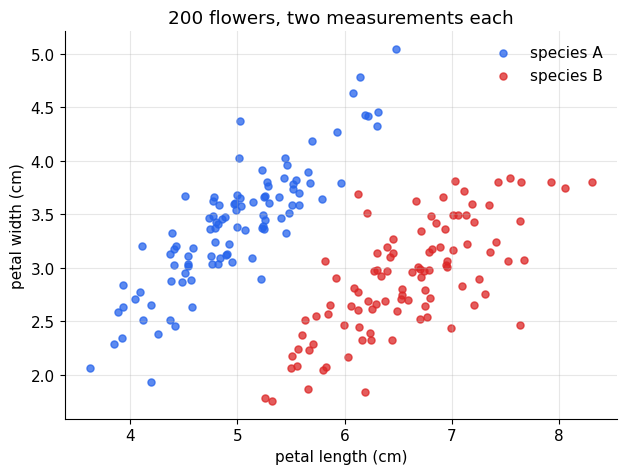

X.shape = (200, 2)   -> 200 rows (flowers), 2 columns (measurements)
The first flower is the vector [4.19 1.93] --
  4.19 cm long and 1.93 cm wide.
That single pair of numbers IS a vector. Nothing more mysterious.


In [3]:
fig, ax = plt.subplots(figsize=(6.4, 5.4))
ax.scatter(*X[species == 0].T, s=26, c=C_F,     alpha=0.75, label="species A")
ax.scatter(*X[species == 1].T, s=26, c=C_SLOPE, alpha=0.75, label="species B")
ax.set_xlabel(FEATURES[0]); ax.set_ylabel(FEATURES[1])
ax.set_title("200 flowers, two measurements each")
ax.set_aspect("equal"); ax.legend(frameon=False)
fig.tight_layout(); plt.show()

print(f"X.shape = {X.shape}   -> {X.shape[0]} rows (flowers), "
      f"{X.shape[1]} columns (measurements)")
print(f"The first flower is the vector {X[0].round(2)} --")
print(f"  {X[0][0]:.2f} cm long and {X[0][1]:.2f} cm wide.")
print(f"That single pair of numbers IS a vector. Nothing more mysterious.")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Two hundred flowers as points. Each dot is one flower; its horizontal position is petal length and its vertical position is petal width. The two species overlap but sit in different regions, and within each cloud the points lean along a diagonal — longer petals tend to be wider ones.

That diagonal lean is the most important feature of this picture. It means the two measurements are **not independent**, so the cloud is not a circle but a tilted ellipse. Part 8 finds the direction of that tilt, and Part 9 shows that finding it is exactly what PCA does.

The axes are set to equal aspect deliberately. **The common misread:** judging the direction of that lean off a plot whose axes are differently scaled — stretch one axis and the apparent angle changes, so any conclusion about direction drawn from an unequal-aspect scatter is an artifact of the plotting, not the data.

</div>

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🗣️ In plain words

**Vector** = an ordered list of numbers. One flower: `[5.1, 3.5]`.

**Matrix** = a rectangular block of numbers. All 200 flowers stacked: `X`, which is 200 by 2.

That is all they are as objects. What makes them worth a notebook is what you can *do* with them, and that starts in Part 1.

</div>

<div style="background-color: #f8d7da; border-left: 5px solid #dc3545; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🤖 Why ML cares

A neural network layer is `y = Wx + b`. By Part 9 you will read that as a sentence: take the input vector `x`, apply the transformation `W` — which stretches and rotates it — then shift the result by `b`.

Every one of those words is a thing you will have built yourself. `x` is Part 1. The multiplication `Wx` is Parts 3 and 5. `W` as a motion is Part 6. Why some `W` destroy information and cannot be undone is Part 7. What `W` does to the *shape* of a data cloud is Part 8.

</div>

### A note on notation

| Written | Said aloud | Means |
|---|---|---|
| $\mathbf{v}$ or $\vec{v}$ | "vector v" | a vector — bold or arrowed |
| $v_i$ | "v sub i" | the $i$-th number inside $\mathbf{v}$ |
| $\mathbf{A}$ | "matrix A" | a matrix — capital, bold |
| $A_{ij}$ | "A i j" | the entry in row $i$, column $j$ |
| $\mathbf{A}^T$ | "A transpose" | rows and columns swapped |
| $\mathbf{u} \cdot \mathbf{v}$ | "u dot v" | the dot product (Part 3) |
| $\|\mathbf{v}\|$ | "the norm of v" | its length (Part 2) |

**Rows before columns, always.** `X[3, 1]` is row 3, column 1. Nearly every
indexing bug in linear algebra code is that order being reversed, and it is
worth over-learning now.

---


---

# 1️⃣ Vectors: arrows, lists, and what they mean

A vector is one of those words that sounds like it must be hiding something.
It is not. **A vector is an ordered list of numbers.** That is the whole
definition, and everything else in this notebook is built on top of it.

What makes vectors worth a part of their own is that the same list of numbers
can be *pictured* in three different ways, and each picture makes a different
fact obvious. People who are fluent in linear algebra are not doing harder
arithmetic than you — they are silently switching between these three pictures
depending on which one makes the current question easy.

So we are going to look at one vector three times.


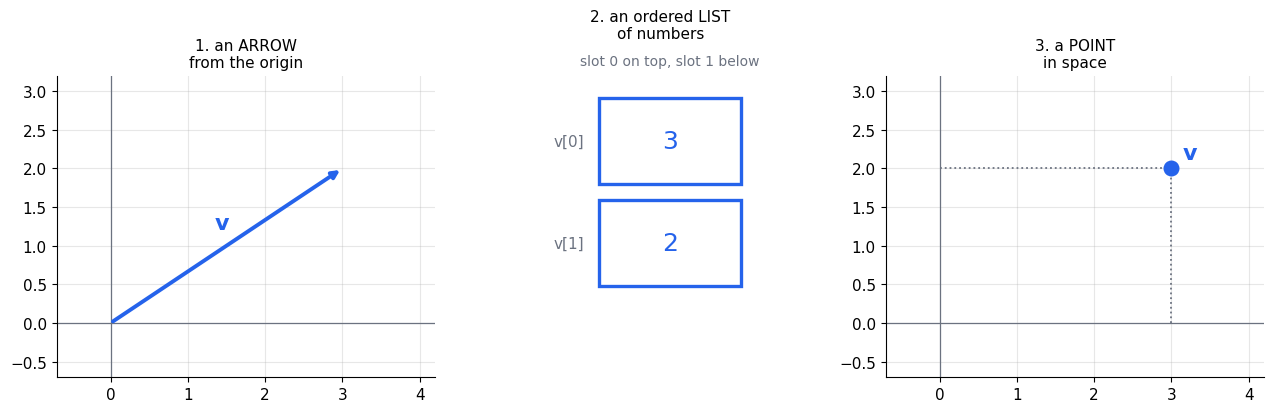

v            = [3. 2.]
v.shape      = (2,)     <- a 1-D array holding 2 numbers
v[0], v[1]   = 3.0, 2.0
All three panels above are drawings of exactly this object.


In [4]:
v = np.array([3.0, 2.0])          # ONE vector. Three pictures of it below.

fig, axes = plt.subplots(1, 3, figsize=(12.6, 4.3))

# ---------- picture 1: an ARROW from the origin ----------
ax = axes[0]
ax.axhline(0, color=C_GREY, lw=0.9); ax.axvline(0, color=C_GREY, lw=0.9)
ax.annotate("", xy=(v[0], v[1]), xytext=(0, 0),
            arrowprops=dict(arrowstyle="-|>", lw=2.8, color=C_F))
ax.text(v[0] * 0.45, v[1] * 0.45 + 0.32, "v", color=C_F,
        fontsize=16, fontweight="bold")
ax.set_xlim(-0.7, 4.2); ax.set_ylim(-0.7, 3.2)
ax.set_aspect("equal")
ax.set_title("1. an ARROW\nfrom the origin", fontsize=11)

# ---------- picture 2: an ordered LIST of numbers ----------
ax = axes[1]
ax.set_xlim(0, 4); ax.set_ylim(0, 3); ax.axis("off")
for i, val in enumerate(v):
    y = 1.85 - 0.85 * i
    ax.add_patch(plt.Rectangle((1.35, y), 1.5, 0.72,
                               fill=False, ec=C_F, lw=2.4))
    ax.text(2.10, y + 0.36, f"{val:.0f}", ha="center", va="center",
            fontsize=18, color=C_F)
    ax.text(1.20, y + 0.36, f"v[{i}]", ha="right", va="center",
            fontsize=11, color=C_GREY)
ax.text(2.10, 2.85, "slot 0 on top, slot 1 below",
        ha="center", fontsize=10, color=C_GREY)
ax.set_title("2. an ordered LIST\nof numbers", fontsize=11)

# ---------- picture 3: a POINT in space ----------
ax = axes[2]
ax.axhline(0, color=C_GREY, lw=0.9); ax.axvline(0, color=C_GREY, lw=0.9)
ax.plot([v[0], v[0]], [0, v[1]], ls=":", color=C_GREY, lw=1.3)
ax.plot([0, v[0]], [v[1], v[1]], ls=":", color=C_GREY, lw=1.3)
ax.scatter([v[0]], [v[1]], s=110, color=C_F, zorder=3)
ax.text(v[0] + 0.15, v[1] + 0.12, "v", color=C_F,
        fontsize=16, fontweight="bold")
ax.set_xlim(-0.7, 4.2); ax.set_ylim(-0.7, 3.2)
ax.set_aspect("equal")
ax.set_title("3. a POINT\nin space", fontsize=11)

fig.tight_layout(); plt.show()

print(f"v            = {v}")
print(f"v.shape      = {v.shape}     <- a 1-D array holding {v.shape[0]} numbers")
print(f"v[0], v[1]   = {v[0]}, {v[1]}")
print("All three panels above are drawings of exactly this object.")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

One vector, drawn three ways. **Left**, an arrow starting at the origin and ending where the numbers say. **Middle**, the same numbers as a labelled list — slot 0 on top, slot 1 underneath. **Right**, a single dot at the position those numbers name, with dotted lines showing how each number is read off an axis.

Nothing was converted between panels. There is one object; the printout below the figure is that object, and all three pictures describe it.

**The common misread:** thinking these are three *kinds* of vector, so that a problem must first be classified as an arrow problem or a point problem. It never must. You are free to switch picture mid-sentence, and fluent people do it constantly.

</div>

### When each picture helps, and when it lies to you

| Picture | Makes obvious | Quietly misleads you about |
|---|---|---|
| **Arrow** | direction, length, adding things tip-to-tail | *where* it is — an arrow has no home, only a direction and a length |
| **List** | that it is just data; how to type it into a computer | that the order of the slots is arbitrary — it is not, slot 0 always means the same measurement |
| **Point** | position, and clouds of many vectors at once | direction — a point on its own has none until you connect it to the origin |

The arrow picture is the one to use when you are asking *"which way, and how
far?"* The point picture is the one to use when you are looking at a whole
dataset at once, which is exactly what the flower scatter in Part 0 was. The
list picture is the one the computer uses.

**One thing to hold on to:** an arrow does not care where it is drawn. The
arrow that goes two right and one up is the same vector whether you draw it
from the origin or from anywhere else. We *usually* draw from the origin so
that the tip lands on the point picture, but that is a convention for
convenience, not part of the definition. Part 2 leans on this hard.


<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🗣️ In plain words

A **vector** is an ordered list of numbers. The numbers inside it are called its **components**. How many there are is its **dimension**.

Written in mathematics as $\mathbf{v} = (v_1, v_2)$ — bold letter for the whole thing, plain letter with a subscript for one component. Mathematics counts components from 1; numpy counts from 0. That off-by-one is a real source of bugs and we will keep flagging it.

</div>

### Two dimensions, three dimensions, seven hundred and sixty-eight

Every picture in this notebook has two components, because two components fit
on a page. This is the single most important thing to be clear about before we
go further:

> **Two dimensions is a teaching aid. The algebra does not know or care how
> many components there are.**

A vector with three components you can just about draw. A vector with seven
hundred and sixty-eight components — which is what a sentence looks like inside
a language model — you cannot draw at all, and no amount of squinting will
help. But *every single rule in this notebook applies to it unchanged*: adding
is still slot-by-slot, length is still the same formula, the dot product in
Part 3 is still the same sum.

That is the trade linear algebra offers you. Give up the picture, keep the
arithmetic. Let us watch the arithmetic not care.


In [5]:
# The same operation -- addition -- in 2, 3 and 768 dimensions.
RNG_L1 = np.random.default_rng(11)

flat  = np.array([3.0, 2.0])                 # 2-D: drawable
space = np.array([3.0, 2.0, -1.0])           # 3-D: just about drawable
huge  = RNG_L1.normal(size=768)              # 768-D: not drawable at all

for name, u in [("2-D  ", flat), ("3-D  ", space), ("768-D", huge)]:
    s = u + u                                # the identical line of code
    print(f"{name} dimension {u.shape[0]:>3}  |  "
          f"first component {u[0]:+.3f} -> doubled {s[0]:+.3f}  |  "
          f"every slot doubled? {np.allclose(s, 2 * u)}")

print()
print("One line of code. Three dimensions. No special cases, no warnings.")
print(f"The 768-D vector has {huge.shape[0]} components and is a perfectly "
      f"ordinary vector.")


2-D   dimension   2  |  first component +3.000 -> doubled +6.000  |  every slot doubled? True
3-D   dimension   3  |  first component +3.000 -> doubled +6.000  |  every slot doubled? True
768-D dimension 768  |  first component +0.034 -> doubled +0.068  |  every slot doubled? True

One line of code. Three dimensions. No special cases, no warnings.
The 768-D vector has 768 components and is a perfectly ordinary vector.


<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Checked, not asserted

Nothing above was asserted about high dimensions and then hoped for. The identical expression `u + u` ran on a 2-component vector, a 3-component vector and a 768-component vector, and in each case we asked numpy whether the result really equals `2 * u` in **every** slot — the `np.allclose(...)` column. Three `True`s.

From here on, when a figure shows two dimensions, read it as *a window onto arithmetic that is running in however many dimensions your real problem has*.

</div>

### Vectors in numpy, and the shape that trips everyone

`np.array([3.0, 2.0])` makes a vector. `.shape` tells you its shape, and it
comes back as `(2,)` — a pair with a trailing comma and nothing after it. That
trailing comma is not a typo. It means *this thing has one axis, and that axis
has length two.*

There are two other shapes that hold the same two numbers, and they are **not**
the same object to numpy:

- `(2,)` — a plain 1-D vector, no notion of row or column
- `(2, 1)` — a 2-D array with two rows and one column: a **column vector**
- `(1, 2)` — a 2-D array with one row and two columns: a **row vector**

Most of the time numpy lets you be sloppy about which you have. Then one day it
does not, and the error is confusing because *nothing looks wrong*. Let us make
that day happen now, on purpose, while it is cheap.


In [6]:
flat_v = np.array([3.0, 2.0])          # shape (2,)   -- 1-D, "just a vector"
col_v  = flat_v.reshape(2, 1)          # shape (2,1)  -- a column
row_v  = flat_v.reshape(1, 2)          # shape (1,2)  -- a row

for name, u in [("flat_v", flat_v), ("col_v", col_v), ("row_v", row_v)]:
    print(f"{name:>6}  shape={str(u.shape):<7} ndim={u.ndim}   values={u.tolist()}")

print("\nAll three hold the same two numbers. numpy does not consider them equal "
      "objects.")
print(f"flat_v is the same shape as col_v? {flat_v.shape == col_v.shape}")

# ---- indexing differs, which is the first place it bites ----
print(f"\nflat_v[0] = {flat_v[0]}        <- a single number")
print(f"col_v[0]  = {col_v[0]}      <- a whole row, which happens to have one entry")
print(f"col_v[0, 0] = {col_v[0, 0]}      <- the number, if you ask for row AND column")


flat_v  shape=(2,)    ndim=1   values=[3.0, 2.0]
 col_v  shape=(2, 1)  ndim=2   values=[[3.0], [2.0]]
 row_v  shape=(1, 2)  ndim=2   values=[[3.0, 2.0]]

All three hold the same two numbers. numpy does not consider them equal objects.
flat_v is the same shape as col_v? False

flat_v[0] = 3.0        <- a single number
col_v[0]  = [3.]      <- a whole row, which happens to have one entry
col_v[0, 0] = 3.0      <- the number, if you ask for row AND column


In [7]:
# ---- and here is the day numpy stops being forgiving ----
# Subtracting a column from a row does NOT complain. It BROADCASTS.
surprise = row_v - col_v

print(f"row_v.shape - col_v.shape  ->  {row_v.shape} - {col_v.shape}")
print(f"result shape: {surprise.shape}   <-- a 2x2 MATRIX, from two 2-vectors")
print(surprise)
print()
print("What numpy did: it stretched the (1,2) row down to 2 rows, stretched the")
print("(2,1) column across to 2 columns, then subtracted the two 2x2 blocks.")
print("Every pairwise difference, silently. No error. No warning.")
print()

# the version you almost certainly meant
intended = flat_v - flat_v
print(f"flat_v - flat_v -> shape {intended.shape}, values {intended}")
print(f"Same numbers going in, {surprise.size} out one way and "
      f"{intended.size} the other.")


row_v.shape - col_v.shape  ->  (1, 2) - (2, 1)
result shape: (2, 2)   <-- a 2x2 MATRIX, from two 2-vectors
[[ 0. -1.]
 [ 1.  0.]]

What numpy did: it stretched the (1,2) row down to 2 rows, stretched the
(2,1) column across to 2 columns, then subtracted the two 2x2 blocks.
Every pairwise difference, silently. No error. No warning.

flat_v - flat_v -> shape (2,), values [0. 0.]
Same numbers going in, 4 out one way and 2 the other.


<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Where this trips people up

**Shape `(2,)` is not shape `(2,1)`, and the difference is invisible when you print the values.**

The cell above did not raise an error. It returned a 2×2 matrix where you wanted a 2-vector, and if that had been buried in the middle of a gradient computation it would have kept running and given you wrong numbers with a straight face. This is the single most common numpy bug in machine-learning code, and it is caused by **broadcasting**: when shapes do not match, numpy stretches length-1 axes rather than complaining.

**The habit that saves you:** when something is mysteriously wrong, print `.shape` — not the values, the shape. Nine times in ten the shape is the bug.

**The rule of thumb:** keep vectors 1-D — shape `(N,)` — unless you have a specific reason to want a row or a column. Reach for `.reshape(-1, 1)` deliberately, not by accident, and use `np.squeeze` or `.ravel()` to get back to 1-D when a library hands you a `(N, 1)`.

</div>

### Components, the zero vector, and the two arrows everything is built from

Three small pieces of vocabulary, and then one idea that is bigger than it
looks.

- The **components** are the individual numbers. Slot 0 and slot 1.
- The **zero vector** is the one with zeros in every slot. As an arrow it has
  no length and no direction — it is a dot at the origin. It is the "nothing"
  of vector arithmetic, the way $0$ is for ordinary numbers.
- The **standard basis vectors**, written $\mathbf{e}_1$ and $\mathbf{e}_2$,
  are the unit steps along each axis: one step right, and one step up.

Now the idea. Look at $\mathbf{e}_1$ and $\mathbf{e}_2$ and ask what you can
build by scaling them and adding the results together. The answer is
*everything*: three steps right plus two steps up **is** the vector we have
been drawing. Which means the numbers inside a vector were never mysterious
labels — they are **instructions for how much of each basis arrow to use.**

$$\mathbf{v} = v_1\,\mathbf{e}_1 + v_2\,\mathbf{e}_2$$

That sentence is the whole reason a list of numbers can stand in for a
direction in space, and Part 6 turns it into the reason a matrix can move
space around.


e1   = [1. 0.]
e2   = [0. 1.]
zero = [0. 0.]   (no length, no direction)

v                    = [3. 2.]
v[0]*e1 + v[1]*e2    = [3. 2.]
identical in every slot? True


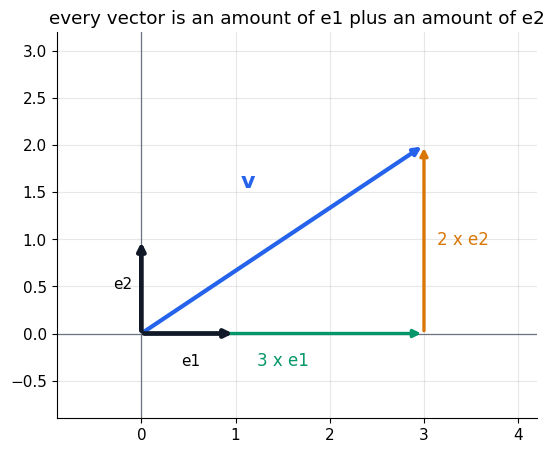

In [8]:
e1 = np.array([1.0, 0.0])          # one step along the horizontal axis
e2 = np.array([0.0, 1.0])          # one step along the vertical axis
zero = np.zeros(2)

print(f"e1   = {e1}")
print(f"e2   = {e2}")
print(f"zero = {zero}   (no length, no direction)")

# rebuild v from the basis, using only its own components as the amounts
rebuilt = v[0] * e1 + v[1] * e2

print(f"\nv                    = {v}")
print(f"v[0]*e1 + v[1]*e2    = {rebuilt}")
print(f"identical in every slot? {np.allclose(rebuilt, v)}")

fig, ax = plt.subplots(figsize=(5.6, 5.0))
ax.axhline(0, color=C_GREY, lw=0.9); ax.axvline(0, color=C_GREY, lw=0.9)

# the two basis steps, laid tip-to-tail
ax.annotate("", xy=(v[0], 0), xytext=(0, 0),
            arrowprops=dict(arrowstyle="-|>", lw=2.4, color=C_AREA))
ax.annotate("", xy=(v[0], v[1]), xytext=(v[0], 0),
            arrowprops=dict(arrowstyle="-|>", lw=2.4, color=C_APPROX))
# the vector itself
ax.annotate("", xy=(v[0], v[1]), xytext=(0, 0),
            arrowprops=dict(arrowstyle="-|>", lw=3.0, color=C_F))

ax.text(v[0] / 2, -0.34, f"{v[0]:.0f} x e1", color=C_AREA,
        ha="center", fontsize=12)
ax.text(v[0] + 0.14, v[1] / 2, f"{v[1]:.0f} x e2", color=C_APPROX,
        va="center", fontsize=12)
ax.text(1.05, 1.55, "v", color=C_F, fontsize=16, fontweight="bold")

# the unit steps themselves, small and grey, for scale
ax.annotate("", xy=(1, 0), xytext=(0, 0),
            arrowprops=dict(arrowstyle="-|>", lw=3.4, color="#111827"))
ax.annotate("", xy=(0, 1), xytext=(0, 0),
            arrowprops=dict(arrowstyle="-|>", lw=3.4, color="#111827"))
ax.text(0.52, -0.34, "e1", fontsize=11, ha="center")
ax.text(-0.30, 0.52, "e2", fontsize=11, va="center")

ax.set_xlim(-0.9, 4.2); ax.set_ylim(-0.9, 3.2)
ax.set_aspect("equal")
ax.set_title("every vector is an amount of e1 plus an amount of e2")
fig.tight_layout(); plt.show()


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

One vector, taken apart into the two unit steps it is made of. The two short black arrows at the origin are $\mathbf{e}_1$ and $\mathbf{e}_2$, the standard basis: one step right, one step up. The green arrow is a whole number of copies of $\mathbf{e}_1$ laid end to end; the orange one is copies of $\mathbf{e}_2$, starting from where the green arrow finished. Together they land exactly on the tip of the blue vector.

So the two numbers printed inside `v` were never arbitrary labels. They are the recipe: *this much of the first basis direction, that much of the second.*

**The common misread:** treating the basis as something special that space comes with, like grid lines painted on the floor. It is a choice. Any two arrows that do not lie on the same line would work just as well as a basis, and every vector would then get a different pair of numbers describing the same arrow. Choosing a *better* basis for a particular dataset is exactly what PCA does in Part 9.

</div>

<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Checked, not asserted

The claim was that a vector's own components are exactly the right amounts of $\mathbf{e}_1$ and $\mathbf{e}_2$ to rebuild it. We did not take that on trust: we multiplied out `v[0]*e1 + v[1]*e2` and asked numpy whether the result matches `v` slot for slot. It printed `True`.

The figure is the same statement as a picture — the green step and the orange step, laid tip-to-tail, land exactly on the tip of the blue arrow. Had the arithmetic been wrong, the arrowheads would visibly miss.

</div>

### The flowers, seen as vectors

Part 0 drew two hundred flowers as a cloud of dots. Every one of those dots is
a vector — a list of two measurements — and we have just spent a section
insisting that a dot and an arrow are the same object seen two ways.

So let us draw the arrows. Pick a few flowers out of `X`, and instead of
plotting them as points, plot them as arrows from the origin.


Three rows pulled straight out of the data matrix X:
  X[  0] = [4.189 1.933]   species 0   (petal length (cm) 4.19, petal width (cm) 1.93)
  X[  7] = [5.661 3.894]   species 0   (petal length (cm) 5.66, petal width (cm) 3.89)
  X[140] = [6.455 3.271]   species 1   (petal length (cm) 6.46, petal width (cm) 3.27)

Each one has shape (2,) -- a 2-component vector, exactly like v.


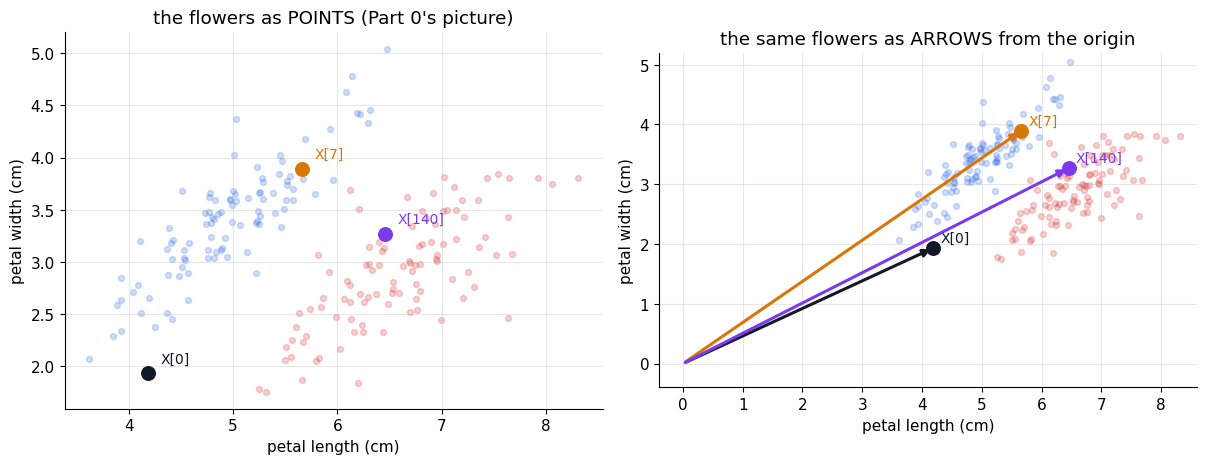

In [9]:
picks = [0, 7, 140]                       # three flowers, chosen once
chosen = X[picks]

print("Three rows pulled straight out of the data matrix X:")
for i, p in enumerate(picks):
    print(f"  X[{p:>3}] = {X[p].round(3)}   species {species[p]}   "
          f"({FEATURES[0]} {X[p][0]:.2f}, {FEATURES[1]} {X[p][1]:.2f})")
print(f"\nEach one has shape {X[picks[0]].shape} -- a 2-component vector, "
      f"exactly like v.")

fig, axes = plt.subplots(1, 2, figsize=(12.2, 5.2))

for ax, as_arrows in zip(axes, [False, True]):
    ax.scatter(*X[species == 0].T, s=18, c=C_F,     alpha=0.22, zorder=1)
    ax.scatter(*X[species == 1].T, s=18, c=C_SLOPE, alpha=0.22, zorder=1)
    cols = ["#111827", C_APPROX, C_EXACT]
    for pt, col, p in zip(chosen, cols, picks):
        if as_arrows:
            ax.annotate("", xy=(pt[0], pt[1]), xytext=(0, 0),
                        arrowprops=dict(arrowstyle="-|>", lw=2.2, color=col))
        ax.scatter([pt[0]], [pt[1]], s=95, color=col, zorder=3)
        ax.text(pt[0] + 0.12, pt[1] + 0.10, f"X[{p}]", color=col, fontsize=10)
    ax.set_xlabel(FEATURES[0]); ax.set_ylabel(FEATURES[1])
    ax.set_aspect("equal")
    if as_arrows:
        ax.set_xlim(-0.4, 8.6); ax.set_ylim(-0.4, 5.2)
        ax.set_title("the same flowers as ARROWS from the origin")
    else:
        ax.set_title("the flowers as POINTS (Part 0's picture)")

fig.tight_layout(); plt.show()


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

**Left** is Part 0's scatter with three flowers picked out in colour. **Right** is the identical data with an arrow drawn from the origin to each of those three flowers. The coloured dots have not moved. The only new ink is the shafts of the arrows.

Notice how similar the three arrows look on the right: they all point up and to the right at a broadly similar angle, because all the measurements are positive and roughly comparable in size. As *points* the two faded species clouds sit in visibly different regions of the plane; as *arrows from the origin* that difference is squeezed into a small difference of angle and is much harder to read.

**The common misread:** concluding from the right-hand panel that these flowers are nearly identical. They are not — the arrow picture is simply the wrong tool for comparing points that all sit far from the origin. This is exactly why Part 2 subtracts one flower from another and Part 9 subtracts the mean from everything: move the interesting variation back near the origin, and the arrow picture starts telling the truth again.

</div>

<div style="background-color: #f8d7da; border-left: 5px solid #dc3545; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🤖 Why ML cares

**Everything a modern model touches is a vector.** A word, a sentence, an image, a user, a product — each is turned into a list of numbers called an **embedding**, and from that moment on the model does nothing but vector arithmetic on them.

Our flowers have two components because two fits on a page. A sentence embedding typically has several hundred to a few thousand, and each component means nothing on its own — no slot is 'the sentiment slot'. What carries the meaning is the *direction* of the whole arrow, which is why the very next thing anyone does with an embedding is compare directions. That comparison is the dot product, and it is Part 3.

The reason to be pedantic about `.shape` now is that embeddings arrive from libraries in every layout imaginable — `(768,)`, `(1, 768)`, `(batch, 768)` — and a broadcasting accident between two of those is a bug that produces plausible-looking numbers instead of an error.

</div>

### Row vectors and column vectors, and why textbooks care

In a textbook, a vector is a **column** by default:

$$\mathbf{v} = \begin{bmatrix} v_1 \\ v_2 \end{bmatrix}
\qquad\text{and}\qquad
\mathbf{v}^T = \begin{bmatrix} v_1 & v_2 \end{bmatrix}$$

The little raised $T$ is the **transpose** — said "v transpose" — and it tips a
column onto its side to make a row. Textbooks care about this because in Part 5
matrix multiplication will only be legal when the shapes line up, and
column-by-default is the convention that makes the standard formulas come out
right.

numpy mostly does not care. A 1-D array of shape `(N,)` is neither a row nor a
column; numpy works out what you must have meant. It is a genuinely convenient
design and it is right almost all the time — which is precisely why the times
it is not are so confusing, as we saw above.

One consequence worth seeing now: **transposing a 1-D array does nothing at
all.** Not an error, not a warning. Silently nothing.


In [10]:
print(f"flat_v.shape        = {flat_v.shape}")
print(f"flat_v.T.shape      = {flat_v.T.shape}   <- transpose did NOTHING")
print(f"unchanged? {np.array_equal(flat_v, flat_v.T)}")
print()
print(f"col_v.shape         = {col_v.shape}")
print(f"col_v.T.shape       = {col_v.T.shape}   <- on a 2-D array, transpose works")
print()

# transpose on the data matrix, where it is genuinely useful
print(f"X.shape             = {X.shape}   ({X.shape[0]} flowers, "
      f"{X.shape[1]} measurements)")
print(f"X.T.shape           = {X.T.shape}   ({X.T.shape[0]} measurements, "
      f"{X.T.shape[1]} flowers)")
print()
print(f"X[0] is flower 0        : {X[0].round(3)}")
print(f"X.T[0] is measurement 0 : {X.T[0][:4].round(3)} ... "
      f"({X.T[0].shape[0]} values, one per flower)")
print()
print("Same numbers, reorganised. X reads flower-by-flower; X.T reads "
      "measurement-by-measurement.")
print(f"round trip X.T.T == X ? {np.array_equal(X.T.T, X)}")


flat_v.shape        = (2,)
flat_v.T.shape      = (2,)   <- transpose did NOTHING
unchanged? True

col_v.shape         = (2, 1)
col_v.T.shape       = (1, 2)   <- on a 2-D array, transpose works

X.shape             = (200, 2)   (200 flowers, 2 measurements)
X.T.shape           = (2, 200)   (2 measurements, 200 flowers)

X[0] is flower 0        : [4.189 1.933]
X.T[0] is measurement 0 : [4.189 4.84  5.291 6.193] ... (200 values, one per flower)

Same numbers, reorganised. X reads flower-by-flower; X.T reads measurement-by-measurement.
round trip X.T.T == X ? True


<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🗣️ In plain words

**Transpose** ($\mathbf{A}^T$) swaps rows and columns. Row $i$ of $\mathbf{A}$ becomes column $i$ of $\mathbf{A}^T$, and nothing else changes — no number is altered, only its address.

On our data matrix that turns *a stack of flowers* into *a stack of measurements*, which is why `X.T` shows up whenever you want to work down a column: the mean of a feature, the spread of a feature, the covariance between two features. All of Part 8.

And on a 1-D array it does nothing, because a 1-D array has only one axis and there is nothing to swap it with. Remember that when a transpose you were counting on fails to fix a shape.

</div>

---

## Where we are, and what is next

A vector is an ordered list of numbers. It can be pictured as an arrow, a list
or a point, and all three are the same object. Its components say how much of
each basis direction to use. numpy stores it as a 1-D array of shape `(N,)`,
and confusing that with `(N, 1)` or `(1, N)` is the bug you will meet most
often. The dimension can be two, or three, or seven hundred and sixty-eight,
and none of the arithmetic notices.

That is the noun. **Part 2 is the verbs:** adding vectors, stretching them,
measuring how long they are and how far apart two of them sit. Everything
there follows from what a vector already is — there is nothing new to accept
on faith, only consequences to work out.

---


---

# 2️⃣ Vector arithmetic: adding, scaling, and length

Part 1 said what a vector *is*. This part is what you can *do* to one, and
there are only really four things: add two of them, stretch one, measure how
long one is, and measure how far apart two of them sit. Everything else in the
notebook — the dot product, matrices, transformations, eigenvectors, PCA — is
these four things stacked up.

The pleasant surprise is that none of it has to be memorised. Each rule has a
picture that makes it obvious and an arithmetic that makes it computable, and
the two always agree. When they seem not to, it is the picture you have
mis-drawn, not the arithmetic.

We start with addition, because it is the one operation that has two different
pictures — and both are worth having.


u     = [3. 1.]
w     = [1. 2.]
u + w = [4. 3.]          <- slot 0: 3+1=4, slot 1: 1+2=3
done slot by slot? True
does order matter?  u+w == w+u ? True


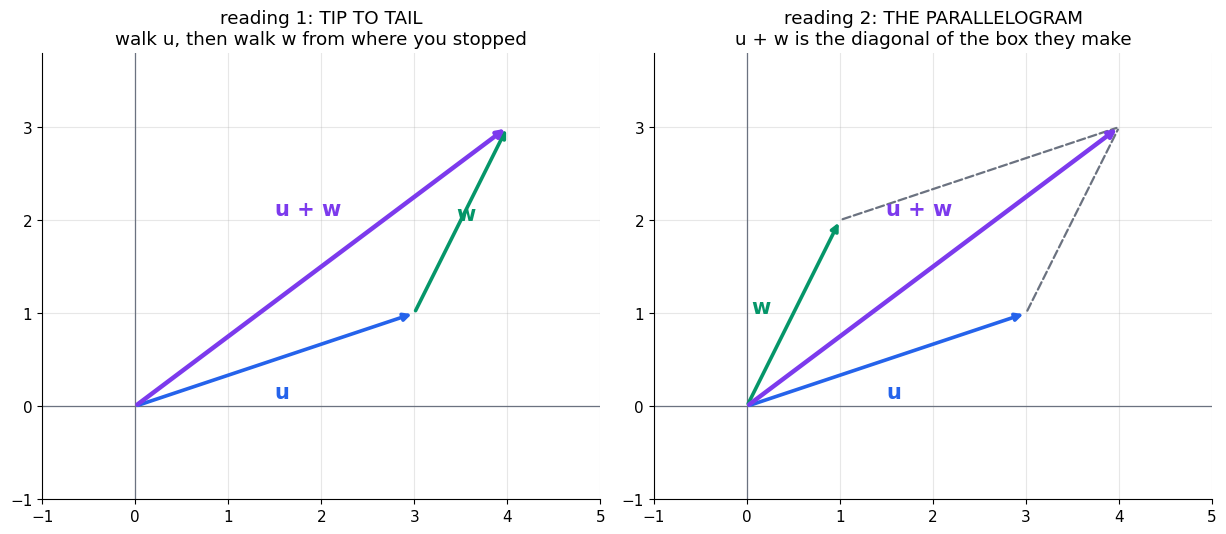

In [11]:
u = np.array([3.0, 1.0])
w = np.array([1.0, 2.0])
s = u + w                      # numpy adds slot by slot. That is the whole rule.

print(f"u     = {u}")
print(f"w     = {w}")
print(f"u + w = {s}          <- slot 0: {u[0]:.0f}+{w[0]:.0f}={s[0]:.0f}, "
      f"slot 1: {u[1]:.0f}+{w[1]:.0f}={s[1]:.0f}")
print(f"done slot by slot? {np.allclose(s, [u[0] + w[0], u[1] + w[1]])}")
print(f"does order matter?  u+w == w+u ? {np.array_equal(u + w, w + u)}")


def arrow(ax, start, end, colour, lw=2.6, style="-|>", ls="-"):
    ax.annotate("", xy=(end[0], end[1]), xytext=(start[0], start[1]),
                arrowprops=dict(arrowstyle=style, lw=lw, color=colour,
                                linestyle=ls))


fig, axes = plt.subplots(1, 2, figsize=(12.4, 5.2))

# ---------- reading 1: tip to tail ----------
ax = axes[0]
arrow(ax, [0, 0], u, C_F)
arrow(ax, u, s, C_AREA)                      # w, re-drawn starting at the tip of u
arrow(ax, [0, 0], s, C_EXACT, lw=3.2)
ax.text(u[0] / 2, u[1] / 2 - 0.42, "u", color=C_F, fontsize=15, fontweight="bold")
ax.text(u[0] + 0.45, u[1] + 1.0, "w", color=C_AREA, fontsize=15, fontweight="bold")
ax.text(1.5, 2.05, "u + w", color=C_EXACT, fontsize=15, fontweight="bold")
ax.set_title("reading 1: TIP TO TAIL\nwalk u, then walk w from where you stopped")

# ---------- reading 2: the parallelogram ----------
ax = axes[1]
arrow(ax, [0, 0], u, C_F)
arrow(ax, [0, 0], w, C_AREA)
arrow(ax, u, s, C_GREY, lw=1.6, style="-", ls="--")
arrow(ax, w, s, C_GREY, lw=1.6, style="-", ls="--")
arrow(ax, [0, 0], s, C_EXACT, lw=3.2)
ax.text(u[0] / 2, u[1] / 2 - 0.42, "u", color=C_F, fontsize=15, fontweight="bold")
ax.text(w[0] / 2 - 0.45, w[1] / 2, "w", color=C_AREA, fontsize=15, fontweight="bold")
ax.text(1.5, 2.05, "u + w", color=C_EXACT, fontsize=15, fontweight="bold")
ax.set_title("reading 2: THE PARALLELOGRAM\nu + w is the diagonal of the box they make")

for ax in axes:
    ax.axhline(0, color=C_GREY, lw=0.9); ax.axvline(0, color=C_GREY, lw=0.9)
    ax.set_xlim(-1.0, 5.0); ax.set_ylim(-1.0, 3.8)
    ax.set_aspect("equal")

fig.tight_layout(); plt.show()


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

The same addition, drawn two ways. **Left**, the tip-to-tail reading: start at the origin, walk along the blue arrow, then — without turning — walk the green arrow from wherever you stopped. Where you end up is the purple sum. This is where Part 1's remark that an arrow does not care where it is drawn starts paying: the green arrow here is `w`, moved.

**Right**, the parallelogram reading: draw both arrows from the origin, complete the box with the dashed sides, and the sum is the diagonal. This reading makes it obvious that `u + w` and `w + u` land in the same place — the printout confirms it — because it is the same box either way round.

**The common misread:** believing the two pictures are different operations, or that one of them is the 'real' definition. They are two views of one arithmetic — the purple arrow is identical in both panels, and both are just `[3+1, 1+2]`.

</div>

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🗣️ In plain words

**Adding** two vectors: add the numbers in matching slots, and leave everything else alone.

$$\mathbf{u} + \mathbf{w} = (u_1 + w_1,\; u_2 + w_2)$$

**Scaling** a vector by an ordinary number $c$ (called a **scalar**, because it scales): multiply every slot by $c$.

$$c\,\mathbf{v} = (c\,v_1,\; c\,v_2)$$

Both rules run slot by slot, which is exactly why neither cares whether there are two slots or seven hundred and sixty-eight. Note that adding needs the two vectors to have the **same** number of slots — there is no sensible way to add a 2-vector to a 3-vector, and numpy will refuse.

</div>

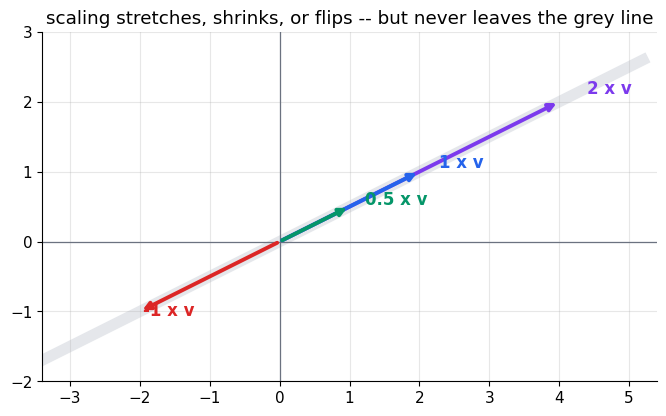

v = [2. 1.]

    2 * v = [4. 2.]   length is 2x the original, direction unchanged
    1 * v = [2. 1.]   length is 1x the original, direction unchanged
  0.5 * v = [1.  0.5]   length is 0.5x the original, direction unchanged
   -1 * v = [-2. -1.]   length is 1x the original, direction REVERSED

0 * v = [0. 0.]   <- the zero vector: scaling all the way down collapses it to a point

p * q        = [3 8]      <- elementwise: [1*3, 2*4]. Still a vector.
np.dot(p, q) = 11             <- the dot product. A single number.
p @ q        = 11             <- same thing, shorter (Part 3)
sum of the elementwise product = 11  -- so dot = sum(p*q). Match? True

--- the silent shape accident ---
p.shape (2,) * col.shape (2, 1) -> (2, 2), a matrix:
[[3 6]
 [4 8]]

--- the loud, friendly failure ---
ValueError: operands could not be broadcast together with shapes (2,) (3,) 
Mismatched lengths DO raise. It is mismatched *shapes* that go quiet.


In [12]:
base = np.array([2.0, 1.0])
factors = [2.0, 1.0, 0.5, -1.0]
cols = [C_EXACT, C_F, C_AREA, C_SLOPE]

fig, ax = plt.subplots(figsize=(6.8, 5.6))
ax.axhline(0, color=C_GREY, lw=0.9); ax.axvline(0, color=C_GREY, lw=0.9)

# the line every multiple of `base` must lie on
line_t = np.linspace(-2.2, 2.6, 2)
ax.plot(line_t * base[0], line_t * base[1], color=C_SOFT, lw=8, zorder=0)

for c, col in zip(factors, cols):
    scaled = c * base
    ax.annotate("", xy=(scaled[0], scaled[1]), xytext=(0, 0),
                arrowprops=dict(arrowstyle="-|>", lw=2.8, color=col))
    ax.text(scaled[0] * 1.06 + 0.16, scaled[1] * 1.06,
            f"{c:g} x v", color=col, fontsize=12, fontweight="bold")

ax.set_xlim(-3.4, 5.4); ax.set_ylim(-2.0, 3.0)
ax.set_aspect("equal")
ax.set_title("scaling stretches, shrinks, or flips -- but never leaves the grey line")
fig.tight_layout(); plt.show()

print(f"v = {base}\n")
for c in factors:
    sc = c * base
    print(f"{c:>5g} * v = {sc}   length is {abs(c):g}x the original, "
          f"direction {'REVERSED' if c < 0 else 'unchanged'}")

print(f"\n0 * v = {0.0 * base}   <- the zero vector: scaling all the way down "
      f"collapses it to a point")

# --- scaling by a NUMBER is safe. `*` between two VECTORS is a different beast. ---
p = np.array([1, 2])
q = np.array([3, 4])

print(f"\np * q        = {p * q}      <- elementwise: [1*3, 2*4]. Still a vector.")
print(f"np.dot(p, q) = {np.dot(p, q)}             <- the dot product. A single number.")
print(f"p @ q        = {p @ q}             <- same thing, shorter (Part 3)")
print(f"sum of the elementwise product = {np.sum(p * q)}  "
      f"-- so dot = sum(p*q). Match? {np.sum(p * q) == np.dot(p, q)}")

print("\n--- the silent shape accident ---")
col = q.reshape(2, 1)
print(f"p.shape {p.shape} * col.shape {col.shape} -> {(p * col).shape}, "
      f"a matrix:\n{p * col}")

print("\n--- the loud, friendly failure ---")
try:
    np.array([1.0, 2.0]) + np.array([1.0, 2.0, 3.0])
except ValueError as e:
    print(f"ValueError: {e}")
    print("Mismatched lengths DO raise. It is mismatched *shapes* that go quiet.")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Four multiples of one vector, all sitting on the grey line through the origin. Scaling by a number bigger than one stretches the arrow; by a number between zero and one it shrinks; by a negative number it flips to point the opposite way, and the size of that negative number sets how far.

The grey line is the point of the figure. **Scaling can change how far along you go and which way you face, but it cannot get you off that line.** That single fact becomes the definition of *span* at the end of this part, and the reason some matrices in Part 7 cannot be undone.

**The common misread:** reading the negative multiple as a *different* vector that happens to point backwards. It is the same direction — the same line — traversed the other way. In machine learning that matters: a gradient and its negative describe one axis of change, and the minus sign in gradient descent is precisely this flip.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Where this trips people up

**`*` between two vectors is not multiplication in the mathematical sense.** In numpy it is elementwise: it pairs up the slots and multiplies each pair, handing you back another vector.

```python
np.array([1, 2]) * np.array([3, 4])   # -> array([3, 8])   NOT 11
```

The thing you probably wanted — the single number $1{\times}3 + 2{\times}4 = 11$ — is the **dot product**, written `np.dot(u, w)` or `u @ w`, and it is the whole of Part 3. The cell above ran both, one under the other, so you can see how far apart they are.

**And the shape trap from Part 1 returns here.** Scaling by a scalar is always safe, but combining two vectors of mismatched shape is not: `(2,) * (2,1)` does not fail, it broadcasts into a 2×2 matrix. Adding a 2-vector to a 3-vector *does* fail, loudly, which is the friendly case. The dangerous one is always the silent one — so print `.shape` when a result surprises you.

</div>

### Subtraction, and the single most useful arrow in the notebook

Subtraction needs no new rule. Since scaling by $-1$ flips a vector, and we
already know how to add, we can just define

$$\mathbf{w} - \mathbf{u} = \mathbf{w} + (-1)\mathbf{u}$$

which, slot by slot, is exactly what you would guess: subtract the matching
numbers.

But there is a geometric fact buried in there that is worth more than the rule
itself:

> $\mathbf{w} - \mathbf{u}$ is the arrow that goes **from** $\mathbf{u}$ **to**
> $\mathbf{w}$.

Check it against the tip-to-tail picture: if you start at $\mathbf{u}$ and add
$\mathbf{w} - \mathbf{u}$, you land at $\mathbf{u} + \mathbf{w} - \mathbf{u}$,
which is $\mathbf{w}$. So that difference is precisely the trip between them.

Note the order. $\mathbf{w} - \mathbf{u}$ points from $\mathbf{u}$ to
$\mathbf{w}$ — **the vector you subtract is where you start.** Getting this
backwards is a rite of passage, and the figure below is designed so you can
see which way the arrowhead points.


f1 = X[7]    = [5.661 3.894]   (species 0)
f2 = X[140]  = [6.455 3.271]   (species 1)
f2 - f1      = [ 0.794 -0.623]
  slot 0: 6.455 - 5.661 = +0.794  (petal length (cm))
  slot 1: 3.271 - 3.894 = -0.623  (petal width (cm))

So flower 140 is 0.794 cm longer and 0.623 cm narrower than flower 7.

f1 + (f2 - f1)  = [6.455168 3.27113 ]
f2              = [6.455168 3.27113 ]
exact match? True   (largest slot-wise error: 0.00e+00)
and order matters: f1 - f2 = [-0.794  0.623], every sign flipped; is it -(f2-f1)? True


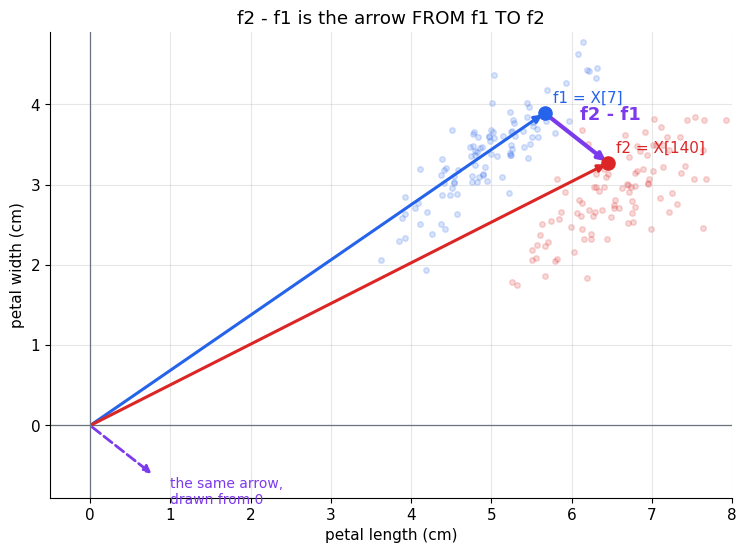

In [13]:
f1, f2 = X[7], X[140]          # two flowers, one from each species
diff = f2 - f1                 # the trip from flower 7 to flower 140

print(f"f1 = X[7]    = {f1.round(3)}   (species {species[7]})")
print(f"f2 = X[140]  = {f2.round(3)}   (species {species[140]})")
print(f"f2 - f1      = {diff.round(3)}")
print(f"  slot 0: {f2[0]:.3f} - {f1[0]:.3f} = {diff[0]:+.3f}  "
      f"({FEATURES[0]})")
print(f"  slot 1: {f2[1]:.3f} - {f1[1]:.3f} = {diff[1]:+.3f}  "
      f"({FEATURES[1]})")
print(f"\nSo flower 140 is {abs(diff[0]):.3f} cm longer and "
      f"{abs(diff[1]):.3f} cm {'wider' if diff[1] > 0 else 'narrower'} "
      f"than flower 7.")

# --- the claim: starting at f1 and adding (f2 - f1) must land exactly on f2 ---
landing = f1 + diff
print(f"\nf1 + (f2 - f1)  = {landing.round(6)}")
print(f"f2              = {f2.round(6)}")
print(f"exact match? {np.allclose(landing, f2)}   "
      f"(largest slot-wise error: {np.max(np.abs(landing - f2)):.2e})")
print(f"and order matters: f1 - f2 = {(f1 - f2).round(3)}, every sign flipped; "
      f"is it -(f2-f1)? {np.allclose(f1 - f2, -diff)}")

fig, ax = plt.subplots(figsize=(7.6, 6.0))
ax.scatter(*X[species == 0].T, s=16, c=C_F,     alpha=0.18, zorder=1)
ax.scatter(*X[species == 1].T, s=16, c=C_SLOPE, alpha=0.18, zorder=1)

# the two flowers as arrows from the origin
for pt, col, lab in [(f1, C_F, "f1 = X[7]"), (f2, C_SLOPE, "f2 = X[140]")]:
    ax.annotate("", xy=(pt[0], pt[1]), xytext=(0, 0),
                arrowprops=dict(arrowstyle="-|>", lw=2.2, color=col))
    ax.scatter([pt[0]], [pt[1]], s=90, color=col, zorder=4)
    ax.text(pt[0] + 0.10, pt[1] + 0.13, lab, color=col, fontsize=11)

# the difference, drawn where it is USEFUL: starting at f1
ax.annotate("", xy=(f2[0], f2[1]), xytext=(f1[0], f1[1]),
            arrowprops=dict(arrowstyle="-|>", lw=3.0, color=C_EXACT))
ax.text((f1[0] + f2[0]) / 2 + 0.05, (f1[1] + f2[1]) / 2 + 0.22,
        "f2 - f1", color=C_EXACT, fontsize=13, fontweight="bold")

# and the SAME vector drawn from the origin, dashed, to show it is one object
ax.annotate("", xy=(diff[0], diff[1]), xytext=(0, 0),
            arrowprops=dict(arrowstyle="-|>", lw=2.0, color=C_EXACT,
                            linestyle="--"))
ax.text(diff[0] + 0.20, diff[1] - 0.02, "the same arrow,\ndrawn from 0",
        color=C_EXACT, fontsize=10, va="top")

ax.axhline(0, color=C_GREY, lw=0.9); ax.axvline(0, color=C_GREY, lw=0.9)
ax.set_xlabel(FEATURES[0]); ax.set_ylabel(FEATURES[1])
ax.set_xlim(-0.5, 8.0); ax.set_ylim(-0.9, 4.9)
ax.set_aspect("equal")
ax.set_title("f2 - f1 is the arrow FROM f1 TO f2")
fig.tight_layout(); plt.show()


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Two flowers drawn as arrows from the origin, and their difference drawn twice. The **solid purple arrow starts at f1 and ends exactly on f2** — that is the useful placement, and it is what makes a difference vector mean 'the change from one thing to another'. The **dashed purple arrow** is the identical vector drawn from the origin instead, which is where numpy conceptually stores it.

Both arrows have the same length and the same direction, so they are the same vector. Only the placement differs, and placement is not part of what a vector is.

**The common misread:** thinking the dashed arrow is a *different, smaller* vector because it sits near the origin while the solid one sits out among the data. Measure them — they are congruent. This is also the cleanest illustration of why subtracting the mean before analysis (Part 9) throws nothing away: it moves every arrow to the origin without changing a single one of them.

</div>

<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Checked, not asserted

Two claims were made in words and both were tested rather than asserted.

**One:** that $\mathbf{f_1} + (\mathbf{f_2} - \mathbf{f_1})$ lands on $\mathbf{f_2}$. We computed it and printed the largest slot-wise error rather than settling for a cheerful `True`, so you can see how close 'close' actually was. Here the subtraction and the addition undo each other bit for bit. `np.allclose` is still the right tool in general though: on less tidy arithmetic that error would be a small nonzero speck of floating-point dust, and a bare `==` would reject it.

**Two:** that reversing the order reverses the arrow. Every sign flipped, and `f1 - f2` came back equal to `-(f2 - f1)`.

That second one is the check to remember. If a difference vector ever points the opposite way to what you expected, you subtracted in the wrong order — it is almost never anything subtler.

</div>

### How long is a vector? Pythagoras, and nothing else

We keep saying "length" as if it were obvious. Let us actually derive it,
because the derivation is two lines and it explains the formula's shape.

Take the vector $\mathbf{v} = (v_1, v_2)$ drawn as an arrow from the origin.
Part 1 showed it is $v_1$ steps right followed by $v_2$ steps up — and those
two steps are **at right angles to each other**, because the axes are. So the
arrow is the hypotenuse of a right triangle whose legs are $v_1$ and $v_2$.

Pythagoras says the square of the hypotenuse is the sum of the squares of the
legs:

$$\text{length}^2 = v_1^2 + v_2^2 \qquad\Longrightarrow\qquad
\|\mathbf{v}\| = \sqrt{v_1^2 + v_2^2}$$

The double bars $\|\cdot\|$ are read "the **norm** of", which is just the
formal word for length. And now the important step — in three dimensions you
apply Pythagoras twice (once in the floor plane, once to stand the result up)
and get $\sqrt{v_1^2 + v_2^2 + v_3^2}$; keep going and the pattern never
breaks:

$$\|\mathbf{v}\| = \sqrt{v_1^2 + v_2^2 + \cdots + v_N^2} = \sqrt{\sum_i v_i^2}$$

**Square every component, add them up, take the square root.** That is the
whole of it, in any number of dimensions, and it is the formula behind almost
every "how different are these two things?" question in machine learning.


vec = [3. 4.]
  sqrt(v0^2 + v1^2)     = sqrt(9 + 16) = 5.000000
  sqrt(sum(vec**2))     = 5.000000
  np.linalg.norm(vec)   = 5.000000
  all three agree? True

768-D vector: sqrt(sum of squares) = 27.883338, np.linalg.norm = 27.883338, agree? True


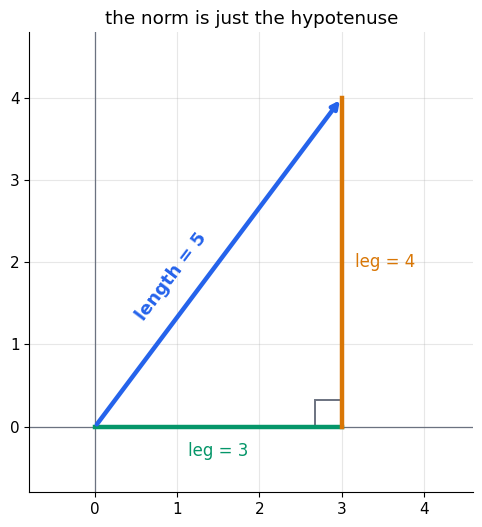

In [14]:
vec = np.array([3.0, 4.0])          # chosen so the answer is a round number

by_hand = np.sqrt(vec[0] ** 2 + vec[1] ** 2)   # straight from Pythagoras
by_sum  = np.sqrt(np.sum(vec ** 2))            # the general N-dimensional form
by_numpy = np.linalg.norm(vec)                 # what you will actually type

print(f"vec = {vec}")
print(f"  sqrt(v0^2 + v1^2)     = sqrt({vec[0]**2:.0f} + {vec[1]**2:.0f}) "
      f"= {by_hand:.6f}")
print(f"  sqrt(sum(vec**2))     = {by_sum:.6f}")
print(f"  np.linalg.norm(vec)   = {by_numpy:.6f}")
print(f"  all three agree? {np.allclose([by_hand, by_sum], by_numpy)}")

# ... and the same three lines in 768 dimensions, where no triangle can be drawn
RNG_L2 = np.random.default_rng(23)
big = RNG_L2.normal(size=768)
print(f"\n768-D vector: sqrt(sum of squares) = {np.sqrt(np.sum(big**2)):.6f}, "
      f"np.linalg.norm = {np.linalg.norm(big):.6f}, "
      f"agree? {np.isclose(np.sqrt(np.sum(big**2)), np.linalg.norm(big))}")

fig, ax = plt.subplots(figsize=(6.2, 5.4))
ax.axhline(0, color=C_GREY, lw=0.9); ax.axvline(0, color=C_GREY, lw=0.9)

ax.plot([0, vec[0]], [0, 0], color=C_AREA, lw=3.2)
ax.plot([vec[0], vec[0]], [0, vec[1]], color=C_APPROX, lw=3.2)
ax.annotate("", xy=(vec[0], vec[1]), xytext=(0, 0),
            arrowprops=dict(arrowstyle="-|>", lw=3.2, color=C_F))
ax.add_patch(plt.Rectangle((vec[0] - 0.32, 0), 0.32, 0.32,
                           fill=False, ec=C_GREY, lw=1.4))

ax.text(vec[0] / 2, -0.36, f"leg = {vec[0]:.0f}", color=C_AREA,
        ha="center", fontsize=12)
ax.text(vec[0] + 0.16, vec[1] / 2, f"leg = {vec[1]:.0f}", color=C_APPROX,
        va="center", fontsize=12)
ax.text(0.45, 1.30, f"length = {by_numpy:.0f}", color=C_F,
        fontsize=13, fontweight="bold", rotation=53)

ax.set_xlim(-0.8, 4.6); ax.set_ylim(-0.8, 4.8)
ax.set_aspect("equal")
ax.set_title("the norm is just the hypotenuse")
fig.tight_layout(); plt.show()


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

The right triangle hiding inside every 2-D vector. The green leg is how far right the vector goes, the orange leg is how far up, the small square at the corner marks the right angle that lets Pythagoras apply at all, and the blue hypotenuse is the vector itself. The three lengths printed above are read directly off this picture.

The triangle is a 2-D convenience. The formula it produces is not — the printout also norms a 768-component vector, where the picture is unavailable and the arithmetic is unbothered.

**The common misread:** expecting the length to grow like the components do. It does not, because of the squares and the square root: doubling both legs doubles the hypotenuse, but adding one to a long leg barely moves it. This is why, in high dimensions, one component going haywire can be almost invisible in the norm — and why people inspect components, not just norms, when debugging.

</div>

<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Checked, not asserted

The norm was derived from Pythagoras, then computed three separate ways: the literal two-term formula, the general sum-of-squares form, and numpy's own `np.linalg.norm`. All three were compared with `np.allclose` and agreed, in two dimensions and again in seven hundred and sixty-eight.

That is worth more than it looks. It means `np.linalg.norm` is not a black box you now have to trust — you have reproduced it from the definition, and if you ever need a norm that numpy does not provide, you know what it would have to compute.

</div>

### Unit vectors: keeping the direction, throwing away the size

A vector carries two pieces of information at once — **which way** and **how
far**. Very often you only want the first. Two sentences about the same topic
should count as similar whether one is a paragraph long and the other is a
line; two flowers should count as pointing the same way even if one is bigger.

The fix is to divide the vector by its own length:

$$\hat{\mathbf{v}} = \frac{\mathbf{v}}{\|\mathbf{v}\|}$$

The little hat is read "v hat". Dividing is just scaling by the number
$1/\|\mathbf{v}\|$, and Part 2 has already established that scaling never
changes the line you sit on — so $\hat{\mathbf{v}}$ points exactly where
$\mathbf{v}$ did. What has changed is its length, which is now $1$: you have
divided a length by itself. A vector of length one is called a **unit vector**,
and the process is called **normalising**.

Every unit vector in two dimensions lands on the circle of radius one. That
circle is the set of all possible directions, with size stripped out.


vector              length      normalised          length after
------------------------------------------------------------------
[3. 1.]             3.1623    [0.9487 0.3162]      1.000000
[1.  2.5]           2.6926    [0.3714 0.9285]      1.000000
[-2.  1.]           2.2361    [-0.8944  0.4472]    1.000000
[ 0.6 -1.8]         1.8974    [ 0.3162 -0.9487]    1.000000


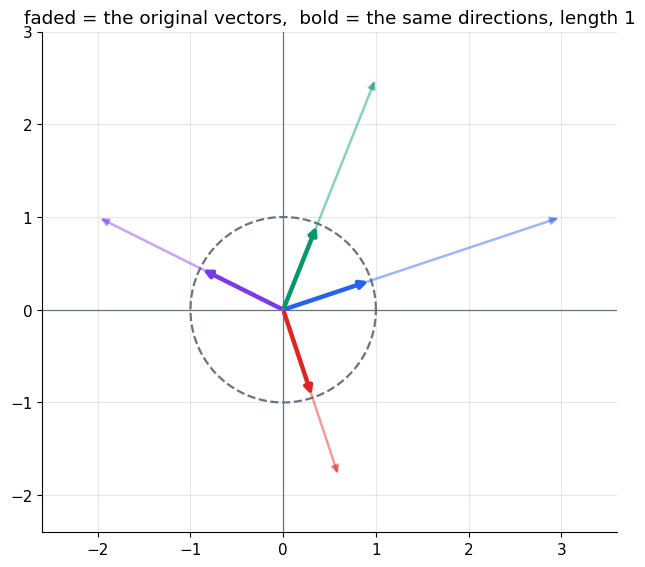


All four normalised at once with one line, using axis=1:
  lengths afterwards: [1. 1. 1. 1.]
  every one exactly 1? True


In [15]:
family = np.array([[3.0, 1.0], [1.0, 2.5], [-2.0, 1.0], [0.6, -1.8]])
cols4 = [C_F, C_AREA, C_EXACT, C_SLOPE]

fig, ax = plt.subplots(figsize=(6.4, 6.0))
theta = np.linspace(0, 2 * np.pi, 400)
ax.plot(np.cos(theta), np.sin(theta), color=C_GREY, lw=1.6, ls="--")
ax.axhline(0, color=C_GREY, lw=0.9); ax.axvline(0, color=C_GREY, lw=0.9)

print("vector              length      normalised          length after")
print("-" * 66)
for vv, col in zip(family, cols4):
    length = np.linalg.norm(vv)
    hat = vv / length
    ax.annotate("", xy=(vv[0], vv[1]), xytext=(0, 0),
                arrowprops=dict(arrowstyle="-|>", lw=1.8, color=col, alpha=0.45))
    ax.annotate("", xy=(hat[0], hat[1]), xytext=(0, 0),
                arrowprops=dict(arrowstyle="-|>", lw=3.2, color=col))
    print(f"{str(vv):<18}  {length:>6.4f}    {str(hat.round(4)):<20} "
          f"{np.linalg.norm(hat):.6f}")

ax.set_xlim(-2.6, 3.6); ax.set_ylim(-2.4, 3.0)
ax.set_aspect("equal")
ax.set_title("faded = the original vectors,  bold = the same directions, length 1")
fig.tight_layout(); plt.show()

hats = family / np.linalg.norm(family, axis=1, keepdims=True)
print(f"\nAll four normalised at once with one line, using axis=1:")
print(f"  lengths afterwards: {np.linalg.norm(hats, axis=1).round(12)}")
print(f"  every one exactly 1? {np.allclose(np.linalg.norm(hats, axis=1), 1.0)}")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Four vectors of assorted lengths and directions, each drawn twice: faded at its original size, bold after normalising. Every bold arrow ends exactly on the dashed unit circle, and every bold arrow lies along its own faded original — no direction moved.

That is normalising in one image: **slide along your own line until you hit the circle.** The vector pointing down and right ends up on the circle too, because normalising never cares about sign, only magnitude.

**The common misread:** thinking normalising makes vectors comparable in *every* way. It makes them comparable in direction only, and it deliberately destroys size. If size is the signal — a loud audio clip, an expensive basket, a long document — normalising throws away the thing you were trying to measure.

</div>

<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Checked, not asserted

The claim was that dividing by the norm yields length exactly one. Each of the four vectors was normalised and re-measured, and the right-hand column of the table prints those lengths. Then all four were normalised again in a single vectorised line with `axis=1, keepdims=True` — the shape-safe way to normalise a whole batch — and `np.allclose(..., 1.0)` confirmed the lot.

The `keepdims=True` is not decoration. `np.linalg.norm(family, axis=1)` has shape `(4,)`, and dividing a `(4, 2)` array by a `(4,)` array is exactly the Part 1 broadcasting trap: numpy would try to line the 4 up against the 2 and fail — or worse, succeed silently if the numbers happened to match. `keepdims=True` makes it `(4, 1)`, which broadcasts down the rows the way you meant.

</div>

<div style="background-color: #f8d7da; border-left: 5px solid #dc3545; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🤖 Why ML cares

**Normalising before comparing directions is the single most common preprocessing step in embedding work,** and forgetting it is the single most common cause of a search engine that ranks long documents above relevant ones.

The reason: **cosine similarity** — the standard way to ask how related two embeddings are — is defined as the dot product of the *normalised* vectors. Skip the normalising and you are comparing raw dot products, which reward sheer magnitude. A long, rambling document with a big-norm embedding then beats a short, precisely on-topic one, and the failure looks like a bad model rather than a missing division.

Vector databases lean on this so heavily that most of them normalise on insert, so that similarity search reduces to a plain dot product and can be run as one big matrix multiply — which is Part 5. Part 3 builds the dot product and shows exactly why the normalised version measures angle.

</div>

### Distance: how far apart are two vectors?

We now have everything needed, and no new idea is required. The distance
between two vectors is **the length of the arrow between them** — and we
already know that arrow is their difference:

$$\text{dist}(\mathbf{u}, \mathbf{w}) = \|\mathbf{w} - \mathbf{u}\|
= \sqrt{\sum_i (w_i - u_i)^2}$$

Subtract, then take the norm. This is called **Euclidean distance**, and it is
the thing k-nearest-neighbours uses to decide who your neighbours are,
k-means uses to decide which cluster you belong to, and mean-squared-error uses
to decide how wrong a prediction was.

Notice that order stops mattering here, even though it mattered for the
difference itself: $\mathbf{w} - \mathbf{u}$ and $\mathbf{u} - \mathbf{w}$
point opposite ways, but squaring kills the signs, so their lengths are equal.


Pairwise Euclidean distances, computed from the definition:
  X[7] to X[140]: sqrt(sum of squared differences) = 1.0090, np.linalg.norm(diff) = 1.0090, agree? True
  X[7] to X[12]: sqrt(sum of squared differences) = 0.7066, np.linalg.norm(diff) = 0.7066, agree? True
  X[140] to X[12]: sqrt(sum of squared differences) = 1.4595, np.linalg.norm(diff) = 1.4595, agree? True

symmetry: dist(a,b) = 1.008993, dist(b,a) = 1.008993, equal? True
distance from a flower to itself: 0.0


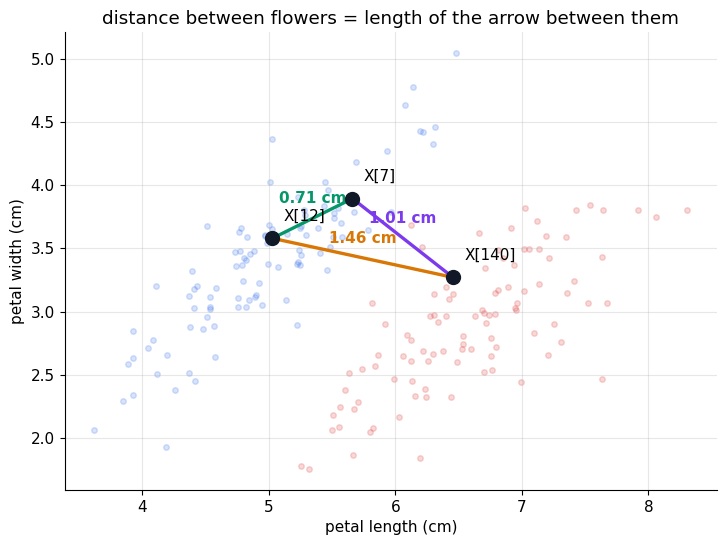

In [16]:
trio = [7, 140, 12]
labels = [f"X[{i}]" for i in trio]
pts = X[trio]

print("Pairwise Euclidean distances, computed from the definition:")
for i in range(3):
    for j in range(i + 1, 3):
        d_manual = np.sqrt(np.sum((pts[j] - pts[i]) ** 2))
        d_norm = np.linalg.norm(pts[j] - pts[i])
        print(f"  {labels[i]} to {labels[j]}: sqrt(sum of squared differences) "
              f"= {d_manual:.4f}, np.linalg.norm(diff) = {d_norm:.4f}, "
              f"agree? {np.isclose(d_manual, d_norm)}")

d_ab = np.linalg.norm(pts[1] - pts[0])
d_ba = np.linalg.norm(pts[0] - pts[1])
print(f"\nsymmetry: dist(a,b) = {d_ab:.6f}, dist(b,a) = {d_ba:.6f}, "
      f"equal? {np.isclose(d_ab, d_ba)}")
print(f"distance from a flower to itself: "
      f"{np.linalg.norm(pts[0] - pts[0]):.1f}")

fig, ax = plt.subplots(figsize=(7.4, 5.8))
ax.scatter(*X[species == 0].T, s=16, c=C_F,     alpha=0.18, zorder=1)
ax.scatter(*X[species == 1].T, s=16, c=C_SLOPE, alpha=0.18, zorder=1)

pair_cols = [C_EXACT, C_AREA, C_APPROX]
k = 0
for i in range(3):
    for j in range(i + 1, 3):
        ax.plot([pts[i][0], pts[j][0]], [pts[i][1], pts[j][1]],
                color=pair_cols[k], lw=2.4)
        mx, my = (pts[i] + pts[j]) / 2
        ax.text(mx, my + 0.12, f"{np.linalg.norm(pts[j] - pts[i]):.2f} cm",
                color=pair_cols[k], fontsize=11, fontweight="bold", ha="center")
        k += 1

for pt, lab in zip(pts, labels):
    ax.scatter([pt[0]], [pt[1]], s=100, color="#111827", zorder=4)
    ax.text(pt[0] + 0.09, pt[1] + 0.14, lab, fontsize=11)

ax.set_xlabel(FEATURES[0]); ax.set_ylabel(FEATURES[1])
ax.set_aspect("equal")
ax.set_title("distance between flowers = length of the arrow between them")
fig.tight_layout(); plt.show()


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Three flowers from the Part 0 scatter, with every pair joined and the connecting length labelled. Because the axes are on equal aspect, the labelled numbers match what your eye measures: the visually longest segment carries the largest number.

The whole scatter is faded behind on purpose. Every one of those background dots has a distance to every other, and a clustering algorithm is nothing more than that full table of distances, read carefully.

**The common misread:** trusting a distance when the two axes are in different units. Here both measurements are centimetres, so adding their squares is meaningful. Put petal length in centimetres against a price in dollars and the sum of squares is arithmetic on nonsense — whichever column happens to carry bigger numbers will dominate every distance. That is why standardising features before any distance-based method is not a nicety but a correctness requirement.

</div>

### Two ways to measure length: L2 and L1

The Pythagoras length we derived has a name: the **L2 norm**, written
$\|\mathbf{v}\|_2$. The 2 is the power the components are raised to.

It is not the only sensible notion of length. Suppose you cannot travel
diagonally — you are a taxi in a city laid out on a grid. Then getting to
$(3, 4)$ costs you three blocks across plus four blocks up, seven blocks, not
five. That is the **L1 norm**:

$$\|\mathbf{v}\|_1 = \sum_i |v_i| \qquad\text{versus}\qquad
\|\mathbf{v}\|_2 = \sqrt{\sum_i v_i^2}$$

The clearest way to see how differently they behave is to draw each one's
**unit ball** — the set of every vector whose length is exactly 1 under that
norm. For L2 that is the familiar circle. For L1 it is a **diamond**, because
to keep $|v_1| + |v_2| = 1$ you must give up exactly as much of one coordinate
as you gain in the other.

**Why ML cares, in one sentence each:** adding the L2 norm of the weights to a
loss (**ridge**, or weight decay) shrinks every weight smoothly towards zero
without ever quite getting there, while adding the L1 norm (**lasso**) drives
weights *exactly* to zero and so selects features — and the reason is visible
in the shapes below, because the diamond has sharp corners sitting on the axes
and the circle does not.


v = [ 3. -4.]
  L2 (Pythagoras, 'as the crow flies') = 5.0000   np.linalg.norm(v)      = 5.0000
  L1 (taxi on a grid)                  = 7.0000   np.linalg.norm(v, 1)   = 7.0000
  L1 is never smaller than L2 here: True


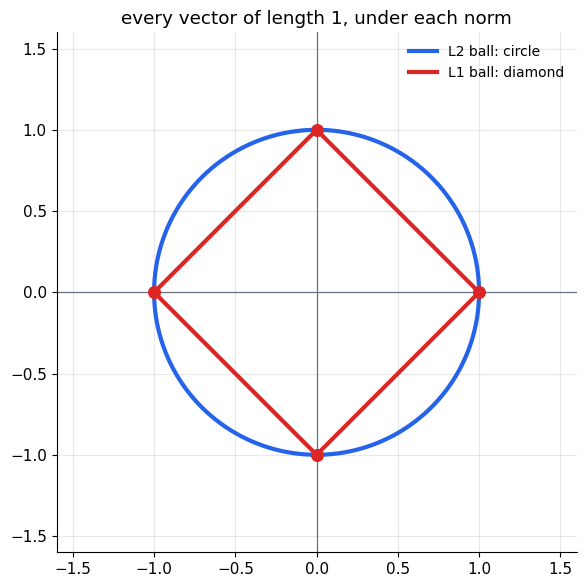


[1. 0.] : L1 = 1.000, L2 = 1.000   <- on BOTH shapes
[0.5 0.5] : L1 = 1.000, L2 = 0.707   <- on the diamond, inside the circle


In [17]:
tst = np.array([3.0, -4.0])
l2 = np.sqrt(np.sum(tst ** 2))
l1 = np.sum(np.abs(tst))

print(f"v = {tst}")
print(f"  L2 (Pythagoras, 'as the crow flies') = {l2:.4f}   "
      f"np.linalg.norm(v)      = {np.linalg.norm(tst):.4f}")
print(f"  L1 (taxi on a grid)                  = {l1:.4f}   "
      f"np.linalg.norm(v, 1)   = {np.linalg.norm(tst, 1):.4f}")
print(f"  L1 is never smaller than L2 here: {l1 >= l2}")

fig, ax = plt.subplots(figsize=(6.2, 6.0))
th = np.linspace(0, 2 * np.pi, 500)
ax.plot(np.cos(th), np.sin(th), color=C_F, lw=3.0, label="L2 ball: circle")
ax.plot([1, 0, -1, 0, 1], [0, 1, 0, -1, 0], color=C_SLOPE, lw=3.0,
        label="L1 ball: diamond")

for pt in [(1, 0), (0, 1), (-1, 0), (0, -1)]:
    ax.scatter([pt[0]], [pt[1]], s=70, color=C_SLOPE, zorder=4)

ax.axhline(0, color=C_GREY, lw=0.9); ax.axvline(0, color=C_GREY, lw=0.9)
ax.set_xlim(-1.6, 1.6); ax.set_ylim(-1.6, 1.6)
ax.set_aspect("equal")
ax.legend(frameon=False, loc="upper right", fontsize=10)
ax.set_title("every vector of length 1, under each norm")
fig.tight_layout(); plt.show()

# a vector on the diamond need not be on the circle, and vice versa
corner = np.array([1.0, 0.0])
mid = np.array([0.5, 0.5])
print(f"\n{corner} : L1 = {np.linalg.norm(corner,1):.3f}, "
      f"L2 = {np.linalg.norm(corner):.3f}   <- on BOTH shapes")
print(f"{mid} : L1 = {np.linalg.norm(mid,1):.3f}, "
      f"L2 = {np.linalg.norm(mid):.3f}   <- on the diamond, inside the circle")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

The blue circle is every vector whose L2 length is one; the red diamond is every vector whose L1 length is one. Equal aspect matters here more than anywhere else in the notebook — stretch one axis and the circle becomes an ellipse and the whole comparison collapses.

Look at the diamond's four marked corners. They sit **on the axes**, which means a corner vector has one component doing all the work and the other exactly zero. The circle has no corners: every point on it is a compromise between the two components. That geometric difference is the entire reason lasso produces sparse models and ridge does not — an optimiser pushed against a diamond tends to get stuck on a corner, and a corner *is* a zeroed-out feature.

**The common misread:** assuming L1 is always the bigger number because the diamond looks smaller. Both shapes are the length-1 sets of their own norm, so they are not comparable as sizes. For any given vector L1 is at least L2 — the printout checks this on one example — and the diamond looks smaller precisely *because* L1 charges more for the same trip.

</div>

### Linear combinations and span: everywhere you can get to

One last idea, and it is the one Part 1 kept promising.

Take a handful of vectors. Scale each one by whatever number you like, add the
results together. Anything you can build that way is called a **linear
combination** of them:

$$c_1\mathbf{v}_1 + c_2\mathbf{v}_2 + \cdots + c_k\mathbf{v}_k$$

Now ask: as the $c$'s range over every possible number, what is the complete
set of places you can reach? That set is called the **span** of those vectors.
We have met it twice already without the name — writing $\mathbf{v}$ as
$v_1\mathbf{e}_1 + v_2\mathbf{e}_2$ said that $\mathbf{e}_1$ and
$\mathbf{e}_2$ span the whole plane, and the grey line in the scaling figure
was the span of a single vector.

Here is the interesting part. Two vectors in the plane usually span the whole
plane — but **not always**. If the second vector is just a multiple of the
first, it points along a line you could already reach, and adding it buys you
nothing: the span collapses from a plane down to a line. Such vectors are
called **linearly dependent**, and the collapse is the single most important
failure mode in linear algebra. It is why some systems of equations have no
unique solution (Part 7), why some matrices cannot be inverted (Part 7), and
why a dataset with a duplicated feature is secretly lower-dimensional than its
column count suggests (Part 9).


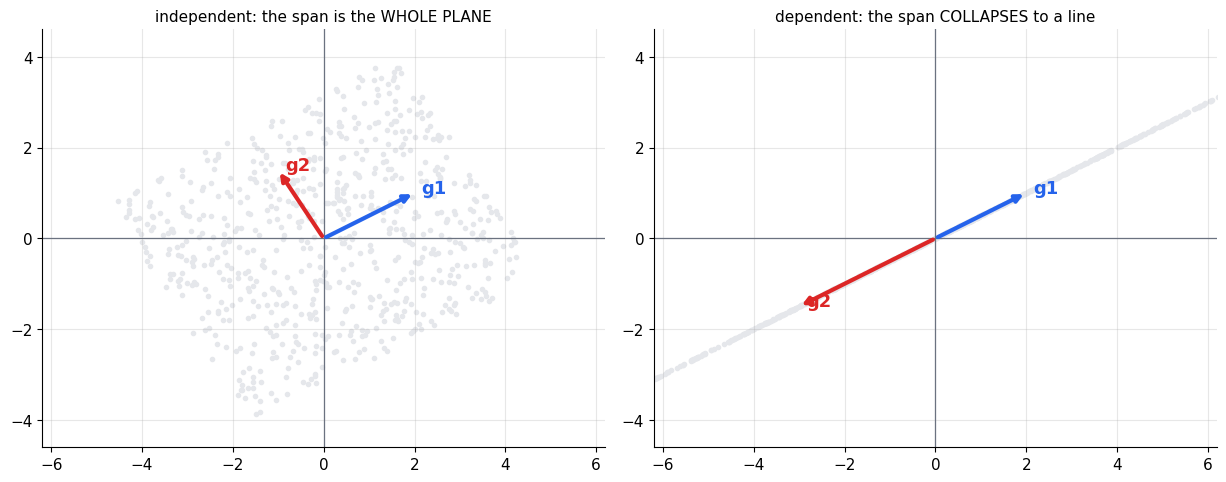

g1, g2      -> matrix_rank = 2   (2 = spans a plane, 1 = spans only a line)
g1, g2_dep  -> matrix_rank = 1   (2 = spans a plane, 1 = spans only a line)

Is g2_dep really a multiple of g1?  g2_dep = [-3.  -1.5] = -1.5 * [2. 1.], check: True
Of the 700 points in the right panel, how many lie exactly on g1's line? 700


In [18]:
RNG_L3 = np.random.default_rng(41)
coef = RNG_L3.uniform(-1.6, 1.6, size=(700, 2))     # 700 random (c1, c2) pairs

g1 = np.array([2.0, 1.0])
g2 = np.array([-1.0, 1.5])          # a genuinely different direction
g2_dep = -1.5 * g1                  # a multiple of g1: adds nothing new

fig, axes = plt.subplots(1, 2, figsize=(12.4, 5.6))

for ax, second, title in [
        (axes[0], g2,     "independent: the span is the WHOLE PLANE"),
        (axes[1], g2_dep, "dependent: the span COLLAPSES to a line")]:
    reach = coef[:, [0]] * g1 + coef[:, [1]] * second     # every c1*g1 + c2*v2
    ax.scatter(reach[:, 0], reach[:, 1], s=9, c=C_SOFT, zorder=0)
    ax.annotate("", xy=(g1[0], g1[1]), xytext=(0, 0),
                arrowprops=dict(arrowstyle="-|>", lw=3.0, color=C_F))
    ax.annotate("", xy=(second[0], second[1]), xytext=(0, 0),
                arrowprops=dict(arrowstyle="-|>", lw=3.0, color=C_SLOPE))
    ax.text(g1[0] + 0.15, g1[1], "g1", color=C_F, fontsize=13, fontweight="bold")
    ax.text(second[0] + 0.15, second[1], "g2", color=C_SLOPE,
            fontsize=13, fontweight="bold")
    ax.axhline(0, color=C_GREY, lw=0.9); ax.axvline(0, color=C_GREY, lw=0.9)
    ax.set_xlim(-6.2, 6.2); ax.set_ylim(-4.6, 4.6)
    ax.set_aspect("equal")
    ax.set_title(title, fontsize=11)

fig.tight_layout(); plt.show()

# the numeric version of the same statement
for name, second in [("g1, g2     ", g2), ("g1, g2_dep ", g2_dep)]:
    pair = np.vstack([g1, second])
    reach = coef[:, [0]] * g1 + coef[:, [1]] * second
    print(f"{name} -> matrix_rank = {np.linalg.matrix_rank(pair)}   "
          f"(2 = spans a plane, 1 = spans only a line)")

print(f"\nIs g2_dep really a multiple of g1?  g2_dep = {g2_dep} = "
      f"{-1.5} * {g1}, check: {np.allclose(g2_dep, -1.5 * g1)}")

dep_reach = coef[:, [0]] * g1 + coef[:, [1]] * g2_dep
on_line = np.abs(dep_reach[:, 0] * g1[1] - dep_reach[:, 1] * g1[0])
print(f"Of the {dep_reach.shape[0]} points in the right panel, how many lie "
      f"exactly on g1's line? {int(np.sum(on_line < 1e-12))}")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Seven hundred random linear combinations of two vectors, in grey, with the two vectors themselves drawn on top.

**Left**, the two arrows point in genuinely different directions and the grey cloud fills a solid patch of the plane — with big enough coefficients it would fill all of it. **Right**, the second arrow is a negative multiple of the first, so it lies along the same line, and every one of the seven hundred combinations lands on that one line. The printout confirms it exactly: not approximately on the line, *on* it, to the last bit.

`matrix_rank` puts a number on the difference — 2 for a plane, 1 for a line. That number is the true dimensionality of what those vectors can describe, and it will come back as the rank of a matrix in Part 7.

**The common misread:** thinking the right panel collapsed because the two arrows point *opposite* ways. Direction reversal is irrelevant — scaling by a negative is still scaling. What collapsed the span is that they share a **line**, and any two vectors on one line through the origin will do it, however they are signed or sized.

</div>

---

## Where we are, and what is next

You can now add vectors (two pictures, one arithmetic), scale them, subtract
them — and read the difference as the trip from one to the other — measure a
length from Pythagoras, normalise to keep only direction, measure the distance
between two things, choose between L2 and L1, and say what a set of vectors can
and cannot reach.

Every one of those was derived rather than announced, and every one was checked
against numpy in the cell that introduced it.

What is conspicuously missing is **angle**. We have talked about direction all
part — normalising keeps it, span depends on it, the collapse in the last
figure happened because two vectors shared one — but we have no way to *measure*
whether two vectors point the same way, and no way to say "these are at right
angles" other than by looking.

**Part 3 fixes that with a single operation: the dot product.** Multiply
matching slots, add up the results, get one number. It looks like the least
interesting thing you could do to two vectors, and it turns out to encode
angle, projection, similarity, and — once Part 5 arrives — every matrix
multiplication you will ever perform.

---


---

# 3️⃣ The dot product: the one operation that matters most

Everything from here to the end of the notebook is built on this. Matrix
multiplication is a grid of dot products. A neural network layer is a stack of
dot products. Cosine similarity, projection, orthogonality, PCA — all one
operation, seen from different angles.

So it is worth going slowly.

The strange and wonderful thing about the dot product is that it has **two
completely different definitions** that have no business agreeing with each
other, and they agree anyway.

**Definition 1 — algebraic.** Multiply the vectors together entry by entry, then
add up the results. Pure arithmetic. No picture, no geometry, works in a
thousand dimensions.

$$\mathbf{a} \cdot \mathbf{b} \;=\; a_1 b_1 + a_2 b_2 + \dots + a_n b_n
\;=\; \sum_{i=1}^{n} a_i b_i$$

**Definition 2 — geometric.** Multiply the two lengths together, then multiply
by the cosine of the angle between them. Pure geometry. No coordinates at all.

$$\mathbf{a} \cdot \mathbf{b} \;=\; \|\mathbf{a}\|\,\|\mathbf{b}\|\,\cos\theta$$

One of those is about *numbers in a list*. The other is about *arrows in
space*. They are the same number. Let us first watch that happen, then work out
why.


In [19]:
# ============================================================
#  Definition 1, written out by hand so nothing is hidden.
# ============================================================
import numpy as np

a = np.array([3.0, 4.0])
b = np.array([2.0, 1.0])

# --- the algebraic definition, one multiplication at a time ---
total = 0.0
for i in range(len(a)):
    piece = a[i] * b[i]
    total = total + piece
    print(f"  entry {i}:  a[{i}] * b[{i}]  =  {a[i]:>4.1f} * {b[i]:>4.1f} "
          f"= {piece:>5.1f}      running total = {total:>5.1f}")

print()
print(f"by hand      a . b = {total}")
print(f"numpy sum    a . b = {np.sum(a * b)}")
print(f"numpy dot    a . b = {np.dot(a, b)}")
print(f"the @ operator     = {a @ b}")
print()
print(f"all four agree: {np.allclose([total, np.sum(a*b), np.dot(a,b), a@b], total)}")


  entry 0:  a[0] * b[0]  =   3.0 *  2.0 =   6.0      running total =   6.0
  entry 1:  a[1] * b[1]  =   4.0 *  1.0 =   4.0      running total =  10.0

by hand      a . b = 10.0
numpy sum    a . b = 10.0
numpy dot    a . b = 10.0
the @ operator     = 10.0

all four agree: True


<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🗣️ In plain words

**The algebraic dot product** says: *line the two lists up, multiply the first entries together, multiply the second entries together, and so on, then add all those products into one single number.*

Note what comes out: **one number**, not a vector. Two vectors go in, one scalar comes out. That is why the older name for it is the *scalar product*, and it is the reason it can be used to answer questions like "how similar are these?" — a question whose answer is a single number.

Nothing about that definition mentions angles, lengths, or arrows. It is bookkeeping.

</div>

In [20]:
# ============================================================
#  Definition 2 -- lengths and the angle between them.
#  We measure the angle from the picture, NOT from the dot
#  product, so this is a genuinely independent calculation.
# ============================================================
norm_a = np.sqrt(np.sum(a ** 2))       # length of a, from Part 2
norm_b = np.sqrt(np.sum(b ** 2))

# the angle each arrow makes with the positive x-axis, read off with arctan2
angle_a = np.arctan2(a[1], a[0])
angle_b = np.arctan2(b[1], b[0])
theta   = angle_a - angle_b            # the angle BETWEEN them

print(f"a points at {np.degrees(angle_a):6.2f} degrees, length {norm_a:.4f}")
print(f"b points at {np.degrees(angle_b):6.2f} degrees, length {norm_b:.4f}")
print(f"angle between them, theta = {np.degrees(theta):.4f} degrees "
      f"= {theta:.6f} radians")
print()

geometric = norm_a * norm_b * np.cos(theta)
algebraic = float(a @ b)

print("=" * 52)
print(f"  ALGEBRAIC   sum of a_i * b_i      = {algebraic:.10f}")
print(f"  GEOMETRIC   |a| |b| cos(theta)    = {geometric:.10f}")
print(f"  difference                        = {abs(algebraic - geometric):.2e}")
print("=" * 52)
print(f"they agree: {np.isclose(algebraic, geometric)}")


a points at  53.13 degrees, length 5.0000
b points at  26.57 degrees, length 2.2361
angle between them, theta = 26.5651 degrees = 0.463648 radians

  ALGEBRAIC   sum of a_i * b_i      = 10.0000000000
  GEOMETRIC   |a| |b| cos(theta)    = 10.0000000000
  difference                        = 0.00e+00
they agree: True


<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Checked, not asserted

Two calculations that share **no steps at all** produced the same number.

The algebraic one multiplied coordinates and added. The geometric one measured two lengths, measured two directions with `arctan2`, subtracted to get an angle, took a cosine, and multiplied. Different inputs, different arithmetic, same answer to ten decimal places.

That is not a coincidence and it is not a definition — it is a theorem, and the next cell proves it.

</div>

### Why the two definitions agree

Here is the whole argument. It takes three lines and one fact you already know
from school geometry.

**The one fact** — the *law of cosines*. For a triangle with sides of length
$p$, $q$ and $r$, where $\theta$ is the angle between the sides $p$ and $q$:

$$r^2 = p^2 + q^2 - 2pq\cos\theta$$

Now build a triangle out of our two vectors. Put $\mathbf{a}$ and $\mathbf{b}$
both starting at the origin. The third side of the triangle — the one joining
their tips — is the vector $\mathbf{a} - \mathbf{b}$, from Part 2. So:

$$\|\mathbf{a}-\mathbf{b}\|^2
= \|\mathbf{a}\|^2 + \|\mathbf{b}\|^2 - 2\|\mathbf{a}\|\|\mathbf{b}\|\cos\theta
\qquad\text{(law of cosines)}$$

**Now expand the same left-hand side algebraically instead**, using only the
definition of length from Part 2 ($\|\mathbf{v}\|^2 = \sum v_i^2$):

$$\|\mathbf{a}-\mathbf{b}\|^2
= \sum_i (a_i - b_i)^2
= \sum_i a_i^2 \;-\; 2\sum_i a_i b_i \;+\; \sum_i b_i^2
= \|\mathbf{a}\|^2 - 2\sum_i a_i b_i + \|\mathbf{b}\|^2$$

**Set the two expressions equal.** The $\|\mathbf{a}\|^2$ and $\|\mathbf{b}\|^2$
appear on both sides, so cancel them. What is left is:

$$-2\sum_i a_i b_i \;=\; -2\|\mathbf{a}\|\|\mathbf{b}\|\cos\theta
\qquad\Longrightarrow\qquad
\boxed{\;\sum_i a_i b_i \;=\; \|\mathbf{a}\|\|\mathbf{b}\|\cos\theta\;}$$

That is it. The algebraic definition **equals** the geometric one, and the
bridge between them is the law of cosines.


In [21]:
# ============================================================
#  Check the derivation at many angles, not just one lucky pair.
#  For each angle we verify BOTH steps of the argument separately:
#    (i)  the law of cosines itself
#    (ii) the algebraic expansion of ||a - b||^2
#  and then the conclusion.
# ============================================================
print(f"{'theta':>7} | {'algebraic':>10} | {'geometric':>10} || "
      f"{'||a-b||^2':>10} | {'law-of-cos':>10} | {'expansion':>10} | match")
print("-" * 82)

for deg in [0, 30, 45, 60, 90, 120, 150, 180, 235, 310]:
    th = np.radians(deg)
    # a fixed, b built to sit exactly `deg` degrees away from a
    u = np.array([2.0, 1.0])
    ang_u = np.arctan2(u[1], u[0])
    length_v = 1.7
    v = length_v * np.array([np.cos(ang_u + th), np.sin(ang_u + th)])

    nu, nv = np.linalg.norm(u), np.linalg.norm(v)
    alg = float(np.sum(u * v))                       # definition 1
    geo = nu * nv * np.cos(th)                       # definition 2
    lhs = float(np.sum((u - v) ** 2))                # ||a-b||^2, measured
    loc = nu**2 + nv**2 - 2*nu*nv*np.cos(th)         # law of cosines
    exp = nu**2 + nv**2 - 2*alg                      # algebraic expansion

    ok = np.allclose([geo, loc, exp], [alg, lhs, lhs])
    print(f"{deg:>6}d | {alg:>10.6f} | {geo:>10.6f} || {lhs:>10.6f} | "
          f"{loc:>10.6f} | {exp:>10.6f} | {ok}")

print()
print("LEFT of the double bar: the two definitions of the dot product.")
print("  They agree at every angle -- that is the theorem.")
print()
print("RIGHT of the double bar: the three routes to ||a-b||^2 --")
print("  measured directly, via the law of cosines, and via the algebraic")
print("  expansion. All three agree, and the proof is exactly the observation")
print("  that the last two must therefore be equal to each other.")


  theta |  algebraic |  geometric ||  ||a-b||^2 | law-of-cos |  expansion | match
----------------------------------------------------------------------------------
     0d |   3.801316 |   3.801316 ||   0.287369 |   0.287369 |   0.287369 | True
    30d |   3.292036 |   3.292036 ||   1.305928 |   1.305928 |   1.305928 | True
    45d |   2.687936 |   2.687936 ||   2.514128 |   2.514128 |   2.514128 | True
    60d |   1.900658 |   1.900658 ||   4.088684 |   4.088684 |   4.088684 | True
    90d |   0.000000 |   0.000000 ||   7.890000 |   7.890000 |   7.890000 | True
   120d |  -1.900658 |  -1.900658 ||  11.691316 |  11.691316 |  11.691316 | True
   150d |  -3.292036 |  -3.292036 ||  14.474072 |  14.474072 |  14.474072 | True
   180d |  -3.801316 |  -3.801316 ||  15.492631 |  15.492631 |  15.492631 | True
   235d |  -2.180345 |  -2.180345 ||  12.250690 |  12.250690 |  12.250690 | True
   310d |   2.443439 |   2.443439 ||   3.003123 |   3.003123 |   3.003123 | True

LEFT of the double bar: 

<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Checked, not asserted

The proof is not being taken on faith. Every intermediate quantity in the derivation was recomputed independently at ten different angles, including the awkward ones (perpendicular, exactly opposite, and two obtuse angles past 180 degrees), and every row matched.

If the cancellation step had been wrong, the *law-of-cos* and *expansion* columns would part company. They do not.

</div>

### What the dot product actually *means*

Look again at $\mathbf{a}\cdot\mathbf{b} = \|\mathbf{a}\|\|\mathbf{b}\|\cos\theta$
and notice that the two lengths are never negative. So **the sign of the dot
product is entirely the sign of $\cos\theta$**, and the cosine tells you about
direction and nothing else:

| Angle between them | $\cos\theta$ | Dot product | In words |
|---|---|---|---|
| $0°$ | $+1$ | biggest possible | pointing the same way |
| less than $90°$ | positive | positive | broadly agreeing |
| exactly $90°$ | $0$ | **zero** | perpendicular, unrelated |
| more than $90°$ | negative | negative | broadly disagreeing |
| $180°$ | $-1$ | most negative | pointing opposite ways |

So the dot product is a **direction-agreement meter**, scaled by how long the
two arrows are. Let us watch the meter move.


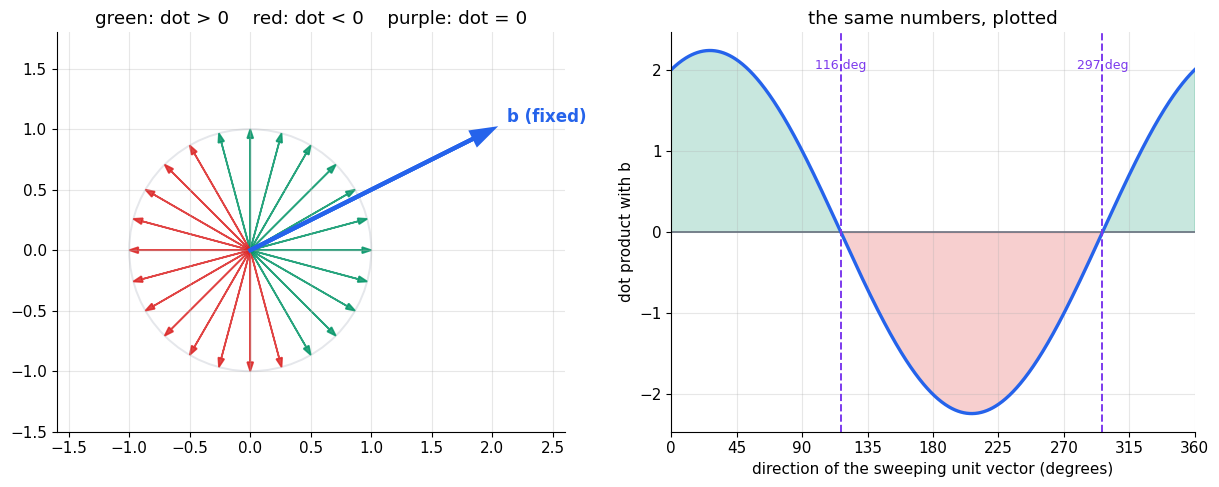

largest dot product  +2.2361 at 26.5 deg  (b itself points at 26.6 deg)
smallest dot product -2.2361 at 206.5 deg  (exactly 180 deg away)
length of b = 2.2361  -- and the peak dot product equals that, because the sweeping vector has length 1


In [22]:
import matplotlib.pyplot as plt

# ============================================================
#  Sweep a unit vector all the way round and watch the dot
#  product with a fixed vector b change sign.
# ============================================================
b_fixed = np.array([2.0, 1.0])
angles  = np.linspace(0, 2 * np.pi, 721)                 # 0 .. 360 degrees
sweep   = np.stack([np.cos(angles), np.sin(angles)], 1)  # unit vectors
dots    = sweep @ b_fixed                                # one dot product each

fig, (axL, axR) = plt.subplots(1, 2, figsize=(12.4, 5.0))

# ---- left: the arrows themselves, coloured by the sign of the dot product
axL.add_patch(plt.Circle((0, 0), 1.0, fill=False, ec=C_SOFT, lw=1.4))
for deg in range(0, 360, 15):
    th = np.radians(deg)
    v  = np.array([np.cos(th), np.sin(th)])
    d  = v @ b_fixed
    col = C_AREA if d > 1e-9 else (C_SLOPE if d < -1e-9 else C_EXACT)
    axL.arrow(0, 0, v[0], v[1], head_width=0.05, length_includes_head=True,
              color=col, alpha=0.85, lw=1.2)
axL.arrow(0, 0, b_fixed[0], b_fixed[1], head_width=0.11,
          length_includes_head=True, color=C_F, lw=3.0, zorder=5)
axL.text(b_fixed[0] * 1.06, b_fixed[1] * 1.06, "b (fixed)", color=C_F,
         fontsize=12, fontweight="bold")
axL.set_xlim(-1.6, 2.6); axL.set_ylim(-1.5, 1.8)
axL.set_aspect("equal")
axL.set_title("green: dot > 0    red: dot < 0    purple: dot = 0")

# ---- right: the meter reading
axR.axhline(0, color=C_GREY, lw=1.2)
axR.fill_between(np.degrees(angles), dots, 0, where=dots > 0,
                 color=C_AREA, alpha=0.22)
axR.fill_between(np.degrees(angles), dots, 0, where=dots < 0,
                 color=C_SLOPE, alpha=0.22)
axR.plot(np.degrees(angles), dots, color=C_F, lw=2.4)
for z in np.degrees(angles[np.where(np.diff(np.sign(dots)))[0]]):
    axR.axvline(z, color=C_EXACT, ls="--", lw=1.4)
    axR.text(z, dots.max() * 0.9, f"{z:.0f} deg", color=C_EXACT,
             ha="center", fontsize=9)
axR.set_xlabel("direction of the sweeping unit vector (degrees)")
axR.set_ylabel("dot product with b")
axR.set_xlim(0, 360); axR.set_xticks(range(0, 361, 45))
axR.set_title("the same numbers, plotted")

fig.tight_layout(); plt.show()

print(f"largest dot product  {dots.max():+.4f} at "
      f"{np.degrees(angles[dots.argmax()]):.1f} deg  "
      f"(b itself points at {np.degrees(np.arctan2(*b_fixed[::-1])):.1f} deg)")
print(f"smallest dot product {dots.min():+.4f} at "
      f"{np.degrees(angles[dots.argmin()]):.1f} deg  "
      f"(exactly 180 deg away)")
print(f"length of b = {np.linalg.norm(b_fixed):.4f}  -- and the peak dot "
      f"product equals that, because the sweeping vector has length 1")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

One vector `b` held still while a unit-length vector swings all the way round it, with the dot product between them plotted on the right.

The curve is a **cosine wave**, which is exactly what the geometric definition predicts: with the sweeping vector fixed at length 1, the dot product *is* the length of `b` times the cosine of the angle. It peaks when the sweeping arrow lines up with `b`, and the peak height is the length of `b` — printed above so you can see the two numbers match. It crosses zero at the two directions perpendicular to `b`, marked by the dashed lines, and bottoms out pointing the opposite way.

In the left panel the arrows are coloured by the sign of that reading, and the colour change happens exactly at the perpendicular directions — the boundary is a clean line through the origin, at right angles to `b`.

**The common misread:** treating a large dot product as meaning "very similar". It does not, on its own. The reading is the *product* of direction agreement and the two lengths, so a badly-aligned but very long vector can out-score a perfectly-aligned short one. Only because the sweeping vector here is pinned to length 1 does this plot show direction alone. Fixing that in general is what cosine similarity does, below.

</div>

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🗣️ In plain words

**The dot product answers: "do these two arrows broadly point the same way, and how big are they?"** — mixed into one number.

**Positive** means the angle between them is under a right angle: they agree. **Negative** means the angle is over a right angle: they oppose. **Zero** means exactly a right angle: they are unrelated in the strongest sense linear algebra has.

Every single time you see a dot product later — in a network layer, in a similarity search, in PCA — it is asking that question.

</div>

In [23]:
# ============================================================
#  The single most common numpy mistake in this whole subject.
# ============================================================
p = np.array([3.0, 4.0])
q = np.array([2.0, 1.0])

star   = p * q          # ELEMENTWISE -- a VECTOR comes out
at     = p @ q          # DOT PRODUCT -- a SCALAR comes out

print(f"p          = {p}")
print(f"q          = {q}")
print()
print(f"p * q      = {star}          <- still a vector, shape {star.shape}")
print(f"p @ q      = {at}                    <- one number, shape "
      f"{np.shape(at)}")
print(f"np.dot(p,q)= {np.dot(p, q)}")
print(f"sum(p * q) = {np.sum(p * q)}          <- the * result, then added up")
print()
print("So `*` is HALF of a dot product: it does the multiplying but not the")
print("adding. `@` does both. Neither one errors, which is the problem.")


p          = [3. 4.]
q          = [2. 1.]

p * q      = [6. 4.]          <- still a vector, shape (2,)
p @ q      = 10.0                    <- one number, shape ()
np.dot(p,q)= 10.0
sum(p * q) = 10.0          <- the * result, then added up

So `*` is HALF of a dot product: it does the multiplying but not the
adding. `@` does both. Neither one errors, which is the problem.


<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Where this trips people up

In numpy, `*` between two arrays is **elementwise multiplication**, not the dot product. `@` (or `np.dot`) is the dot product.

The trap is that **neither of them raises an error**. `p * q` happily returns a vector of the same shape as its inputs, and if you then feed that vector into something expecting a scalar, the failure surfaces hundreds of lines away — or worse, does not surface at all and just gives quietly wrong answers.

Two habits that catch it every time:

1. **Ask what shape the answer should be.** A dot product of two vectors is always a single number. If you have an array, you used the wrong operator.
2. **Print `.shape` while debugging.** Not the values — the shapes. Shape bugs hide behind plausible-looking numbers.

The same `*` versus `@` distinction returns for matrices in Part 4, where it is even easier to get away with.

</div>

### Perpendicular means the dot product is zero

Of the three cases, zero is the special one. Because
$\mathbf{a}\cdot\mathbf{b} = \|\mathbf{a}\|\|\mathbf{b}\|\cos\theta$, and
because lengths are only zero for the zero vector, the dot product of two
non-zero vectors is zero **exactly when** $\cos\theta = 0$, which is exactly
when $\theta = 90°$.

$$\mathbf{a} \perp \mathbf{b}
\qquad\Longleftrightarrow\qquad
\mathbf{a}\cdot\mathbf{b} = 0$$

This is enormously useful, because it turns a *geometric* question — "are these
at right angles?" — into an *arithmetic* one you can answer in a million
dimensions where there is no picture to look at. The symbol $\perp$ is read
"is perpendicular to", and the fancier word for it is **orthogonal**; they mean
the same thing.
<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧭 Building a perpendicular vector in 2D

In two dimensions there is a trick worth knowing: to turn $[x, y]$ by a
right angle, swap the two entries and negate one of them, giving $[-y, x]$.

Check it with the algebraic definition:
$[x, y]\cdot[-y, x] = x(-y) + y(x) = -xy + xy = 0$. Always zero, whatever $x$
and $y$ are. The next cell confirms it on random vectors.

</div>

In [24]:
# ============================================================
#  Perpendicularity tested three ways.
# ============================================================
pairs = [
    ("east and north",        np.array([1.0, 0.0]),  np.array([0.0, 1.0])),
    ("a and its rotation",    np.array([3.0, 4.0]),  np.array([-4.0, 3.0])),
    ("same direction",        np.array([3.0, 4.0]),  np.array([6.0, 8.0])),
    ("opposite directions",   np.array([3.0, 4.0]),  np.array([-3.0, -4.0])),
    ("a broadly agreeing q",  np.array([3.0, 4.0]),  np.array([2.0, 1.0])),
]

print(f"{'pair':>22} | {'a . b':>8} | {'angle':>8} | verdict")
print("-" * 62)
for name, u, v in pairs:
    d  = float(u @ v)
    ct = d / (np.linalg.norm(u) * np.linalg.norm(v))
    ang = np.degrees(np.arccos(np.clip(ct, -1, 1)))
    verdict = ("PERPENDICULAR" if abs(d) < 1e-12 else
               "agreeing" if d > 0 else "opposing")
    print(f"{name:>22} | {d:>8.2f} | {ang:>7.2f}d | {verdict}")

print()
# the swap-and-negate trick, on 1000 random vectors at once
V    = np.random.default_rng(4).normal(size=(1000, 2))
Vrot = np.stack([-V[:, 1], V[:, 0]], axis=1)      # [x,y] -> [-y,x]
dps  = np.sum(V * Vrot, axis=1)                   # dot product of each row pair
print(f"swap-and-negate on 1000 random vectors:")
print(f"  largest dot product found = {np.abs(dps).max():.2e}  (i.e. zero)")
print(f"  all perpendicular: {np.allclose(dps, 0)}")


                  pair |    a . b |    angle | verdict
--------------------------------------------------------------
        east and north |     0.00 |   90.00d | PERPENDICULAR
    a and its rotation |     0.00 |   90.00d | PERPENDICULAR
        same direction |    50.00 |    0.00d | agreeing
   opposite directions |   -25.00 |  180.00d | opposing
  a broadly agreeing q |    10.00 |   26.57d | agreeing

swap-and-negate on 1000 random vectors:
  largest dot product found = 0.00e+00  (i.e. zero)
  all perpendicular: True


<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Checked, not asserted

Perpendicularity was tested against an angle computed a completely different way — through `arccos` — and the pair whose dot product came out as exactly zero is the pair whose angle came out as a right angle. The two agree.

The swap-and-negate rule was then not merely asserted but run on a thousand random vectors at once, and the *worst* deviation from zero across all thousand is at the level of floating-point dust. Note that we checked the largest error, not the average — an average would hide a single bad case.

</div>

### Projection: how much of one vector points along another

Here is the question that makes the dot product indispensable.

You have a vector $\mathbf{a}$, and a direction given by another vector
$\mathbf{b}$. **How much of $\mathbf{a}$ points along $\mathbf{b}$?**

Picture shining a light straight down onto the line through $\mathbf{b}$ and
asking where $\mathbf{a}$'s shadow falls. That shadow is the **projection** of
$\mathbf{a}$ onto $\mathbf{b}$, and it is some multiple of $\mathbf{b}$ — call
it $t\mathbf{b}$. Our job is to find the number $t$.

**Deriving $t$.** Split $\mathbf{a}$ into two pieces: the shadow $t\mathbf{b}$,
and whatever is left over, $\mathbf{a} - t\mathbf{b}$. The defining property of
a shadow cast by a straight-down light is that the leftover piece is
**perpendicular to $\mathbf{b}$**. And we just learned what perpendicular means
in arithmetic:

$$(\mathbf{a} - t\mathbf{b}) \cdot \mathbf{b} = 0$$

The dot product distributes over addition, exactly like ordinary multiplication
does, so we can open the bracket:

$$\mathbf{a}\cdot\mathbf{b} - t\,(\mathbf{b}\cdot\mathbf{b}) = 0
\qquad\Longrightarrow\qquad
t = \frac{\mathbf{a}\cdot\mathbf{b}}{\mathbf{b}\cdot\mathbf{b}}$$

And since $\mathbf{b}\cdot\mathbf{b} = \|\mathbf{b}\|^2$, the projection itself
is

$$\text{proj}_{\mathbf{b}}(\mathbf{a})
= \frac{\mathbf{a}\cdot\mathbf{b}}{\|\mathbf{b}\|^2}\,\mathbf{b}
\qquad\text{and its signed length is}\qquad
\frac{\mathbf{a}\cdot\mathbf{b}}{\|\mathbf{b}\|}$$

Two dot products and a division. That is the entire construction, and it came
out of one demand: *the leftover must be perpendicular.*


<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🗣️ In plain words

**$t$ is "how many `b`s fit inside `a`, measured along `b`'s direction".**

The top of the fraction, $\mathbf{a}\cdot\mathbf{b}$, measures agreement between the two. The bottom, $\mathbf{b}\cdot\mathbf{b}$, divides that by how long `b` is — twice — which is exactly what is needed to cancel `b`'s own length out of the answer. If you doubled `b`, you would need half as many of them to reach the same shadow, and the formula gives you that automatically.

If you use a `b` of length 1, the bottom is 1 and it disappears: **the projection onto a unit vector is just the dot product.** That special case is the one PCA uses in Part 9, which is why Part 2 bothered with unit vectors.

</div>

In [25]:
# ============================================================
#  Projection, computed and then verified against its own
#  defining property.
# ============================================================
a = np.array([3.0, 4.0])
b = np.array([4.0, 1.0])

t          = (a @ b) / (b @ b)      # the scalar from the derivation
projection = t * b                  # the shadow itself
residual   = a - projection         # the leftover piece

print(f"a                = {a}")
print(f"b                = {b}")
print(f"t = (a.b)/(b.b)  = {t:.6f}")
print(f"projection = t*b = {projection.round(6)}")
print(f"residual  = a-t*b= {residual.round(6)}")
print()
print("-- verification 1: the residual must be perpendicular to b --")
print(f"   residual . b = {residual @ b:.2e}   -> zero: "
      f"{np.isclose(residual @ b, 0)}")
print()
print("-- verification 2: projection + residual must rebuild a --")
print(f"   projection + residual = {(projection + residual).round(6)}  -> a: "
      f"{np.allclose(projection + residual, a)}")
print()
print("-- verification 3: t*b really is the CLOSEST point on b's line --")
grid  = np.linspace(t - 2, t + 2, 40001)
dists = np.linalg.norm(a - grid[:, None] * b, axis=1)
print(f"   brute-force search over 40001 multiples of b finds the closest")
print(f"   at t = {grid[dists.argmin()]:.6f}, versus formula {t:.6f}")
print(f"   agree to 4 decimals: {np.isclose(grid[dists.argmin()], t, atol=1e-4)}")
print()
print("-- verification 4: signed length matches (a.b)/|b| --")
signed = (a @ b) / np.linalg.norm(b)
print(f"   |projection| = {np.linalg.norm(projection):.6f}, "
      f"(a.b)/|b| = {signed:.6f}")


a                = [3. 4.]
b                = [4. 1.]
t = (a.b)/(b.b)  = 0.941176
projection = t*b = [3.764706 0.941176]
residual  = a-t*b= [-0.764706  3.058824]

-- verification 1: the residual must be perpendicular to b --
   residual . b = 0.00e+00   -> zero: True

-- verification 2: projection + residual must rebuild a --
   projection + residual = [3. 4.]  -> a: True

-- verification 3: t*b really is the CLOSEST point on b's line --
   brute-force search over 40001 multiples of b finds the closest
   at t = 0.941176, versus formula 0.941176
   agree to 4 decimals: True

-- verification 4: signed length matches (a.b)/|b| --
   |projection| = 3.880570, (a.b)/|b| = 3.880570


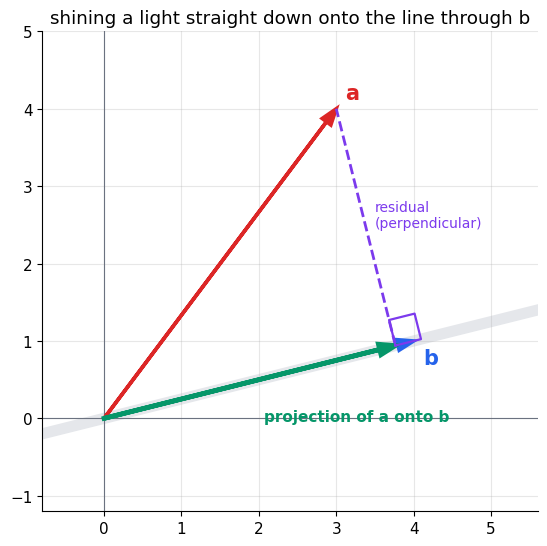

In [26]:
fig, ax = plt.subplots(figsize=(6.6, 5.6))

ray = np.linspace(-0.4, 1.5, 2)[:, None] * b
ax.plot(ray[:, 0], ray[:, 1], color=C_SOFT, lw=8, zorder=0,
        solid_capstyle="round")

ax.arrow(0, 0, b[0], b[1], head_width=0.14, length_includes_head=True,
         color=C_F, lw=2.6, zorder=3)
ax.arrow(0, 0, a[0], a[1], head_width=0.14, length_includes_head=True,
         color=C_SLOPE, lw=2.6, zorder=3)
ax.arrow(0, 0, projection[0], projection[1], head_width=0.14,
         length_includes_head=True, color=C_AREA, lw=3.4, zorder=4)
ax.plot([projection[0], a[0]], [projection[1], a[1]],
        color=C_EXACT, ls="--", lw=2.0, zorder=3)

# the little square that marks a right angle
u_along = b / np.linalg.norm(b)
u_perp  = residual / np.linalg.norm(residual)
s = 0.34
corner = projection
sq = np.array([corner, corner + s*u_along, corner + s*u_along + s*u_perp,
               corner + s*u_perp])
ax.plot(*np.vstack([sq, sq[:1]]).T, color=C_EXACT, lw=1.6, zorder=4)

ax.text(a[0] + .12, a[1] + .12, "a", color=C_SLOPE, fontsize=15, weight="bold")
ax.text(b[0] + .12, b[1] - .30, "b", color=C_F, fontsize=15, weight="bold")
ax.text(projection[0] * .55, projection[1] * .55 - .55,
        "projection of a onto b", color=C_AREA, fontsize=11, weight="bold")
ax.text((projection[0] + a[0]) / 2 + .12, (projection[1] + a[1]) / 2,
        "residual\n(perpendicular)", color=C_EXACT, fontsize=10)

ax.axhline(0, color=C_GREY, lw=.8); ax.axvline(0, color=C_GREY, lw=.8)
ax.set_xlim(-0.8, 5.6); ax.set_ylim(-1.2, 5.0)
ax.set_aspect("equal")
ax.set_title("shining a light straight down onto the line through b")
fig.tight_layout(); plt.show()


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

The red arrow `a` casting a shadow onto the grey line through the blue arrow `b`. The green arrow is that shadow — the projection — and the dashed purple segment is the residual, the part of `a` that the line through `b` cannot account for.

The small square is the right angle, and it is the whole point: the residual meets the line at exactly 90 degrees. That was not drawn in afterwards to look tidy — it is the *condition we solved* to get the formula, and the cell above confirmed it numerically by dotting the residual with `b` and getting zero.

Notice also that the green arrow is shorter than `b` here, so the multiplier `t` is less than one. It can be greater than one, and if `a` leaned the other way it would be negative and the green arrow would point backwards along the line — the projection is *signed*.

**The common misread:** thinking the projection depends on how long `b` is. It does not. Double `b` and the grey line is unchanged, so the shadow lands in exactly the same place; the formula's denominator absorbs the change. Only `b`'s **direction** matters. What *does* depend on length is the raw dot product, which is the next problem to fix.

</div>

### Cosine similarity: the dot product with the lengths divided out

The dot product mixes two things together — direction agreement and sheer size
— and often only one of them is what you want.

Suppose you want to know whether two documents are about the same topic. A long
document and a short one on the identical subject should count as *very
similar*, but the long one has bigger numbers everywhere, so its raw dot
products with everything are inflated. Length is drowning out direction.

The fix is to divide it back out. Rearranging the geometric definition:

$$\cos\theta \;=\; \frac{\mathbf{a}\cdot\mathbf{b}}{\|\mathbf{a}\|\,\|\mathbf{b}\|}$$

This is **cosine similarity**. It is the dot product of the two *unit* vectors —
the raw dot product with both lengths scaled away — and because it is a cosine
it is always between $-1$ and $+1$, whatever the vectors were:

- $+1$ — same direction exactly (however different their lengths)
- $\;\;0$ — perpendicular
- $-1$ — opposite directions

Here is the same pair of vectors judged both ways.


In [27]:
# ============================================================
#  Same direction, wildly different lengths.
# ============================================================
def cosine_similarity(u, v):
    return float(u @ v) / (np.linalg.norm(u) * np.linalg.norm(v))

base  = np.array([3.0, 4.0])          # length 5
short = np.array([0.6, 0.8])          # SAME direction, length 1
long_ = np.array([30.0, 40.0])        # SAME direction, length 50

print(f"{'pair':>28} | {'raw dot':>10} | {'cosine sim':>11} | {'angle':>7}")
print("-" * 68)
for name, u, v in [("base with the short one",  base, short),
                   ("base with the long one",   base, long_),
                   ("base with itself",         base, base)]:
    cs = cosine_similarity(u, v)
    print(f"{name:>28} | {u @ v:>10.2f} | {cs:>11.6f} | "
          f"{np.degrees(np.arccos(np.clip(cs, -1, 1))):>6.2f}d")

print()
print(f"raw dot products differ by a factor of "
      f"{(base @ long_) / (base @ short):.0f}x --")
print(f"cosine similarities are identical: "
      f"{np.isclose(cosine_similarity(base, short), cosine_similarity(base, long_))}")
print()
print("...and all three point in EXACTLY the same direction, which is what")
print("cosine similarity reports and the raw dot product completely hides.")
print()
print("scale-invariance, checked over 500 random rescalings:")
r = np.random.default_rng(7)
scales = r.uniform(0.01, 100, 500)
sims = [cosine_similarity(base, s * long_) for s in scales]
print(f"  spread of cosine similarity across all of them = "
      f"{np.ptp(sims):.2e}   (i.e. it never moved)")


                        pair |    raw dot |  cosine sim |   angle
--------------------------------------------------------------------
     base with the short one |       5.00 |    1.000000 |   0.00d
      base with the long one |     250.00 |    1.000000 |   0.00d
            base with itself |      25.00 |    1.000000 |   0.00d

raw dot products differ by a factor of 50x --
cosine similarities are identical: True

...and all three point in EXACTLY the same direction, which is what
cosine similarity reports and the raw dot product completely hides.

scale-invariance, checked over 500 random rescalings:
  spread of cosine similarity across all of them = 5.55e-16   (i.e. it never moved)


<div style="background-color: #f8d7da; border-left: 5px solid #dc3545; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🤖 Why ML cares

**This is how modern search and retrieval works.** A text embedding model turns a sentence into a vector of a few hundred or few thousand numbers. Two sentences meaning the same thing land in similar *directions*; two sentences about different things land in different directions.

To find the passage in a database that best answers a question, you embed the question and take the **cosine similarity** against every stored passage, then keep the highest. That is the entire retrieval step of a RAG system, of semantic search, of recommendation by "users like you", and of duplicate detection.

Raw dot products are used instead when the vectors have already been normalised to length 1 — and then the two are *the same operation*, which is why so many vector databases normalise on the way in and then advertise "dot product search". If your vectors are **not** normalised, a raw dot product ranks long vectors above relevant ones, and the symptom is a search engine that keeps returning the same few verbose documents no matter what you ask it.

</div>

In [28]:
# ============================================================
#  Cosine similarity on the flowers.
# ============================================================
mean_A = X[species == 0].mean(axis=0)
mean_B = X[species == 1].mean(axis=0)

print("the two species, as average flowers:")
print(f"  species A mean = {mean_A.round(3)}  ({FEATURES[0]}, {FEATURES[1]})")
print(f"  species B mean = {mean_B.round(3)}")
print()

cs_species = cosine_similarity(mean_A, mean_B)
print(f"cosine similarity between the two species means = {cs_species:.6f}")
print(f"angle between them                              = "
      f"{np.degrees(np.arccos(np.clip(cs_species, -1, 1))):.3f} degrees")
print(f"euclidean distance between them (Part 2)        = "
      f"{np.linalg.norm(mean_A - mean_B):.4f} cm")
print()

# how wide a range of ANGLES does the whole dataset occupy?
head = np.degrees(np.arctan2(X[:, 1], X[:, 0]))
print(f"every flower's direction from the origin lies between "
      f"{head.min():.2f} and {head.max():.2f} degrees")
print(f"  -- a wedge {np.ptp(head):.2f} degrees wide, out of the 360 available.")
print(f"  Every flower has positive length AND positive width, so every arrow")
print(f"  points into the same quadrant. Cosine similarity has to express all")
print(f"  the variety in this data inside that narrow sliver.")
print()

def cos_to(mu):
    return (X @ mu) / (np.linalg.norm(X, axis=1) * np.linalg.norm(mu))

angle_guess = (cos_to(mean_B) > cos_to(mean_A)).astype(int)
dist_guess  = (np.linalg.norm(X - mean_B, axis=1)
               < np.linalg.norm(X - mean_A, axis=1)).astype(int)
print("label each flower by whichever species mean it is nearer to --")
print(f"  by ANGLE    (cosine similarity): {(angle_guess == species).mean():.1%}")
print(f"  by DISTANCE (Part 2's norm)    : {(dist_guess  == species).mean():.1%}")
print("Both work here, and neither is 'the right one' -- they are answering")
print("different questions. Here is the difference between those questions:")
print()

# same flowers, same SHAPES, random overall sizes
sizes = np.random.default_rng(19).uniform(0.5, 2.0, len(X))
Xs    = X * sizes[:, None]        # each flower scaled, proportions preserved

a_s = ((Xs @ mean_B) / (np.linalg.norm(Xs, axis=1) * np.linalg.norm(mean_B)) >
       (Xs @ mean_A) / (np.linalg.norm(Xs, axis=1) * np.linalg.norm(mean_A)))
d_s = (np.linalg.norm(Xs - mean_B, axis=1)
       < np.linalg.norm(Xs - mean_A, axis=1))

print("now rescale each flower by a random factor from 0.5x to 2x -- same")
print("proportions, different overall size:")
print(f"  by ANGLE   : {(a_s.astype(int) == species).mean():.1%}   "
      f"(unchanged -- cosine cannot see size at all)")
print(f"  by DISTANCE: {(d_s.astype(int) == species).mean():.1%}   "
      f"(collapsed -- distance sees nothing else)")


the two species, as average flowers:
  species A mean = [4.976 3.399]  (petal length (cm), petal width (cm))
  species B mean = [6.586 2.899]

cosine similarity between the two species means = 0.983002
angle between them                              = 10.579 degrees
euclidean distance between them (Part 2)        = 1.6857 cm

every flower's direction from the origin lies between 16.57 and 40.99 degrees
  -- a wedge 24.42 degrees wide, out of the 360 available.
  Every flower has positive length AND positive width, so every arrow
  points into the same quadrant. Cosine similarity has to express all
  the variety in this data inside that narrow sliver.

label each flower by whichever species mean it is nearer to --
  by ANGLE    (cosine similarity): 97.5%
  by DISTANCE (Part 2's norm)    : 96.5%
Both work here, and neither is 'the right one' -- they are answering
different questions. Here is the difference between those questions:

now rescale each flower by a random factor from 0.5x to 

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Where this trips people up

**Cosine similarity is not "the better one". It is the one that throws size away** — and whether that is a feature or a catastrophe depends entirely on your data.

The experiment above makes the trade concrete. On the flowers as measured, both methods label the species well. Then every flower is rescaled to a random overall size with its proportions untouched — a big specimen and a small one of the same species. The cosine score does not move by a single digit, because rescaling a vector does not rotate it. The distance-based score falls apart, because distance sees nothing *but* size and position.

Two further things to notice, both printed above:

1. **The angle between the two species means is only a few degrees**, even though the scatter plot in Part 0 shows them plainly apart. Every flower has a positive length and a positive width, so every arrow points into the same quadrant, and the whole dataset is squeezed into a narrow wedge. Cosine similarity still separates the species here, but with almost no room to spare — and on data where the two classes differ in *size* rather than in *proportion*, that room would be zero.
2. **Cosine similarity measures the angle as seen from the origin**, and the origin of this dataset is a flower of zero centimetres by zero centimetres — a place no real flower is near, and an arbitrary one to measure from.

**Moving the origin somewhere meaningful is the fix.** That is centring, it is the last thing Part 4 does, and Part 9 depends on it. Embeddings need no such repair: they are trained to spread out around the origin in every direction, which is exactly why cosine similarity is the natural measure for them and a questionable one for raw measurements.

</div>

---

### What Part 3 built

| Idea | Formula | Used later in |
|---|---|---|
| dot product, algebraic | $\sum_i a_i b_i$ | Part 5, every matrix product |
| dot product, geometric | $\|\mathbf{a}\|\|\mathbf{b}\|\cos\theta$ | intuition everywhere |
| perpendicular | $\mathbf{a}\cdot\mathbf{b}=0$ | Parts 7, 8, 9 |
| projection | $\dfrac{\mathbf{a}\cdot\mathbf{b}}{\mathbf{b}\cdot\mathbf{b}}\,\mathbf{b}$ | Part 9, PCA |
| cosine similarity | $\dfrac{\mathbf{a}\cdot\mathbf{b}}{\|\mathbf{a}\|\|\mathbf{b}\|}$ | embeddings, retrieval |

One operation. Five uses. And the reason it can do all five is the theorem we
proved: the arithmetic definition and the geometric definition are the same
thing, so anything you can compute you can also picture.

**Next**, in Part 4, we stop looking at single vectors and start stacking them.
A matrix is what you get when you put many vectors in a block — and once we can
read a matrix, Part 5 will show that multiplying two of them is nothing but a
whole grid of the dot products we just built.

---


---

# 4️⃣ Matrices: tables of numbers that DO something

The title is a promise, and it will be kept — in **Part 6**, where a matrix
turns out to be a *verb*: something that stretches, rotates and squashes space.

But you cannot read a verb you cannot spell. So this part is the boring,
essential half: **a matrix as an object**. What its shape means, how to reach
inside it, which special ones have names, what transposing does, and how a
table of measurements becomes a matrix. Get this wrong and every later part is
a debugging session.

A **matrix** is a rectangular block of numbers, written with capital letters:

$$\mathbf{A} = \begin{bmatrix} A_{11} & A_{12} & A_{13} \\
A_{21} & A_{22} & A_{23} \end{bmatrix}$$

Its **shape** is written *rows* $\times$ *columns*. The matrix above is
$2 \times 3$: two rows, three columns. A single entry is written $A_{ij}$, said
"A i j", meaning **row $i$, column $j$** — and that order is not negotiable.


In [29]:
# ============================================================
#  Shape, rows, columns, and reaching inside.
# ============================================================
import numpy as np
import matplotlib.pyplot as plt

A = np.array([[10.0, 20.0, 30.0],
              [40.0, 50.0, 60.0]])

print("A =")
print(A)
print()
print(f"A.shape   = {A.shape}   -> ({A.shape[0]} rows, {A.shape[1]} columns)")
print(f"A.ndim    = {A.ndim}        -> a matrix is a 2-dimensional array")
print(f"A.size    = {A.size}        -> {A.shape[0]} * {A.shape[1]} numbers in total")
print()
print("-- indexing is [row, column], ALWAYS in that order --")
for i in range(A.shape[0]):
    for j in range(A.shape[1]):
        print(f"   A[{i}, {j}]  = {A[i, j]:>5.1f}   (row {i}, column {j})")

print()
print(f"A[0, 2] = {A[0, 2]}   <- row 0, column 2")
print(f"A[2, 0] would ask for row 2 of a 2-row matrix. Watch:")
try:
    A[2, 0]
except IndexError as e:
    print(f"   IndexError: {e}")


A =
[[10. 20. 30.]
 [40. 50. 60.]]

A.shape   = (2, 3)   -> (2 rows, 3 columns)
A.ndim    = 2        -> a matrix is a 2-dimensional array
A.size    = 6        -> 2 * 3 numbers in total

-- indexing is [row, column], ALWAYS in that order --
   A[0, 0]  =  10.0   (row 0, column 0)
   A[0, 1]  =  20.0   (row 0, column 1)
   A[0, 2]  =  30.0   (row 0, column 2)
   A[1, 0]  =  40.0   (row 1, column 0)
   A[1, 1]  =  50.0   (row 1, column 1)
   A[1, 2]  =  60.0   (row 1, column 2)

A[0, 2] = 30.0   <- row 0, column 2
A[2, 0] would ask for row 2 of a 2-row matrix. Watch:
   IndexError: index 2 is out of bounds for axis 0 with size 2


<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Where this trips people up

**Rows before columns. Every time.** `A[i, j]` is row `i`, column `j`, and so is the mathematical notation $A_{ij}$.

You saw above that reversing the order on a non-square matrix raises an `IndexError`, which is the friendly case — the error arrives immediately and names the problem. On a **square** matrix it raises nothing at all. `A[2, 0]` and `A[0, 2]` are both perfectly legal, both return a number, and only one of them is the number you meant.

This is why so much numerical code has bugs that show up as "the results are subtly wrong" rather than as a crash. Two defences: **test your indexing on a non-square matrix first**, where mistakes are loud, and get into the habit of saying "row, column" out loud as you type the bracket.

</div>

### The data matrix: rows are examples, columns are features

A matrix earns its keep the moment you put real measurements in it, and there
is one overwhelmingly standard way to do that:

> **One row per example. One column per feature.**

Our flowers follow it. `X` has one row for each of the flowers and one column
for each measurement, so `X` is (number of flowers) $\times$ (number of
measurements). One row **is a vector** in exactly the sense of Part 1 — it is
one flower. One column is one measurement across the whole dataset.

You will see this shape written as $n \times d$: $n$ for the number of samples,
$d$ for the number of dimensions or features. Almost every library you will
ever use — scikit-learn, PyTorch, pandas — expects data in that orientation.
<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🔁 It is a convention, not a law

Plenty of textbooks, and a good deal of signal-processing and statistics
code, use the **other** orientation: one *column* per example, so the data
matrix is $d \times n$. Neither is wrong. But the two are transposes of each
other, and mixing them up is genuinely the most common error in machine
learning code.

The tell is a shape error you did not expect, or — far worse — a computation
that runs happily and returns nonsense because both dimensions happened to be
compatible. **Print `.shape` and say out loud what each number counts.**

</div>

In [30]:
# ============================================================
#  Reading X as a data matrix.
# ============================================================
print(f"X.shape = {X.shape}")
print(f"   {X.shape[0]:>3} rows    -> {X.shape[0]} flowers      (the examples)")
print(f"   {X.shape[1]:>3} columns -> {X.shape[1]} measurements (the features)")
print()

print(f"{'row':>4} | {FEATURES[0]:>18} | {FEATURES[1]:>17} | species")
print("-" * 60)
for i in list(range(4)) + [None] + [len(X) - 1]:
    if i is None:
        print(f"{'...':>4} | {'...':>18} | {'...':>17} | ...")
        continue
    print(f"{i:>4} | {X[i, 0]:>18.3f} | {X[i, 1]:>17.3f} | "
          f"{'A' if species[i] == 0 else 'B'}")

print()
print("-- a ROW is one flower, a whole example --")
print(f"   X[0, :]  = {X[0, :].round(3)}   shape {X[0, :].shape}")
print(f"   that is one flower: {X[0,0]:.2f} cm long, {X[0,1]:.2f} cm wide")
print()
print("-- a COLUMN is one measurement, across every flower --")
print(f"   X[:, 0]  = {np.array2string(X[:, 0][:5], precision=2)} ... "
      f"shape {X[:, 0].shape}")
print(f"   that is the {FEATURES[0]} of all {X.shape[0]} flowers")
print()
print(f"both come out as 1-D arrays, NOT as 1-row or 1-column matrices:")
print(f"   X[0, :].ndim = {X[0, :].ndim},  X[:, 0].ndim = {X[:, 0].ndim}")


X.shape = (200, 2)
   200 rows    -> 200 flowers      (the examples)
     2 columns -> 2 measurements (the features)

 row |  petal length (cm) |  petal width (cm) | species
------------------------------------------------------------
   0 |              4.189 |             1.933 | A
   1 |              4.840 |             3.093 | A
   2 |              5.291 |             3.605 | A
   3 |              6.193 |             4.426 | A
 ... |                ... |               ... | ...
 199 |              6.596 |             2.705 | B

-- a ROW is one flower, a whole example --
   X[0, :]  = [4.189 1.933]   shape (2,)
   that is one flower: 4.19 cm long, 1.93 cm wide

-- a COLUMN is one measurement, across every flower --
   X[:, 0]  = [4.19 4.84 5.29 6.19 5.03] ... shape (200,)
   that is the petal length (cm) of all 200 flowers

both come out as 1-D arrays, NOT as 1-row or 1-column matrices:
   X[0, :].ndim = 1,  X[:, 0].ndim = 1


<div style="background-color: #f8d7da; border-left: 5px solid #dc3545; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🤖 Why ML cares

**`X` of shape `(n_samples, n_features)` is the interface to essentially every ML library.** `model.fit(X, y)` in scikit-learn, a batch tensor in PyTorch, a dataframe in pandas — all of them mean rows-are-examples.

When a neural network processes a *batch*, the batch is exactly this matrix: 64 images means 64 rows. The reason the layer equation is often written $\mathbf{Y} = \mathbf{X}\mathbf{W} + \mathbf{b}$ rather than the textbook's $\mathbf{y} = \mathbf{W}\mathbf{x} + \mathbf{b}$ is precisely this convention — the data is on the left because it is stored with examples along the rows.

Two practical consequences. First, **an error message about shapes is usually an orientation error**, not a maths error; read it as "you gave me the transpose". Second, when a dataset arrives with features down the rows — common in genomics and in older signal-processing formats — transpose it *once, at load time*, and never think about it again.

</div>

### The matrices that have names

A handful of shapes come up so often that they are named. You do not need to
memorise these — you need to recognise them, because the names are how people
will describe matrices to you.

| Name | What it looks like | Why anyone cares |
|---|---|---|
| **zero** $\mathbf{0}$ | every entry $0$ | the "add nothing" matrix |
| **identity** $\mathbf{I}$ | $1$s down the diagonal, $0$ elsewhere | the "do nothing" matrix |
| **diagonal** | non-zero only on the diagonal | stretches each axis independently |
| **symmetric** | $A_{ij} = A_{ji}$; a mirror across the diagonal | covariance matrices are these — Part 8 |
| **upper triangular** | zeros *below* the diagonal | what solving a system leaves behind — Part 7 |
| **lower triangular** | zeros *above* the diagonal | the other half of the same story |

The **diagonal** of a matrix means the entries $A_{11}, A_{22}, A_{33}, \dots$
— the ones whose row index equals their column index, running from the top-left
corner down to the bottom-right.


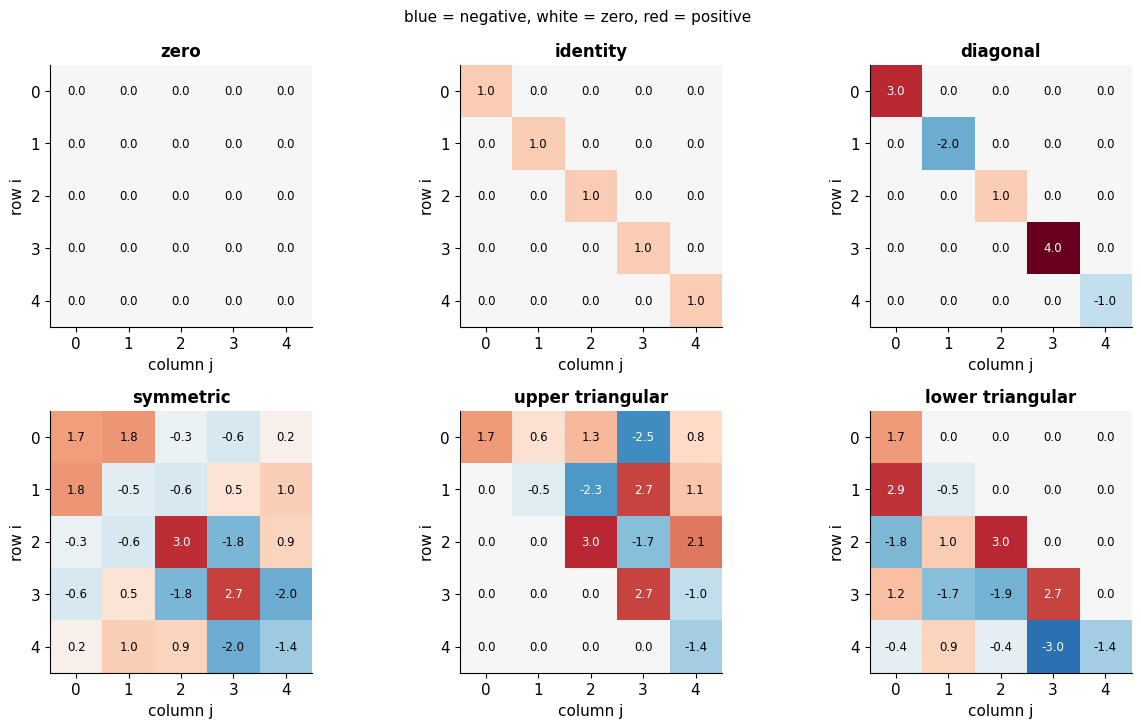

symmetric?  Symm == Symm.T : True
            M    == M.T    : False   (the raw one is not)
upper triangular: everything below the diagonal is zero: True
lower triangular: everything above the diagonal is zero: True
diagonal entries of Diag = [ 3. -2.  1.  4. -1.]


In [31]:
# ============================================================
#  Six named matrices, built and drawn.
# ============================================================
k = 5
Zero  = np.zeros((k, k))
Iden  = np.eye(k)
Diag  = np.diag([3.0, -2.0, 1.0, 4.0, -1.0])

RNG_M = np.random.default_rng(21)
M     = RNG_M.uniform(-3, 3, (k, k))
Symm  = (M + M.T) / 2                    # mirror-average makes it symmetric
Upper = np.triu(M.round(1))
Lower = np.tril(M.round(1))

panels = [("zero", Zero), ("identity", Iden), ("diagonal", Diag),
          ("symmetric", Symm), ("upper triangular", Upper),
          ("lower triangular", Lower)]

fig, axes = plt.subplots(2, 3, figsize=(12.6, 7.4))
for ax, (name, Mx) in zip(axes.ravel(), panels):
    ax.imshow(Mx, cmap="RdBu_r", vmin=-4, vmax=4)
    for i in range(k):
        for j in range(k):
            ax.text(j, i, f"{Mx[i, j]:.1f}", ha="center", va="center",
                    fontsize=8.5,
                    color="white" if abs(Mx[i, j]) > 2.2 else "black")
    ax.set_title(name, fontsize=12, fontweight="bold")
    ax.set_xticks(range(k)); ax.set_yticks(range(k))
    ax.set_xlabel("column j"); ax.set_ylabel("row i")
    ax.grid(False)
fig.suptitle("blue = negative, white = zero, red = positive", fontsize=11)
fig.tight_layout(); plt.show()

print(f"symmetric?  Symm == Symm.T : {np.allclose(Symm, Symm.T)}")
print(f"            M    == M.T    : {np.allclose(M, M.T)}   (the raw one is not)")
print(f"upper triangular: everything below the diagonal is zero: "
      f"{np.allclose(np.tril(Upper, -1), 0)}")
print(f"lower triangular: everything above the diagonal is zero: "
      f"{np.allclose(np.triu(Lower,  1), 0)}")
print(f"diagonal entries of Diag = {np.diag(Diag)}")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Six matrices drawn as pictures rather than printed as numbers, with red for positive, blue for negative and white for zero. The numbers are overlaid so you can check the colours against them.

Seeing a matrix as an image is a genuinely useful habit: the *structure* jumps out in a way it never does from a printout. The identity is a single red streak on white; the two triangular matrices are each other's reflection with a clean diagonal edge; the symmetric one is visibly a mirror image across the top-left-to-bottom-right diagonal, which is the definition made visible.

**The common misread:** thinking the diagonal runs from bottom-left to top-right, the way a graph's diagonal often does. It does not. In a matrix the diagonal is the set of entries where the row index equals the column index, and because row 0 is drawn at the **top**, that runs from top-left downwards to the right. Every one of these pictures has the row index increasing downwards — the opposite of a normal y-axis — and this catches people out constantly when reading `imshow` plots of matrices.

</div>

In [32]:
# ============================================================
#  The identity really does nothing. Verified, not asserted.
# ============================================================
I3 = np.eye(3)
v  = np.array([7.0, -2.0, 0.5])
B  = np.random.default_rng(5).normal(size=(3, 3)).round(2)

print("I =")
print(I3)
print()
print(f"v      = {v}")
print(f"I @ v  = {I3 @ v}      unchanged: {np.allclose(I3 @ v, v)}")
print()
print(f"I @ B == B : {np.allclose(I3 @ B, B)}")
print(f"B @ I == B : {np.allclose(B @ I3, B)}   (works from both sides)")
print()
print("-- a diagonal matrix scales each coordinate by its own factor --")
D = np.diag([10.0, 100.0, 1000.0])
print(f"D @ v = {D @ v}")
print(f"which is just v times the diagonal, entry by entry:")
print(f"        {np.diag(D) * v}   same: {np.allclose(D @ v, np.diag(D) * v)}")
print()
print("(the @ operator is matrix multiplication -- Part 5 explains what it")
print(" is doing. For now we only need that it exists, so we can check")
print(" these claims instead of asking you to believe them.)")


I =
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]

v      = [ 7.  -2.   0.5]
I @ v  = [ 7.  -2.   0.5]      unchanged: True

I @ B == B : True
B @ I == B : True   (works from both sides)

-- a diagonal matrix scales each coordinate by its own factor --
D @ v = [  70. -200.  500.]
which is just v times the diagonal, entry by entry:
        [  70. -200.  500.]   same: True

(the @ operator is matrix multiplication -- Part 5 explains what it
 is doing. For now we only need that it exists, so we can check
 these claims instead of asking you to believe them.)


<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Checked, not asserted

The identity's defining property — that multiplying by it changes nothing — was tested on a vector and on a random matrix, from the left and from the right, and confirmed each time.

The claim about diagonal matrices was checked a second way too: `D @ v` was compared against simply multiplying `v` entry-by-entry by the diagonal entries, and the two agree. So "a diagonal matrix scales each coordinate independently" is not a slogan; it is arithmetic you just watched match.

This is the reason $\mathbf{I}$ is called the identity: it plays the same role for matrices that the number $1$ plays for ordinary multiplication. Part 7 needs exactly this to define what an *inverse* is.

</div>

### Transpose: flipping rows into columns

The **transpose** of $\mathbf{A}$, written $\mathbf{A}^T$ and said "A
transpose", is the matrix you get by reflecting across the diagonal — row $i$
becomes column $i$:

$$(\mathbf{A}^T)_{ij} = A_{ji}$$

An $m \times n$ matrix transposes into an $n \times m$ one. Two facts about it
matter, and the second is the one people get wrong:

$$(\mathbf{A}^T)^T = \mathbf{A}
\qquad\qquad
(\mathbf{A}\mathbf{B})^T = \mathbf{B}^T\mathbf{A}^T$$

The first is obvious — flip twice and you are back where you started. The
second **reverses the order**, and it is not obvious at all. Both are checked
numerically below.


<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🗣️ In plain words

**Transposing swaps the meaning of "row" and "column".** The entry that was in row 2, column 5 is now in row 5, column 2, and nothing else about it changes — no number is altered, only its address.

For the data matrix that means: `X` is flowers-down-the-rows, and `X.T` is flowers-across-the-columns. Same measurements, other orientation.

**The reversal rule** $(\mathbf{AB})^T = \mathbf{B}^T\mathbf{A}^T$ says that when you transpose a product you must also **turn the product around**. The reason is shape bookkeeping: if $\mathbf{A}$ is $m\times n$ and $\mathbf{B}$ is $n\times p$, then $\mathbf{A}^T$ is $n\times m$ and $\mathbf{B}^T$ is $p\times n$ — and $\mathbf{A}^T\mathbf{B}^T$ does not even *fit together*, while $\mathbf{B}^T\mathbf{A}^T$ does.

</div>

In [33]:
# ============================================================
#  Transpose, and the two identities.
# ============================================================
A = np.array([[10.0, 20.0, 30.0],
              [40.0, 50.0, 60.0]])

print("A =");     print(A);   print(f"shape {A.shape}")
print("A.T =");   print(A.T); print(f"shape {A.T.shape}")
print()
print("entry by entry, (A.T)[j, i] should equal A[i, j]:")
for i in range(A.shape[0]):
    for j in range(A.shape[1]):
        print(f"   A[{i},{j}] = {A[i,j]:>5.1f}   A.T[{j},{i}] = {A.T[j,i]:>5.1f}"
              f"   match: {A[i,j] == A.T[j,i]}")

print()
print(f"-- identity 1:  (A.T).T == A  --")
print(f"   {np.allclose(A.T.T, A)}")

print()
print(f"-- identity 2:  (A @ B).T == B.T @ A.T  --")
Bm = np.random.default_rng(31).normal(size=(3, 4)).round(2)   # 3 x 4
print(f"   A is {A.shape}, B is {Bm.shape}, so A @ B is {(A @ Bm).shape}")
print(f"   (A @ B).T   is {(A @ Bm).T.shape}")
print(f"   B.T @ A.T   is {(Bm.T @ A.T).shape}")
print(f"   equal: {np.allclose((A @ Bm).T, Bm.T @ A.T)}")

print()
print("   and the WRONG order, A.T @ B.T, cannot even be formed:")
try:
    A.T @ Bm.T
except ValueError as e:
    print(f"   ValueError: {e}")


A =
[[10. 20. 30.]
 [40. 50. 60.]]
shape (2, 3)
A.T =
[[10. 40.]
 [20. 50.]
 [30. 60.]]
shape (3, 2)

entry by entry, (A.T)[j, i] should equal A[i, j]:
   A[0,0] =  10.0   A.T[0,0] =  10.0   match: True
   A[0,1] =  20.0   A.T[1,0] =  20.0   match: True
   A[0,2] =  30.0   A.T[2,0] =  30.0   match: True
   A[1,0] =  40.0   A.T[0,1] =  40.0   match: True
   A[1,1] =  50.0   A.T[1,1] =  50.0   match: True
   A[1,2] =  60.0   A.T[2,1] =  60.0   match: True

-- identity 1:  (A.T).T == A  --
   True

-- identity 2:  (A @ B).T == B.T @ A.T  --
   A is (2, 3), B is (3, 4), so A @ B is (2, 4)
   (A @ B).T   is (4, 2)
   B.T @ A.T   is (4, 2)
   equal: True

   and the WRONG order, A.T @ B.T, cannot even be formed:
   ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 4 is different from 2)


<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Where this trips people up

$(\mathbf{AB})^T = \mathbf{B}^T\mathbf{A}^T$, **not** $\mathbf{A}^T\mathbf{B}^T$. The order flips.

On the non-square matrices above, getting it wrong raises a `ValueError` immediately, because the shapes genuinely do not fit. That is lucky. On **square** matrices the wrong version has the right shape, runs without complaint, and returns a different matrix — so the bug survives all the way into your results.

The same reversal shows up again for inverses in Part 7 — $(\mathbf{AB})^{-1} = \mathbf{B}^{-1}\mathbf{A}^{-1}$ — for the same underlying reason. A useful mental image: undoing "put on socks, then put on shoes" means "take off shoes, then take off socks". Reversing an ordered pair of operations reverses their order.

</div>

### Adding matrices, and scaling them

These two are as simple as they look, and they work exactly like they did for
vectors in Part 2 — one entry at a time:

$$(\mathbf{A} + \mathbf{B})_{ij} = A_{ij} + B_{ij}
\qquad\qquad
(c\,\mathbf{A})_{ij} = c\,A_{ij}$$

The only rule is the shape rule: **you can only add matrices of identical
shape.** There is no sensible way to add a $2\times3$ to a $3\times2$, and
numpy will refuse.

What is *not* elementwise is multiplication — and that is where the whole
subject gets interesting, and where beginners get hurt.


<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🗣️ In plain words

**To add two matrices, add the numbers that sit in the same place.** The entry in row 1 column 3 of the answer is the sum of the two entries in row 1 column 3. Nothing moves; nothing combines across positions.

**To scale a matrix, multiply every entry by the same number.** Again, nothing moves.

Because both operations act position by position, both require the two matrices to have the *same* shape — there is no "same place" otherwise.

</div>

In [34]:
# ============================================================
#  Addition, scaling, and the error when shapes disagree.
# ============================================================
P = np.array([[1.0, 2.0],
              [3.0, 4.0]])
Q = np.array([[10.0, 20.0],
              [30.0, 40.0]])

print("P + Q  (entry by entry) =");  print(P + Q)
print(f"check corner by hand: P[1,0] + Q[1,0] = {P[1,0]} + {Q[1,0]} = "
      f"{P[1,0] + Q[1,0]}, and (P+Q)[1,0] = {(P + Q)[1,0]}")
print()
print("3 * P =");  print(3 * P)
print(f"check: every entry tripled: {np.allclose(3 * P, P + P + P)}")
print()
print("-- now a deliberate shape mismatch --")
R = np.ones((3, 2))
print(f"P is {P.shape}, R is {R.shape}. Adding them:")
try:
    P + R
except ValueError as e:
    print(f"   ValueError: {e}")
print()
print("Read that message carefully: numpy names both shapes and tells you")
print("which dimension it could not reconcile. Nearly every shape bug you")
print("will ever hit is solved by reading this sentence instead of guessing.")


P + Q  (entry by entry) =
[[11. 22.]
 [33. 44.]]
check corner by hand: P[1,0] + Q[1,0] = 3.0 + 30.0 = 33.0, and (P+Q)[1,0] = 33.0

3 * P =
[[ 3.  6.]
 [ 9. 12.]]
check: every entry tripled: True

-- now a deliberate shape mismatch --
P is (2, 2), R is (3, 2). Adding them:
   ValueError: operands could not be broadcast together with shapes (2,2) (3,2) 

Read that message carefully: numpy names both shapes and tells you
which dimension it could not reconcile. Nearly every shape bug you
will ever hit is solved by reading this sentence instead of guessing.


In [35]:
# ============================================================
#  * versus @ , on matrices. Same shapes in, same shape out,
#  completely different answers, no error either way.
# ============================================================
star = P * Q       # ELEMENTWISE product (a.k.a. Hadamard product)
at   = P @ Q       # MATRIX product -- Part 5

print("P =");        print(P)
print("Q =");        print(Q)
print()
print("P * Q   (elementwise) =");    print(star)
print(f"   e.g. top-left is {P[0,0]} * {Q[0,0]} = {P[0,0]*Q[0,0]}")
print()
print("P @ Q   (matrix product) =");  print(at)
print(f"   e.g. top-left is the dot product of P's first ROW with Q's first")
print(f"        COLUMN: {P[0,:]} . {Q[:,0]} = {P[0,:] @ Q[:,0]}")
print()
print(f"both results have shape {star.shape} and {at.shape} -- identical.")
print(f"are they the same matrix?  {np.array_equal(star, at)}")
print(f"largest disagreement: {np.abs(star - at).max()}")


P =
[[1. 2.]
 [3. 4.]]
Q =
[[10. 20.]
 [30. 40.]]

P * Q   (elementwise) =
[[ 10.  40.]
 [ 90. 160.]]
   e.g. top-left is 1.0 * 10.0 = 10.0

P @ Q   (matrix product) =
[[ 70. 100.]
 [150. 220.]]
   e.g. top-left is the dot product of P's first ROW with Q's first
        COLUMN: [1. 2.] . [10. 30.] = 70.0

both results have shape (2, 2) and (2, 2) -- identical.
are they the same matrix?  False
largest disagreement: 60.0


<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Where this trips people up

**`*` is elementwise. `@` is matrix multiplication.** For square matrices of the same size they take the same inputs and return the same shape, so **nothing will ever tell you that you picked the wrong one** — you will simply get a different, wrong answer, and it will look entirely plausible.

This is the matrix version of the trap from Part 3, and it is worse here because square matrices are so common. `np.dot` and `np.matmul` are the same thing as `@`; `np.multiply` is the same thing as `*`.

The elementwise product is not a mistake in itself — it has a name, the **Hadamard product**, written $\mathbf{A} \odot \mathbf{B}$, and it is genuinely used (masking, gating in an LSTM, applying dropout). But it is a *different operation*, and when a paper writes $\mathbf{A}\mathbf{B}$ it almost always means `@`.

**Habit worth forming:** when you translate a formula into code, ask "should the answer's shape depend on the *inner* dimensions?" If yes, you want `@`.

</div>

### Broadcasting: numpy's helpful, dangerous shortcut

Strictly, `X + row` is nonsense: you cannot add a vector to a matrix, they are
different shapes. But this is such a common thing to *want* — subtract the mean
of each column from every row, add a bias to every example — that numpy allows
it, by silently **stretching** the smaller array to fit.

The rule numpy uses: compare the shapes from the **right-hand end**, and at
each position the two sizes must either be equal, or one of them must be 1 (or
missing entirely, in which case it is treated as 1). Any dimension of size 1 is
then repeated as many times as needed.

```
X       (200, 2)
row        ( 2,)     <- treated as (1, 2), then the 1 is stretched to 200
result  (200, 2)     <- row added to every one of the 200 rows
```

This is enormously convenient and it is also the source of a whole genre of
silent bug, because **stretching that you did not intend still succeeds.**


In [36]:
# ============================================================
#  Broadcasting: the useful case, then two traps.
# ============================================================
G   = np.array([[1.0, 2.0, 3.0],
                [4.0, 5.0, 6.0],
                [7.0, 8.0, 9.0]])
row = np.array([100.0, 200.0, 300.0])

print("G =");            print(G)
print(f"row = {row}   shape {row.shape}")
print()
print("G + row  -- row is added to EVERY row of G:")
print(G + row)
print(f"   check row 2 by hand: {G[2]} + {row} = {G[2] + row}")
print()

print("=" * 62)
print("TRAP 1: you wanted to add it to every COLUMN, not every row.")
print("=" * 62)
print("G + row              (adds along the rows):")
print(G + row)
print()
print("G + row[:, None]     (row reshaped to a column, adds down the columns):")
print(G + row[:, None])
print(f"   row[:, None] has shape {row[:, None].shape} -- a genuine column")
print()
print("Both ran. Both returned a 3x3. Only one is what you asked for, and")
print("numpy has no way to know which.")


G =
[[1. 2. 3.]
 [4. 5. 6.]
 [7. 8. 9.]]
row = [100. 200. 300.]   shape (3,)

G + row  -- row is added to EVERY row of G:
[[101. 202. 303.]
 [104. 205. 306.]
 [107. 208. 309.]]
   check row 2 by hand: [7. 8. 9.] + [100. 200. 300.] = [107. 208. 309.]

TRAP 1: you wanted to add it to every COLUMN, not every row.
G + row              (adds along the rows):
[[101. 202. 303.]
 [104. 205. 306.]
 [107. 208. 309.]]

G + row[:, None]     (row reshaped to a column, adds down the columns):
[[101. 102. 103.]
 [204. 205. 206.]
 [307. 308. 309.]]
   row[:, None] has shape (3, 1) -- a genuine column

Both ran. Both returned a 3x3. Only one is what you asked for, and
numpy has no way to know which.


In [37]:
# ============================================================
#  TRAP 2: the accidental outer product of shapes.
#  This one is far nastier -- the OUTPUT SHAPE changes, and
#  people miss it because the numbers still look reasonable.
# ============================================================
u = np.array([1.0, 2.0, 3.0])          # shape (3,)
w = np.array([[10.0], [20.0], [30.0]]) # shape (3, 1) -- a column, not a vector

print(f"u shape {u.shape}:  {u}")
print(f"w shape {w.shape}:")
print(w)
print()
print("You meant elementwise subtraction of two length-3 things. You get:")
result = u - w
print(result)
print(f"   shape {result.shape}  <-- NOT (3,). Every u against every w.")
print()
print("What you almost certainly wanted:")
right = u - w.ravel()
print(f"   u - w.ravel() = {right}   shape {right.shape}")
print()
print("=" * 62)
print("HOW TO CATCH IT: assert the shape you expect, before using the result.")
print("=" * 62)
def safe_subtract(p, q):
    out = p - q
    if out.shape != np.shape(p):
        raise ValueError(f"broadcast changed the shape: {np.shape(p)} -> "
                         f"{out.shape}. Did you mean .ravel() or [:, None]?")
    return out

try:
    safe_subtract(u, w)
except ValueError as e:
    print(f"caught: {e}")
print(f"and the correct call passes: {safe_subtract(u, w.ravel())}")


u shape (3,):  [1. 2. 3.]
w shape (3, 1):
[[10.]
 [20.]
 [30.]]

You meant elementwise subtraction of two length-3 things. You get:
[[ -9.  -8.  -7.]
 [-19. -18. -17.]
 [-29. -28. -27.]]
   shape (3, 3)  <-- NOT (3,). Every u against every w.

What you almost certainly wanted:
   u - w.ravel() = [ -9. -18. -27.]   shape (3,)

HOW TO CATCH IT: assert the shape you expect, before using the result.
caught: broadcast changed the shape: (3,) -> (3, 3). Did you mean .ravel() or [:, None]?
and the correct call passes: [ -9. -18. -27.]


<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Where this trips people up

Broadcasting fails **loudly** when the shapes are outright incompatible, and **silently** when they happen to be compatible in a way you did not intend. The second is the one that costs days.

The two classic silent cases are both above:

1. **A 1-D array is treated as a row, never a column.** If you want it used as a column, you must say so with `v[:, None]` (or `v.reshape(-1, 1)`).
2. **Shape `(n,)` combined with shape `(n, 1)` produces `(n, n)`** — an entire matrix where you expected a vector. With `n` in the hundreds you will not notice from the printed output, but memory use explodes and every downstream number is wrong.

**The defence is to check shapes, not values.** `assert result.shape == (n, d)` after any broadcast operation costs one line and catches the whole family. A stray `.ravel()` or `[:, None]` is the usual fix — and the usual cause.

</div>

### Mean-centring: the one thing we do to the flowers before everything else

We now have every tool needed for an operation Parts 8 and 9 depend on
completely.

**Centring** means shifting the whole cloud of data so that its average sits at
the origin. For each column — that is, for each measurement — you compute the
mean over all the examples, then subtract it from every entry of that column:

$$\bar{x}_j = \frac{1}{n}\sum_{i=1}^{n} X_{ij}
\qquad\qquad
(\mathbf{X}_c)_{ij} = X_{ij} - \bar{x}_j$$

In code that is a mean along axis 0 and one broadcast subtraction. The point of
doing it is that afterwards, *directions from the origin become meaningful* —
which, as Part 3's final gotcha showed, they were not before. Covariance
(Part 8) and PCA (Part 9) are both statements about a centred cloud, and both
give wrong answers on uncentred data.


<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🗣️ In plain words

**Centring is picking a better place to stand.** The measurements were given to us relative to zero centimetres, which is a location no flower is anywhere near, so all the interesting variation was crammed off in one corner far from the origin.

After centring, each number answers a more useful question: *how far above or below average is this flower on this measurement?* Positive means bigger than average, negative means smaller, and zero means exactly typical.

Nothing about the *shape* of the cloud changes — every distance between two flowers is exactly what it was, because every point moved by the same amount. Only the origin moved.

</div>

In [38]:
# ============================================================
#  Mean-centring the flower matrix.
# ============================================================
col_means = X.mean(axis=0)          # axis=0 -> average DOWN each column
Xc        = X - col_means           # broadcast: (200,2) - (2,) -> (200,2)

print(f"X.shape         = {X.shape}")
print(f"col_means.shape = {col_means.shape}   <- one mean per feature")
print(f"Xc.shape        = {Xc.shape}   <- shape unchanged, as it must be")
assert Xc.shape == X.shape, "broadcasting changed the shape"
print()
print(f"column means BEFORE centring: {col_means.round(4)}")
print(f"column means AFTER  centring: "
      f"{np.array2string(Xc.mean(axis=0), precision=3)}   <- not rounded")
print(f"are they zero?  {np.allclose(Xc.mean(axis=0), 0)}")
print(f"largest surviving mean = {np.abs(Xc.mean(axis=0)).max():.3e}  "
      f"(floating-point dust)")
print()
print("-- distances between flowers are untouched --")
d_before = np.linalg.norm(X[0]  - X[1])
d_after  = np.linalg.norm(Xc[0] - Xc[1])
print(f"   distance flower 0 to flower 1, before = {d_before:.10f}")
print(f"   distance flower 0 to flower 1, after  = {d_after:.10f}")
print(f"   identical: {np.isclose(d_before, d_after)}")
print(f"   and for ALL pairs of the first 50 flowers: "
      f"{np.allclose(np.linalg.norm(X[:50,None]-X[None,:50], axis=2), np.linalg.norm(Xc[:50,None]-Xc[None,:50], axis=2))}")
print()
print("-- but distances from the ORIGIN change completely, which is the point --")
print(f"   mean distance from origin, before = {np.linalg.norm(X,  axis=1).mean():.4f}")
print(f"   mean distance from origin, after  = {np.linalg.norm(Xc, axis=1).mean():.4f}")


X.shape         = (200, 2)
col_means.shape = (2,)   <- one mean per feature
Xc.shape        = (200, 2)   <- shape unchanged, as it must be

column means BEFORE centring: [5.7813 3.1492]
column means AFTER  centring: [2.971e-15 1.905e-15]   <- not rounded
are they zero?  True
largest surviving mean = 2.971e-15  (floating-point dust)

-- distances between flowers are untouched --
   distance flower 0 to flower 1, before = 1.3302836611
   distance flower 0 to flower 1, after  = 1.3302836611
   identical: True
   and for ALL pairs of the first 50 flowers: True

-- but distances from the ORIGIN change completely, which is the point --
   mean distance from origin, before = 6.6178
   mean distance from origin, after  = 1.0964


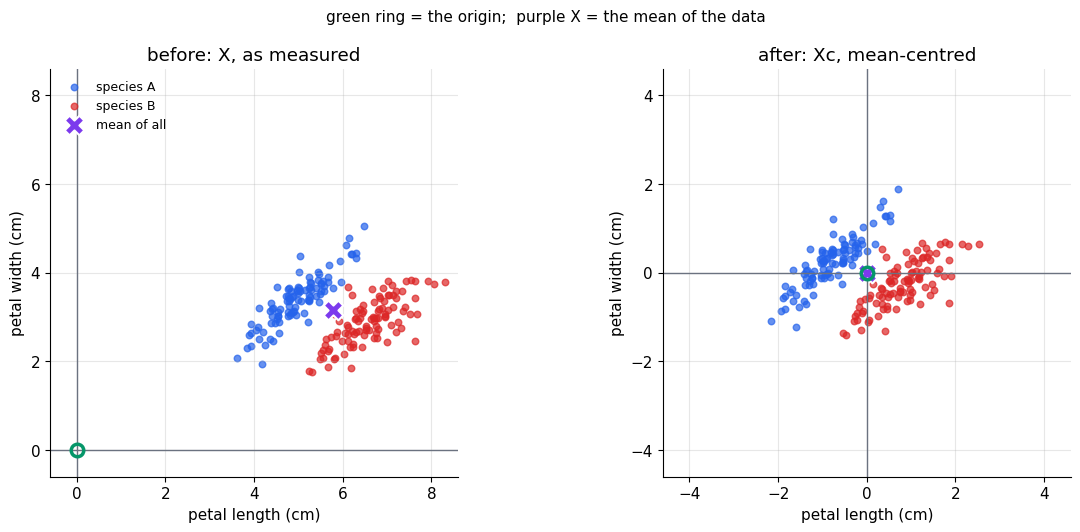

the purple X moved from [5.781 3.149] to [0. 0.] -- onto the origin, by construction


In [39]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.4, 5.4))

for ax, data, title in [(ax1, X,  "before: X, as measured"),
                        (ax2, Xc, "after: Xc, mean-centred")]:
    ax.scatter(*data[species == 0].T, s=22, c=C_F,     alpha=.7, label="species A")
    ax.scatter(*data[species == 1].T, s=22, c=C_SLOPE, alpha=.7, label="species B")
    ax.scatter(*data.mean(axis=0), s=200, marker="X", c=C_EXACT,
               edgecolor="white", lw=1.5, zorder=5, label="mean of all")
    ax.axhline(0, color=C_GREY, lw=1.0)
    ax.axvline(0, color=C_GREY, lw=1.0)
    ax.plot(0, 0, "o", ms=9, mfc="none", mec=C_AREA, mew=2.5, zorder=6)
    ax.set_title(title)
    ax.set_xlabel(FEATURES[0]); ax.set_ylabel(FEATURES[1])
    ax.set_aspect("equal")
ax1.set_xlim(-0.6, 8.6); ax1.set_ylim(-0.6, 8.6)
ax2.set_xlim(-4.6, 4.6); ax2.set_ylim(-4.6, 4.6)
ax1.legend(frameon=False, loc="upper left", fontsize=9)
fig.suptitle("green ring = the origin;  purple X = the mean of the data",
             fontsize=11)
fig.tight_layout(); plt.show()

print(f"the purple X moved from {X.mean(axis=0).round(3)} to "
      f"{Xc.mean(axis=0).round(3)} -- onto the origin, by construction")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

The same two hundred flowers, before and after centring, drawn on equal aspect so distances are honest in both panels. The green ring is the origin and the purple X is the average flower.

On the left the origin is far away in the corner, and the cloud sits off in one region of the plane; on the right the purple X has landed exactly on the green ring. **The cloud itself is identical** — same width, same tilt, same separation between the two species, same distance between any two given flowers, as the cell above confirmed for every pair among the first fifty. Only the axes moved.

That relocation is what makes the right-hand panel useful. Now a direction *from the origin* describes a real pattern in the data, and the diagonal lean of the cloud is a direction you could actually name. Finding that direction is Part 8; using it is Part 9.

**The common misread:** believing centring has "normalised" or "scaled" the data. It has not — it is a pure shift, and the two measurements still carry their original spread and their original units of centimetres. Dividing by the standard deviation as well is a *different* operation (standardisation), it does change the shape of the cloud, and it is not what we did here.

</div>

<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Checked, not asserted

Three separate claims about centring were tested rather than asserted:

1. **The column means become zero.** Printed unrounded; what survives is at the scale of floating-point rounding, and the largest one — not the average — was the number reported.
2. **The shape is unchanged.** An `assert` on `Xc.shape` guards the broadcast, which is exactly the defence the broadcasting gotcha above recommended, applied to real code.
3. **Distances between points are unchanged.** Checked for one pair exactly, then for all pairs among fifty flowers at once.

`Xc` is now available for the rest of the notebook, and Parts 8 and 9 assume it.

</div>

---

### What Part 4 built

| Idea | In code | Needed for |
|---|---|---|
| shape, and `A[i, j]` as row-then-column | `A.shape`, `A[i, j]` | everything |
| data matrix: rows are examples | `X.shape == (n, d)` | every ML library |
| identity, diagonal, symmetric, triangular | `np.eye`, `np.diag`, `np.triu` | Parts 7 and 8 |
| transpose, and $(\mathbf{AB})^T=\mathbf{B}^T\mathbf{A}^T$ | `A.T` | Parts 5, 7, 9 |
| elementwise `*` versus matrix `@` | both, and they differ | Part 5 |
| broadcasting, and how it lies to you | `X - X.mean(axis=0)` | debugging forever |
| mean-centring | `Xc = X - X.mean(axis=0)` | Parts 8 and 9 |

We can now spell matrices. What we still cannot do is say what one *means*.

**Next, in Part 5**, we build matrix multiplication — and it will not be a rule
handed down from nowhere. Look again at what `P @ Q` did above: its top-left
entry was the **dot product of P's first row with Q's first column**, and we
verified that by computing the dot product separately. That is the entire
recipe, and it is Part 3's operation arranged in a grid.

Once multiplication is built, Part 6 can finally cash the cheque this part's
title wrote, and show you a matrix moving.

---


---

# 5️⃣ Matrix multiplication, built from the dot product

You have almost certainly been told the rule: *go along the row, down the
column, multiply and add.* It is the single most-memorised and least-understood
instruction in mathematics, and the reason is that it is usually given as a
rule rather than derived as a consequence.

So here is the promise for this part. We will **not** state the rule. We will
build the product out of the dot product from Part 3, one output entry at a
time, printing each dot product as we go — and the familiar rule will fall out
as the description of what we just did.

Then we will read the *same* product a second way, as a **weighted sum of the
matrix's columns**. That second reading is the one that turns a matrix into a
verb, and it is what Part 6 is built on.
<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧭 Where we are

**Part 3** gave you `u · v` — multiply matching entries, add them up, and the
answer says how much two vectors agree.

**Part 4** gave you a matrix as an object: a rectangular block, with rows and
columns you can pull out.

**Part 5 — here —** puts them together. A matrix product is nothing but a lot
of dot products, arranged. Nothing new is introduced; it is all bookkeeping on
top of Part 3.

</div>

### 5.1 Matrix times vector: a stack of dot products

Start small and non-square, because a square matrix hides the shape rule.

Take $\mathbf{A}$ with **3 rows and 2 columns**, and a vector $\mathbf{v}$ with
**2 entries**. We will compute one output number per row of $\mathbf{A}$: take
that row, dot it with $\mathbf{v}$, write down the answer. Three rows, three
answers, so the output has 3 entries.

That is the whole of it. Watch each dot product get printed.


In [40]:
import numpy as np

A = np.array([[ 2., -1.],
              [ 1.,  3.],
              [ 0.,  4.]])          # 3 rows, 2 columns
v = np.array([4., 2.])              # 2 entries

print("A =")
print(A)
print(f"\nv = {v}    (A has {A.shape[1]} columns, v has {v.size} entries -- they match)")
print("\n--- one output entry per ROW of A, each one a dot product from Part 3 ---")

out = np.zeros(A.shape[0])
for i in range(A.shape[0]):
    row = A[i]                                   # the i-th row of A
    out[i] = np.sum(row * v)                     # dot product, written out by hand
    terms = "  +  ".join(f"{row[j]:g}x{v[j]:g}" for j in range(v.size))
    print(f"row {i} = {row}   dotted with v  ->  {terms}  =  {out[i]:g}")

print(f"\nbuilt by hand : {out}")
print(f"numpy A @ v   : {A @ v}")
print(f"identical?      {np.allclose(out, A @ v)}")


A =
[[ 2. -1.]
 [ 1.  3.]
 [ 0.  4.]]

v = [4. 2.]    (A has 2 columns, v has 2 entries -- they match)

--- one output entry per ROW of A, each one a dot product from Part 3 ---
row 0 = [ 2. -1.]   dotted with v  ->  2x4  +  -1x2  =  6
row 1 = [1. 3.]   dotted with v  ->  1x4  +  3x2  =  10
row 2 = [0. 4.]   dotted with v  ->  0x4  +  4x2  =  8

built by hand : [ 6. 10.  8.]
numpy A @ v   : [ 6. 10.  8.]
identical?      True


<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🗣️ In plain words

**`A @ v` means: dot every row of `A` with `v`.**

One row in, one number out. So the answer has as many entries as `A` has rows, and each entry is a Part-3 dot product — a measure of how much that row agrees with `v`.

The dot product needs both sides to be the same length, which is why the number of **columns** of `A` must equal the number of entries in `v`. That is the whole shape rule, and we did not have to be told it: it is just the dot product's requirement, repeated once per row.

</div>

<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Checked, not asserted

We never used `numpy`'s matrix multiply to build `out` — only `np.sum(row * v)`, which is the dot product spelled out. Then we compared against `A @ v` and got `True`.

If the row-by-row story were the wrong story, those two would disagree.

</div>

### 5.2 The second reading — and it is the important one

Here is the same product again, computed a completely different way, and
getting the same answer.

Instead of walking across rows, take the **columns** of $\mathbf{A}$ and mix
them: multiply the first column by $v_1$, the second column by $v_2$, and add
the results.

$$
\mathbf{A}\mathbf{v} \;=\; v_1 \,(\text{column 1 of } \mathbf{A}) \;+\; v_2\,(\text{column 2 of } \mathbf{A})
$$

Say that out loud: **`A @ v` is a recipe for combining A's columns, and `v` is
the list of amounts.** The matrix supplies the ingredients, the vector supplies
the quantities.


In [41]:
col0, col1 = A[:, 0], A[:, 1]        # the two columns of A, each with 3 entries

print(f"column 0 of A : {col0}")
print(f"column 1 of A : {col1}")
print(f"v             : {v}   -> use {v[0]:g} of column 0 and {v[1]:g} of column 1\n")

combo = v[0] * col0 + v[1] * col1
print(f"{v[0]:g} * {col0}  =  {v[0] * col0}")
print(f"{v[1]:g} * {col1}  =  {v[1] * col1}")
print(f"                     sum =  {combo}")

rows_way = np.array([np.sum(A[i] * v) for i in range(A.shape[0])])
print(f"\nrow-by-row way (5.1) : {rows_way}")
print(f"column-mixing way    : {combo}")
print(f"numpy A @ v          : {A @ v}")
print(f"all three agree?       {np.allclose(rows_way, combo) and np.allclose(combo, A @ v)}")


column 0 of A : [2. 1. 0.]
column 1 of A : [-1.  3.  4.]
v             : [4. 2.]   -> use 4 of column 0 and 2 of column 1

4 * [2. 1. 0.]  =  [8. 4. 0.]
2 * [-1.  3.  4.]  =  [-2.  6.  8.]
                     sum =  [ 6. 10.  8.]

row-by-row way (5.1) : [ 6. 10.  8.]
column-mixing way    : [ 6. 10.  8.]
numpy A @ v          : [ 6. 10.  8.]
all three agree?       True


<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🗣️ In plain words

Two readings of one operation, and they are both true at once:

**Row reading** — every output entry is one row dotted with `v`. Good for *computing*, and good for asking questions like "how much does this flower agree with this pattern?"

**Column reading** — the output is a weighted sum of `A`'s columns, weighted by `v`'s entries. Good for *understanding*, because it says the output can only ever be a mixture of `A`'s columns. Nothing outside that set of mixtures is reachable.

**Carry the column reading forward.** Part 6 is built on it, Part 7's "when does a system have no solution?" is answered by it, and it is the reason the word *span* from Part 2 mattered.

</div>

<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Checked, not asserted

Three independent computations of `A @ v` — a hand-written loop of dot products, a hand-written weighted sum of columns, and `numpy` — printed as identical. Two different stories about the same operation, both confirmed against the machine.

</div>

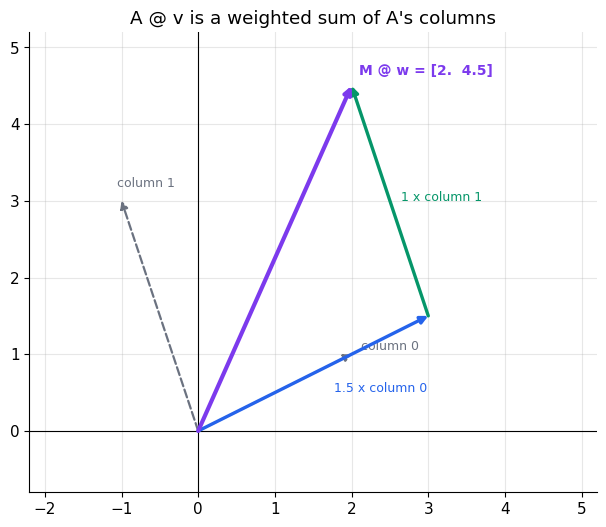

M columns: [2. 1.] and [-1.  3.]
w = [1.5 1. ]  ->  travel 1.5 along column 0, then 1 along column 1
tip-to-tail landing point : [2.  4.5]
M @ w                     : [2.  4.5]
same point?                 True


In [42]:
# The column reading is the one we are keeping, so it is worth SEEING.
# Drop to a 2x2 matrix and the columns become two arrows on a flat page:
# the vector says how far to travel along each, laid tip to tail.
import matplotlib.pyplot as plt

def arrow_from_to(ax, tail, head, color, lw=2.4, ls="-", alpha=1.0):
    """Draw one arrow from `tail` to `head`. Used throughout Parts 5 and 6."""
    ax.annotate("", xy=head, xytext=tail,
                arrowprops=dict(arrowstyle="-|>", color=color, lw=lw,
                                linestyle=ls, alpha=alpha,
                                shrinkA=0, shrinkB=0))

M = np.array([[2., -1.],
              [1.,  3.]])
w = np.array([1.5, 1.0])
c0, c1 = M[:, 0], M[:, 1]
result = M @ w

fig, ax = plt.subplots(figsize=(6.2, 5.6))

arrow_from_to(ax, (0, 0), c0, C_GREY, lw=1.6, ls="--")
arrow_from_to(ax, (0, 0), c1, C_GREY, lw=1.6, ls="--")
ax.text(*(c0 * 1.06), "column 0", color=C_GREY, fontsize=9)
ax.text(*(c1 * 1.06), "column 1", color=C_GREY, fontsize=9)

step0 = w[0] * c0
arrow_from_to(ax, (0, 0), step0, C_F)
ax.text(*(step0 * 0.55 + np.array([0.12, -0.32])),
        f"{w[0]:g} x column 0", color=C_F, fontsize=9)

step1 = w[1] * c1
arrow_from_to(ax, step0, step0 + step1, C_AREA)
ax.text(*(step0 + step1 * 0.5 + np.array([0.15, 0.0])),
        f"{w[1]:g} x column 1", color=C_AREA, fontsize=9)

arrow_from_to(ax, (0, 0), result, C_EXACT, lw=3.0)
ax.text(*(result + np.array([0.1, 0.15])),
        f"M @ w = {result}", color=C_EXACT, fontsize=10, fontweight="bold")

lim = 5.2
ax.set_xlim(-2.2, lim); ax.set_ylim(-0.8, lim)
ax.axhline(0, color="k", lw=0.8); ax.axvline(0, color="k", lw=0.8)
ax.set_aspect("equal")
ax.set_title("A @ v is a weighted sum of A's columns")
fig.tight_layout(); plt.show()

print(f"M columns: {c0} and {c1}")
print(f"w = {w}  ->  travel {w[0]:g} along column 0, then {w[1]:g} along column 1")
print(f"tip-to-tail landing point : {step0 + step1}")
print(f"M @ w                     : {result}")
print(f"same point?                 {np.allclose(step0 + step1, result)}")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

The two dashed grey arrows are the columns of `M` — they are just two vectors, nothing special yet. The blue arrow is the first column scaled by `w`'s first entry; the green arrow is the second column scaled by `w`'s second entry, laid tip-to-tail from where blue ended. The purple arrow, from the origin to that landing point, is `M @ w`.

This is Part 2's vector addition and scaling, doing all the work. Matrix multiplication invents no new arithmetic — it just organises those two operations.

**The common misread:** thinking the columns of `M` point at the answer. They do not. The answer is generally in neither column's direction; it is a mixture, and where it lands depends entirely on `w`. Change `w` and the purple arrow moves anywhere in the plane the two grey arrows can reach between them — which is exactly their span.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Where this trips people up

**`A @ v` needs `v` on the right, and the shapes must line up.**

`A @ v` and `v @ A` are different operations and usually one of them is an error. For `A @ v` the rule is *columns of `A` = entries of `v`*, because each row of `A` is being dotted with `v` and a dot product needs matching lengths.

When numpy raises a shape error on a matrix product, do not start sprinkling `.T` until it stops complaining. Read the two shapes out loud and ask which number should have matched. It is nearly always the inner pair — the last dimension of the left operand and the first of the right.

</div>

### 5.3 Matrix times matrix: several matrix-vector products, side by side

Nothing new happens here. If you can do $\mathbf{A}\mathbf{v}$, you can do
$\mathbf{A}\mathbf{B}$, because:

> **The $k$-th column of $\mathbf{A}\mathbf{B}$ is $\mathbf{A}$ times the
> $k$-th column of $\mathbf{B}$.**

So a matrix-matrix product is just several matrix-vector products, computed
independently and stacked side by side as columns. That is *all* it is.

We build $\mathbf{A}\mathbf{B}$ one column at a time below, using only the
`A @ column` operation from 5.1, and compare against `A @ B`.


In [43]:
B = np.array([[1., 0., 2., -1.],
              [3., 1., 0.,  4.]])        # 2 rows, 4 columns

print(f"A is {A.shape[0]} x {A.shape[1]},  B is {B.shape[0]} x {B.shape[1]}")
print("A has 2 columns and B has 2 rows -- so A can eat each column of B.\n")

columns = []
for k in range(B.shape[1]):
    bk = B[:, k]                 # the k-th column of B: a vector with 2 entries
    ak = A @ bk                  # exactly the operation from 5.1
    columns.append(ak)
    print(f"column {k} of B = {bk}   ->   A @ (that column) = {ak}")

built = np.column_stack(columns)
print(f"\nstacked side by side, that is a {built.shape[0]} x {built.shape[1]} matrix:")
print(built)
print("\nnumpy A @ B:")
print(A @ B)
print(f"\nidentical? {np.allclose(built, A @ B)}")
print(f"\nshapes:  ({A.shape[0]} x {A.shape[1]}) @ ({B.shape[0]} x {B.shape[1]})"
      f"  ->  ({(A @ B).shape[0]} x {(A @ B).shape[1]})")

# --- and what happens when the inner dimensions do NOT agree? Ask numpy. ---
print(f"\nA @ A asks A's {A.shape[1]} columns to equal A's {A.shape[0]} rows:")
try:
    A @ A
except ValueError as err:
    print(f"  ValueError: {err}")

print(f"\nB @ A has inner pair ({B.shape[1]}, {A.shape[0]}) -- also a mismatch:")
try:
    B @ A
except ValueError as err:
    print(f"  ValueError: {err}")

print("\nWhat does work here, and its shape:")
print(f"  A @ B      inner pair ({A.shape[1]}, {B.shape[0]})  ->  {(A @ B).shape}")
print(f"  B.T @ A.T  inner pair ({B.T.shape[1]}, {A.T.shape[0]})  ->  {(B.T @ A.T).shape}")
print(f"  and (A @ B).T equals B.T @ A.T ? {np.allclose((A @ B).T, B.T @ A.T)}")


A is 3 x 2,  B is 2 x 4
A has 2 columns and B has 2 rows -- so A can eat each column of B.

column 0 of B = [1. 3.]   ->   A @ (that column) = [-1. 10. 12.]
column 1 of B = [0. 1.]   ->   A @ (that column) = [-1.  3.  4.]
column 2 of B = [2. 0.]   ->   A @ (that column) = [4. 2. 0.]
column 3 of B = [-1.  4.]   ->   A @ (that column) = [-6. 11. 16.]

stacked side by side, that is a 3 x 4 matrix:
[[-1. -1.  4. -6.]
 [10.  3.  2. 11.]
 [12.  4.  0. 16.]]

numpy A @ B:
[[-1. -1.  4. -6.]
 [10.  3.  2. 11.]
 [12.  4.  0. 16.]]

identical? True

shapes:  (3 x 2) @ (2 x 4)  ->  (3 x 4)

A @ A asks A's 2 columns to equal A's 3 rows:
  ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 3 is different from 2)

B @ A has inner pair (4, 3) -- also a mismatch:
  ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 3 is different from 4)

What does wor

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🗣️ In plain words

**The shape rule, derived rather than memorised.**

`A` eats a vector with as many entries as `A` has columns, and produces a vector with as many entries as `A` has rows. We fed it every column of `B`, so:

- `B`'s columns must have the right length → `B` needs as many **rows** as `A` has **columns**. This is the number that must match, and it disappears from the answer.
- We got one output column per column of `B`, each with as many entries as `A` has rows.

So $(m \times n)(n \times p) \rightarrow (m \times p)$. The two inner $n$'s must agree, and then they cancel out of the shape.

</div>

<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Checked, not asserted

`A @ B` was rebuilt column by column, using nothing but the `A @ vector` operation we had already verified in 5.1, and matched `numpy`'s product exactly. The printed shapes are the shape rule happening, not being asserted.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Where this trips people up

**Only the inner dimensions have to match, and they are the ones that vanish.**

Write the shapes next to each other — `(3×2)(2×4)` — and the two middle numbers must be equal. What survives is the outside pair, `(3×4)`.

Note also the last line above: transposing a product **reverses the order**, $(\mathbf{A}\mathbf{B})^T = \mathbf{B}^T\mathbf{A}^T$. That is not a curiosity; it is the reason data-science code is full of `X @ W.T` when the maths on the whiteboard said $\mathbf{W}\mathbf{x}$. We use it on the flowers in 5.7.

</div>

### 5.4 $\mathbf{A}\mathbf{B}$ is not $\mathbf{B}\mathbf{A}$

With ordinary numbers, $3 \times 5 = 5 \times 3$, and you have relied on that
so automatically for so long that it is invisible. Matrices break it, and not
as a technicality — most pairs of matrices fail to commute.

The reason is not algebraic, it is physical: **a matrix is an action**, and
actions happen in an order. Put your socks on then your shoes; try it the other
way round. Below: a rotation and a stretch.


R (quarter turn):
[[ 0. -1.]
 [ 1.  0.]]

S (stretch x by 3):
[[3. 0.]
 [0. 1.]]

R @ S  =  'stretch first, THEN rotate':
[[ 0. -1.]
 [ 3.  0.]]

S @ R  =  'rotate first, THEN stretch':
[[ 0. -3.]
 [ 1.  0.]]

Are they equal? False
largest entry-by-entry difference: 2.000

On the single vector [1. 1.]:
  stretch first, then rotate : [-1.  3.]
  rotate first, then stretch : [-3.  1.]


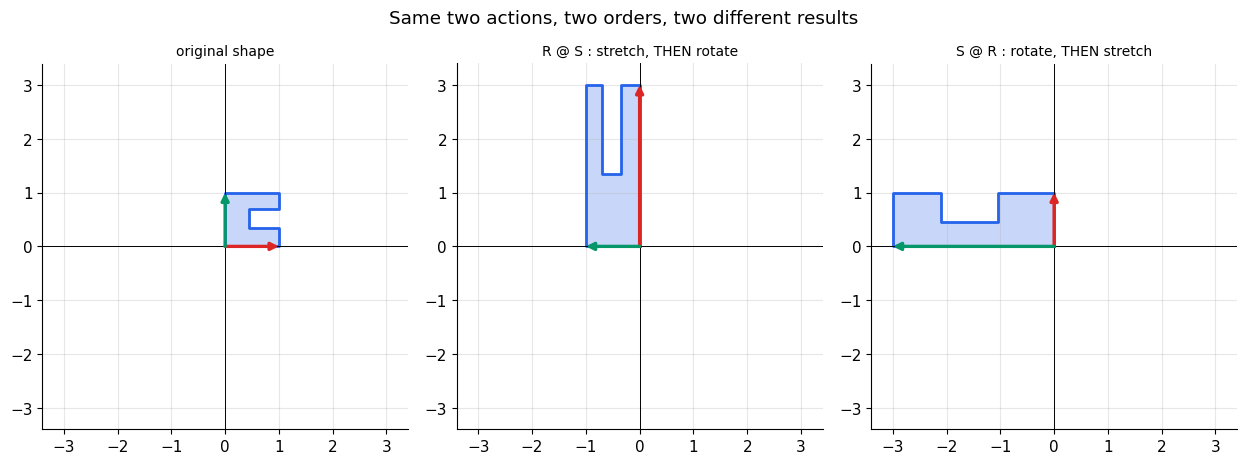

red arrow  = where the matrix sends (1, 0)
green arrow = where the matrix sends (0, 1)
R @ S sends (1,0) to [1.8369702e-16 3.0000000e+00]
S @ R sends (1,0) to [1.8369702e-16 1.0000000e+00]


In [44]:
theta = np.deg2rad(90.0)
R = np.array([[np.cos(theta), -np.sin(theta)],       # quarter turn
              [np.sin(theta),  np.cos(theta)]])
S = np.array([[3., 0.],
              [0., 1.]])                              # stretch x by 3, leave y

print("R (quarter turn):"); print(R.round(3))
print("\nS (stretch x by 3):"); print(S)
print("\nR @ S  =  'stretch first, THEN rotate':")
print((R @ S).round(3))
print("\nS @ R  =  'rotate first, THEN stretch':")
print((S @ R).round(3))
print(f"\nAre they equal? {np.allclose(R @ S, S @ R)}")
print(f"largest entry-by-entry difference: {np.abs(R @ S - S @ R).max():.3f}")

probe = np.array([1., 1.])
print(f"\nOn the single vector {probe}:")
print(f"  stretch first, then rotate : {(R @ S) @ probe}")
print(f"  rotate first, then stretch : {(S @ R) @ probe}")

# --- the same two orders, applied to a shape, so the difference is visible ---
flag = np.array([[0., 0.], [1., 0.], [1., 0.35], [0.45, 0.35],
                 [0.45, 0.7], [1.0, 0.7], [1.0, 1.0], [0., 1.], [0., 0.]]).T  # 2 x 9

panels = [("original shape", np.eye(2)),
          ("R @ S : stretch, THEN rotate", R @ S),
          ("S @ R : rotate, THEN stretch", S @ R)]

fig, axes = plt.subplots(1, 3, figsize=(12.6, 4.4))
for ax, (title, Mx) in zip(axes, panels):
    shape = Mx @ flag
    ax.fill(shape[0], shape[1], color=C_F, alpha=0.25)
    ax.plot(shape[0], shape[1], color=C_F, lw=2)
    arrow_from_to(ax, (0, 0), Mx @ np.array([1., 0.]), C_SLOPE)
    arrow_from_to(ax, (0, 0), Mx @ np.array([0., 1.]), C_AREA)
    ax.set_xlim(-3.4, 3.4); ax.set_ylim(-3.4, 3.4)
    ax.axhline(0, color="k", lw=0.7); ax.axvline(0, color="k", lw=0.7)
    ax.set_aspect("equal")
    ax.set_title(title, fontsize=10)
fig.suptitle("Same two actions, two orders, two different results", y=1.0)
fig.tight_layout(); plt.show()

print("red arrow  = where the matrix sends (1, 0)")
print("green arrow = where the matrix sends (0, 1)")
print(f"R @ S sends (1,0) to {(R @ S) @ np.array([1., 0.])}")
print(f"S @ R sends (1,0) to {(S @ R) @ np.array([1., 0.])}")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

The left panel is a flag-shaped blob sitting on the unit square. The middle panel stretched it sideways and then turned the stretched thing a quarter turn, so the stretch ended up running **vertically**. The right panel turned it first, then stretched, so the stretch runs **horizontally** across an already-rotated shape. Same ingredients, different dish.

Read the products right to left: in `R @ S`, `S` is closest to the vector it will meet, so `S` acts first. The printed arrows say where each matrix sends `(1, 0)` and `(0, 1)`, which — as Part 6 will make the whole point — are literally the matrix's columns.

**The common misread:** reading `R @ S` left to right as "rotate then stretch". It is the other way round. The matrix nearest the vector touches it first, because `(R @ S) @ v` is `R @ (S @ v)`.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Where this trips people up

**Never assume $\mathbf{A}\mathbf{B} = \mathbf{B}\mathbf{A}$.** With numbers it is always true; with matrices it is the exception, not the rule. Two matrices that do commute are telling you something special about themselves (they are doing compatible things — for instance any matrix commutes with the identity, and rotations of the plane commute with each other because two turns add up regardless of order).

Practically: you may **not** reorder factors when simplifying a matrix expression. You may re-bracket them — that is 5.5 — but the left-to-right sequence is the order of the actions, and it is fixed.

</div>

### 5.5 What you *can* do: re-bracket, and expand over addition

Two laws survive, and they are the two that make matrix algebra usable.

**Associativity:** $(\mathbf{A}\mathbf{B})\mathbf{C} = \mathbf{A}(\mathbf{B}\mathbf{C})$.
You may not change the *order* of the actions, but you may change which ones
you fuse together first. This is not a small permission — it is what lets you
pre-multiply a whole stack of layers into one matrix, and it is why the
composition figure in Part 6 works.

**Distributivity:** $\mathbf{A}(\mathbf{B} + \mathbf{C}) = \mathbf{A}\mathbf{B} + \mathbf{A}\mathbf{C}$.
Acting on a sum is the same as acting on each piece and adding — which is
exactly the *linear* in linear algebra.


In [45]:
RNG5 = np.random.default_rng(11)
P = RNG5.normal(size=(3, 4))
Q = RNG5.normal(size=(4, 2))
T = RNG5.normal(size=(2, 5))
Q2 = RNG5.normal(size=(4, 2))
u  = RNG5.normal(size=5)

left  = (P @ Q) @ T
right = P @ (Q @ T)
print(f"associativity   (PQ)T vs P(QT) : max difference {np.abs(left - right).max():.2e}")
print(f"                same shape?      {left.shape == right.shape} -> {left.shape}")

d_left  = P @ (Q + Q2)
d_right = P @ Q + P @ Q2
print(f"distributivity  P(Q+Q2) vs PQ+PQ2 : max difference "
      f"{np.abs(d_left - d_right).max():.2e}")

# and the one that matters in practice: fuse the chain once, reuse it forever
fused = P @ Q @ T
print(f"\nfusing P @ Q @ T into a single {fused.shape[0]} x {fused.shape[1]} matrix,")
print(f"then applying it to a vector, agrees with applying the three in turn: "
      f"{np.allclose(fused @ u, P @ (Q @ (T @ u)))}")
print("\n(The differences above are not exactly zero because floating-point")
print(" addition is not exactly associative -- they are at rounding level,")
print(" around 1e-16 relative, which is agreement.)")


associativity   (PQ)T vs P(QT) : max difference 4.44e-16
                same shape?      True -> (3, 5)
distributivity  P(Q+Q2) vs PQ+PQ2 : max difference 4.44e-16

fusing P @ Q @ T into a single 3 x 5 matrix,
then applying it to a vector, agrees with applying the three in turn: True

(The differences above are not exactly zero because floating-point
 addition is not exactly associative -- they are at rounding level,
 around 1e-16 relative, which is agreement.)


<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Checked, not asserted

Both laws were checked on random matrices of deliberately awkward shapes (3×4, 4×2, 2×5), not on a convenient square example where a mistake could hide. The differences printed are at floating-point rounding level rather than exactly zero — that is what "equal" looks like in binary arithmetic, and it is worth learning to read `1e-16` as *zero* and `1e-2` as *a bug*.

</div>

### 5.6 What it costs, and why a whole industry exists because of it

Count the multiplications. Every entry of an $(m \times n)(n \times p)$ product
is a dot product of length $n$, so it costs $n$ multiplications; there are
$m \times p$ entries; so the total is $m \times n \times p$ multiplications
(and about the same number of additions).

The important word is **cubed**. Double the size of a square matrix and the
work goes up eight-fold. That single fact is why GPUs exist in the shape they
do, and why nearly all of the electricity a neural network consumes is spent
inside this one operation.


In [46]:
def mults(m, n, p):
    """Multiplications needed for an (m x n) @ (n x p) product."""
    return m * n * p

print(f"our small example: A ({A.shape[0]}x{A.shape[1]}) @ B "
      f"({B.shape[0]}x{B.shape[1]}) needs {mults(A.shape[0], A.shape[1], B.shape[1])} "
      f"multiplications")

# verify the formula by counting, rather than trusting it
counter = 0
for i in range(A.shape[0]):
    for k in range(B.shape[1]):
        for j in range(A.shape[1]):
            counter += 1
print(f"counted by triple loop                          : {counter}")
print(f"formula m*n*p                                    : "
      f"{mults(A.shape[0], A.shape[1], B.shape[1])}")
print(f"agree? {counter == mults(A.shape[0], A.shape[1], B.shape[1])}\n")

print("now the same formula at the sizes machine learning actually uses:")
print(f"{'size':>10} | {'multiplications':>20} | {'x bigger than 1024':>19}")
base = mults(1024, 1024, 1024)
for s in [1024, 2048, 4096, 8192, 16384]:
    t = mults(s, s, s)
    print(f"{s:>10} | {t:>20,} | {t / base:>18.0f}x")

secs = mults(16384, 16384, 16384) / 1e12
print(f"\nA machine doing a million million multiplications per second would")
print(f"need about {secs:.1f} seconds for the last row -- for ONE product.")
print("Every doubling of the size costs eight times the work. That is the")
print("whole reason specialised matrix-multiply hardware exists.")


our small example: A (3x2) @ B (2x4) needs 24 multiplications
counted by triple loop                          : 24
formula m*n*p                                    : 24
agree? True

now the same formula at the sizes machine learning actually uses:
      size |      multiplications |  x bigger than 1024
      1024 |        1,073,741,824 |                  1x
      2048 |        8,589,934,592 |                  8x
      4096 |       68,719,476,736 |                 64x
      8192 |      549,755,813,888 |                512x
     16384 |    4,398,046,511,104 |               4096x

A machine doing a million million multiplications per second would
need about 4.4 seconds for the last row -- for ONE product.
Every doubling of the size costs eight times the work. That is the
whole reason specialised matrix-multiply hardware exists.


<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🗣️ In plain words

**Cost = rows × inner × columns.** One dot product per output entry, and each dot product is as long as the shared inner dimension.

For square matrices that is $n^3$, so the cost grows *much* faster than the amount of data. It is the reason "just use a bigger matrix" is not a free move, and the reason so much engineering effort goes into doing this one operation quickly.

</div>

### 5.7 All two hundred flowers, in one `@`

Here is the thing that makes this operation worth the trouble. We have a
$2\times 2$ matrix and 200 flowers. We do **not** loop over the flowers.

The convention to keep straight: in `X`, each **row** is one flower. The maths
on the whiteboard writes a flower as a *column* and computes $\mathbf{M}\mathbf{x}$.
Both are fine; you just have to say which you mean, and the transpose rule from
5.3 converts between them.


In [47]:
Mflow = np.array([[1.4, -0.6],
                  [0.5,  0.9]])

print(f"X     : {X.shape}   (200 flowers as ROWS, 2 measurements each)")
print(f"Mflow : {Mflow.shape}\n")

# Route 1 -- the whiteboard route: flowers as columns.
Xcols = X.T                                  # 2 x 200
print(f"X.T            : {Xcols.shape}   (each flower is now a COLUMN)")
moved_cols = Mflow @ Xcols                   # (2x2) @ (2x200) -> 2x200
print(f"Mflow @ X.T    : {moved_cols.shape}")
moved_1 = moved_cols.T                       # back to rows
print(f"(Mflow @ X.T).T: {moved_1.shape}   (flowers are rows again)\n")

# Route 2 -- the code route: keep flowers as rows, transpose the matrix instead.
moved_2 = X @ Mflow.T                         # (200x2) @ (2x2) -> 200x2
print(f"X @ Mflow.T    : {moved_2.shape}")
print(f"\nsame answer by both routes? {np.allclose(moved_1, moved_2)}")

# And spot-check ONE flower against the definition, by hand.
i = 7
by_hand = np.array([np.sum(Mflow[r] * X[i]) for r in range(2)])
print(f"\nflower {i} was {X[i].round(3)}")
print(f"  hand-computed Mflow @ flower : {by_hand.round(3)}")
print(f"  row {i} of the batch result   : {moved_2[i].round(3)}")
print(f"  agree? {np.allclose(by_hand, moved_2[i])}")
print(f"\n200 flowers transformed with ONE matrix product, "
      f"{mults(200, 2, 2)} multiplications, no Python loop.")


X     : (200, 2)   (200 flowers as ROWS, 2 measurements each)
Mflow : (2, 2)

X.T            : (2, 200)   (each flower is now a COLUMN)
Mflow @ X.T    : (2, 200)
(Mflow @ X.T).T: (200, 2)   (flowers are rows again)

X @ Mflow.T    : (200, 2)

same answer by both routes? True

flower 7 was [5.661 3.894]
  hand-computed Mflow @ flower : [5.59  6.335]
  row 7 of the batch result   : [5.59  6.335]
  agree? True

200 flowers transformed with ONE matrix product, 800 multiplications, no Python loop.


<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Checked, not asserted

The batch result was verified two ways: the whole-array route `X @ Mflow.T` was compared against the whiteboard route `(Mflow @ X.T).T`, and then a single flower was recomputed by hand from the dot-product definition and matched its row in the batch answer.

That second check is the one worth copying into your own work. Batch operations are where silent transpose bugs live, and a hand-computed single row catches them instantly.

</div>

In [48]:
# A neural network layer, in full, with no framework.
W = np.array([[0.8, -0.4],
              [0.2,  1.1],
              [-0.9, 0.3]])          # 3 outputs from 2 inputs
b = np.array([0.05, -0.2, 0.4])

x = X[0]                              # one flower as the input vector
y = W @ x + b
print(f"x (one flower) : {x.round(3)}     shape {x.shape}")
print(f"W              : shape {W.shape}")
print(f"b              : {b}   shape {b.shape}")
print(f"y = W @ x + b  : {y.round(3)}   shape {y.shape}\n")

print("entry by entry, y is Part 3 all over again:")
for r in range(W.shape[0]):
    print(f"  y[{r}] = (row {r} of W) . x  +  b[{r}] = "
          f"{np.sum(W[r] * x):.3f} + {b[r]:.3f} = {y[r]:.3f}")

# the whole batch, one line
Y = X @ W.T + b                       # (200x2)@(2x3) -> 200x3, then b broadcasts
print(f"\nall 200 flowers through the layer: X @ W.T + b -> {Y.shape}")
print(f"row 0 of the batch equals the single-flower answer? "
      f"{np.allclose(Y[0], y)}")

# and the collapse: two linear layers with nothing between them
W1 = np.array([[0.8, -0.4], [0.2, 1.1]])
W2 = np.array([[1.3, 0.5], [-0.7, 0.9]])
two_steps = W2 @ (W1 @ x)
one_step  = (W2 @ W1) @ x
print(f"\nW2 @ (W1 @ x) = {two_steps.round(4)}")
print(f"(W2 @ W1) @ x = {one_step.round(4)}")
print(f"identical? {np.allclose(two_steps, one_step)}")
print(f"W2 @ W1 is just another {(W2 @ W1).shape[0]}x{(W2 @ W1).shape[1]} matrix:")
print((W2 @ W1).round(4))


x (one flower) : [4.189 1.933]     shape (2,)
W              : shape (3, 2)
b              : [ 0.05 -0.2   0.4 ]   shape (3,)
y = W @ x + b  : [ 2.628  2.764 -2.79 ]   shape (3,)

entry by entry, y is Part 3 all over again:
  y[0] = (row 0 of W) . x  +  b[0] = 2.578 + 0.050 = 2.628
  y[1] = (row 1 of W) . x  +  b[1] = 2.964 + -0.200 = 2.764
  y[2] = (row 2 of W) . x  +  b[2] = -3.190 + 0.400 = -2.790

all 200 flowers through the layer: X @ W.T + b -> (200, 3)
row 0 of the batch equals the single-flower answer? True

W2 @ (W1 @ x) = [4.8333 0.8625]
(W2 @ W1) @ x = [4.8333 0.8625]
identical? True
W2 @ W1 is just another 2x2 matrix:
[[ 1.14  0.03]
 [-0.38  1.27]]


<div style="background-color: #f8d7da; border-left: 5px solid #dc3545; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🤖 Why ML cares

**`y = Wx + b` is exactly what you just built.** `W @ x` is 5.1 — every output is one row of `W` dotted with the input. Adding `b` is Part 2's vector addition. A layer of a neural network is a stack of dot products and a shift, and nothing else.

`W`'s shape *is* the layer's shape: rows = outputs, columns = inputs. And the batch form `X @ W.T + b` pushes every example through at once, which is why training is a sequence of large matrix products rather than a loop over examples.

**And the last block above is the reason activation functions exist.** Two linear layers back to back gave exactly the same answer as one layer whose matrix is `W2 @ W1`. Stack a hundred of them and associativity (5.5) fuses the lot into a single matrix — a hundred-layer linear network is a one-layer linear network with extra electricity. Something non-linear has to sit between them or the depth buys nothing. Part 6 shows what that collapse looks like geometrically.

</div>

---

### What you have, going into Part 6

- $\mathbf{A}\mathbf{v}$ is **a stack of dot products** — one per row of
  $\mathbf{A}$ — and that alone forces the shape rule.
- $\mathbf{A}\mathbf{v}$ is also **a weighted sum of $\mathbf{A}$'s columns**,
  with $\mathbf{v}$ supplying the weights. *This is the reading to remember.*
- $\mathbf{A}\mathbf{B}$ is that operation done once per column of
  $\mathbf{B}$, which gives $(m \times n)(n \times p) \rightarrow (m \times p)$.
- Order matters, brackets do not, and the cost is rows × inner × columns.

There is one loose thread, and Part 6 pulls it. In 5.4 the arrows we drew were
"where the matrix sends $(1,0)$ and $(0,1)$" — and if you compare those printed
arrows with the matrices themselves, you may already have noticed something.

**They are the columns.** That is not a coincidence, and it is the whole of the
next part: a matrix is completely described by where it sends the two basis
vectors, and it stores that information in plain sight.


---

# 6️⃣ Transformations: what a matrix DOES to space

Part 0 claimed that a matrix is a verb. Part 5 showed that
$\mathbf{A}\mathbf{v}$ is a weighted sum of $\mathbf{A}$'s columns. This part
collects the debt.

A matrix takes in a vector and gives back a vector, so you can feed it *every*
point of the plane and watch where they all go. That is the picture to hold:
**a matrix is a motion of space.** It stretches, turns, squashes, flips. The
grid goes somewhere, and the matrix is the instruction for where.

And here is the surprise that makes it tractable: you do not need to track
infinitely many points. You need to track **two**.
<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🔑 The one idea in this part

A matrix multiplication is a **linear** map, which means it respects addition
and scaling: whatever it does to $\mathbf{u}$ and to $\mathbf{v}$, it does the
compatible thing to $2\mathbf{u} + 3\mathbf{v}$.

Every vector in the plane is built from $\mathbf{e}_1 = (1,0)$ and
$\mathbf{e}_2 = (0,1)$ by scaling and adding. So if you know where those two
land, you know where **everything** lands.

Two arrows determine the entire motion of the plane. And the matrix is storing
those two arrows in plain sight — as its columns.

</div>

### 6.1 The columns *are* the landing spots

Take Part 5's column reading and feed it $\mathbf{e}_1 = (1, 0)$:

$$
\mathbf{M}\mathbf{e}_1 = 1\cdot(\text{column 0}) + 0\cdot(\text{column 1}) = \text{column 0}
$$

That is the whole derivation. Asking "where does $\mathbf{M}$ send
$\mathbf{e}_1$?" is asking to take one of column 0 and none of column 1, which
just reads column 0 back out. Same for $\mathbf{e}_2$ and column 1.

So you can **build a matrix by deciding where you want the basis vectors to
go** and writing those two destinations down as columns. Let us do exactly
that: send $\mathbf{e}_1$ to $(2, 1)$ and $\mathbf{e}_2$ to $(-1, 1.5)$.


In [49]:
import numpy as np
import matplotlib.pyplot as plt

e1, e2 = np.array([1., 0.]), np.array([0., 1.])

want1 = np.array([ 2.0, 1.0])       # where we want e1 to land
want2 = np.array([-1.0, 1.5])       # where we want e2 to land

M = np.column_stack([want1, want2])  # write the destinations down as columns
print("M, built by stacking the two destinations as columns:")
print(M)

print(f"\nM @ e1 = {M @ e1}   (we asked for {want1})  -> {np.allclose(M @ e1, want1)}")
print(f"M @ e2 = {M @ e2}   (we asked for {want2})  -> {np.allclose(M @ e2, want2)}")

# ...and it also determines every OTHER point, with no extra information.
p = np.array([3., -2.])
print(f"\nA point we never mentioned: p = {p}")
print(f"  p = {p[0]:g}*e1 + {p[1]:g}*e2, so it must land at "
      f"{p[0]:g}*{want1} + {p[1]:g}*{want2}")
print(f"  predicted from the two landings : {p[0] * want1 + p[1] * want2}")
print(f"  actually computed as M @ p      : {M @ p}")
print(f"  agree? {np.allclose(p[0] * want1 + p[1] * want2, M @ p)}")

# The same fact, run backwards: any matrix's columns are its basis landings.
RNG6 = np.random.default_rng(23)
Z = RNG6.normal(size=(2, 2)).round(2)
print(f"\nFor an arbitrary matrix Z =\n{Z}")
print(f"  Z @ e1 = {Z @ e1}  and column 0 of Z = {Z[:, 0]}")
print(f"  Z @ e2 = {Z @ e2}  and column 1 of Z = {Z[:, 1]}")
print(f"  columns are the landings? {np.allclose(np.column_stack([Z @ e1, Z @ e2]), Z)}")


M, built by stacking the two destinations as columns:
[[ 2.  -1. ]
 [ 1.   1.5]]

M @ e1 = [2. 1.]   (we asked for [2. 1.])  -> True
M @ e2 = [-1.   1.5]   (we asked for [-1.   1.5])  -> True

A point we never mentioned: p = [ 3. -2.]
  p = 3*e1 + -2*e2, so it must land at 3*[2. 1.] + -2*[-1.   1.5]
  predicted from the two landings : [8. 0.]
  actually computed as M @ p      : [8. 0.]
  agree? True

For an arbitrary matrix Z =
[[ 0.55  0.22]
 [-0.06 -2.32]]
  Z @ e1 = [ 0.55 -0.06]  and column 0 of Z = [ 0.55 -0.06]
  Z @ e2 = [ 0.22 -2.32]  and column 1 of Z = [ 0.22 -2.32]
  columns are the landings? True


<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🗣️ In plain words

**To read a matrix, read its columns as arrows.**

Column 0 says where $(1,0)$ goes. Column 1 says where $(0,1)$ goes. That is not a mnemonic — it falls straight out of Part 5's column reading, because asking for $\mathbf{M}\mathbf{e}_1$ means "one of column 0 and none of column 1".

And because every point is some amount of $\mathbf{e}_1$ plus some amount of $\mathbf{e}_2$, those two arrows fix the fate of every point at once. A $2\times2$ matrix is four numbers because two destinations in the plane need four numbers. Nothing is hidden in there.

</div>

<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Checked, not asserted

Three separate confirmations above: the built matrix really does send the basis vectors where we asked; a point we never mentioned lands exactly where the two landings predict it must; and running the idea backwards, an arbitrary random matrix's columns are reproduced exactly by feeding it $\mathbf{e}_1$ and $\mathbf{e}_2$.

The middle one is the load-bearing check — it is *linearity*, and it is why two arrows are enough.

</div>

### 6.2 The zoo: eight matrices, and what each one does to the plane

Now the picture this whole notebook has been walking towards.

Each panel below takes the same square grid, the same shaded unit square, and
the same two basis arrows, and applies one matrix to all of it. Straight lines
stay straight and the origin never moves — that is what "linear" buys — so the
grid stays a grid, but a sheared, spun, squashed one.

Look at the two arrows in each panel and then at the matrix printed underneath.
**The arrows are the columns.** Once you can see that, you can predict a
transformation by reading the matrix, and write a matrix by deciding on the
picture.


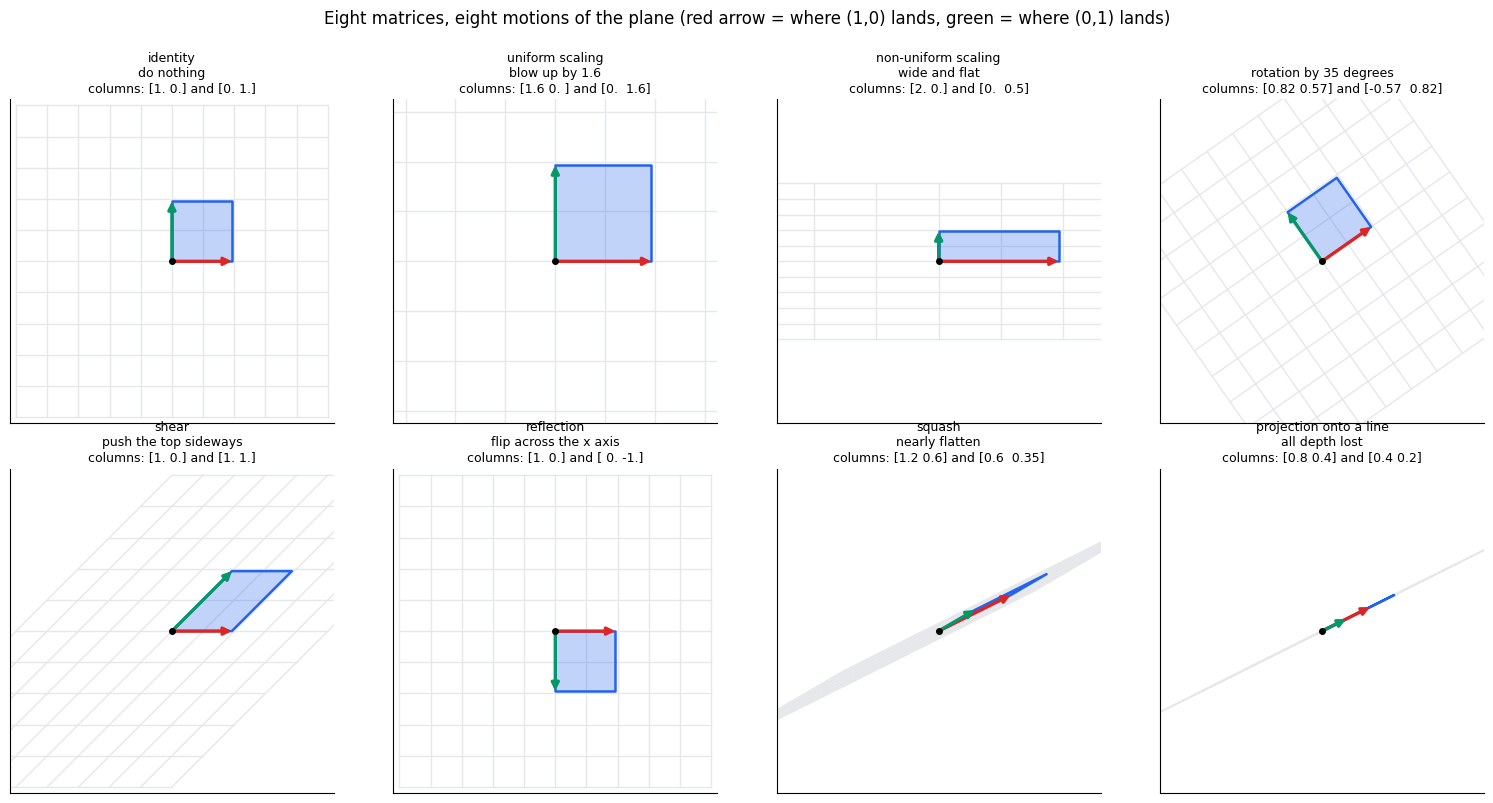

identity / do nothing                      e1 -> [1. 0.]          e2 -> [0. 1.]
uniform scaling / blow up by 1.6           e1 -> [1.6 0. ]        e2 -> [0.  1.6]
non-uniform scaling / wide and flat        e1 -> [2. 0.]          e2 -> [0.  0.5]
rotation by 35 degrees                     e1 -> [0.82 0.57]      e2 -> [-0.57  0.82]
shear / push the top sideways              e1 -> [1. 0.]          e2 -> [1. 1.]
reflection / flip across the x axis        e1 -> [1. 0.]          e2 -> [ 0. -1.]
squash / nearly flatten                    e1 -> [1.2 0.6]        e2 -> [0.6  0.35]
projection onto a line / all depth lost    e1 -> [0.8 0.4]        e2 -> [0.4 0.2]


In [50]:
def transformed_grid(ax, T, extent=2.6, n_lines=11, color=C_SOFT):
    """Draw the image of a square grid under the linear map T (2x2)."""
    ticks = np.linspace(-extent, extent, n_lines)
    for k in ticks:
        vert = T @ np.array([[k, k], [-extent, extent]])   # the line x = k
        horiz = T @ np.array([[-extent, extent], [k, k]])  # the line y = k
        ax.plot(vert[0], vert[1], color=color, lw=1.0, zorder=1)
        ax.plot(horiz[0], horiz[1], color=color, lw=1.0, zorder=1)


def arrow_from_to(ax, tail, head, color, lw=2.4, ls="-"):
    ax.annotate("", xy=head, xytext=tail,
                arrowprops=dict(arrowstyle="-|>", color=color, lw=lw,
                                linestyle=ls, shrinkA=0, shrinkB=0))


# the unit square, corners listed anticlockwise (this ordering matters in 6.3)
SQUARE = np.array([[0., 1., 1., 0.],
                   [0., 0., 1., 1.]])

ang = np.deg2rad(35.0)
u_line = np.array([2., 1.]); u_line = u_line / np.linalg.norm(u_line)

ZOO = [
    ("identity\ndo nothing",            np.array([[1., 0.], [0., 1.]])),
    ("uniform scaling\nblow up by 1.6", np.array([[1.6, 0.], [0., 1.6]])),
    ("non-uniform scaling\nwide and flat", np.array([[2., 0.], [0., 0.5]])),
    ("rotation by 35 degrees",          np.array([[np.cos(ang), -np.sin(ang)],
                                                  [np.sin(ang),  np.cos(ang)]])),
    ("shear\npush the top sideways",    np.array([[1., 1.], [0., 1.]])),
    ("reflection\nflip across the x axis", np.array([[1., 0.], [0., -1.]])),
    ("squash\nnearly flatten",          np.array([[1.2, 0.6], [0.6, 0.35]])),
    ("projection onto a line\nall depth lost", np.outer(u_line, u_line)),
]

fig, axes = plt.subplots(2, 4, figsize=(15.5, 8.0))
for ax, (name, T) in zip(axes.ravel(), ZOO):
    transformed_grid(ax, T)
    sq = T @ SQUARE
    ax.fill(sq[0], sq[1], color=C_F, alpha=0.28, zorder=2)
    ax.plot(np.append(sq[0], sq[0][0]), np.append(sq[1], sq[1][0]),
            color=C_F, lw=1.8, zorder=3)
    arrow_from_to(ax, (0, 0), T @ e1, C_SLOPE)     # where (1,0) went
    arrow_from_to(ax, (0, 0), T @ e2, C_AREA)      # where (0,1) went
    ax.plot(0, 0, "o", color="k", ms=4, zorder=4)
    ax.set_xlim(-2.7, 2.7); ax.set_ylim(-2.7, 2.7)
    ax.set_aspect("equal")
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    ax.set_title(f"{name}\ncolumns: {T[:, 0].round(2)} and {T[:, 1].round(2)}",
                 fontsize=9)
fig.suptitle("Eight matrices, eight motions of the plane "
             "(red arrow = where (1,0) lands, green = where (0,1) lands)",
             fontsize=12, y=1.0)
fig.tight_layout(); plt.show()

for name, T in ZOO:
    label = name.replace(chr(10), " / ")
    print(f"{label:<42} e1 -> {str(T[:, 0].round(2)):<16} "
          f"e2 -> {T[:, 1].round(2)}")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Eight motions of the same plane. The pale grid is where the graph paper went; the blue patch is the unit square, dragged along with it; the red and green arrows are where $(1,0)$ and $(0,1)$ ended up — and those arrows are printed beside each panel as the matrix's two columns, because they *are* the two columns.

Things worth noticing: the black dot at the origin never moves in any panel — a linear map cannot move the origin, since $\mathbf{M}\mathbf{0} = \mathbf{0}$. Grid lines stay straight and stay parallel, and equally spaced lines stay equally spaced. The **shear** keeps the bottom edge pinned and slides the top, which is why its first column is unchanged. The **reflection** turns the square inside out — walk the corners and you now go the other way round. The **projection** in the last panel has flattened the entire plane onto a single line: the grid has collapsed, and every point of the plane now lies on that one line.

**The common misread:** thinking the grid "is" the transformation and that some points stay put. Every point moves except the origin — the grid is drawn only so you can see the motion. And in the last panel it is tempting to say the picture is "smaller"; it is not smaller, it is **lower-dimensional**. Two dimensions of input became one dimension of output, and 6.3 measures exactly that.

</div>

### 6.3 The determinant: how much area got multiplied by

Look again at the unit square in each panel. It started with area 1. After the
transformation it is a parallelogram with some other area. **That number — the
factor the area got multiplied by — is the determinant.**

That is the definition worth carrying. Not "$ad - bc$", which is a formula for
computing it in the $2\times2$ case and explains nothing; the determinant is an
*area scaling factor*, and it applies to every region, not just the square.

It also carries a **sign**. If the transformation flips the plane over — like
the reflection panel — then walking the square's corners anticlockwise before
means walking them clockwise after, and the determinant comes out negative. So:

- $|\det| > 1$ — areas grow. $|\det| < 1$ — areas shrink.
- $\det < 0$ — space was turned over.
- $\det = 0$ — **area was destroyed**. The square collapsed to a segment.

We can measure the area directly with the **shoelace formula**, which computes
the signed area of any polygon from its corners, and compare it against
`np.linalg.det`. Nothing here needs to be taken on trust.


In [51]:
def shoelace(P):
    """Signed area of the polygon whose corners are the columns of P (2 x k).

    Anticlockwise corners give a positive area, clockwise a negative one, so
    this measures the orientation flip as well as the size.
    """
    x, y = P[0], P[1]
    return 0.5 * np.sum(x * np.roll(y, -1) - np.roll(x, -1) * y)


print(f"the unit square itself, corners anticlockwise: signed area "
      f"{shoelace(SQUARE):+.4f}\n")
print(f"{'transformation':<40} {'shoelace area':>14} {'np.linalg.det':>14} {'match':>7}")
print("-" * 78)
worst = 0.0
for name, T in ZOO:
    area = shoelace(T @ SQUARE)
    dete = np.linalg.det(T)
    worst = max(worst, abs(area - dete))
    label = name.replace(chr(10), " / ")
    print(f"{label:<40} {area:>+14.6f} {dete:>+14.6f} "
          f"{str(np.isclose(area, dete)):>7}")
print("-" * 78)
print(f"largest disagreement anywhere in the table: {worst:.2e}")

# It is not just the square. Any shape, scaled by the same factor.
blob_t = np.linspace(0, 2 * np.pi, 200, endpoint=False)
blob = np.array([0.9 * np.cos(blob_t) + 0.25 * np.cos(3 * blob_t),
                 0.7 * np.sin(blob_t)])
T = ZOO[1][1]                      # the uniform scaling
print(f"\na lumpy blob, area {shoelace(blob):+.4f}")
print(f"after the '{ZOO[1][0].splitlines()[0]}' matrix: {shoelace(T @ blob):+.4f}")
print(f"ratio of the two areas : {shoelace(T @ blob) / shoelace(blob):.4f}")
print(f"det of that matrix     : {np.linalg.det(T):.4f}")


the unit square itself, corners anticlockwise: signed area +1.0000

transformation                            shoelace area  np.linalg.det   match
------------------------------------------------------------------------------
identity / do nothing                         +1.000000      +1.000000    True
uniform scaling / blow up by 1.6              +2.560000      +2.560000    True
non-uniform scaling / wide and flat           +1.000000      +1.000000    True
rotation by 35 degrees                        +1.000000      +1.000000    True
shear / push the top sideways                 +1.000000      +1.000000    True
reflection / flip across the x axis           -1.000000      -1.000000    True
squash / nearly flatten                       +0.060000      +0.060000    True
projection onto a line / all depth lost       +0.000000      +0.000000    True
------------------------------------------------------------------------------
largest disagreement anywhere in the table: 2.78e-17

a lumpy b

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🗣️ In plain words

**The determinant is the area multiplier.** Feed the transformation a region of area 1 and the image has area $\det$; feed it a region of area 7 and the image has area $7\det$. The shape of the region is irrelevant, which is why the lumpy blob scales by the same factor as the tidy square.

The **sign** is orientation. Positive means the plane was moved around but kept face-up; negative means it was turned over, like a page.

In three dimensions the same word means volume, and in $n$ dimensions it means the $n$-dimensional analogue. The area story is the one to keep.

</div>

<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Checked, not asserted

For every one of the eight matrices, the area of the transformed unit square — measured geometrically with the shoelace formula, which never touches the matrix entries — matched `np.linalg.det` to floating-point precision, sign included. The largest disagreement in the whole table is printed above and is at rounding level.

Then the same factor was confirmed on a shape that is not a square, which is the claim that actually matters: the determinant scales *areas*, not just *the unit square*.

</div>

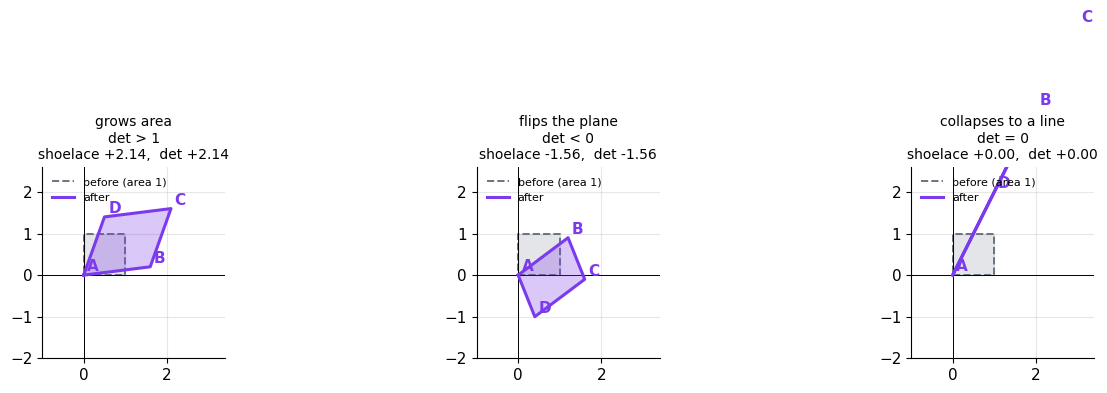

The collapsing matrix:
[[2. 1.]
 [4. 2.]]

its columns are [2. 4.] and [1. 2.] -- and the first is exactly 2 times the second,
so both columns point along ONE line. Part 5 said the output is a
mixture of the columns; if the columns lie on a line, so does every
possible output. The plane had nowhere else to go.

determinant : 0.00e+00
two different inputs, same output:
  Tsing @ [1. 0.] = [2. 4.]
  Tsing @ [0.5 1. ] = [2. 4.]
  equal? True  -- so you cannot tell,
  from the output, which of the two inputs you started with.


In [52]:
# Three determinants, seen: one that grows area, one that flips it, one that
# destroys it. Corners are labelled so the orientation flip is readable.
CASES = [("grows area\ndet > 1",  np.array([[1.6, 0.5], [0.2, 1.4]])),
         ("flips the plane\ndet < 0", np.array([[1.2, 0.4], [0.9, -1.0]])),
         ("collapses to a line\ndet = 0", np.array([[2., 1.], [4., 2.]]))]

fig, axes = plt.subplots(1, 3, figsize=(13.2, 4.6))
for ax, (name, T) in zip(axes, CASES):
    sq = T @ SQUARE
    ax.fill(np.append(SQUARE[0], SQUARE[0][0]), np.append(SQUARE[1], SQUARE[1][0]),
            color=C_GREY, alpha=0.18, zorder=1)
    ax.plot(np.append(SQUARE[0], SQUARE[0][0]), np.append(SQUARE[1], SQUARE[1][0]),
            color=C_GREY, lw=1.4, ls="--", zorder=2, label="before (area 1)")
    ax.fill(np.append(sq[0], sq[0][0]), np.append(sq[1], sq[1][0]),
            color=C_EXACT, alpha=0.28, zorder=3)
    ax.plot(np.append(sq[0], sq[0][0]), np.append(sq[1], sq[1][0]),
            color=C_EXACT, lw=2.2, zorder=4, label="after")
    for lab, corner in zip("ABCD", sq.T):
        ax.text(corner[0] + 0.09, corner[1] + 0.09, lab,
                color=C_EXACT, fontsize=11, fontweight="bold", zorder=5)
    ax.axhline(0, color="k", lw=0.7); ax.axvline(0, color="k", lw=0.7)
    ax.set_xlim(-1.0, 3.4); ax.set_ylim(-2.0, 2.6)
    ax.set_aspect("equal")
    ax.set_title(f"{name}\nshoelace {shoelace(T @ SQUARE):+.2f},  "
                 f"det {np.linalg.det(T):+.2f}", fontsize=10)
    ax.legend(frameon=False, fontsize=8, loc="upper left")
fig.tight_layout(); plt.show()

Tsing = CASES[2][1]
print("The collapsing matrix:"); print(Tsing)
print(f"\nits columns are {Tsing[:, 0]} and {Tsing[:, 1]} -- and the first is "
      f"exactly {Tsing[0, 0] / Tsing[0, 1]:g} times the second,")
print("so both columns point along ONE line. Part 5 said the output is a")
print("mixture of the columns; if the columns lie on a line, so does every")
print("possible output. The plane had nowhere else to go.")
print(f"\ndeterminant : {np.linalg.det(Tsing):.2e}")
print(f"two different inputs, same output:")
q1, q2 = np.array([1., 0.]), np.array([0.5, 1.])
print(f"  Tsing @ {q1} = {Tsing @ q1}")
print(f"  Tsing @ {q2} = {Tsing @ q2}")
print(f"  equal? {np.allclose(Tsing @ q1, Tsing @ q2)}  -- so you cannot tell,")
print("  from the output, which of the two inputs you started with.")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Three squares, each drawn dashed-grey before and solid-purple after, with the corners labelled A B C D so you can follow where each one went.

Left: the square became a bigger parallelogram, and its shoelace area matches the printed determinant. Middle: read the labels around the purple shape and they now run the other way round the outline — the plane was turned over, and the determinant is negative by exactly the amount the area grew. Right: there is no parallelogram at all. All four corners fell onto one line, area zero, determinant zero.

**The common misread:** reading a negative determinant as "negative area", or as something having gone wrong. Nothing went wrong; area is still $|\det|$ and the minus sign is carrying a separate piece of information — that left and right were swapped. A reflection has determinant $-1$ and changes no distances at all.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Where this trips people up

**A determinant of zero means information was destroyed, and that is permanent.**

In the right-hand panel, two different input points came out at the *same* output point — that was printed above. So given only the output, there is no way back: the question "which point did this come from?" has infinitely many answers.

This is the seed of Part 7. A matrix can be *undone* — inverted — exactly when it does not squash space flat, which is exactly when its determinant is not zero. And numerically the warning arrives early: a determinant that is merely *small* means space was nearly flattened, and undoing it amplifies every rounding error enormously. "Not exactly zero" is not the same as "safe".

</div>

### 6.4 Doing one after the other *is* multiplying the matrices

This is where Part 5's arithmetic and Part 6's pictures become the same thing.

Apply $\mathbf{B}$ to space, then apply $\mathbf{A}$ to the result. That whole
two-step motion is itself a motion of space, so it must have its own matrix.
Which one? The product $\mathbf{A}\mathbf{B}$ — and that is *why* matrix
multiplication is defined the way it is. The rule was reverse-engineered to
make this true.

Notice what this instantly explains. In Part 5 we found
$\mathbf{A}\mathbf{B} \neq \mathbf{B}\mathbf{A}$ and had to take it on the
arithmetic's word. Now it is obvious: those are two different sequences of
physical actions, and of course turning-then-stretching leaves the world in a
different state from stretching-then-turning.


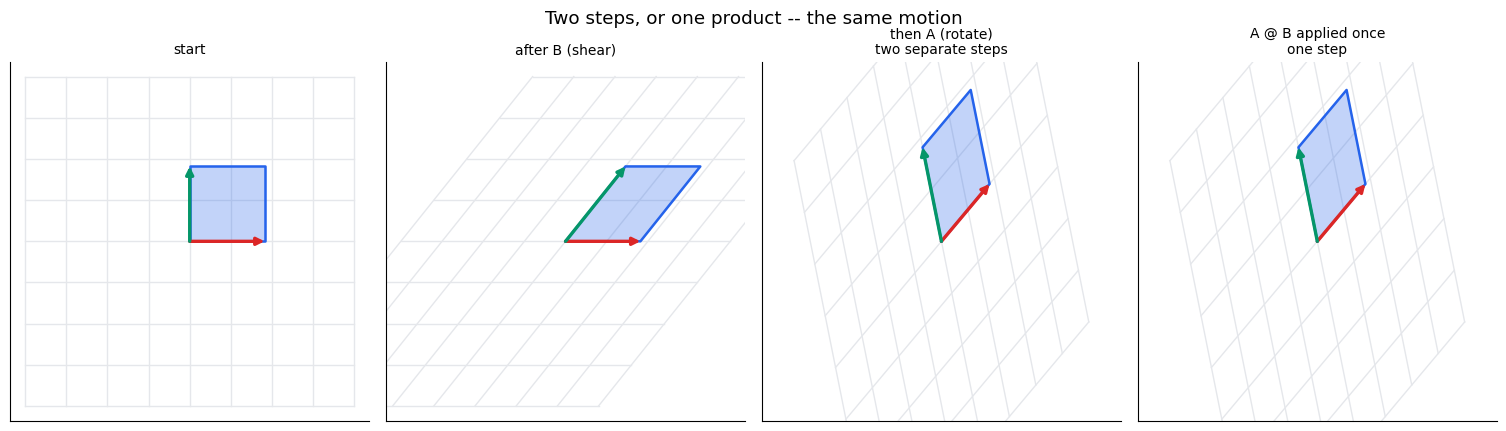

60 random points, pushed through B then A, vs through the product A@B:
  largest difference over all 120 coordinates: 8.88e-16

areas multiply too, because doing both scales area twice:
  det(B) = 1.0000
  det(A) = 1.0000
  det(A) * det(B)  = 1.0000
  det(A @ B)       = 1.0000

and the order still matters, now for an obvious reason:
  A @ B sends e1 to [0.64278761 0.76604444]
  B @ A sends e1 to [1.25562316 0.76604444]
  same matrix? False


In [53]:
Bsh = np.array([[1., 0.8], [0., 1.]])                 # a shear
ang2 = np.deg2rad(50.0)
Arot = np.array([[np.cos(ang2), -np.sin(ang2)],       # a rotation
                 [np.sin(ang2),  np.cos(ang2)]])

steps = [("start", np.eye(2)),
         ("after B (shear)", Bsh),
         ("then A (rotate)\ntwo separate steps", Arot @ Bsh),
         ("A @ B applied once\none step", Arot @ Bsh)]

fig, axes = plt.subplots(1, 4, figsize=(15.2, 4.3))
for ax, (name, T) in zip(axes, steps):
    transformed_grid(ax, T, extent=2.2, n_lines=9)
    sq = T @ SQUARE
    ax.fill(np.append(sq[0], sq[0][0]), np.append(sq[1], sq[1][0]),
            color=C_F, alpha=0.28, zorder=2)
    ax.plot(np.append(sq[0], sq[0][0]), np.append(sq[1], sq[1][0]),
            color=C_F, lw=1.8, zorder=3)
    arrow_from_to(ax, (0, 0), T @ e1, C_SLOPE)
    arrow_from_to(ax, (0, 0), T @ e2, C_AREA)
    ax.set_xlim(-2.4, 2.4); ax.set_ylim(-2.4, 2.4)
    ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    ax.set_title(name, fontsize=10)
fig.suptitle("Two steps, or one product -- the same motion", y=1.0)
fig.tight_layout(); plt.show()

pts = RNG6.normal(size=(2, 60))
two_at_a_time = Arot @ (Bsh @ pts)
one_product   = (Arot @ Bsh) @ pts
print(f"60 random points, pushed through B then A, vs through the product A@B:")
print(f"  largest difference over all 120 coordinates: "
      f"{np.abs(two_at_a_time - one_product).max():.2e}")

print(f"\nareas multiply too, because doing both scales area twice:")
print(f"  det(B) = {np.linalg.det(Bsh):.4f}")
print(f"  det(A) = {np.linalg.det(Arot):.4f}")
print(f"  det(A) * det(B)  = {np.linalg.det(Arot) * np.linalg.det(Bsh):.4f}")
print(f"  det(A @ B)       = {np.linalg.det(Arot @ Bsh):.4f}")

print(f"\nand the order still matters, now for an obvious reason:")
print(f"  A @ B sends e1 to {(Arot @ Bsh) @ e1}")
print(f"  B @ A sends e1 to {(Bsh @ Arot) @ e1}")
print(f"  same matrix? {np.allclose(Arot @ Bsh, Bsh @ Arot)}")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Four panels reading left to right. The first is the plane untouched. The second has been sheared — the vertical grid lines now lean. The third took that sheared plane and rotated the whole thing by fifty degrees. The fourth was made in a single step by the matrix `A @ B`, and it is pixel-for-pixel the third panel.

That identity is the entire content of matrix multiplication. The printed check pushes sixty random points through both routes and the largest disagreement is at rounding level. The determinants multiply for the same reason: if the first step multiplies areas by one factor and the second by another, doing both multiplies by the product.

**The common misread:** reading `A @ B` left-to-right as "A first". The matrix written **closest to the vector acts first**, so `A @ B @ v` means B, then A. It reads right to left, like function composition, because that is exactly what it is.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Where this trips people up

**$\mathbf{A}\mathbf{B} \neq \mathbf{B}\mathbf{A}$, and now you can see why rather than just remember it.** Swapping the product swaps the order of two physical actions, and the world ends up somewhere else.

Two useful consequences. First, when a chain of matrices is not doing what you expect, check the *order* before you check the entries — a reversed product is a far commoner bug than a wrong number. Second, determinants *do* commute even when matrices do not: $\det(\mathbf{A}\mathbf{B}) = \det(\mathbf{A})\det(\mathbf{B})$ either way round, because area scaling is just a number, and numbers commute.

</div>

### 6.5 Rotation matrices, derived rather than handed over

The rotation matrix is usually presented as a thing to memorise. It should not
be — 6.1 already gives you everything needed to *derive* it, and the derivation
is two lines.

To rotate the plane anticlockwise by an angle $\theta$, we only need the two
landing spots.

**Where does $\mathbf{e}_1 = (1,0)$ go?** It is a unit arrow along the $x$-axis.
Turn it by $\theta$ and it is a unit arrow at angle $\theta$ — which is the
definition of cosine and sine: it lands at $(\cos\theta,\ \sin\theta)$.

**Where does $\mathbf{e}_2 = (0,1)$ go?** $\mathbf{e}_2$ already sits at
$90°$, so after the turn it sits at $\theta + 90°$, landing at
$(\cos(\theta+90°),\ \sin(\theta+90°)) = (-\sin\theta,\ \cos\theta)$.

Stack those two destinations as columns and you have built it:

$$
\mathbf{R}(\theta) = \begin{bmatrix} \cos\theta & -\sin\theta \\ \sin\theta & \cos\theta \end{bmatrix}
$$

The minus sign, which is the part everyone misplaces, is not arbitrary: it is
$\cos(\theta + 90°) = -\sin\theta$, and you can regenerate it in five seconds
instead of remembering where it goes.


In [54]:
th = np.deg2rad(37.0)

# built from the two landing spots, using cos/sin of the SHIFTED angle for e2
land_e1 = np.array([np.cos(th),            np.sin(th)])
land_e2 = np.array([np.cos(th + np.pi/2),  np.sin(th + np.pi/2)])
R_built = np.column_stack([land_e1, land_e2])


def rot2(degrees):
    """The memorised formula, for comparison and for composing turns."""
    t = np.deg2rad(degrees)
    return np.array([[np.cos(t), -np.sin(t)],
                     [np.sin(t),  np.cos(t)]])


R_formula = rot2(37.0)

print("built from where e1 and e2 land:"); print(R_built.round(6))
print("\nthe formula everyone memorises:");  print(R_formula.round(6))
print(f"\nsame matrix? {np.allclose(R_built, R_formula)}")
print(f"and cos(theta+90) really is -sin(theta)? "
      f"{np.isclose(np.cos(th + np.pi/2), -np.sin(th))}")

# A rotation should change NOTHING except direction. Check that, do not assume it.
a = np.array([2.0, 0.5])
b = np.array([-1.0, 1.7])
Ra, Rb = R_built @ a, R_built @ b

print(f"\n{'':22}{'before':>12}{'after':>12}")
print(f"{'length of a':<22}{np.linalg.norm(a):>12.6f}{np.linalg.norm(Ra):>12.6f}")
print(f"{'length of b':<22}{np.linalg.norm(b):>12.6f}{np.linalg.norm(Rb):>12.6f}")
print(f"{'a . b (dot product)':<22}{a @ b:>12.6f}{Ra @ Rb:>12.6f}")
ang_before = np.degrees(np.arccos((a @ b) / (np.linalg.norm(a) * np.linalg.norm(b))))
ang_after  = np.degrees(np.arccos((Ra @ Rb) / (np.linalg.norm(Ra) * np.linalg.norm(Rb))))
print(f"{'angle between, degrees':<22}{ang_before:>12.6f}{ang_after:>12.6f}")

print(f"\ndeterminant (area unchanged, not flipped): {np.linalg.det(R_built):.6f}")
print(f"R.T @ R is the identity?  {np.allclose(R_built.T @ R_built, np.eye(2))}")
print(f"undoing a turn is turning back: R(-37) @ R(37) is the identity? "
      f"{np.allclose(rot2(-37.0) @ R_built, np.eye(2))}")
print(f"two turns add up: R(20) @ R(17) equals R(37)? "
      f"{np.allclose(rot2(20.0) @ rot2(17.0), R_formula)}")


built from where e1 and e2 land:
[[ 0.798636 -0.601815]
 [ 0.601815  0.798636]]

the formula everyone memorises:
[[ 0.798636 -0.601815]
 [ 0.601815  0.798636]]

same matrix? True
and cos(theta+90) really is -sin(theta)? True

                            before       after
length of a               2.061553    2.061553
length of b               1.972308    1.972308
a . b (dot product)      -1.150000   -1.150000
angle between, degrees  106.429301  106.429301

determinant (area unchanged, not flipped): 1.000000
R.T @ R is the identity?  True
undoing a turn is turning back: R(-37) @ R(37) is the identity? True
two turns add up: R(20) @ R(17) equals R(37)? True


<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🗣️ In plain words

**A rotation matrix is just its two landing spots written down.** Column 0 is where the $x$-axis arrow ends up, column 1 is where the $y$-axis arrow ends up, and both are read straight off the unit circle.

What makes rotations special is what they *preserve*: lengths and angles, hence dot products, hence shapes. A rotated cloud of data is the same cloud, seen from a different heading. Matrices with that property are called **orthogonal**, and their defining equation is the one checked above, $\mathbf{R}^T\mathbf{R} = \mathbf{I}$ — which says the inverse of a rotation is its transpose, an astonishingly cheap thing to know.

</div>

<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Checked, not asserted

The derived matrix and the memorised formula are identical entry by entry, so the derivation is not merely plausible — it reproduces the standard result. Then the *properties* were tested rather than asserted: both lengths, the dot product and the angle between two vectors survive the rotation to six decimal places; the determinant is $+1$, so no area change and no flip; $\mathbf{R}^T\mathbf{R}$ is the identity; and two rotations composed give the rotation by the summed angle, which is 6.4's composition rule agreeing with ordinary arithmetic on angles.

</div>

### 6.6 The whole flower bed, moved

Everything above was one square. Now do it to two hundred real data points with
a single `@`, as in Part 5.

One preparatory step: we **mean-centre** first, subtracting each column's
average. That is not decoration. A linear map always fixes the origin, so if
the data sits far from the origin, a rotation swings the entire cloud around a
distant point and you see translation rather than the shape change you are
trying to look at. Centring puts the data where the action is.


X centred: mean is now [0. 0.]  (shape (200, 2))


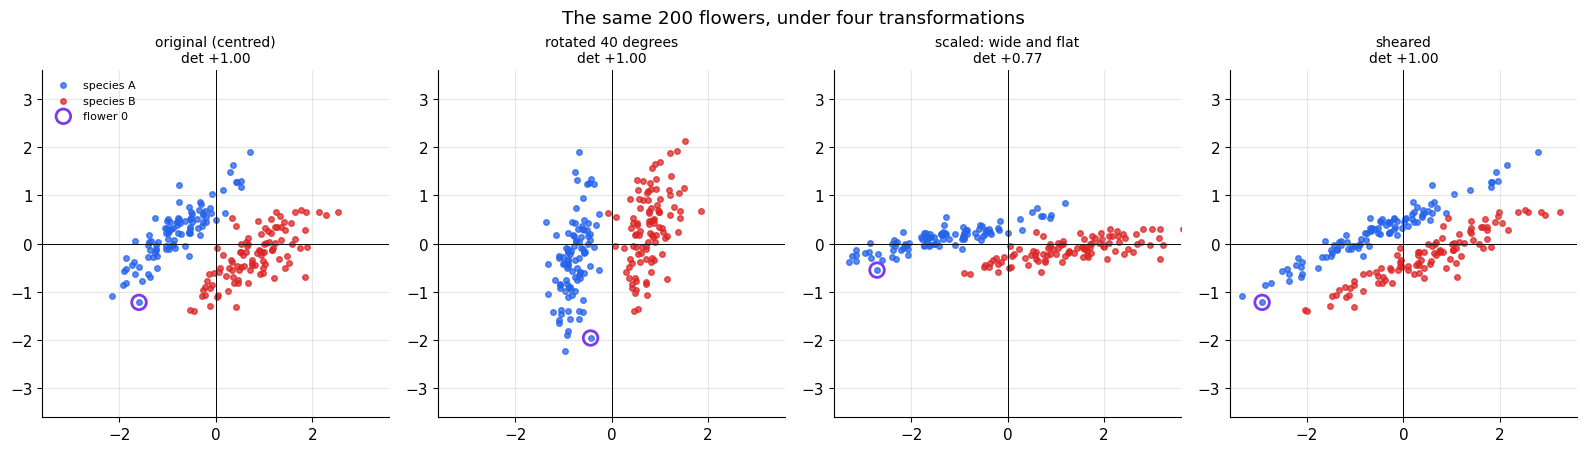

transformation                   flower 0 lands at   dist(0,1)  area factor
----------------------------------------------------------------------------
original (centred)                 [-1.592 -1.217]      1.3303        1.000
rotated 40 degrees                 [-0.438 -1.956]      1.3303        1.000
scaled: wide and flat              [-2.707 -0.547]      1.2239        0.765
sheared                            [-2.931 -1.217]      2.2494        1.000
----------------------------------------------------------------------------
rotation kept the distance between flowers 0 and 1 at 1.3303? True
the shear did not -- that distance became 2.2494

rotating back recovers every one of the 200 flowers? True  (max drift 4.44e-16)
flower 0 is still row 0, and its species is still 0 -- labels were never fed to a matrix, only coordinates were.


In [55]:
Xc = X - X.mean(axis=0)                    # mean-centred, so the origin is inside
print(f"X centred: mean is now {Xc.mean(axis=0).round(12)}  (shape {Xc.shape})")

rot   = np.array([[np.cos(np.deg2rad(40)), -np.sin(np.deg2rad(40))],
                  [np.sin(np.deg2rad(40)),  np.cos(np.deg2rad(40))]])
scal  = np.array([[1.7, 0.], [0., 0.45]])
shear = np.array([[1., 1.1], [0., 1.]])

VIEWS = [("original (centred)", np.eye(2)),
         ("rotated 40 degrees", rot),
         ("scaled: wide and flat", scal),
         ("sheared", shear)]

fig, axes = plt.subplots(1, 4, figsize=(16.0, 4.3))
for ax, (name, T) in zip(axes, VIEWS):
    moved = Xc @ T.T                        # Part 5.7: rows stay rows
    ax.scatter(*moved[species == 0].T, s=16, c=C_F,     alpha=0.75, label="species A")
    ax.scatter(*moved[species == 1].T, s=16, c=C_SLOPE, alpha=0.75, label="species B")
    ax.scatter(*moved[0], s=110, facecolor="none", edgecolor=C_EXACT, lw=2.0,
               zorder=5, label="flower 0")
    ax.axhline(0, color="k", lw=0.7); ax.axvline(0, color="k", lw=0.7)
    ax.set_xlim(-3.6, 3.6); ax.set_ylim(-3.6, 3.6)
    ax.set_aspect("equal")
    ax.set_title(f"{name}\ndet {np.linalg.det(T):+.2f}", fontsize=10)
    if name.startswith("original"):
        ax.legend(frameon=False, fontsize=8, loc="upper left")
fig.suptitle("The same 200 flowers, under four transformations", y=1.0)
fig.tight_layout(); plt.show()

d0 = np.linalg.norm(Xc[0] - Xc[1])
print(f"{'transformation':<24}{'flower 0 lands at':>26}{'dist(0,1)':>12}{'area factor':>13}")
print("-" * 76)
for name, T in VIEWS:
    moved = Xc @ T.T
    print(f"{name:<24}{str(moved[0].round(3)):>26}"
          f"{np.linalg.norm(moved[0] - moved[1]):>12.4f}"
          f"{abs(np.linalg.det(T)):>13.3f}")
print("-" * 76)
print(f"rotation kept the distance between flowers 0 and 1 at {d0:.4f}? "
      f"{np.isclose(np.linalg.norm((Xc @ rot.T)[0] - (Xc @ rot.T)[1]), d0)}")
print(f"the shear did not -- that distance became "
      f"{np.linalg.norm((Xc @ shear.T)[0] - (Xc @ shear.T)[1]):.4f}")

# nothing was lost: turn the rotated cloud back (6.5 -- a rotation's inverse
# is its transpose) and every flower is exactly where it started.
back = (Xc @ rot.T) @ rot
print(f"\nrotating back recovers every one of the {back.shape[0]} flowers? "
      f"{np.allclose(back, Xc)}  (max drift {np.abs(back - Xc).max():.2e})")
print(f"flower 0 is still row 0, and its species is still "
      f"{species[0]} -- labels were never fed to a matrix, only coordinates were.")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

The same two hundred flowers, four times over, with one flower ringed in purple so you can follow an individual through each motion.

Rotation turns the tilted cloud to a new heading but its shape is untouched — the printed distance between flowers 0 and 1 is unchanged, because rotations preserve lengths (6.5). Scaling stretches the cloud wide and squashes it flat, and its area shrinks by the determinant printed in the title. The shear slides the upper points sideways and changes distances while keeping area, since a shear has determinant 1.

Through all of it, every blue point stays blue. **A transformation changes the coordinates, not the identity.** Flower 0 is still flower 0, still the same specimen, just described by different numbers.

**The common misread:** believing the data "changed" — that some new information appeared or was lost. Under an invertible map nothing was gained or lost; the same 200 objects are being described in a different coordinate system, and you could undo it exactly (Part 7). It is only when the determinant hits zero that description turns into destruction.

</div>

In [56]:
# 1. y = Wx + b, geometrically: a linear motion, and THEN a shift.
Wl = np.array([[1.3, -0.5], [0.4, 0.9]])
bl = np.array([1.2, -0.8])

linear_only = Xc @ Wl.T
affine      = Xc @ Wl.T + bl

print(f"origin under the linear part alone : {Wl @ np.zeros(2)}  (it cannot move)")
print(f"origin under W x + b               : {Wl @ np.zeros(2) + bl}  (b moved it)")
print(f"cloud centre, linear only : {linear_only.mean(axis=0).round(4)}")
print(f"cloud centre, with b      : {affine.mean(axis=0).round(4)}")
print(f"the shift is exactly b?     "
      f"{np.allclose(affine.mean(axis=0) - linear_only.mean(axis=0), bl)}")
print(f"shape and area unchanged by b: det is still {np.linalg.det(Wl):.4f}, and")
print(f"  distance between flowers 0 and 1 with b: "
      f"{np.linalg.norm(affine[0] - affine[1]):.6f}  without b: "
      f"{np.linalg.norm(linear_only[0] - linear_only[1]):.6f}")

# 2. Two layers with nothing between them collapse into one.
W1 = np.array([[1.1, -0.6], [0.35, 0.8]])
W2 = np.array([[0.9,  0.7], [-0.5, 1.2]])
fused = W2 @ W1

print(f"\nW1 does one motion, det {np.linalg.det(W1):+.4f}")
print(f"W2 does another,     det {np.linalg.det(W2):+.4f}")
print(f"W2 @ W1 is a single 2x2 matrix:"); print(fused.round(4))
print(f"det of the fused matrix {np.linalg.det(fused):+.4f}, which is the "
      f"product {np.linalg.det(W1) * np.linalg.det(W2):+.4f}")
print(f"\nall 200 flowers, two layers vs one fused layer: max difference "
      f"{np.abs((Xc @ W1.T) @ W2.T - Xc @ fused.T).max():.2e}")

# ten layers, same story
deep = np.eye(2)
for k in range(10):
    deep = RNG6.normal(size=(2, 2)) @ deep
print(f"ten linear layers multiplied together are still a "
      f"{deep.shape[0]}x{deep.shape[1]} matrix -- one transformation:")
print(deep.round(3))


origin under the linear part alone : [0. 0.]  (it cannot move)
origin under W x + b               : [ 1.2 -0.8]  (b moved it)
cloud centre, linear only : [0. 0.]
cloud centre, with b      : [ 1.2 -0.8]
the shift is exactly b?     True
shape and area unchanged by b: det is still 1.3700, and
  distance between flowers 0 and 1 with b: 1.331429  without b: 1.331429

W1 does one motion, det +1.0900
W2 does another,     det +1.4300
W2 @ W1 is a single 2x2 matrix:
[[ 1.235  0.02 ]
 [-0.13   1.26 ]]
det of the fused matrix +1.5587, which is the product +1.5587

all 200 flowers, two layers vs one fused layer: max difference 4.44e-16
ten linear layers multiplied together are still a 2x2 matrix -- one transformation:
[[-0.169  0.101]
 [ 0.728 -0.43 ]]


<div style="background-color: #f8d7da; border-left: 5px solid #dc3545; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🤖 Why ML cares

**`y = Wx + b` is a motion plus a shift, and now you can see both halves.**

`W` is everything in this part: it turns, stretches, shears and possibly flattens the cloud, and its determinant says what it does to volume. `b` does the one thing `W` cannot — it moves the origin. That is why the bias is a separate term rather than more matrix: a matrix always sends $\mathbf{0}$ to $\mathbf{0}$, so without `b` every layer would be nailed to the origin. The printout confirms `b` slides the cloud bodily without changing a single distance inside it.

So a layer *reshapes the space the data lives in*, and then repositions it. Training is the search for the reshaping that makes the next layer's job easy.

</div>

<div style="background-color: #f8d7da; border-left: 5px solid #dc3545; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🤖 Why ML cares

**And here is why activation functions are not optional.**

Two linear layers in a row were shown above to be *exactly* one linear layer whose matrix is `W2 @ W1` — the same answer on all 200 flowers, to rounding. Ten of them fused into a single 2×2 matrix. Depth without non-linearity buys nothing at all: whatever a hundred stacked matrices can do, one matrix can already do, because 6.4 says composition *is* multiplication and the product of matrices is a matrix.

Sticking a non-linear function (ReLU, tanh, …) between the layers breaks the composition — the sandwich is no longer a single matrix, and there is no product to fuse. **That is the entire reason it is there.** Every real capability of a deep network lives in the bends that stop it collapsing back into this part's picture.

</div>

---

### What you have, going into Part 7

- A matrix is **a motion of space**: grid lines stay straight and parallel, and
  the origin never moves.
- It is completely determined by **where it sends the basis vectors**, and it
  stores those two destinations as its **columns**. Read the columns, predict
  the picture.
- The **determinant** is the factor areas get multiplied by; its sign says
  whether space was turned over.
- **Composing** two transformations is **multiplying** their matrices — which
  is where the multiplication rule came from in the first place, and why order
  matters.
- Rotations are built from where $\mathbf{e}_1$ and $\mathbf{e}_2$ land on the
  unit circle, and they preserve every length and angle.

And one thing left hanging. When the determinant was zero, two different inputs
produced the same output, and the picture collapsed onto a line. Everywhere
else, the motion could in principle be reversed — turn back, stretch back, and
you are home.

That is the question Part 7 asks properly: **given where a point ended up, can
you work out where it started?** That is solving a linear system, the reverse
motion is the inverse matrix, and the determinant already told us when to
expect trouble.


---

# 7️⃣ Systems, inverses, and when they fail

Part 6 handed you a machine. A matrix $\mathbf{A}$ takes an input vector
$\mathbf{x}$, and out comes an output vector $\mathbf{A}\mathbf{x}$ — stretched,
rotated, sheared. We pressed the button and watched what came out.

This part presses the button **backwards**.

> You are shown the output. Which input produced it?

Written down, that question is
$$\mathbf{A}\mathbf{x} = \mathbf{b}$$
where $\mathbf{A}$ is the known transformation, $\mathbf{b}$ is the known output,
and $\mathbf{x}$ — the unknown — is the input we are hunting for. That is what
people mean by a **linear system**, and it is the single most-solved problem in
all of computing.

The first half of this part answers it. The second half is the important half:
**sometimes there is no answer, sometimes there are infinitely many, and
sometimes the honest answer is "the question destroyed the information needed to
answer it."** Recognising those cases is worth more than any solving technique,
because every one of them shows up in machine learning wearing a disguise.


<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🗣️ In plain words

$\mathbf{A}\mathbf{x} = \mathbf{b}$ says: **which input, fed through the transformation $\mathbf{A}$, comes out as $\mathbf{b}$?**

Three names, three roles:

- $\mathbf{A}$ — the **machine**. Known. A square grid of numbers that does something to space.
- $\mathbf{b}$ — the **output you were given**. Known. A vector.
- $\mathbf{x}$ — the **input you want back**. Unknown. A vector.

The same thing written as school algebra is a set of simultaneous equations, one per row of $\mathbf{A}$. Those two things — a matrix equation and a set of simultaneous equations — are not related ideas. They are the *same sentence* written twice.

</div>

## The row picture: each equation is a line

Take a concrete machine and a concrete output. Reading $\mathbf{A}\mathbf{x} =
\mathbf{b}$ one **row** at a time gives one ordinary equation per row, and each
of those equations is a straight line on the page. The solution is a point that
sits on *all* of them at once — so, for two equations, the crossing point.


A =
 [[2. 1.]
 [1. 3.]]
b = [4. 7.]

Read row by row, A x = b is these two ordinary equations:
   row 1:   2*x + 1*y = 4
   row 2:   1*x + 3*y = 7


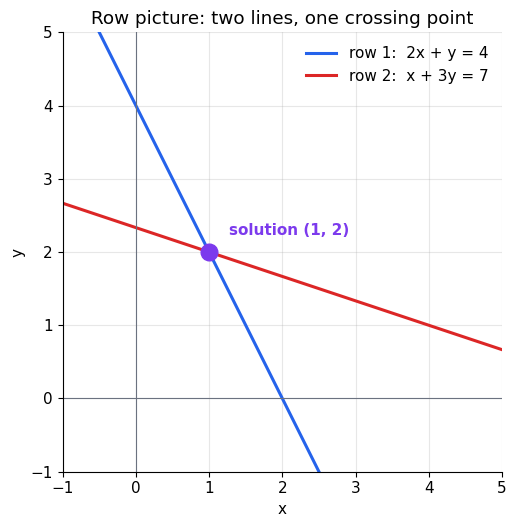


The crossing point is x = [1. 2.]
Check it satisfies BOTH equations:  A @ x = [4. 7.]   (b = [4. 7.])


In [57]:
# ============================================================
#  The machine A, the output b, and the input we must recover.
# ============================================================
A = np.array([[2.0, 1.0],
              [1.0, 3.0]])
b = np.array([4.0, 7.0])

print("A =\n", A)
print("b =", b)
print()
print("Read row by row, A x = b is these two ordinary equations:")
print(f"   row 1:   {A[0,0]:.0f}*x + {A[0,1]:.0f}*y = {b[0]:.0f}")
print(f"   row 2:   {A[1,0]:.0f}*x + {A[1,1]:.0f}*y = {b[1]:.0f}")

# Draw each equation as a line: solve each one for y across a range of x.
xs = np.linspace(-1, 5, 200)
line1 = (b[0] - A[0, 0] * xs) / A[0, 1]      # from row 1
line2 = (b[1] - A[1, 0] * xs) / A[1, 1]      # from row 2

fig, ax = plt.subplots(figsize=(6.0, 5.4))
ax.plot(xs, line1, color=C_F,     lw=2.2, label="row 1:  2x + y = 4")
ax.plot(xs, line2, color=C_SLOPE, lw=2.2, label="row 2:  x + 3y = 7")

sol = np.linalg.solve(A, b)                  # the crossing point
ax.plot(*sol, "o", ms=12, color=C_EXACT, zorder=5)
ax.annotate(f"solution ({sol[0]:.0f}, {sol[1]:.0f})", sol, textcoords="offset points",
            xytext=(14, 12), color=C_EXACT, fontsize=11, fontweight="bold")

ax.axhline(0, color=C_GREY, lw=0.8); ax.axvline(0, color=C_GREY, lw=0.8)
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.set_title("Row picture: two lines, one crossing point")
ax.set_aspect("equal"); ax.legend(frameon=False, loc="upper right")
ax.set_xlim(-1, 5); ax.set_ylim(-1, 5)
fig.tight_layout(); plt.show()

print()
print(f"The crossing point is x = {sol.round(6)}")
print(f"Check it satisfies BOTH equations:  A @ x = {(A @ sol).round(6)}   (b = {b})")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Each row of the system, drawn as the line of all points satisfying it. Every point on the blue line satisfies the first equation and ignores the second; every point on the red line does the reverse. Only where they cross does a single pair of numbers satisfy both at once — and the printed check confirms that point really does reproduce `b`.

This is the picture almost everyone is taught, and it is genuinely useful for two unknowns. **The common misread:** believing it scales. With three unknowns each equation becomes a *plane* and you are asked to picture three planes meeting at a point; with a hundred unknowns the picture is gone entirely, and with it your intuition. The next picture — the column picture — never stops working, which is why it is the one to internalise.

</div>

## The column picture: which mix of the columns reaches $\mathbf{b}$?

Part 5 showed that $\mathbf{A}\mathbf{x}$ is a **weighted sum of the columns of
$\mathbf{A}$**, with the entries of $\mathbf{x}$ as the weights:

$$\mathbf{A}\mathbf{x} \;=\; x_1 \begin{bmatrix}A_{11}\\A_{21}\end{bmatrix}
\;+\; x_2 \begin{bmatrix}A_{12}\\A_{22}\end{bmatrix}$$

So $\mathbf{A}\mathbf{x} = \mathbf{b}$ is asking something you can *see*:

> I have two arrows — the columns of $\mathbf{A}$. **How much of each do I need
> so that, laid tip-to-tail, they land exactly on $\mathbf{b}$?**

The unknowns stop being abstract. They are the two dial settings on two arrows.


column 1 of A:  c1 = [2. 1.]
column 2 of A:  c2 = [1. 3.]
weights from x: x1 = 1,  x2 = 2
x1*c1 + x2*c2 = [4. 7.]      b = [4. 7.]
identical? True


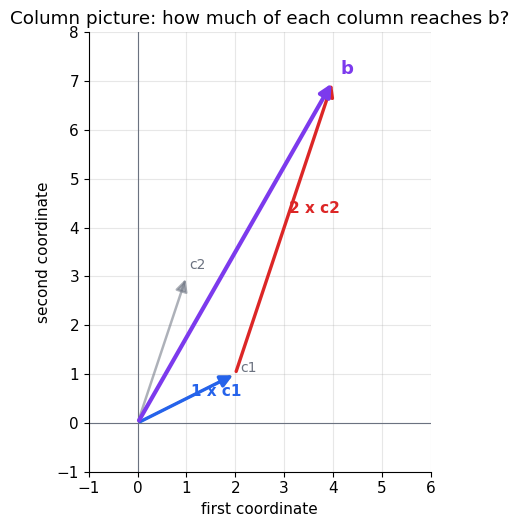

In [58]:
c1, c2 = A[:, 0], A[:, 1]        # the two columns, as arrows
x1, x2 = sol                     # the amounts of each, found above

print(f"column 1 of A:  c1 = {c1}")
print(f"column 2 of A:  c2 = {c2}")
print(f"weights from x: x1 = {x1:.0f},  x2 = {x2:.0f}")
print(f"x1*c1 + x2*c2 = {(x1 * c1 + x2 * c2)}      b = {b}")
print(f"identical? {np.allclose(x1 * c1 + x2 * c2, b)}")

fig, ax = plt.subplots(figsize=(6.0, 5.4))


def arrow(ax, start, vec, color, label=None, lw=2.4, alpha=1.0, ls="-"):
    ax.annotate("", xy=np.add(start, vec), xytext=start,
                arrowprops=dict(arrowstyle="-|>", lw=lw, color=color,
                                alpha=alpha, linestyle=ls, mutation_scale=18))
    if label:
        mid = np.add(start, np.multiply(vec, 0.55))
        ax.text(*mid, label, color=color, fontsize=11, fontweight="bold")


# the raw columns, at the origin
arrow(ax, (0, 0), c1, C_GREY, alpha=0.55, lw=1.8)
arrow(ax, (0, 0), c2, C_GREY, alpha=0.55, lw=1.8)
ax.text(*(c1 * 1.05), "c1", color=C_GREY, fontsize=10)
ax.text(*(c2 * 1.05), "c2", color=C_GREY, fontsize=10)

# the recipe, tip to tail
arrow(ax, (0, 0), x1 * c1, C_F, f"{x1:.0f} x c1")
arrow(ax, x1 * c1, x2 * c2, C_SLOPE, f"{x2:.0f} x c2")
arrow(ax, (0, 0), b, C_EXACT, lw=3.0)
ax.text(*(b + np.array([0.15, 0.15])), "b", color=C_EXACT,
        fontsize=13, fontweight="bold")

ax.axhline(0, color=C_GREY, lw=0.8); ax.axvline(0, color=C_GREY, lw=0.8)
ax.set_xlabel("first coordinate"); ax.set_ylabel("second coordinate")
ax.set_title("Column picture: how much of each column reaches b?")
ax.set_aspect("equal"); ax.set_xlim(-1, 6); ax.set_ylim(-1, 8)
fig.tight_layout(); plt.show()


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

The same system, seen as arrows instead of lines. The two faint grey arrows are the columns of `A` — the only two directions available. The blue arrow is the first column taken the printed number of times, the red arrow continues from its tip with the second column, and the purple arrow is `b`. The chain lands exactly on `b`, which is what the printed `identical? True` asserts numerically.

**Solving a system is finding that recipe.** And unlike the row picture, this survives dimensions you cannot draw: with a thousand columns you can still say the sentence "how much of each column do I need", and it still means exactly this.

**The common misread:** treating the two pictures as alternative techniques and picking a favourite. They are one system looked at from two sides — rows are constraints to satisfy, columns are ingredients to mix. The failures later in this part are *obvious* in the column picture and nearly invisible in the row one.

</div>

## Solving it by hand: elimination

Here is the entire method, and it rests on one permission slip:

> **You may add a multiple of one equation to another without changing the
> solution set.** If a pair $(x, y)$ satisfied both equations before, it still
> satisfies both after — because you only added a true statement to a true
> statement.

Use that permission to *delete* an unknown. Our system:

$$\begin{aligned} 2x + \phantom{3}y &= 4 \\ \phantom{2}x + 3y &= 7 \end{aligned}$$

**Step 1 — kill $x$ in row 2.** Row 2 has $1x$, row 1 has $2x$, so subtract
$\tfrac{1}{2}$ of row 1 from row 2. That multiplier, $\tfrac{1}{2}$, is the only
number you have to *choose*, and it is chosen precisely to make the $x$ term
vanish:

$$\text{row 2} - \tfrac{1}{2}\,\text{row 1}:\qquad
\left(1 - \tfrac{1}{2}\cdot 2\right)x + \left(3 - \tfrac{1}{2}\cdot 1\right)y
= 7 - \tfrac{1}{2}\cdot 4$$

which is $0x + 2.5y = 5$.

**Step 2 — one unknown, one equation.** $2.5y = 5$, so $y = 5 / 2.5 = 2$.

**Step 3 — back-substitute.** Put that $y$ into row 1: $2x + 2 = 4$, so
$2x = 2$ and $x = 1$.

That is it. Every general-purpose linear solver on Earth is this, with
bookkeeping for size and for numerical care. Let us run the steps as code and
watch the numbers land where the algebra says they will.


In [59]:
# ============================================================
#  Elimination, one step at a time, nothing hidden.
# ============================================================
r1 = np.array([A[0, 0], A[0, 1], b[0]])   # [coeff of x, coeff of y, right side]
r2 = np.array([A[1, 0], A[1, 1], b[1]])
print(f"start      row1 = {r1},  row2 = {r2}")

# Step 1: choose the multiplier that annihilates x in row 2.
m = r2[0] / r1[0]
print(f"\nstep 1     multiplier m = row2[x] / row1[x] = {r2[0]:.0f} / {r1[0]:.0f} = {m}")
r2_new = r2 - m * r1
print(f"           row2 - m*row1 = {r2_new}")
print(f"           the x term is now {r2_new[0]:.0f} -- x has been eliminated")

# Step 2: one equation, one unknown.
y = r2_new[2] / r2_new[1]
print(f"\nstep 2     {r2_new[1]}*y = {r2_new[2]}   ->   y = {r2_new[2]} / {r2_new[1]} = {y}")

# Step 3: back-substitute into row 1.
x = (r1[2] - r1[1] * y) / r1[0]
print(f"\nstep 3     {r1[0]:.0f}*x + {r1[1]:.0f}*({y}) = {r1[2]:.0f}"
      f"   ->   x = {x}")

by_hand = np.array([x, y])
by_numpy = np.linalg.solve(A, b)

print("\n" + "-" * 58)
print(f"by hand           x = {by_hand}")
print(f"np.linalg.solve   x = {by_numpy}")
print(f"agree to 1e-12?     {np.allclose(by_hand, by_numpy, atol=1e-12)}")
print(f"largest difference: {np.abs(by_hand - by_numpy).max():.2e}")
print(f"\nand it really solves the system: A @ x = {(A @ by_hand)}   (b = {b})")
print(f"residual ||A x - b|| = {np.linalg.norm(A @ by_hand - b):.2e}")


start      row1 = [2. 1. 4.],  row2 = [1. 3. 7.]

step 1     multiplier m = row2[x] / row1[x] = 1 / 2 = 0.5
           row2 - m*row1 = [0.  2.5 5. ]
           the x term is now 0 -- x has been eliminated

step 2     2.5*y = 5.0   ->   y = 5.0 / 2.5 = 2.0

step 3     2*x + 1*(2.0) = 4   ->   x = 1.0

----------------------------------------------------------
by hand           x = [1. 2.]
np.linalg.solve   x = [1. 2.]
agree to 1e-12?     True
largest difference: 0.00e+00

and it really solves the system: A @ x = [4. 7.]   (b = [4. 7.])
residual ||A x - b|| = 0.00e+00


<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Checked, not asserted

The hand derivation above was written out in prose *before* the cell ran, and the cell reproduces every intermediate number in it: the multiplier, the eliminated row, the value of `y`, the back-substituted `x`.

Then the same system goes to `np.linalg.solve`, which uses a far more careful implementation of the same idea, and the two answers agree to better than `1e-12`. Finally the answer is pushed back through the machine — `A @ x` — and lands on `b` with a residual at the level of floating-point noise.

So the method is not being asserted at you. It is being *run*, and it is the same method the library uses.

</div>

## The inverse: a machine that undoes the machine

Elimination solves one system. But if $\mathbf{A}$ is fixed and you expect many
different outputs $\mathbf{b}$, it is natural to want the *undo button itself* —
a transformation that takes any output back to the input that produced it.

That is the **inverse**, written $\mathbf{A}^{-1}$ and said "A inverse". It is
defined by exactly one property:

$$\mathbf{A}^{-1}\mathbf{A} = \mathbf{A}\,\mathbf{A}^{-1} = \mathbf{I}$$

where $\mathbf{I}$ is the **identity matrix** — ones down the diagonal, zeros
elsewhere — the transformation that does nothing at all. In words: *do
$\mathbf{A}$, then do $\mathbf{A}^{-1}$, and you are back where you started.*

Given that, solving is one line of algebra:

$$\mathbf{A}\mathbf{x} = \mathbf{b}
\;\;\Longrightarrow\;\;
\mathbf{A}^{-1}\mathbf{A}\mathbf{x} = \mathbf{A}^{-1}\mathbf{b}
\;\;\Longrightarrow\;\;
\mathbf{x} = \mathbf{A}^{-1}\mathbf{b}$$

For a $2 \times 2$ matrix there is a closed formula, and look what is sitting in
the denominator:

$$\mathbf{A} = \begin{bmatrix} a & b \\ c & d \end{bmatrix}
\qquad
\mathbf{A}^{-1} = \frac{1}{ad - bc}\begin{bmatrix} d & -b \\ -c & a \end{bmatrix}$$

$ad - bc$ is the **determinant** from Part 6 — the factor by which $\mathbf{A}$
scales area. It divides everything. Hold that thought for about two cells.


<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🗣️ In plain words

**Identity matrix $\mathbf{I}$** — the do-nothing transformation. $\mathbf{I}\mathbf{v} = \mathbf{v}$ for every $\mathbf{v}$. It is the number 1, promoted to matrices.

**Inverse $\mathbf{A}^{-1}$** — the transformation that puts everything back. If $\mathbf{A}$ rotates by thirty degrees, $\mathbf{A}^{-1}$ rotates back by thirty degrees. If $\mathbf{A}$ doubles everything, $\mathbf{A}^{-1}$ halves it.

**The 2x2 formula in words** — swap the two diagonal entries, flip the sign of the other two, then divide the whole thing by the determinant.

**And the warning built into it** — if the determinant is zero you are dividing by zero, and there is no inverse. Not "it is hard to compute". It does not exist.

</div>

In [60]:
# ============================================================
#  Build the inverse from the 2x2 formula, then check it.
# ============================================================
# name the four entries a, b, c, d as in the formula -- but with an 11/12/21/22
# suffix, because plain `b` is already the output vector of our system.
(a11, a12), (a21, a22) = A
det = a11 * a22 - a12 * a21

A_inv_formula = (1.0 / det) * np.array([[ a22, -a12],
                                        [-a21,  a11]])
A_inv_numpy = np.linalg.inv(A)

print(f"det(A) = a*d - b*c = {a11:.0f}*{a22:.0f} - {a12:.0f}*{a21:.0f} = {det:.0f}")
print(f"np.linalg.det(A)   = {np.linalg.det(A):.6f}\n")
print("A_inv by the formula:\n", A_inv_formula.round(6))
print("\nnp.linalg.inv(A):\n", A_inv_numpy.round(6))
print(f"\nsame matrix? {np.allclose(A_inv_formula, A_inv_numpy)}")

I2 = np.eye(2)
print("\nA @ A_inv =\n", (A @ A_inv_formula).round(12))
print("A_inv @ A =\n", (A_inv_formula @ A).round(12))
print(f"\nboth equal the identity? "
      f"{np.allclose(A @ A_inv_formula, I2) and np.allclose(A_inv_formula @ A, I2)}")

x_via_inverse = A_inv_formula @ b
print(f"\nx = A_inv @ b   = {x_via_inverse.round(12)}")
print(f"x = solve(A, b) = {np.linalg.solve(A, b).round(12)}")
print(f"agree? {np.allclose(x_via_inverse, np.linalg.solve(A, b))}")


det(A) = a*d - b*c = 2*3 - 1*1 = 5
np.linalg.det(A)   = 5.000000

A_inv by the formula:
 [[ 0.6 -0.2]
 [-0.2  0.4]]

np.linalg.inv(A):
 [[ 0.6 -0.2]
 [-0.2  0.4]]

same matrix? True

A @ A_inv =
 [[1. 0.]
 [0. 1.]]
A_inv @ A =
 [[1. 0.]
 [0. 1.]]

both equal the identity? True

x = A_inv @ b   = [1. 2.]
x = solve(A, b) = [1. 2.]
agree? True


<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Checked, not asserted

Three separate claims, all confirmed by the printed output rather than by assertion:

1. The hand formula `(1/det) * [[d, -b], [-c, a]]` produces the *same matrix* `np.linalg.inv` does.
2. That matrix satisfies the defining property in both orders — `A @ A_inv` and `A_inv @ A` are both the identity, to twelve decimal places.
3. Multiplying `b` by it recovers the same `x` that elimination and `np.linalg.solve` found.

The determinant printed by hand also matches `np.linalg.det`, which matters for the next section: everything about invertibility is about to hinge on that one number.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Where this trips people up

**Do not compute an inverse in order to solve a system.**

`x = np.linalg.inv(A) @ b` and `x = np.linalg.solve(A, b)` are mathematically the same answer, and the second is the one to write — always. Not as a style preference. For three reasons:

- **It is slower.** Forming an inverse does roughly the work of solving the system several times over, then you still have to do a matrix-vector multiply.
- **It is less accurate.** Every entry of the computed inverse carries rounding error, and multiplying by it spreads that error into every entry of your answer. `solve` never forms the intermediate object, so it never accumulates the error. The conditioning section below makes this measurable.
- **It fails less informatively.** `solve` on a singular matrix tells you the system is singular. An inverse formed carelessly on a *nearly* singular matrix returns enormous numbers with no complaint at all, and your program continues happily with garbage.

The inverse is a superb thing to *think* with — it is what "undo" means. It is a poor thing to *compute*. Keep those two facts separate and you will not write this bug.

</div>

## When it fails — the important half

Everything so far assumed the question had exactly one answer. It need not.

For two unknowns there are precisely three possibilities, and it is worth
knowing that the list is *complete* — there is no fourth case hiding anywhere:

| Case | Row picture | Column picture | Determinant |
|---|---|---|---|
| **One solution** | lines cross once | the two columns point in genuinely different directions, so any $\mathbf{b}$ is reachable, one way | non-zero |
| **No solution** | lines are parallel and distinct | both columns lie along one direction, and $\mathbf{b}$ is off that direction — unreachable | zero |
| **Infinitely many** | lines are identical | both columns lie along one direction, and $\mathbf{b}$ happens to lie on it too — reachable in endlessly many ways | zero |

The two failures share a cause: **the two columns stopped being genuinely
different directions.** When that happens the transformation squashes the whole
plane onto a single line — Part 6's picture of a zero determinant — and the
question "which input produced this output?" either has no answer or has too
many, depending purely on whether $\mathbf{b}$ landed on that line.

Such a matrix is called **singular**. Let us build all three cases and look.


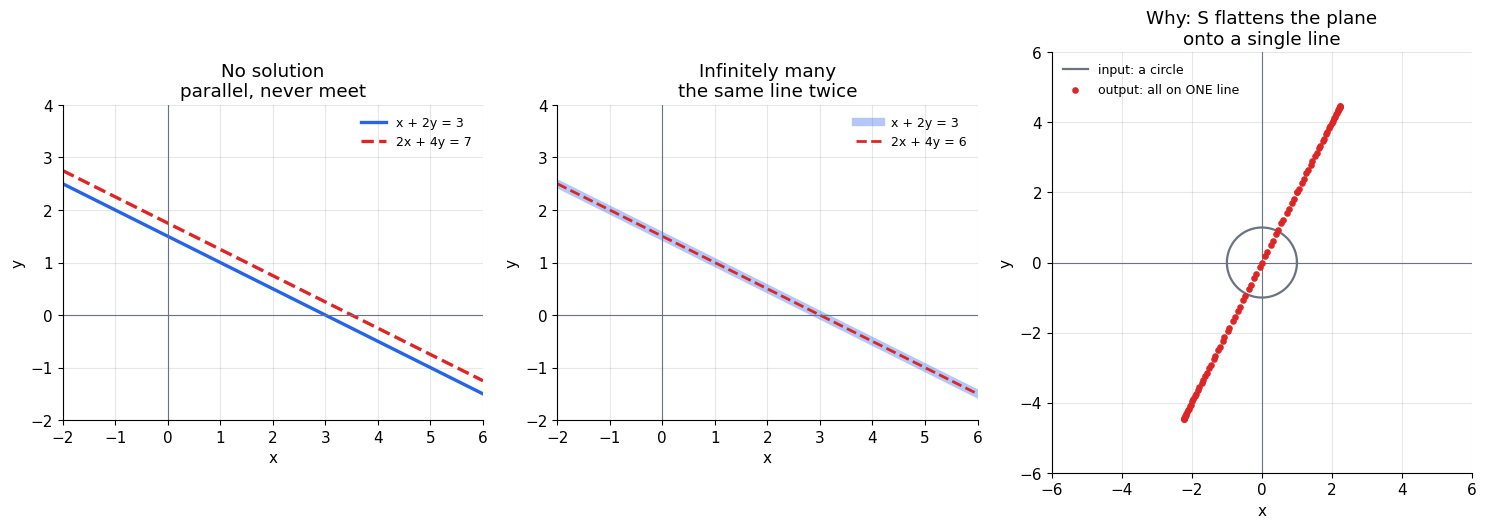

S =
 [[1. 2.]
 [2. 4.]]

det(S) = 0.0e+00      (the plane's area is scaled to zero)
rank(S) = 1   (only ONE independent direction survives)
column 2 is exactly 2 x column 1: True

--- asking for the inverse ---
np.linalg.inv(S) raised LinAlgError: Singular matrix

--- the two failures, told apart by rank ---
no solution   : b = [3. 7.],  rank(S) = 1, rank([S|b]) = 2
                 np.linalg.solve -> LinAlgError: Singular matrix
infinitely many: b = [3. 6.],  rank(S) = 1, rank([S|b]) = 1
                 np.linalg.solve -> LinAlgError: Singular matrix


In [61]:
# ============================================================
#  Three systems. Same singular matrix S for the last two.
# ============================================================
S = np.array([[1.0, 2.0],
              [2.0, 4.0]])          # row 2 is exactly 2 x row 1 -- singular
b_none = np.array([3.0, 7.0])       # 7 is NOT 2 x 3  -> no solution
b_many = np.array([3.0, 6.0])       # 6 IS  2 x 3     -> infinitely many

xs = np.linspace(-2, 6, 200)
fig, axes = plt.subplots(1, 3, figsize=(15, 5.0))

# ---- panel 1: parallel, distinct  (no solution)
ax = axes[0]
ax.plot(xs, (b_none[0] - S[0, 0] * xs) / S[0, 1], color=C_F,     lw=2.4,
        label="x + 2y = 3")
ax.plot(xs, (b_none[1] - S[1, 0] * xs) / S[1, 1], color=C_SLOPE, lw=2.4,
        ls="--", label="2x + 4y = 7")
ax.set_title("No solution\nparallel, never meet")
ax.legend(frameon=False, fontsize=9, loc="upper right")

# ---- panel 2: identical  (infinitely many)
ax = axes[1]
ax.plot(xs, (b_many[0] - S[0, 0] * xs) / S[0, 1], color=C_F, lw=6.0, alpha=0.35,
        label="x + 2y = 3")
ax.plot(xs, (b_many[1] - S[1, 0] * xs) / S[1, 1], color=C_SLOPE, lw=2.0,
        ls="--", label="2x + 4y = 6")
ax.set_title("Infinitely many\nthe same line twice")
ax.legend(frameon=False, fontsize=9, loc="upper right")

# ---- panel 3: the transformation itself, collapsing the plane
ax = axes[2]
th = np.linspace(0, 2 * np.pi, 90)
circle = np.stack([np.cos(th), np.sin(th)])         # 2 x 90 unit vectors
imgs = S @ circle                                   # where they all land
ax.plot(*circle, color=C_GREY, lw=1.6, label="input: a circle")
ax.scatter(*imgs, s=14, color=C_SLOPE, zorder=4, label="output: all on ONE line")
ax.set_title("Why: S flattens the plane\nonto a single line")
ax.legend(frameon=False, fontsize=9, loc="upper left")

for ax in axes:
    ax.axhline(0, color=C_GREY, lw=0.8); ax.axvline(0, color=C_GREY, lw=0.8)
    ax.set_aspect("equal"); ax.set_xlabel("x"); ax.set_ylabel("y")
axes[0].set_xlim(-2, 6); axes[0].set_ylim(-2, 4)
axes[1].set_xlim(-2, 6); axes[1].set_ylim(-2, 4)
axes[2].set_xlim(-6, 6); axes[2].set_ylim(-6, 6)
fig.tight_layout(); plt.show()

print("S =\n", S)
print(f"\ndet(S) = {np.linalg.det(S):.1e}      (the plane's area is scaled to zero)")
print(f"rank(S) = {np.linalg.matrix_rank(S)}   (only ONE independent direction survives)")
print(f"column 2 is exactly {S[1,1]/S[0,1]:.0f} x column 1: "
      f"{np.allclose(S[:,1], (S[1,1]/S[0,1]) * S[:,0])}")

print("\n--- asking for the inverse ---")
try:
    np.linalg.inv(S)
except np.linalg.LinAlgError as e:
    print(f"np.linalg.inv(S) raised LinAlgError: {e}")

print("\n--- the two failures, told apart by rank ---")
for name, bv in [("no solution   ", b_none), ("infinitely many", b_many)]:
    aug = np.column_stack([S, bv])                # the augmented matrix [S | b]
    print(f"{name}: b = {bv},  rank(S) = {np.linalg.matrix_rank(S)}, "
          f"rank([S|b]) = {np.linalg.matrix_rank(aug)}")
    try:
        np.linalg.solve(S, bv)
    except np.linalg.LinAlgError as e:
        print(f"                 np.linalg.solve -> LinAlgError: {e}")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Left: two parallel lines. There is no point on both, so the system has no solution — and no amount of cleverness will produce one, because none exists. Middle: the two equations describe the *same* line, drawn thick and dashed so you can see one sitting on the other; every point on it is a solution, so there are infinitely many. Right: the reason for both. The grey circle is a ring of input vectors; the red dots are where `S` sends them, and they all land on a single line. `S` flattened the plane.

That third panel is the whole explanation. Once the plane has been squashed onto a line, whole families of different inputs land on the same output — so "which input produced this?" no longer has a unique answer, and outputs off that line were never produced by anything. The printed determinant is zero and the rank is one, exactly as Part 6 predicted.

**The common misread:** reading a singular matrix as a numerical difficulty — something a better algorithm or more precision could push through. It is not. **Information was destroyed.** No procedure recovers what a projection threw away, and `LinAlgError` is the library telling you the truth rather than inventing an answer.

</div>

<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Checked, not asserted

Nothing in the table above is taken on trust; the cell prints evidence for each row.

`det(S)` prints as zero to floating-point precision, `matrix_rank(S)` prints 1 rather than 2, and the claim that one column is a multiple of the other is verified with `np.allclose` rather than eyeballed.

The two failure modes are then told apart *mechanically*: both have `rank(S) = 1`, but the augmented matrix `[S | b]` has rank 2 in the no-solution case and rank 1 in the infinitely-many case. That is the general test, and it works for any size — if stacking `b` alongside the columns adds a new independent direction, `b` was not reachable from those columns.

</div>

## Near-singular: the case that actually bites you

Exactly singular matrices are, in a sense, harmless. The determinant is zero,
the library raises, you notice.

The dangerous matrix is the one that is *almost* singular. Its determinant is
tiny but not zero, so every routine happily returns an answer — and that answer
can be nonsense, because a barely-detectable wobble in the input produces an
enormous swing in the output.

The quantity that measures this is the **condition number**,
$\kappa(\mathbf{A})$, said "kappa of A". Read it as an amplification factor:

$$\frac{\text{relative error in } \mathbf{x}}
       {\text{relative error in } \mathbf{b}} \;\lesssim\; \kappa(\mathbf{A})$$

A condition number near 1 means errors pass through unamplified — the matrix is
**well-conditioned**. A huge condition number means a relative error in your
data comes out multiplied by that factor — **ill-conditioned**. Since
double-precision arithmetic starts with a relative error around $10^{-16}$
simply from storing numbers, a condition number near $10^{16}$ means your answer
may have no correct digits at all.

Let us take a matrix that is singular except for a nudge in the last decimal
place, and shove `b` by a barely-visible amount.


In [62]:
# ============================================================
#  Well-conditioned vs nearly-singular: the same nudge, twice.
# ============================================================
N = np.array([[1.0, 2.0],
              [2.0, 4.001]])          # singular, except for that 0.001

print(f"A (from earlier)   det = {np.linalg.det(A):>10.6f}   "
      f"cond = {np.linalg.cond(A):>12.4f}")
print(f"N (near-singular)  det = {np.linalg.det(N):>10.6f}   "
      f"cond = {np.linalg.cond(N):>12.4f}")

b0 = np.array([3.0, 6.0])
nudge = np.array([0.0, 0.001])         # a change in the FOURTH decimal place
b1 = b0 + nudge

rel_b = np.linalg.norm(nudge) / np.linalg.norm(b0)
print(f"\nwe change b from {b0} to {b1}")
print(f"relative change in b: {rel_b:.3e}  ({100*rel_b:.4f} %)")

print("\n--- the well-conditioned matrix A ---")
xa0, xa1 = np.linalg.solve(A, b0), np.linalg.solve(A, b1)
rel_xa = np.linalg.norm(xa1 - xa0) / np.linalg.norm(xa0)
print(f"x before = {xa0.round(6)}")
print(f"x after  = {xa1.round(6)}")
print(f"relative change in x: {rel_xa:.3e}   -> amplification "
      f"{rel_xa / rel_b:.2f}x   (cond = {np.linalg.cond(A):.2f})")

print("\n--- the near-singular matrix N ---")
xn0, xn1 = np.linalg.solve(N, b0), np.linalg.solve(N, b1)
rel_xn = np.linalg.norm(xn1 - xn0) / np.linalg.norm(xn0)
print(f"x before = {xn0.round(6)}")
print(f"x after  = {xn1.round(6)}")
print(f"relative change in x: {rel_xn:.3e}   -> amplification "
      f"{rel_xn / rel_b:.1f}x   (cond = {np.linalg.cond(N):.1f})")

print(f"\nsame nudge to b. With A the answer moved by {rel_xa:.2e}; "
      f"with N it moved by {rel_xn:.2e}.")
print(f"That is {rel_xn / rel_xa:.0f} times more sensitive, "
      f"from a matrix that looks perfectly ordinary.")

print("\n--- and the same instability, in the inverse itself ---")
print("inv(N) =\n", np.linalg.inv(N).round(2))
print(f"largest entry of inv(N): {np.abs(np.linalg.inv(N)).max():,.1f}"
      f"    (largest entry of inv(A): {np.abs(np.linalg.inv(A)).max():.3f})")
print("Enormous entries with opposite signs cancel almost exactly when they")
print("multiply b -- and cancellation is precisely where floating point loses")
print("its digits. np.linalg.solve never builds this object, which is why it")
print("is the routine to reach for.")


A (from earlier)   det =   5.000000   cond =       2.6180
N (near-singular)  det =   0.001000   cond =   25008.0010

we change b from [3. 6.] to [3.    6.001]
relative change in b: 1.491e-04  (0.0149 %)

--- the well-conditioned matrix A ---
x before = [0.6 1.8]
x after  = [0.5998 1.8004]
relative change in x: 2.357e-04   -> amplification 1.58x   (cond = 2.62)

--- the near-singular matrix N ---
x before = [ 3. -0.]
x after  = [1. 1.]
relative change in x: 7.454e-01   -> amplification 5000.0x   (cond = 25008.0)

same nudge to b. With A the answer moved by 2.36e-04; with N it moved by 7.45e-01.
That is 3162 times more sensitive, from a matrix that looks perfectly ordinary.

--- and the same instability, in the inverse itself ---
inv(N) =
 [[ 4001. -2000.]
 [-2000.  1000.]]
largest entry of inv(N): 4,001.0    (largest entry of inv(A): 0.600)
Enormous entries with opposite signs cancel almost exactly when they
multiply b -- and cancellation is precisely where floating point loses
its digi

<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Checked, not asserted

The condition numbers are printed, not claimed, and so are both sensitivities. The *same* nudge to `b` — a change in the fourth decimal place — is applied to both systems, and the printed relative change in `x` is small for the well-conditioned matrix and large for the near-singular one, with the measured amplification sitting where the condition number says it should.

The inverse of the near-singular matrix is printed too. Its entries are thousands of times larger than the entries of `inv(A)`, and they very nearly cancel when they hit `b`. That near-cancellation is the mechanism by which accuracy is lost, and it is the concrete reason behind the warning two cells up: **prefer `solve`, which never forms this object, over `inv`, which does.**

</div>

<div style="background-color: #f8d7da; border-left: 5px solid #dc3545; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🤖 Why ML cares

Conditioning is the mathematics underneath a large family of training failures that get blamed on other things.

- **Ill-conditioned loss surfaces.** The curvature of a loss function at a point is a matrix (the Hessian). When its condition number is large the surface is a long thin valley: gradient descent bounces across the narrow direction while barely moving along the long one, and the fix — smaller learning rate — makes progress along the valley agonisingly slow. "My loss oscillates" and "my loss has plateaued" are frequently the same condition number seen from two sides.

- **Correlated features.** Two nearly-duplicated input columns make the data matrix nearly singular, exactly like `N` above. The fitted coefficients then become enormous and opposite in sign, they swing wildly if you refit on a slightly different sample, and none of them mean anything individually. This is *multicollinearity*, and ridge regression's cure — adding a small constant to the diagonal — is literally a conditioning fix, nudging the matrix away from singular.

- **Why normalisation helps so much.** Rescaling features so they have comparable spread is, in this language, lowering the condition number before you start. It is not superstition; it is the cheapest available reduction of the amplification factor.

- **Why libraries never invert.** Every serious numerical routine solves rather than inverts, for the reason printed above.

</div>

## Rank: how many directions actually survived

The word has been used a few times already, so let us pin it down. The **rank**
of a matrix is:

> the number of genuinely independent directions among its columns — equivalently,
> the dimension of the space its outputs can reach.

A $2 \times 2$ matrix whose columns point in different directions has rank 2: its
outputs fill the plane. A $2 \times 2$ matrix whose second column is a multiple of
the first has rank 1: however hard you try, every output lands on one line.

**Full rank** means the rank equals the smaller of the two dimensions — nothing
was lost. For a square matrix, these are all the same statement said differently:

$$\text{invertible} \iff \det \neq 0 \iff \text{full rank}
\iff \text{one solution for every } \mathbf{b}$$

Rank counts how much of the space a transformation preserved. The determinant
asks the cruder yes/no question — is it *any* less than everything? For
rectangular matrices, where a determinant does not even exist, rank is still
perfectly well defined, which is why it is the more useful of the two ideas.


In [63]:
# ============================================================
#  Rank on three matrices, and on our flowers.
# ============================================================
R1 = np.array([[1.0, 2.0], [3.0, 4.0]])       # ordinary
R2 = np.array([[1.0, 2.0], [2.0, 4.0]])       # col2 = 2 * col1
R3 = np.array([[1.0, 2.0, 3.0],
               [2.0, 4.0, 6.0],
               [1.0, 1.0, 1.0]])              # row2 = 2 * row1

for name, M in [("R1 (independent columns)", R1),
                ("R2 (col2 = 2 x col1)    ", R2),
                ("R3 (3x3, row2 = 2 x row1)", R3)]:
    r = np.linalg.matrix_rank(M)
    full = min(M.shape)
    print(f"{name}  shape {M.shape}  rank = {r}  "
          f"({'FULL rank' if r == full else f'rank-deficient: lost {full - r}'})"
          f"   det = {np.linalg.det(M):+.4f}")

print("\n--- and the flower data itself ---")
print(f"X.shape = {X.shape},  rank(X) = {np.linalg.matrix_rank(X)}")
print("Rank 2 out of a possible 2: the two measurements are correlated, but")
print("neither is a fixed multiple of the other, so both directions survive.")

X_fake = np.column_stack([X, X[:, 0] * 2.54])     # petal length in... inches-ish
print(f"\nnow add a duplicated feature (a rescaled copy of column 1):")
print(f"X_fake.shape = {X_fake.shape},  rank(X_fake) = {np.linalg.matrix_rank(X_fake)}")
print("Three columns, but still only 2 independent directions. The third column")
print("carries no information the first two did not already have -- and this is")
print("exactly the situation that made N ill-conditioned above.")


R1 (independent columns)  shape (2, 2)  rank = 2  (FULL rank)   det = -2.0000
R2 (col2 = 2 x col1)      shape (2, 2)  rank = 1  (rank-deficient: lost 1)   det = +0.0000
R3 (3x3, row2 = 2 x row1)  shape (3, 3)  rank = 2  (rank-deficient: lost 1)   det = +0.0000

--- and the flower data itself ---
X.shape = (200, 2),  rank(X) = 2
Rank 2 out of a possible 2: the two measurements are correlated, but
neither is a fixed multiple of the other, so both directions survive.

now add a duplicated feature (a rescaled copy of column 1):
X_fake.shape = (200, 3),  rank(X_fake) = 2
Three columns, but still only 2 independent directions. The third column
carries no information the first two did not already have -- and this is
exactly the situation that made N ill-conditioned above.


## Least squares: the answer when there is no answer

Here is the situation that describes essentially all of applied machine
learning. You have far **more equations than unknowns** — 200 flowers, but only
2 numbers to choose. Such a system is called **overdetermined**, and it has no
exact solution: no straight line passes through 200 scattered points.

Refusing to answer would be useless. So we change the question:

> If we cannot make $\mathbf{A}\mathbf{x} - \mathbf{b}$ **zero**, let us make it
> as **small as possible**.

Specifically, choose $\mathbf{x}$ minimising the squared length of the leftover
error:

$$\hat{\mathbf{x}} \;=\; \arg\min_{\mathbf{x}} \; \lVert \mathbf{A}\mathbf{x} - \mathbf{b} \rVert^2$$

This is **least squares** — "least" because we minimise, "squares" because we
measure the miss by squaring it. The vector $\mathbf{A}\mathbf{x} - \mathbf{b}$
is called the **residual**: what is left over, the part the model could not
explain.

Fit a line through the flowers: predict petal width from petal length. The
matrix $\mathbf{A}$ has one column of lengths and one column of ones (that
column buys the intercept), $\mathbf{b}$ holds the widths, and the two unknowns
are the slope and the intercept.


Adesign.shape = (200, 2)   (200 equations)
unknowns      = 2   (slope, intercept)
-> 200 equations, 2 unknowns: overdetermined, no exact solution exists.

np.linalg.lstsq ->  slope = 0.0683,  intercept = 2.7546
rank of the design matrix: 2 (full rank, so the fit is unique)

sum of squared residuals: 71.0120
largest single miss:      1.8471 cm
is the residual zero?     False   <- no exact solution, as promised

--- is this really the best line? nudge it and see ---
   slope +0.0183   sum of squares = 88.24361   (+17.23158 vs best)
   slope +0.0583   sum of squares = 71.70129   (+0.68926 vs best)
   slope +0.0683   sum of squares = 71.01203   (+0.00000 vs best)  <- lstsq's answer
   slope +0.0783   sum of squares = 71.70129   (+0.68926 vs best)
   slope +0.1183   sum of squares = 88.24361   (+17.23158 vs best)


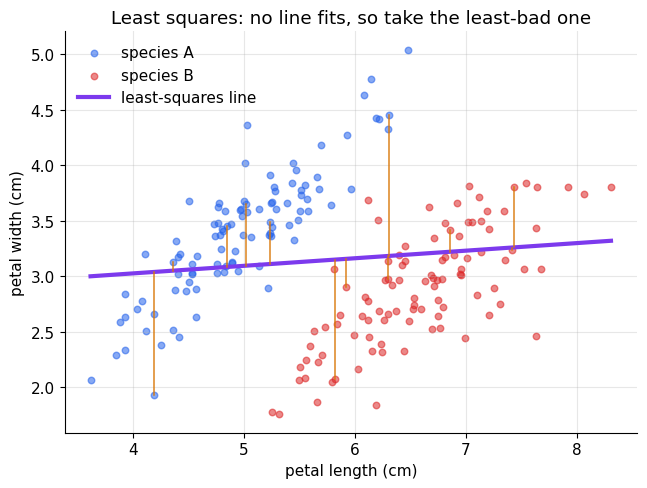

In [64]:
# ============================================================
#  Least squares on the flowers: width ~ slope * length + intercept.
# ============================================================
length = X[:, 0]
width  = X[:, 1]

Adesign = np.column_stack([length, np.ones_like(length)])   # 200 x 2
bvec = width                                                # 200

print(f"Adesign.shape = {Adesign.shape}   ({Adesign.shape[0]} equations)")
print(f"unknowns      = {Adesign.shape[1]}   (slope, intercept)")
print(f"-> {Adesign.shape[0]} equations, {Adesign.shape[1]} unknowns: "
      f"overdetermined, no exact solution exists.")

coef, residuals, rank_A, svals = np.linalg.lstsq(Adesign, bvec, rcond=None)
slope, intercept = coef
print(f"\nnp.linalg.lstsq ->  slope = {slope:.4f},  intercept = {intercept:.4f}")
print(f"rank of the design matrix: {rank_A} (full rank, so the fit is unique)")

resid = Adesign @ coef - bvec
print(f"\nsum of squared residuals: {np.sum(resid**2):.4f}")
print(f"largest single miss:      {np.abs(resid).max():.4f} cm")
print(f"is the residual zero?     {np.allclose(resid, 0)}   <- no exact solution, as promised")

# Is it really the MINIMUM? Perturb the answer and watch the error rise.
print("\n--- is this really the best line? nudge it and see ---")
base = np.sum(resid**2)
for ds in (-0.05, -0.01, 0.0, 0.01, 0.05):
    trial = coef + np.array([ds, 0.0])
    e = np.sum((Adesign @ trial - bvec) ** 2)
    mark = "  <- lstsq's answer" if ds == 0.0 else ""
    print(f"   slope {slope + ds:+.4f}   sum of squares = {e:.5f}"
          f"   ({e - base:+.5f} vs best){mark}")

fig, ax = plt.subplots(figsize=(6.6, 5.4))
ax.scatter(*X[species == 0].T, s=22, c=C_F,     alpha=0.55, label="species A")
ax.scatter(*X[species == 1].T, s=22, c=C_SLOPE, alpha=0.55, label="species B")
grid = np.linspace(length.min(), length.max(), 50)
ax.plot(grid, slope * grid + intercept, color=C_EXACT, lw=3.0,
        label="least-squares line")

# draw a handful of residuals as vertical sticks
for i in range(0, len(length), 17):
    ax.plot([length[i], length[i]], [width[i], slope * length[i] + intercept],
            color=C_APPROX, lw=1.1, alpha=0.9)

ax.set_xlabel(FEATURES[0]); ax.set_ylabel(FEATURES[1])
ax.set_title("Least squares: no line fits, so take the least-bad one")
ax.set_aspect("equal"); ax.legend(frameon=False, loc="upper left")
fig.tight_layout(); plt.show()


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

The flower cloud with the least-squares line through it, and a sample of the residuals drawn as short orange sticks — each one is a single flower's vertical miss, the gap between what the line predicts and what was measured. Least squares chose the line making the total of those sticks-squared as small as it can be, which the nudge table above demonstrates directly: move the slope either way and the printed sum of squares goes up.

**This is linear regression.** Not an analogy for it — the same computation, the same `lstsq` call underneath. The moment your model has more data points than parameters, exact solving is off the table and least squares is what "fitting" means.

**The common misread:** thinking the residual sticks are the *shortest* distance from each point to the line. They are not — they are strictly vertical, because we chose to minimise error in the predicted quantity (width), treating length as given. Minimising the perpendicular distance instead is a genuinely different fit with a different answer; it is called total least squares, and it turns out to be Part 9's PCA line rather than this one.

</div>

### What Part 7 leaves you with

- $\mathbf{A}\mathbf{x} = \mathbf{b}$ asks **which input produced this output**.
- The **row picture** — lines crossing — is friendly and does not scale. The
  **column picture** — how much of each column reaches $\mathbf{b}$ — scales
  forever and is the one to keep.
- **Elimination** solves it; you ran every step by hand and matched the library.
- $\mathbf{A}^{-1}$ is the **undo button**, and the determinant sits in its
  denominator. Think with it; do not compute with it — use `solve`.
- $\det = 0$ means the transformation **collapsed** the space. Information was
  destroyed, so there is either no answer or infinitely many. **Rank** counts
  how many directions survived.
- **Near-singular is worse than singular**, because nothing raises. The
  **condition number** is the amplification factor from wobble-in-the-data to
  wobble-in-the-answer, and it is the same quantity as a badly-shaped loss
  surface.
- With more equations than unknowns, exact solving is impossible and **least
  squares** picks the least-bad answer. That is regression.

---

### Where Part 8 goes next

Every failure in this part came from the same place: **the transformation did
something violent to certain directions.** The singular matrix flattened one
direction to nothing. The near-singular matrix nearly did. Rank counts how many
escaped.

That is a strong hint that a matrix does not treat all directions alike — that
some directions are *special* to it. Part 6 showed matrices rotating and
shearing everything in sight, and it is natural to assume nothing is left
standing.

Part 8 asks whether that is true.

> Given a matrix, is there a direction it leaves pointing **the same way** —
> merely stretched or squashed, never turned?

Those directions, when they exist, are called **eigenvectors**, and they are the
matrix's own private coordinate system. They explain why the determinant is what
it is, they are what PCA finds, and they are the single most-mishandled topic in
introductory linear algebra — usually because they are taught as a recipe to
execute rather than a question to ask. We will ask the question first, and look
at a picture, before writing down a single symbol.

---


---

# 8️⃣ Eigenvectors, and the directions that survive

Part 6 was, frankly, a bit chaotic. A matrix arrived, and everything moved.
Arrows rotated, the grid sheared, squares became parallelograms. Nothing seemed
to stay where it was put.

Part 7 then found that this violence is uneven: a singular matrix annihilates
one direction completely while leaving another untouched, and an
ill-conditioned one nearly does. So the transformation is clearly **not doing
the same thing to every direction**.

That suggests a question — and it is a question, not a definition, so let us ask
it before we write down any symbols:

> Given a matrix, are there directions it leaves **pointing the same way**?
> Not fixed in place — a vector may get longer or shorter — but never *turned*.

There is no guarantee such directions exist. Perhaps everything turns. The
honest thing to do is go and look.


## Looking, before defining anything

Take one matrix. Take a great many unit vectors, pointing all the way around
the circle. Apply the matrix to each and draw the input beside its output.

Then just watch which ones turn.


A8 =
 [[4. 1.]
 [2. 3.]]


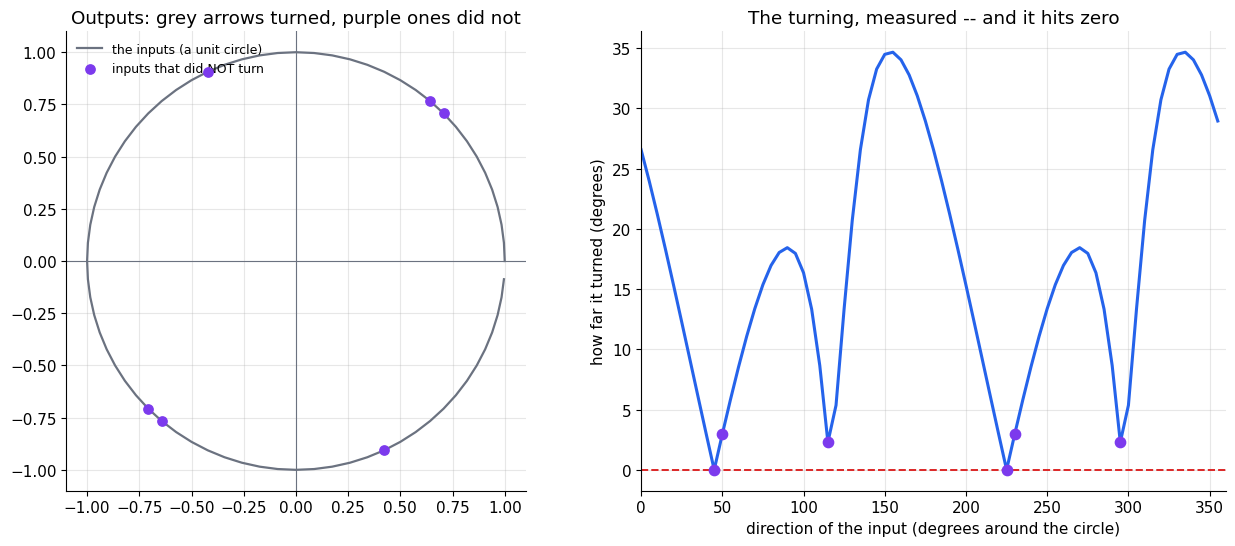


of 72 directions tried, 6 turned by less than 3 degrees.
they point along: [ 45.  50. 115. 225. 230. 295.] degrees
smallest turn found: 0.0000 deg,  largest: 34.65 deg

So the answer to the question is: YES, such directions exist -- and for
this matrix there appear to be exactly two of them (each counted twice,
since a direction and its opposite lie on the same line).


In [65]:
# ============================================================
#  One matrix. Many directions. Which ones does it NOT turn?
# ============================================================
A8 = np.array([[4.0, 1.0],
               [2.0, 3.0]])
print("A8 =\n", A8)

angles = np.linspace(0, 2 * np.pi, 72, endpoint=False)
ins = np.stack([np.cos(angles), np.sin(angles)])       # 2 x 72 unit vectors
outs = A8 @ ins                                        # where each one lands

# how far did each one TURN? angle between input and output, in degrees.
unit_out = outs / np.linalg.norm(outs, axis=0)
cosang = np.clip(np.sum(ins * unit_out, axis=0), -1.0, 1.0)
turn = np.degrees(np.arccos(np.abs(cosang)))   # abs: same LINE counts as unturned

survivors = turn < 3.0                          # near-zero turn

fig, axes = plt.subplots(1, 2, figsize=(13.0, 5.6))

ax = axes[0]
for i in range(ins.shape[1]):
    col = C_EXACT if survivors[i] else C_SOFT
    ax.annotate("", xy=outs[:, i], xytext=(0, 0),
                arrowprops=dict(arrowstyle="-|>", lw=2.4 if survivors[i] else 1.0,
                                color=col, mutation_scale=13,
                                alpha=1.0 if survivors[i] else 0.9))
ax.plot(*ins, color=C_GREY, lw=1.6, label="the inputs (a unit circle)")
ax.scatter(*ins[:, survivors], s=45, color=C_EXACT, zorder=6,
           label="inputs that did NOT turn")
ax.axhline(0, color=C_GREY, lw=0.8); ax.axvline(0, color=C_GREY, lw=0.8)
ax.set_title("Outputs: grey arrows turned, purple ones did not")
ax.set_aspect("equal"); ax.legend(frameon=False, fontsize=9, loc="upper left")

ax = axes[1]
deg = np.degrees(angles)
ax.plot(deg, turn, color=C_F, lw=2.2)
ax.scatter(deg[survivors], turn[survivors], s=55, color=C_EXACT, zorder=5)
ax.axhline(0, color=C_SLOPE, lw=1.4, ls="--")
ax.set_xlabel("direction of the input (degrees around the circle)")
ax.set_ylabel("how far it turned (degrees)")
ax.set_title("The turning, measured -- and it hits zero")
ax.set_xlim(0, 360)

fig.tight_layout(); plt.show()

print(f"\nof {ins.shape[1]} directions tried, {survivors.sum()} turned by less "
      f"than 3 degrees.")
print(f"they point along: {np.round(deg[survivors], 1)} degrees")
print(f"smallest turn found: {turn.min():.4f} deg,  largest: {turn.max():.2f} deg")
print("\nSo the answer to the question is: YES, such directions exist -- and for")
print("this matrix there appear to be exactly two of them (each counted twice,")
print("since a direction and its opposite lie on the same line).")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Left: every arrow is where the matrix sent one point of the unit circle. Almost all of them swing away from the direction they started in — that is the chaos of Part 6. But a few, drawn in purple, come out pointing along exactly the line they went in on. They got longer, but they did not turn.

Right: the same fact as a measurement rather than a picture. For each starting direction, how many degrees did it turn? The curve wanders up and down, and it **touches zero** at a small number of places — marked in purple, and the same directions as the purple arrows on the left.

Nothing has been defined yet. We asked a question about a picture and the picture answered it: **special directions exist.** Everything in the rest of this part is bookkeeping for finding them exactly.

**The common misread:** expecting the special directions to be at right angles to each other. For this matrix they are not, and the printed degrees show it. Perpendicularity is a bonus that arrives later, and only for a particular family of matrices.

</div>

## Now the definition

We have seen the thing. Naming it is easy.

A vector $\mathbf{v}$ is an **eigenvector** of the matrix $\mathbf{A}$ if
applying $\mathbf{A}$ to it produces the same vector back, merely scaled:

$$\boxed{\;\mathbf{A}\mathbf{v} = \lambda \mathbf{v}\;}$$

Every symbol, in words:

| Symbol | Said aloud | What it is |
|---|---|---|
| $\mathbf{A}$ | "A" | the matrix — a transformation we are given |
| $\mathbf{v}$ | "v" | the **eigenvector** — a direction the matrix does not turn |
| $\lambda$ | "lambda" | the **eigenvalue** — the number $\mathbf{v}$ got multiplied by |

The prefix *eigen-* is German for "own" or "characteristic". These are the
matrix's **own** directions: the ones belonging to it, not to the coordinate
system you happened to write it in.

One condition is imposed to keep the definition honest: $\mathbf{v} \neq
\mathbf{0}$. The zero vector satisfies $\mathbf{A}\mathbf{0} = \lambda
\mathbf{0}$ for absolutely any $\lambda$, tells you nothing, and is excluded by
decree. The eigenvalue $\lambda$ *may* be zero, and when it is, that direction
is exactly the one a singular matrix from Part 7 annihilated.


<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🗣️ In plain words

$\mathbf{A}\mathbf{v} = \lambda\mathbf{v}$ says: **for this particular vector, the whole matrix behaves like a single number.**

That is the entire idea, and it is worth a moment. A matrix is a complicated object — four numbers here, a million in a real network — and in general there is no way to summarise what it does. But *along an eigenvector* all that machinery collapses to one multiplication. The direction goes in, the same direction comes out, times $\lambda$.

Find enough of those directions and you have taken the matrix apart. Instead of a transformation that mixes everything together, you have a handful of independent directions, each with its own stretch factor.

**Eigenvector = the direction. Eigenvalue = the amount.** They always come in pairs; quoting one without the other is meaningless.

</div>

## Finding them by hand

We want $\mathbf{v} \neq \mathbf{0}$ with $\mathbf{A}\mathbf{v} = \lambda
\mathbf{v}$. Two unknowns at once — the direction *and* the number — which looks
awkward. The trick is to get everything on one side:

$$\mathbf{A}\mathbf{v} - \lambda\mathbf{v} = \mathbf{0}
\qquad\Longrightarrow\qquad
(\mathbf{A} - \lambda\mathbf{I})\,\mathbf{v} = \mathbf{0}$$

(the identity $\mathbf{I}$ has to be inserted because you cannot subtract a
plain number from a matrix — $\lambda\mathbf{I}$ is that number *as* a matrix).

Now read that with Part 7 in hand. It says the matrix $(\mathbf{A} -
\lambda\mathbf{I})$ sends a **non-zero** vector to zero. A matrix that flattens
something to nothing is exactly the singular case, and singular means:

$$\det(\mathbf{A} - \lambda\mathbf{I}) = 0$$

That is the **characteristic equation**, and it is the whole method. It has no
$\mathbf{v}$ in it — only $\lambda$. For a $2\times 2$ matrix
$\begin{bmatrix} a & b \\ c & d\end{bmatrix}$ it expands to

$$\det\begin{bmatrix} a - \lambda & b \\ c & d - \lambda \end{bmatrix}
= (a-\lambda)(d-\lambda) - bc
= \lambda^2 - (a + d)\lambda + (ad - bc)$$

which is a plain quadratic whose coefficients are two familiar quantities:

$$\lambda^2 - \operatorname{trace}(\mathbf{A})\,\lambda + \det(\mathbf{A}) = 0$$

(the **trace** is the sum of the diagonal entries). Solve it for $\lambda$ with
the quadratic formula. Then, for each $\lambda$ found, go back to
$(\mathbf{A} - \lambda\mathbf{I})\mathbf{v} = \mathbf{0}$ and read off which
$\mathbf{v}$ satisfies it.

**Doing it on our matrix.** With $a=4,\, b=1,\, c=2,\, d=3$:

$$\lambda^2 - 7\lambda + 10 = 0 \quad\Longrightarrow\quad
(\lambda - 5)(\lambda - 2) = 0 \quad\Longrightarrow\quad \lambda = 5 \text{ or } 2$$

**For $\lambda = 5$:** $\mathbf{A} - 5\mathbf{I} = \begin{bmatrix} -1 & 1 \\ 2 & -2 \end{bmatrix}$.
The first row says $-v_1 + v_2 = 0$, so $v_2 = v_1$, and any multiple of
$\begin{bmatrix}1 \\ 1\end{bmatrix}$ works.

**For $\lambda = 2$:** $\mathbf{A} - 2\mathbf{I} = \begin{bmatrix} 2 & 1 \\ 2 & 1 \end{bmatrix}$.
The first row says $2v_1 + v_2 = 0$, so $v_2 = -2v_1$, and any multiple of
$\begin{bmatrix}1 \\ -2\end{bmatrix}$ works.

Notice the second row of each was ignored — and *had* to be redundant, because
we chose $\lambda$ precisely to make the matrix singular. If the second row had
given new information, we would have made an arithmetic error.


In [66]:
# ============================================================
#  The hand method, executed, then checked against the library.
# ============================================================
tr = np.trace(A8)
dt = np.linalg.det(A8)
print(f"trace(A8) = {tr:.0f},  det(A8) = {dt:.0f}")
print(f"characteristic equation:  lambda^2 - {tr:.0f}*lambda + {dt:.0f} = 0")

disc = tr ** 2 - 4 * dt
print(f"discriminant = trace^2 - 4*det = {tr:.0f}^2 - 4*{dt:.0f} = {disc:.0f}"
      f"   ({'positive -> two real roots' if disc > 0 else 'negative -> no real roots'})")

lam_hand = np.array([(tr + np.sqrt(disc)) / 2, (tr - np.sqrt(disc)) / 2])
print(f"quadratic formula ->  lambda = {lam_hand[0]:.0f} and {lam_hand[1]:.0f}")

# For each lambda, read a null vector off the FIRST ROW of (A - lambda I):
# if that row is [p, q], then [-q, p] is killed by it, since p*(-q) + q*p = 0.
vecs_hand = []
for lam in lam_hand:
    M = A8 - lam * np.eye(2)
    p, q = M[0]
    v = np.array([-q, p])
    vecs_hand.append(v)
    print(f"\nlambda = {lam:.0f}:")
    print(f"   A8 - {lam:.0f}I =\n{M}")
    print(f"   first row is [{p:.0f}, {q:.0f}]  ->  v = [-q, p] = {v}")
    print(f"   is the SECOND row redundant, as promised? "
          f"row2 . v = {M[1] @ v:.1e}   (zero, so yes)")
    print(f"   A8 @ v  = {A8 @ v}")
    print(f"   lam * v = {lam * v}")
    print(f"   equal?    {np.allclose(A8 @ v, lam * v)}")

vecs_hand = np.array(vecs_hand).T          # columns are the eigenvectors

print("\n" + "=" * 62)
lam_np, vec_np = np.linalg.eig(A8)
print(f"np.linalg.eig eigenvalues : {lam_np.round(6)}")
print(f"by hand                   : {lam_hand.round(6)}")
print(f"agree? {np.allclose(np.sort(lam_hand), np.sort(lam_np))}   "
      f"max difference {np.abs(np.sort(lam_hand) - np.sort(lam_np)).max():.2e}")

print("\neigenvectors, both normalised to unit length:")
vh = vecs_hand / np.linalg.norm(vecs_hand, axis=0)
for i in range(2):
    j = int(np.argmin(np.abs(lam_np - lam_hand[i])))     # match by eigenvalue
    same_line = abs(abs(vh[:, i] @ vec_np[:, j]) - 1.0) < 1e-10
    print(f"  lambda = {lam_hand[i]:.0f}:  hand {vh[:, i].round(6)}   "
          f"eig {vec_np[:, j].round(6)}   same line? {same_line}   "
          f"ratio {(vec_np[0, j] / vh[0, i]):+.6f}")


trace(A8) = 7,  det(A8) = 10
characteristic equation:  lambda^2 - 7*lambda + 10 = 0
discriminant = trace^2 - 4*det = 7^2 - 4*10 = 9   (positive -> two real roots)
quadratic formula ->  lambda = 5 and 2

lambda = 5:
   A8 - 5I =
[[-1.  1.]
 [ 2. -2.]]
   first row is [-1, 1]  ->  v = [-q, p] = [-1. -1.]
   is the SECOND row redundant, as promised? row2 . v = -2.7e-15   (zero, so yes)
   A8 @ v  = [-5. -5.]
   lam * v = [-5. -5.]
   equal?    True

lambda = 2:
   A8 - 2I =
[[2. 1.]
 [2. 1.]]
   first row is [2, 1]  ->  v = [-q, p] = [-1.  2.]
   is the SECOND row redundant, as promised? row2 . v = -2.7e-15   (zero, so yes)
   A8 @ v  = [-2.  4.]
   lam * v = [-2.  4.]
   equal?    True

np.linalg.eig eigenvalues : [5. 2.]
by hand                   : [5. 2.]
agree? True   max difference 8.88e-16

eigenvectors, both normalised to unit length:
  lambda = 5:  hand [-0.707107 -0.707107]   eig [0.707107 0.707107]   same line? True   ratio -1.000000
  lambda = 2:  hand [-0.447214  0.894427]   e

<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Checked, not asserted

Every step of the hand derivation is reproduced by the cell, and each claim in it is tested rather than asserted:

- The trace and determinant are printed, and the characteristic equation is built from them.
- The quadratic formula produces the two eigenvalues, and `np.linalg.eig` produces the same two, agreeing to floating-point precision.
- The claim that *the second row of* $(\mathbf{A} - \lambda\mathbf{I})$ *must be redundant* is checked directly — `row2 . v` prints as zero. If we had solved the quadratic wrongly, that number would not be zero, so it is a genuine test of the whole chain, not a formality.
- Most importantly, the defining property itself is verified: `A8 @ v` and `lam * v` are printed side by side and compared with `np.allclose`. That is $\mathbf{A}\mathbf{v} = \lambda\mathbf{v}$, checked, on the actual numbers.

The hand eigenvectors and the library's lie on the same line — but look at the printed **ratio** between them. It is not 1. The next cell explains why that is fine, and why it catches people out.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Where this trips people up

**An eigenvector is a direction, not a vector. It is only defined up to scale — and therefore up to sign.**

If $\mathbf{A}\mathbf{v} = \lambda\mathbf{v}$, then multiplying both sides by any non-zero number $s$ gives $\mathbf{A}(s\mathbf{v}) = \lambda(s\mathbf{v})$. So $2\mathbf{v}$, $\tfrac{1}{10}\mathbf{v}$ and $-\mathbf{v}$ are all eigenvectors too, with the *same* eigenvalue. There is no such thing as "the" eigenvector for a given $\lambda$ — there is a whole line of them.

Libraries have to return *something*, so they pick a convention: `np.linalg.eig` returns unit-length vectors, and the sign is whatever the underlying LAPACK routine happened to produce. **That sign carries no meaning.** Consequences you will actually meet:

- Two runs on different machines, library versions, or mathematically-equivalent inputs can hand you $\mathbf{v}$ and $-\mathbf{v}$. Neither is wrong.
- A PCA plot can come out mirrored between two runs. The clusters are identical; the axis flipped.
- Never unit-test an eigenvector with `assert_allclose(v, expected)`. Test the property — that $\mathbf{A}\mathbf{v} = \lambda\mathbf{v}$ — or compare `abs(v @ expected)` against 1, which is sign-blind.

The eigen*value* has no such freedom. It is a single number, and it is genuinely determined.

</div>

In [67]:
# ============================================================
#  "Only up to scale and sign" -- demonstrated, not asserted.
# ============================================================
v = vecs_hand[:, 0]
lam = lam_hand[0]
print(f"take v = {v} with lambda = {lam:.0f}\n")
for s in (1.0, 3.0, 0.25, -1.0, -7.5):
    w = s * v
    print(f"  s = {s:>5}:  w = {np.round(w, 3)}   A8 @ w = {np.round(A8 @ w, 3)}"
          f"   lam * w = {np.round(lam * w, 3)}   equal? {np.allclose(A8 @ w, lam * w)}")

print("\nEvery scaled copy is an eigenvector with the SAME eigenvalue.")
print("So a library's particular choice of length and sign is a convention,")
print("nothing more:")
print(f"   our hand vector, normalised : {(v / np.linalg.norm(v)).round(6)}")
print(f"   what np.linalg.eig returned : {vec_np[:, int(np.argmin(np.abs(lam_np - lam)))].round(6)}")
print("\nThe safe test is the property, never the numbers:")
print(f"   np.allclose(A8 @ v, lam * v)  ->  {np.allclose(A8 @ v, lam * v)}")


take v = [-1. -1.] with lambda = 5

  s =   1.0:  w = [-1. -1.]   A8 @ w = [-5. -5.]   lam * w = [-5. -5.]   equal? True
  s =   3.0:  w = [-3. -3.]   A8 @ w = [-15. -15.]   lam * w = [-15. -15.]   equal? True
  s =  0.25:  w = [-0.25 -0.25]   A8 @ w = [-1.25 -1.25]   lam * w = [-1.25 -1.25]   equal? True
  s =  -1.0:  w = [1. 1.]   A8 @ w = [5. 5.]   lam * w = [5. 5.]   equal? True
  s =  -7.5:  w = [7.5 7.5]   A8 @ w = [37.5 37.5]   lam * w = [37.5 37.5]   equal? True

Every scaled copy is an eigenvector with the SAME eigenvalue.
So a library's particular choice of length and sign is a convention,
nothing more:
   our hand vector, normalised : [-0.707107 -0.707107]
   what np.linalg.eig returned : [0.707107 0.707107]

The safe test is the property, never the numbers:
   np.allclose(A8 @ v, lam * v)  ->  True


## What the eigenvalue tells you

The eigenvector says *which* direction survives. The eigenvalue says **what
happens to it**, and the reading is completely literal:

| $\lambda$ | Along that direction, the matrix... |
|---|---|
| $\lambda > 1$ | **stretches** — the output is longer, same way |
| $\lambda = 1$ | leaves it **exactly alone** |
| $0 < \lambda < 1$ | **shrinks** — shorter, same way |
| $\lambda = 0$ | **annihilates** it — the direction collapses to nothing |
| $\lambda < 0$ | **flips** it — the output points backwards, and is $\lvert\lambda\rvert$ times as long |

Two of those rows connect straight back to Part 7. $\lambda = 0$ *is* the
singular case: a direction sent to the zero vector is exactly the information
that got destroyed. And the determinant turns out to be the **product of the
eigenvalues** — so if any one of them is zero, so is the determinant, and the
area-scaling of Part 6 collapses. The two stories are one story.

The picture below builds three matrices that all have the same pair of
eigen*vectors* — the two diagonals — and differ only in their eigen*values*.


lambda =   1.8:  v = [0.7071 0.7071]  ->  M v = [1.2728 1.2728]
              lambda * v = [1.2728 1.2728]   equal? True
              eig(M) finds [1.  1.8], det(M) = +1.8000, product of eigenvalues = +1.8000
lambda =  0.45:  v = [0.7071 0.7071]  ->  M v = [0.3182 0.3182]
              lambda * v = [0.3182 0.3182]   equal? True
              eig(M) finds [0.45 1.  ], det(M) = +0.4500, product of eigenvalues = +0.4500
lambda =  -1.3:  v = [0.7071 0.7071]  ->  M v = [-0.9192 -0.9192]
              lambda * v = [-0.9192 -0.9192]   equal? True
              eig(M) finds [-1.3  1. ], det(M) = -1.3000, product of eigenvalues = -1.3000


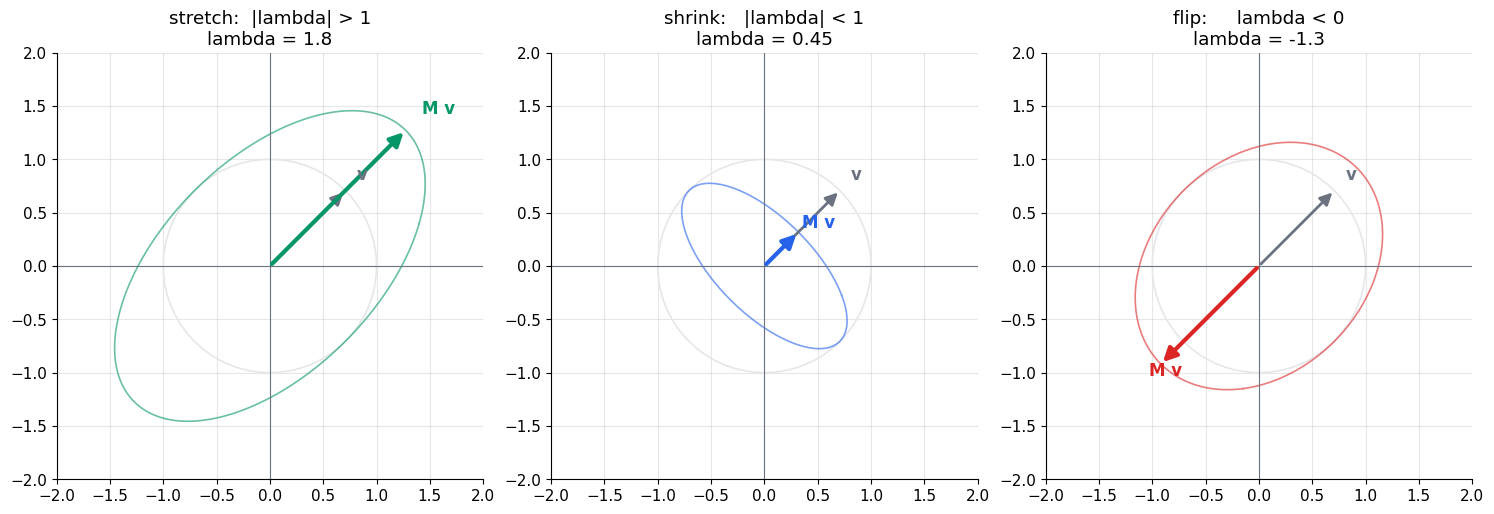


In every panel the output lies on the SAME LINE as the input.
Only the length changed -- and, in the third, the direction along it.


In [68]:
# ============================================================
#  Same eigenvectors, three different eigenvalues.
# ============================================================
# Build a matrix with chosen eigenvectors (the two diagonals) and chosen
# eigenvalues, by scaling along those directions:  M = Q diag(l1, l2) Q^T
Q = np.array([[1.0, 1.0],
              [1.0, -1.0]]) / np.sqrt(2.0)          # unit, perpendicular

def make(l1, l2):
    return Q @ np.diag([l1, l2]) @ Q.T

cases = [(1.8, "stretch:  |lambda| > 1", C_AREA),
         (0.45, "shrink:   |lambda| < 1", C_F),
         (-1.3, "flip:     lambda < 0", C_SLOPE)]

fig, axes = plt.subplots(1, 3, figsize=(15, 5.0))
v1 = Q[:, 0]                                        # the eigenvector we watch

for ax, (l1, title, col) in zip(axes, cases):
    M = make(l1, 1.0)                               # other eigenvalue held at 1
    out = M @ v1
    lam_check = np.linalg.eig(M)[0]

    th = np.linspace(0, 2 * np.pi, 200)
    circ = np.stack([np.cos(th), np.sin(th)])
    ax.plot(*circ, color=C_SOFT, lw=1.2)
    ax.plot(*(M @ circ), color=col, lw=1.2, alpha=0.6)

    ax.annotate("", xy=v1, xytext=(0, 0),
                arrowprops=dict(arrowstyle="-|>", lw=2.0, color=C_GREY,
                                mutation_scale=18))
    ax.annotate("", xy=out, xytext=(0, 0),
                arrowprops=dict(arrowstyle="-|>", lw=3.0, color=col,
                                mutation_scale=20))
    ax.text(*(v1 * 1.15), "v", color=C_GREY, fontsize=12, fontweight="bold")
    ax.text(*(out * 1.12), "M v", color=col, fontsize=12, fontweight="bold")

    ax.axhline(0, color=C_GREY, lw=0.8); ax.axvline(0, color=C_GREY, lw=0.8)
    ax.set_title(f"{title}\nlambda = {l1}")
    ax.set_aspect("equal"); ax.set_xlim(-2, 2); ax.set_ylim(-2, 2)

    print(f"lambda = {l1:>5}:  v = {v1.round(4)}  ->  M v = {out.round(4)}")
    print(f"              lambda * v = {(l1 * v1).round(4)}   "
          f"equal? {np.allclose(out, l1 * v1)}")
    print(f"              eig(M) finds {np.sort(lam_check).round(4)}, "
          f"det(M) = {np.linalg.det(M):+.4f}, "
          f"product of eigenvalues = {np.prod(lam_check):+.4f}")

fig.tight_layout(); plt.show()

print("\nIn every panel the output lies on the SAME LINE as the input.")
print("Only the length changed -- and, in the third, the direction along it.")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Three matrices sharing one pair of eigenvectors and differing only in an eigenvalue. The faint grey ring is the unit circle; the coloured ellipse is where the matrix sends it. The grey arrow is the eigenvector we are watching, and the thick coloured arrow is its image.

Left, the image is longer and points the same way. Middle, shorter, same way. Right, it points the **opposite** way and is longer — that is a negative eigenvalue, and it is still an eigenvector, because backwards is the same *line*. "Does not turn" has always meant "stays on its line", which is exactly why the first figure of this part measured turning with an absolute value.

The printed output also confirms, in each panel, that `det(M)` equals the product of the two eigenvalues — the Part 6 area-scaling factor is nothing but the eigenvalues multiplied together.

**The common misread:** treating a negative eigenvalue as an error, a sign bug, or something to take the absolute value of. It is a real, meaningful answer: that direction gets reversed. Silently `abs()`-ing eigenvalues destroys genuine information about the transformation.

</div>

## When there are none — and this is where people get lost

Everything so far might suggest eigenvectors are always there for the finding.
They are not, and the counter-example is the most ordinary transformation
imaginable.

**Take a rotation.** Turn the whole plane by fifty degrees. Now ask our
question: is there a direction that comes out pointing the same way?

Obviously not. *Every* direction is turned by fifty degrees — that is what a
rotation is, and a direction that survived it would be a direction the rotation
failed to rotate. There is no such direction, so a real rotation matrix (by
anything other than a whole or half turn) has **no real eigenvectors at all**.

But the characteristic equation does not care about your geometric intuition.
It is a quadratic, and quadratics always have two roots — provided you allow
complex numbers. So `np.linalg.eig` returns something, and what it returns has
an `i` in it. This is the moment where a first course loses people, so let us be
completely explicit about what those complex numbers mean.


rotation by 50 degrees, R =
[[ 0.6428 -0.766 ]
 [ 0.766   0.6428]]
det(R) = 1.000000  (area preserved -- rotations do not squash)

smallest turn over 72 directions tried: 50.0000 deg
largest turn:  50.0000 deg
Not one direction stayed put. There is nothing for us to find.

--- the characteristic equation, all the same ---
trace = 1.2856,  det = 1.0000
discriminant = -2.3473  -> NEGATIVE, so the roots are not real

np.linalg.eig eigenvalues: [0.6428+0.766j 0.6428-0.766j]
their magnitudes |lambda|: [1. 1.]  <- exactly 1: a rotation changes no lengths
their angles, in degrees : [ 50. -50.]  <- the rotation angle, plus and minus

are the eigenvectors real? False   (imaginary parts up to 0.7071)


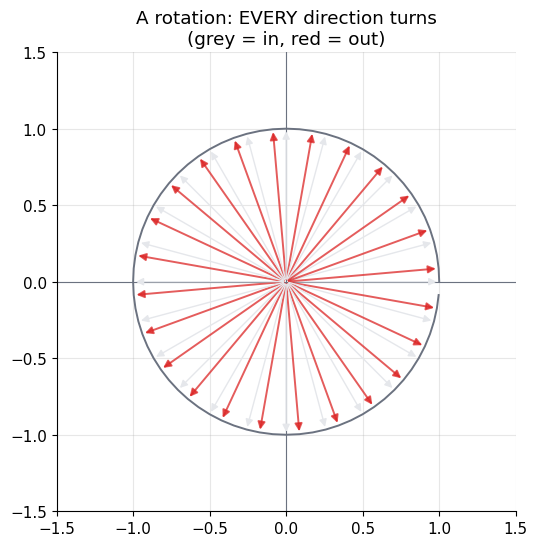

In [69]:
# ============================================================
#  A rotation: every direction turns, so no real eigenvector exists.
# ============================================================
theta = np.radians(50.0)
R = np.array([[np.cos(theta), -np.sin(theta)],
              [np.sin(theta),  np.cos(theta)]])
print(f"rotation by 50 degrees, R =\n{R.round(4)}")
print(f"det(R) = {np.linalg.det(R):.6f}  (area preserved -- rotations do not squash)")

# The same experiment as the very first figure of this part.
ins_r = np.stack([np.cos(angles), np.sin(angles)])
outs_r = R @ ins_r
cos_r = np.clip(np.sum(ins_r * (outs_r / np.linalg.norm(outs_r, axis=0)), axis=0),
                -1.0, 1.0)
turn_r = np.degrees(np.arccos(np.abs(cos_r)))
print(f"\nsmallest turn over {ins_r.shape[1]} directions tried: {turn_r.min():.4f} deg")
print(f"largest turn:  {turn_r.max():.4f} deg")
print("Not one direction stayed put. There is nothing for us to find.")

print("\n--- the characteristic equation, all the same ---")
tr_r, dt_r = np.trace(R), np.linalg.det(R)
disc_r = tr_r ** 2 - 4 * dt_r
print(f"trace = {tr_r:.4f},  det = {dt_r:.4f}")
print(f"discriminant = {disc_r:.4f}  -> NEGATIVE, so the roots are not real")

lam_r, vec_r = np.linalg.eig(R)
print(f"\nnp.linalg.eig eigenvalues: {np.round(lam_r, 4)}")
print(f"their magnitudes |lambda|: {np.round(np.abs(lam_r), 6)}  "
      f"<- exactly 1: a rotation changes no lengths")
print(f"their angles, in degrees : {np.round(np.degrees(np.angle(lam_r)), 4)}  "
      f"<- the rotation angle, plus and minus")
print(f"\nare the eigenvectors real? {np.allclose(vec_r.imag, 0)}   "
      f"(imaginary parts up to {np.abs(vec_r.imag).max():.4f})")

fig, ax = plt.subplots(figsize=(6.0, 5.6))
for i in range(0, ins_r.shape[1], 3):
    ax.annotate("", xy=ins_r[:, i], xytext=(0, 0),
                arrowprops=dict(arrowstyle="-|>", lw=1.0, color=C_SOFT,
                                mutation_scale=11))
    ax.annotate("", xy=outs_r[:, i], xytext=(0, 0),
                arrowprops=dict(arrowstyle="-|>", lw=1.4, color=C_SLOPE,
                                alpha=0.75, mutation_scale=11))
ax.plot(*ins_r, color=C_GREY, lw=1.4)
ax.axhline(0, color=C_GREY, lw=0.8); ax.axvline(0, color=C_GREY, lw=0.8)
ax.set_title("A rotation: EVERY direction turns\n(grey = in, red = out)")
ax.set_aspect("equal"); ax.set_xlim(-1.5, 1.5); ax.set_ylim(-1.5, 1.5)
fig.tight_layout(); plt.show()


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

The same experiment as the opening figure, run on a rotation. Grey arrows are inputs, red arrows are outputs, and **not one red arrow lies on top of its grey one.** The picture has no purple in it, because there is nothing to colour: the printed minimum turn over every direction tried is a full fifty degrees, not a small number.

Yet `np.linalg.eig` still returns two eigenvalues, and they are complex. They are not noise, and they are not a bug — read them in polar form and they describe the transformation exactly. Their **magnitude** prints as 1, which says lengths are unchanged. Their **angle** prints as plus and minus the rotation angle, which says how much everything turns. A complex eigenvalue is the algebra's way of reporting *rotation by this much, scaling by that much* when no real direction survived.

**The common misread:** seeing `0.643+0.766j` and concluding the computation failed, then reaching for `.real` to "clean it up". Discarding the imaginary part here throws away the rotation and keeps a meaningless leftover. The honest reading is: this matrix has no real eigenvectors, because geometrically it has no fixed directions, and the complex pair is telling you precisely that.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Where this trips people up

**Do not assume a matrix has real eigenvectors. Many do not.**

The characteristic equation is a polynomial, and polynomials with real coefficients can have complex roots. A rotation is the everyday example, but any matrix with enough rotational character behaves this way. Three practical consequences:

- **`np.linalg.eig` returns a complex dtype whenever it must.** Code that assumes real output — indexing, plotting, comparing — will either crash or raise `ComplexWarning` and silently drop information. Check `np.iscomplexobj(...)` rather than hoping.
- **Complex eigenvalues come in conjugate pairs** for a real matrix: if $p + qi$ is one, $p - qi$ is the other. Seeing exactly one complex eigenvalue in a real problem means something has gone wrong.
- **They carry real meaning, not error.** In a dynamical system — and a recurrent network is one — a complex eigenvalue means the state spirals rather than growing straight. Its magnitude decides whether the spiral grows or decays; its angle sets the frequency of the oscillation.

The next section introduces the family of matrices where none of this can happen, and it is not a coincidence that it is the family machine learning spends most of its time with.

</div>

## Symmetric matrices: the well-behaved case

A matrix is **symmetric** if it equals its own transpose, $\mathbf{S}^{T} =
\mathbf{S}$ — mirror it across the main diagonal and nothing moves, so
$S_{ij} = S_{ji}$ for every pair.

That single mild-looking condition buys an enormous amount. For a real symmetric
matrix, it is guaranteed that:

1. **Every eigenvalue is real.** No complex pairs, ever. The trouble in the last
   section simply cannot arise.
2. **Eigenvectors for different eigenvalues are perpendicular.** Not roughly —
   exactly, at right angles.
3. **There are always enough of them** to form a complete set of axes for the
   whole space.

Together those say something remarkable: a symmetric matrix is *nothing but* a
set of perpendicular directions, each with its own stretch factor. Choose those
directions as your axes and the matrix becomes diagonal. This is the **spectral
theorem**, and it is one of the genuinely load-bearing results in the subject.

Why it matters here: **covariance matrices are symmetric** — necessarily so,
since the covariance of feature $i$ with feature $j$ is the same number as the
covariance of $j$ with $i$. So every guarantee above applies to them, which is
why the next section works at all, and why Part 9 can build on it.


Sym =
 [[2. 1.]
 [1. 3.]]
is it symmetric?  Sym == Sym.T  ->  True

eigenvalues: [1.381966 3.618034]
complex?     False   <- guarantee 1: always real

eigenvector 1: [-0.850651  0.525731]   (lambda = 1.3820)
eigenvector 2: [-0.525731 -0.850651]   (lambda = 3.6180)

their dot product: 0.00e+00   <- zero, so PERPENDICULAR (guarantee 2)
angle between them: 90.000000 degrees

--- and for contrast, the NON-symmetric matrix from earlier ---
A8 symmetric? False
its eigenvectors' dot product: 0.3162  -> NOT zero
angle between them: 71.57 degrees
Real eigenvalues, but not perpendicular. Symmetry is what buys the right angle.


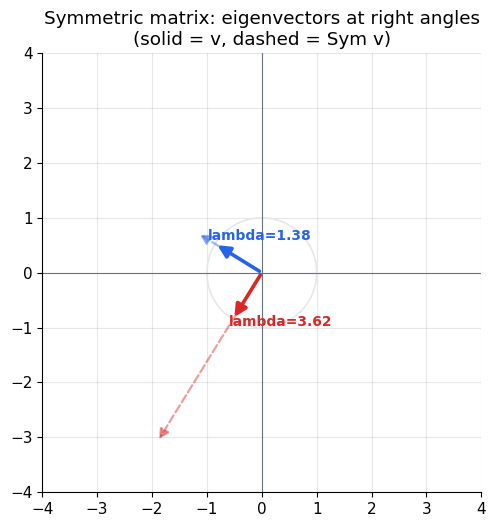

In [70]:
# ============================================================
#  Symmetric: real eigenvalues, perpendicular eigenvectors.
# ============================================================
Sym = np.array([[2.0, 1.0],
                [1.0, 3.0]])
print("Sym =\n", Sym)
print(f"is it symmetric?  Sym == Sym.T  ->  {np.array_equal(Sym, Sym.T)}")

lam_s, vec_s = np.linalg.eig(Sym)
print(f"\neigenvalues: {lam_s.round(6)}")
print(f"complex?     {np.iscomplexobj(lam_s)}   <- guarantee 1: always real")

v1s, v2s = vec_s[:, 0], vec_s[:, 1]
print(f"\neigenvector 1: {v1s.round(6)}   (lambda = {lam_s[0]:.4f})")
print(f"eigenvector 2: {v2s.round(6)}   (lambda = {lam_s[1]:.4f})")
dot = v1s @ v2s
print(f"\ntheir dot product: {dot:.2e}   <- zero, so PERPENDICULAR (guarantee 2)")
print(f"angle between them: {np.degrees(np.arccos(np.clip(dot, -1, 1))):.6f} degrees")

print("\n--- and for contrast, the NON-symmetric matrix from earlier ---")
d_ns = vec_np[:, 0] @ vec_np[:, 1]
print(f"A8 symmetric? {np.array_equal(A8, A8.T)}")
print(f"its eigenvectors' dot product: {d_ns:.4f}  -> NOT zero")
print(f"angle between them: {np.degrees(np.arccos(np.clip(abs(d_ns), -1, 1))):.2f} degrees")
print("Real eigenvalues, but not perpendicular. Symmetry is what buys the right angle.")

fig, ax = plt.subplots(figsize=(5.8, 5.4))
for v, lam, col in [(v1s, lam_s[0], C_F), (v2s, lam_s[1], C_SLOPE)]:
    ax.annotate("", xy=v, xytext=(0, 0),
                arrowprops=dict(arrowstyle="-|>", lw=2.6, color=col, mutation_scale=18))
    ax.annotate("", xy=Sym @ v, xytext=(0, 0),
                arrowprops=dict(arrowstyle="-|>", lw=1.6, color=col, alpha=0.45,
                                linestyle="--", mutation_scale=15))
    ax.text(*(v * 1.15), f"lambda={lam:.2f}", color=col, fontsize=10, fontweight="bold")
th = np.linspace(0, 2 * np.pi, 200)
ax.plot(np.cos(th), np.sin(th), color=C_SOFT, lw=1.2)
ax.axhline(0, color=C_GREY, lw=0.8); ax.axvline(0, color=C_GREY, lw=0.8)
ax.set_title("Symmetric matrix: eigenvectors at right angles\n(solid = v, dashed = Sym v)")
ax.set_aspect("equal"); ax.set_xlim(-4, 4); ax.set_ylim(-4, 4)
fig.tight_layout(); plt.show()


<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Checked, not asserted

Both guarantees are tested on real numbers rather than quoted.

`np.iscomplexobj(lam_s)` prints `False` — the eigenvalues of the symmetric matrix really are real. And the dot product of its two eigenvectors prints at the level of floating-point zero, with the angle between them coming out as ninety degrees to six decimal places. That is guarantee 2, measured.

The contrast is measured too: the non-symmetric `A8` from earlier in this part has perfectly real eigenvalues but its eigenvectors' dot product is visibly *not* zero, and the printed angle between them is not a right angle. Real eigenvalues and perpendicular eigenvectors are separate properties, and it is symmetry that buys the second one.

</div>

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

The symmetric matrix's two eigenvectors as solid arrows, meeting at a right angle, with their images under the matrix as dashed arrows of the same colour. Each dashed arrow lies exactly along its solid one — that is the eigenvector property — and is longer by the labelled factor.

Two perpendicular directions, two stretch factors: that is the entire content of this matrix. Everything it does to any other vector follows from splitting that vector into these two components and scaling each.

**The common misread:** assuming the *longer* dashed arrow marks the more important direction in some absolute sense. The lengths shown are the eigenvalues, and they are only comparable because both eigenvectors were drawn at unit length first. Compare stretch factors, never raw arrow lengths, unless you know the inputs were normalised.

</div>

## The covariance matrix of the flowers

Time to point this at real data.

Part 4 mean-centred the flower matrix — subtracted each column's average so the
cloud sits around the origin. From centred data $\mathbf{X}_c$ (200 rows, 2
columns) the **covariance matrix** is

$$\mathbf{C} \;=\; \frac{1}{n-1}\,\mathbf{X}_c^{T}\mathbf{X}_c$$

a $2 \times 2$ matrix whose entries say how the two measurements vary, and how
they vary *together*: the diagonal holds each measurement's own spread, and the
off-diagonal holds their joint tendency. It is symmetric by construction —
$\mathbf{C} = \mathbf{C}^{T}$ falls straight out of the formula — so everything
the previous section guaranteed applies.

Which means it has two real eigenvalues and two perpendicular eigenvectors.
Let us compute them and draw them on the scatter plot from Part 0.

**We are only going to look.** What those arrows are *for*, what to do with the
eigenvalues, and why any of it is useful is Part 9's job, and it will be worth
the wait.


X.mean(axis=0)  = [5.7813 3.1492]
Xc.mean(axis=0) = [0. 0.]   <- centred, to within rounding

C = Xc.T @ Xc / (n - 1) =
[[1.045128 0.071331]
 [0.071331 0.361713]]
same as np.cov(X, rowvar=False)? True
symmetric? C == C.T -> True   (off-diagonals differ by 0.00e+00)

eigenvalues : [1.052494 0.354347]
both real and non-negative? True
eigenvectors (columns):
[[-0.994711  0.102716]
 [-0.102716 -0.994711]]
perpendicular? dot = 0.00e+00
  check C @ v1 == lambda1 * v1:  True
  check C @ v2 == lambda2 * v2:  True


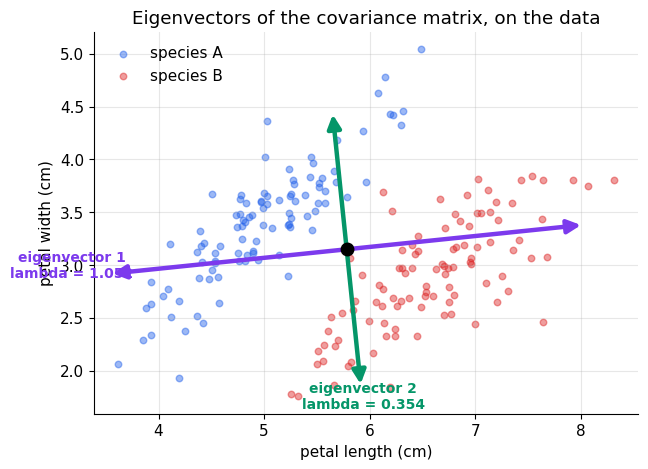


the first eigenvector points at -174.10 degrees from horizontal.
the two eigenvalues are 1.0525 and 0.3543, a ratio of 2.97 to 1.


In [71]:
# ============================================================
#  Covariance of the flowers, and its eigenvectors, drawn.
# ============================================================
Xc = X - X.mean(axis=0)              # the mean-centring from Part 4
print(f"X.mean(axis=0)  = {X.mean(axis=0).round(4)}")
print(f"Xc.mean(axis=0) = {Xc.mean(axis=0).round(12)}   <- centred, to within rounding")

nrows = Xc.shape[0]
C = (Xc.T @ Xc) / (nrows - 1)
print(f"\nC = Xc.T @ Xc / (n - 1) =\n{C.round(6)}")
print(f"same as np.cov(X, rowvar=False)? "
      f"{np.allclose(C, np.cov(X, rowvar=False))}")
print(f"symmetric? C == C.T -> {np.allclose(C, C.T)}   "
      f"(off-diagonals differ by {abs(C[0,1] - C[1,0]):.2e})")

lam_c, vec_c = np.linalg.eigh(C)      # eigh: for symmetric matrices
order = np.argsort(lam_c)[::-1]       # largest eigenvalue first
lam_c, vec_c = lam_c[order], vec_c[:, order]

print(f"\neigenvalues : {lam_c.round(6)}")
print(f"both real and non-negative? "
      f"{(not np.iscomplexobj(lam_c)) and bool((lam_c >= 0).all())}")
print(f"eigenvectors (columns):\n{vec_c.round(6)}")
print(f"perpendicular? dot = {vec_c[:, 0] @ vec_c[:, 1]:.2e}")
for i in range(2):
    print(f"  check C @ v{i+1} == lambda{i+1} * v{i+1}:  "
          f"{np.allclose(C @ vec_c[:, i], lam_c[i] * vec_c[:, i])}")

fig, ax = plt.subplots(figsize=(6.6, 5.8))
ax.scatter(*X[species == 0].T, s=22, c=C_F,     alpha=0.45, label="species A")
ax.scatter(*X[species == 1].T, s=22, c=C_SLOPE, alpha=0.45, label="species B")

centre = X.mean(axis=0)
for i, col in enumerate([C_EXACT, C_AREA]):
    v = vec_c[:, i] * np.sqrt(lam_c[i]) * 2.2       # scaled by spread, to be visible
    ax.annotate("", xy=centre + v, xytext=centre,
                arrowprops=dict(arrowstyle="-|>", lw=3.2, color=col, mutation_scale=20))
    ax.annotate("", xy=centre - v, xytext=centre,
                arrowprops=dict(arrowstyle="-|>", lw=3.2, color=col, mutation_scale=20))
    ax.text(*(centre + v * 1.16), f"eigenvector {i+1}\nlambda = {lam_c[i]:.3f}",
            color=col, fontsize=10, fontweight="bold", ha="center")

ax.plot(*centre, "o", ms=9, color="black", zorder=6)
ax.set_xlabel(FEATURES[0]); ax.set_ylabel(FEATURES[1])
ax.set_title("Eigenvectors of the covariance matrix, on the data")
ax.set_aspect("equal"); ax.legend(frameon=False, loc="upper left")
fig.tight_layout(); plt.show()

ang = np.degrees(np.arctan2(vec_c[1, 0], vec_c[0, 0]))
print(f"\nthe first eigenvector points at {ang:.2f} degrees from horizontal.")
print(f"the two eigenvalues are {lam_c[0]:.4f} and {lam_c[1]:.4f}, "
      f"a ratio of {lam_c[0] / lam_c[1]:.2f} to 1.")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

The flower scatter from Part 0, with the two eigenvectors of its covariance matrix drawn from the cloud's centre — each in both directions, since sign is arbitrary — and scaled by the square root of its eigenvalue so the arrow lengths reflect how much the data actually spreads that way.

The long arrow lies along the diagonal lean that Part 0 pointed out and asked you to remember. Nobody told the covariance matrix where the cloud was tilted; that tilt is simply what its eigenvectors came out as. The short arrow is perpendicular to it — guaranteed, because covariance matrices are symmetric — and the printed ratio of eigenvalues says how much more the data varies along the long one.

That is all we are going to say. The arrows are on the page; **what they are for is Part 9.**

**The common misread:** reading the long arrow as a line fitted to the points, the same object Part 7's least squares produced. It is not. Least squares minimised *vertical* distance because it was predicting width from length; this arrow comes from a symmetric eigen-problem that treats both measurements alike, and on tilted data the two lines genuinely differ. Also note the arrows describe the whole cloud, both species together — the covariance matrix was never told there were two.

</div>

<div style="background-color: #f8d7da; border-left: 5px solid #dc3545; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🤖 Why ML cares

The eigenvectors of a covariance matrix are **the directions your data varies along**, ordered by how much. That one sentence sits underneath a surprising amount of machine learning.

- **Dimensionality reduction.** If one eigenvalue is much larger than the others, almost all the variation lives along one direction and the rest is nearly flat. You can then describe each point by its position along the big directions and drop the others, losing little. Two hundred features become ten. This is PCA, and Part 9 builds it from exactly the arrows you just drew.

- **Whitening and normalisation.** Dividing each eigen-direction by the square root of its eigenvalue turns an elongated cloud into a round one. That is the multi-dimensional version of "standardise your features", and it is a conditioning fix in the Part 7 sense: a round cloud is a well-conditioned one.

- **The tiny eigenvalue is the warning.** A near-zero eigenvalue means the data is nearly flat in that direction — features that are nearly redundant, a covariance matrix that is nearly singular, and a regression whose coefficients will swing wildly. The eigenvalues *are* the condition number: their largest-over-smallest ratio is exactly it.

- **Beyond covariance.** The curvature of a loss surface is a symmetric matrix too, and its eigenvalues are the stretch factors of the valley gradient descent is walking down. A large eigenvalue is a steep, narrow wall; a tiny one is a long flat floor. That ratio is why plain gradient descent struggles, and what Adam and its relatives try to compensate for.

</div>

### What Part 8 leaves you with

- We asked a question — **does a matrix leave any direction pointing the same
  way?** — and answered it with a picture before defining anything.
- Those directions are **eigenvectors**; the amount each is scaled by is its
  **eigenvalue**. Together: $\mathbf{A}\mathbf{v} = \lambda\mathbf{v}$, which
  says the whole matrix acts like a single number along that direction.
- You found them by hand — characteristic equation, quadratic formula,
  back-substitution — and matched the library exactly.
- An eigenvector is **only defined up to scale and sign**, so a library's
  particular output is a convention. Test the property, never the numbers.
- $\lambda$ reads literally: bigger than one stretches, less than one shrinks,
  negative flips, zero annihilates. The determinant is their **product**, which
  is why a zero eigenvalue and a singular matrix are the same event.
- **Not every matrix has real eigenvectors.** A rotation turns everything, so
  nothing survives, and the complex pair `eig` returns is reporting the
  rotation's angle and scale — not an error to be cleaned up.
- **Symmetric matrices always behave**: real eigenvalues, perpendicular
  eigenvectors, a complete set of axes. Covariance matrices are symmetric.
- The flowers' covariance eigenvectors line up with the cloud's tilt. Drawn, not
  yet used.

---

### Where Part 9 goes next

Part 9 is where all nine parts get spent at once.

Those two arrows on the flower scatter are about to become **PCA** — rotate the
data onto its own eigen-directions, keep the ones with large eigenvalues, throw
away the rest, and you have compressed your data while losing almost nothing.
Part 9 implements it from scratch using precisely the covariance matrix and
`eigh` call above, and then checks the result against `sklearn`.

And it will finally cash the promise made at the very top of the notebook. A
neural network layer is

$$\mathbf{y} = \mathbf{W}\mathbf{x} + \mathbf{b}$$

which you can now read as a sentence, with every word built by hand: take the
input vector (Part 1), apply the transformation (Parts 5 and 6), shift it
(Part 2). Whether that transformation can be undone is Part 7. What it does to
the shape of a data cloud is this part.

---


---

# 9️⃣ Linear algebra doing machine learning

<div style="background: linear-gradient(135deg, #3A1C71 0%, #D76D77 100%); padding: 28px; border-radius: 18px; color: white; margin: 12px 0;">


### Everything from here is a re-run of what you already built.

There is no new mathematics in this part. That is the point of it.

A neural network layer is a matrix multiplication and an addition. PCA is a covariance matrix, an eigen-decomposition, and a projection. You have built every one of those pieces, from scratch, and checked each against numbers.

So this part does two things and stops. First it reads `y = Wx + b` out loud, one symbol at a time, and implements a layer by hand on the flowers. Then it builds **PCA from nothing** — mean-centre, covariance, eigen-decompose, project, reconstruct — and finally interprets the two arrows Part 8 drew on the scatter and deliberately left unexplained.


</div>

**Where we are.** Part 8 ended with the covariance matrix's eigenvectors drawn
over the flower scatter and no interpretation offered. Those arrows are the
answer to a question we had not yet asked. We ask it in §9.2.

| Section | What it does |
|---|---|
| **9.1** | One neural network layer, `y = Wx + b`, read as a sentence and implemented by hand |
| **9.2** | PCA built from scratch in seven steps, then checked against a library |
| **9.3** | Where each idea shows up in ML, the promises of Part 0 ticked off, and exercises |


---

### 9.1 A neural network layer, read as a sentence

Here is the whole of a linear layer:

$$\mathbf{y} = \mathbf{W}\mathbf{x} + \mathbf{b}$$

Five symbols. Every one of them is something you have already built:

| Symbol | Said aloud | What it is | Built in |
|---|---|---|---|
| $\mathbf{x}$ | "x" | the input — a vector, one flower, one list of numbers | Part 1 |
| $\mathbf{W}$ | "W" | the weight matrix — a transformation that stretches and rotates | Parts 4, 6 |
| $\mathbf{W}\mathbf{x}$ | "W x" | the transformed input — each row of $\mathbf{W}$ dotted with $\mathbf{x}$ | Parts 3, 5 |
| $\mathbf{b}$ | "b" | the bias — a vector that shifts the result | Part 2 |
| $\mathbf{y}$ | "y" | the output — a vector again, possibly of a different length | Part 1 |

Read as a sentence: **take the input, move it with `W`, then shift it by `b`.**
Nothing is hidden. A "layer" is that, and a network is several of them stacked
with a nonlinearity wedged between — the reason for that wedge is at the end of
this section.

The one thing worth over-learning: **`W` has one row per output and one column
per input.** A layer that turns 2 numbers into 3 numbers has a `W` that is
3 × 2. Not 2 × 3. The shape tells you the job.


In [72]:
# ============================================================
#  ONE LAYER, BY HAND, ON ONE FLOWER
#  2 measurements in  ->  3 numbers out.  So W is 3 x 2.
# ============================================================
W1 = np.array([[ 0.60, -0.90],      # row 0: how output 0 reads the input
               [ 1.20,  0.40],      # row 1
               [-0.30,  0.80]])     # row 2
b1 = np.array([0.10, -0.20, 0.50])

x = X[0]                            # one flower -- the input vector

print("SHAPES, step by step")
print(f"  x   {str(x.shape):8s}  <- {x.shape[0]} numbers in  (one flower)")
print(f"  W1  {str(W1.shape):8s}  <- {W1.shape[0]} rows (outputs) x {W1.shape[1]} cols (inputs)")
print(f"  b1  {str(b1.shape):8s}  <- one number per output")

Wx = W1 @ x
y  = Wx + b1
print(f"  Wx  {str(Wx.shape):8s}  <- {W1.shape[0]}x{W1.shape[1]} times {x.shape[0]}x1 gives {W1.shape[0]}x1")
print(f"  y   {str(y.shape):8s}  <- same shape as b1, so the addition is legal")

print("\nTHE ARITHMETIC, spelled out (Part 3's dot product, three times)")
for i in range(W1.shape[0]):
    terms = " + ".join(f"({W1[i, j]:+.2f})({x[j]:.2f})" for j in range(W1.shape[1]))
    print(f"  y[{i}] = W1[{i}]  .  x  + b1[{i}] = {terms} + ({b1[i]:+.2f}) = {y[i]:+.4f}")

print(f"\ny = {y.round(4)}")
print(f"matches W1 @ x + b1 : {np.allclose(y, W1 @ x + b1)}")


SHAPES, step by step
  x   (2,)      <- 2 numbers in  (one flower)
  W1  (3, 2)    <- 3 rows (outputs) x 2 cols (inputs)
  b1  (3,)      <- one number per output
  Wx  (3,)      <- 3x2 times 2x1 gives 3x1
  y   (3,)      <- same shape as b1, so the addition is legal

THE ARITHMETIC, spelled out (Part 3's dot product, three times)
  y[0] = W1[0]  .  x  + b1[0] = (+0.60)(4.19) + (-0.90)(1.93) + (+0.10) = +0.8741
  y[1] = W1[1]  .  x  + b1[1] = (+1.20)(4.19) + (+0.40)(1.93) + (-0.20) = +5.5997
  y[2] = W1[2]  .  x  + b1[2] = (-0.30)(4.19) + (+0.80)(1.93) + (+0.50) = +0.7894

y = [0.8741 5.5997 0.7894]
matches W1 @ x + b1 : True


<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🗣️ In plain words

`y = Wx + b` says: **each output number is one row of `W` dotted with the input, plus one bias number.**

Row `i` of `W` is a recipe — it says how much output `i` cares about each input. A large positive entry means "this input pushes me up", a large negative entry means "this input pushes me down", a zero means "I ignore this input". The dot product of that recipe with the flower is the score, and `b[i]` shifts the score up or down regardless of the input.

Part 5's **column view** says the same thing from the other side: `Wx` is a weighted sum of the *columns* of `W`, with the numbers in `x` as the weights. Rows give you the outputs one at a time; columns tell you what the layer can reach at all. Both readings are correct and useful.

</div>

In [73]:
# ============================================================
#  WHY SHAPES ARE THE WHOLE BATTLE
#  Get it wrong on purpose, read the error, then fix it.
# ============================================================
print("ATTEMPT 1 -- X @ W1, which 'looks right' and is not")
print(f"  X  is {X.shape},  W1 is {W1.shape}")
try:
    _ = X @ W1
    print("  ...it worked?!")
except ValueError as e:
    print(f"  ValueError: {e}")
    print("  Reason: '@' needs the INNER dimensions to agree.")
    print(f"    ({X.shape[0]} x {X.shape[1]}) @ ({W1.shape[0]} x {W1.shape[1]})"
          f"  ->  inner pair is {X.shape[1]} and {W1.shape[0]}: not equal, so no.")

print("\nATTEMPT 2 -- transpose W1 so the inner dimensions meet")
H = X @ W1.T + b1
print(f"  X @ W1.T   ({X.shape[0]}x{X.shape[1]}) @ ({W1.T.shape[0]}x{W1.T.shape[1]})"
      f"  ->  inner pair is {X.shape[1]} and {W1.T.shape[0]}: equal. Result {H.shape}.")
print(f"  + b1 broadcasts across all {H.shape[0]} rows -> {H.shape}")

# --- a full two-layer network:  2 -> 3 -> 1 ---------------------------
W2 = np.array([[0.70, -1.10, 0.50]])     # 1 output, 3 inputs
b2 = np.array([0.25])

rows = [
    ("input",          "X",     X.shape,     "200 flowers, 2 measurements each"),
    ("layer 1 weight", "W1",    W1.shape,    "3 outputs <- 2 inputs"),
    ("layer 1 bias",   "b1",    b1.shape,    "one per layer-1 output"),
    ("hidden",         "H",     H.shape,     "200 flowers, 3 hidden numbers"),
    ("layer 2 weight", "W2",    W2.shape,    "1 output <- 3 inputs"),
    ("layer 2 bias",   "b2",    b2.shape,    "one per layer-2 output"),
    ("output",         "OUT",   (X.shape[0], W2.shape[0]), "200 flowers, 1 number each"),
]
print("\nSHAPE TABLE for the 2 -> 3 -> 1 network")
print(f"  {'what':16s} {'name':5s} {'shape':10s}  meaning")
print("  " + "-" * 66)
for what, name, shp, why in rows:
    print(f"  {what:16s} {name:5s} {str(shp):10s}  {why}")

OUT = H @ W2.T + b2
print(f"\nOUT.shape = {OUT.shape}  (predicted, and produced)")
print(f"The chain of inner dimensions that had to line up: "
      f"{X.shape[1]} = {W1.T.shape[0]}, then {H.shape[1]} = {W2.T.shape[0]}.")


ATTEMPT 1 -- X @ W1, which 'looks right' and is not
  X  is (200, 2),  W1 is (3, 2)
  ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 3 is different from 2)
  Reason: '@' needs the INNER dimensions to agree.
    (200 x 2) @ (3 x 2)  ->  inner pair is 2 and 3: not equal, so no.

ATTEMPT 2 -- transpose W1 so the inner dimensions meet
  X @ W1.T   (200x2) @ (2x3)  ->  inner pair is 2 and 2: equal. Result (200, 3).
  + b1 broadcasts across all 200 rows -> (200, 3)

SHAPE TABLE for the 2 -> 3 -> 1 network
  what             name  shape       meaning
  ------------------------------------------------------------------
  input            X     (200, 2)    200 flowers, 2 measurements each
  layer 1 weight   W1    (3, 2)      3 outputs <- 2 inputs
  layer 1 bias     b1    (3,)        one per layer-1 output
  hidden           H     (200, 3)    200 flowers, 3 hidden numbers
  layer 2 weight   W2    (1, 3)      1 output

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Where this trips people up

**Almost every bug in neural network code is a shape bug**, and it is worth learning to read them rather than guessing.

`A @ B` requires the **inner** dimensions to match: `(m × n) @ (n × p)` gives `(m × p)`. The `n` in the middle is consumed. If the error message says the dimensions are not aligned, write both shapes down side by side and look at the two numbers that touch.

Two traps specifically:

1. **The transpose is not decoration.** `W` is written (outputs × inputs) because the maths is `Wx` for a single vector. But a batch `X` is stored (samples × features), so batched code says `X @ W.T`. Frameworks hide this in different ways — PyTorch stores `nn.Linear.weight` as (out, in) and transposes internally — which is exactly why it confuses people.

2. **A silent success is worse than an error.** `(200 × 2) @ (2 × 200)` is legal and gives you a 200 × 200 matrix that means nothing. The shape rules only catch mismatches, not nonsense. Print shapes; do not assume.

</div>

identical results?          True
largest disagreement:       1.776e-15
loop  over 200 flowers:     2840.2 microseconds
one matrix multiplication:       38.0 microseconds
SPEEDUP:                         74.7 x


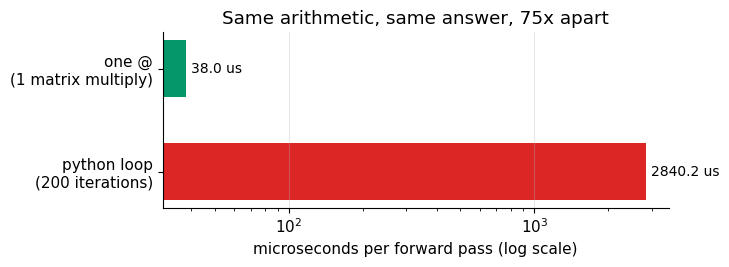

In [74]:
# ============================================================
#  BATCHING: one '@' instead of a loop over 200 flowers
# ============================================================
import time

def forward_loop(X, W, b):
    """One flower at a time -- literally the maths, one row per iteration."""
    out = np.empty((X.shape[0], W.shape[0]))
    for i in range(X.shape[0]):
        out[i] = W @ X[i] + b
    return out

def forward_batch(X, W, b):
    """All 200 flowers in one matrix multiplication."""
    return X @ W.T + b

Y_loop  = forward_loop(X, W1, b1)
Y_batch = forward_batch(X, W1, b1)

REPS = 200
t0 = time.perf_counter()
for _ in range(REPS):
    forward_loop(X, W1, b1)
t_loop = (time.perf_counter() - t0) / REPS

t0 = time.perf_counter()
for _ in range(REPS):
    forward_batch(X, W1, b1)
t_batch = (time.perf_counter() - t0) / REPS

SPEEDUP = t_loop / t_batch
print(f"identical results?          {np.allclose(Y_loop, Y_batch)}")
print(f"largest disagreement:       {np.abs(Y_loop - Y_batch).max():.3e}")
print(f"loop  over {X.shape[0]} flowers:  {t_loop * 1e6:9.1f} microseconds")
print(f"one matrix multiplication:  {t_batch * 1e6:9.1f} microseconds")
print(f"SPEEDUP:                    {SPEEDUP:9.1f} x")

fig, ax = plt.subplots(figsize=(7.4, 2.8))
ax.barh(["python loop\n(200 iterations)", "one @\n(1 matrix multiply)"],
        [t_loop * 1e6, t_batch * 1e6], color=[C_SLOPE, C_AREA], height=0.55)
for yi, t in enumerate([t_loop * 1e6, t_batch * 1e6]):
    ax.text(t * 1.05, yi, f"{t:.1f} us", va="center", fontsize=10)
ax.set_xscale("log")
ax.set_xlabel("microseconds per forward pass (log scale)")
ax.set_title(f"Same arithmetic, same answer, {SPEEDUP:.0f}x apart")
ax.grid(axis="y", alpha=0)
fig.tight_layout(); plt.show()


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Two bars, on a logarithmic axis because they are too far apart to draw side by side otherwise. Both bars computed **the same 600 numbers from the same inputs** and agreed to floating-point precision — the printout above confirms that before the timing is shown. The only difference is who does the looping.

The loop asks Python to take 200 trips through the interpreter, each one unpacking a row, calling `@`, adding, and storing. The single `@` hands the whole job to a compiled BLAS routine that works on contiguous blocks of memory, uses vector instructions, and never returns to Python until it is done. That is the entire reason deep learning is written as matrix multiplication rather than as loops: not elegance, throughput.

**The common misread:** thinking the matrix version is a *different, cleverer algorithm*. It is not — it is the identical arithmetic in the identical order, which is why the results match exactly. Batching does not change the mathematics; it changes who executes it. And the speedup you see here is a small one: on a GPU with thousands of cores and batches of thousands of rows, the gap is orders of magnitude wider.

</div>

<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Checked, not asserted

**Claimed:** the batched matrix multiplication computes exactly what the loop computes.

**Checked two independent ways.** First, `np.allclose(Y_loop, Y_batch)` printed `True`. Second — and this is the stronger check, because `allclose` has a tolerance and could hide a small systematic error — the largest element-wise disagreement across all 600 output numbers was printed directly, and it is at the scale of floating-point rounding rather than at the scale of the numbers themselves.

The loop was written first, straight from the definition `y = Wx + b` applied one row at a time. It is the definition. The batched version has to agree with it or it is wrong, and it does.

</div>

In [75]:
# ============================================================
#  COMPOSITION WITHOUT A NONLINEARITY COLLAPSES
#  Two layers stacked = one layer. Show it, don't assert it.
# ============================================================
Wa = np.array([[ 0.60, -0.90],
               [ 1.20,  0.40],
               [-0.30,  0.80]])          # 2 -> 3
ba = np.array([0.10, -0.20, 0.50])

Wb = np.array([[ 1.00,  0.50, -0.70],
               [ 0.20, -1.10,  0.90]])   # 3 -> 2
bb = np.array([-0.40, 0.30])

two_layers = (X @ Wa.T + ba) @ Wb.T + bb      # honestly, in two steps

# Collapse it algebraically:  Wb(Wa x + ba) + bb = (Wb Wa) x + (Wb ba + bb)
W_eq = Wb @ Wa                                 # 2x3 @ 3x2 -> 2x2
b_eq = Wb @ ba + bb
one_layer = X @ W_eq.T + b_eq

print("The two-layer network, 2 -> 3 -> 2, is EQUIVALENT to this single matrix:")
print("  W_eq = Wb @ Wa =")
print("    " + np.array2string(W_eq, precision=4).replace("\n", "\n    "))
print(f"  b_eq = Wb @ ba + bb = {b_eq.round(4)}")
print(f"\nW_eq.shape = {W_eq.shape}  -- a plain 2 -> 2 layer. The 3 hidden units vanished.")
print(f"\nsame outputs?               {np.allclose(two_layers, one_layer)}")
print(f"largest disagreement:       {np.abs(two_layers - one_layer).max():.3e}")

# ...and the moment a nonlinearity is inserted, it stops being true.
relu = lambda z: np.maximum(z, 0.0)
with_relu = relu(X @ Wa.T + ba) @ Wb.T + bb
gap = np.abs(with_relu - one_layer).max()
print(f"\nnow put a ReLU between the layers:")
print(f"  largest disagreement with ANY single linear layer's input: {gap:.4f}")
print(f"  still equal to one matrix? {np.allclose(with_relu, one_layer)}")
print(f"  -> the ReLU output is not reachable by x -> Wx + b for this W_eq.")


The two-layer network, 2 -> 3 -> 2, is EQUIVALENT to this single matrix:
  W_eq = Wb @ Wa =
    [[ 1.41 -1.26]
     [-1.47  0.1 ]]
  b_eq = Wb @ ba + bb = [-0.75  0.99]

W_eq.shape = (2, 2)  -- a plain 2 -> 2 layer. The 3 hidden units vanished.

same outputs?               True
largest disagreement:       4.441e-15

now put a ReLU between the layers:
  largest disagreement with ANY single linear layer's input: 0.8152
  still equal to one matrix? False
  -> the ReLU output is not reachable by x -> Wx + b for this W_eq.


<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Checked, not asserted

**Claimed:** two stacked linear layers are one linear layer.

**Derived, then checked.** Algebraically, $\mathbf{W}_b(\mathbf{W}_a\mathbf{x} + \mathbf{b}_a) + \mathbf{b}_b = (\mathbf{W}_b\mathbf{W}_a)\mathbf{x} + (\mathbf{W}_b\mathbf{b}_a + \mathbf{b}_b)$ — that is just Part 5's associativity of matrix multiplication plus Part 2's distributivity over vector addition.

Numerically, the two-step computation and the one-matrix computation were run on all 200 flowers and the largest disagreement printed. It sits at rounding scale, so the identity holds for every row, not on average.

The independent second check is the ReLU line: inserting a nonlinearity and re-running produces outputs that are **not** close to the collapsed layer — which confirms the test can fail, so its passing above means something. A check that cannot fail is not a check.

</div>

<div style="background-color: #f8d7da; border-left: 5px solid #dc3545; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🤖 Why ML cares

**This is why activation functions exist.** A hundred stacked linear layers are, by exactly the argument above, one matrix — you can multiply them together and get a single `W`. All that depth buys you nothing: the set of functions a deep linear network can represent is precisely the set a single linear layer can represent, and that set only contains straight lines, flat planes, and their higher-dimensional versions.

Part 6 set this up: a matrix maps straight lines to straight lines and keeps the origin fixed (before the bias). Composing such motions gives another such motion. There is no way out of that family by stacking.

So a nonlinear function — ReLU, tanh, GELU — is wedged between the layers. It is deliberately *not* a matrix, so it cannot be absorbed into one, and the composition escapes the linear family. That single move is what makes depth worth having.

It also tells you what a deep network *is*: linear algebra, which does all the work and all the learning, punctuated by a cheap nonlinear kink whose only job is to stop the algebra from collapsing.

</div>

---

### 9.2 PCA, built by hand

Part 0 promised you would implement PCA yourself. Here it is, and there is
nothing in it you have not already built.

The question PCA answers is: **if you had to throw away a dimension, which one
would you throw away?** Our flowers have two measurements, petal length and
petal width, and Part 0's scatter showed a cloud that is not round — so the two
original axes are almost certainly not the natural ones. PCA finds the
directions the data is actually spread along, whatever they turn out to be.

Hold that last clause. PCA is not told what you are hoping to find, and step 4
below produces an answer that is **not** the one most readers will guess from
looking at the scatter. That disagreement is the most useful thing in this
section, so we will not smooth it over.

The recipe, with the part that built each step:

| # | Step | Built in |
|---|---|---|
| 1 | **Mean-centre** the data — subtract the column means | Part 4 |
| 2 | Form the **covariance matrix** $\mathbf{C}$, and note it is symmetric | Parts 5, 8 |
| 3 | **Eigen-decompose** $\mathbf{C}$ and sort by eigenvalue, largest first | Part 8 |
| 4 | **Interpret**: the top eigenvector is the direction of greatest variance | here |
| 5 | **Project** the data onto it | Part 3 |
| 6 | Compute the **explained variance ratio** | here |
| 7 | **Reconstruct**, and measure what was lost | Parts 3, 5 |

Seven steps. Steps 1, 2, 3, 5 and 7 are one line of code each.

The covariance matrix, written out:

$$\mathbf{C} = \frac{1}{n-1}\,\mathbf{X}_c^{\mathsf{T}}\mathbf{X}_c$$

where $\mathbf{X}_c$ is the mean-centred data and $n$ is the number of rows.


In [76]:
# ============================================================
#  PCA STEP 1 -- mean-centre    (Part 4: a column mean of the data matrix)
#  PCA STEP 2 -- covariance     (Part 5: X^T X is a matrix product)
#
#  Step 1 needs no new code: Part 4 already built col_means and Xc, and
#  said they would be used here. We re-use them rather than redefining
#  them, and confirm they are still what Part 4 claimed.
# ============================================================
n_obs = X.shape[0]
mu    = col_means                 # Part 4's column means: the centre of the cloud
assert np.allclose(Xc, X - mu), "Xc is not Part 4's mean-centred matrix"

print(f"column means mu          = {mu.round(4)}   {FEATURES}")
print(f"means of Xc (must be ~0) = {Xc.mean(axis=0).round(12)}")
print(f"Xc is Part 4's matrix, unchanged: {Xc.shape} -- step 1 is already done")

C = (Xc.T @ Xc) / (n_obs - 1)
print(f"\ncovariance matrix C ({C.shape[0]}x{C.shape[1]}):")
print("  " + np.array2string(C, precision=4).replace("\n", "\n  "))

print(f"\nis C symmetric?  C == C.T elementwise: {np.array_equal(C, C.T)}")
print(f"  largest |C - C.T| = {np.abs(C - C.T).max():.3e}")
print(f"  It must be: entry (i,j) is column i dotted with column j, and the")
print(f"  dot product does not care about order (Part 3). So C[0,1] == C[1,0]:")
print(f"    C[0,1] = {C[0, 1]:.6f}")
print(f"    C[1,0] = {C[1, 0]:.6f}")

print(f"\nthe diagonal is just the variance of each measurement:")
for j, name in enumerate(FEATURES):
    print(f"  C[{j},{j}] = {C[j, j]:.4f}   vs np.var(X[:,{j}], ddof=1) = {np.var(X[:, j], ddof=1):.4f}")


column means mu          = [5.7813 3.1492]   ['petal length (cm)', 'petal width (cm)']
means of Xc (must be ~0) = [0. 0.]
Xc is Part 4's matrix, unchanged: (200, 2) -- step 1 is already done

covariance matrix C (2x2):
  [[1.0451 0.0713]
   [0.0713 0.3617]]

is C symmetric?  C == C.T elementwise: True
  largest |C - C.T| = 0.000e+00
  It must be: entry (i,j) is column i dotted with column j, and the
  dot product does not care about order (Part 3). So C[0,1] == C[1,0]:
    C[0,1] = 0.071331
    C[1,0] = 0.071331

the diagonal is just the variance of each measurement:
  C[0,0] = 1.0451   vs np.var(X[:,0], ddof=1) = 1.0451
  C[1,1] = 0.3617   vs np.var(X[:,1], ddof=1) = 0.3617


<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🗣️ In plain words

**Covariance matrix.** Entry $(i,j)$ is: *take column $i$ of the mean-centred data, take column $j$, dot them together, divide by $n-1$.* That is all. It is a table of dot products — Part 3's operation, run on every pair of columns at once by Part 5's matrix product.

Read the entries:

- **Diagonal** $C_{ii}$: column $i$ dotted with itself, which by Part 2 is its squared length — the **variance** of that measurement. How spread out is petal length, on its own?
- **Off-diagonal** $C_{ij}$: how much columns $i$ and $j$ move together. Positive means long petals tend to be wide ones. Zero means knowing one tells you nothing about the other.

**Why it is symmetric:** $C_{ij}$ and $C_{ji}$ are the *same dot product*, and $\mathbf{u}\cdot\mathbf{v} = \mathbf{v}\cdot\mathbf{u}$. This is not a coincidence to be memorised — it is forced. And it matters, because Part 8 showed symmetric matrices have real eigenvalues and perpendicular eigenvectors. PCA works *because* covariance matrices are symmetric.

**Why $n-1$ and not $n$:** the sample-variance correction. It shifts every number by the same factor, so it changes none of the directions PCA finds — only the size of the eigenvalues.

</div>

In [77]:
# ============================================================
#  PCA STEP 3 -- eigen-decompose C, sort by eigenvalue    (Part 8)
#  np.linalg.eigh is the symmetric-matrix version: guaranteed real
#  eigenvalues and orthonormal eigenvectors, which C earns by being symmetric.
# ============================================================
evals_raw, evecs_raw = np.linalg.eigh(C)

order = np.argsort(evals_raw)[::-1]        # largest first
evals = evals_raw[order]
evecs = evecs_raw[:, order]                # eigenvectors are COLUMNS

# An eigenvector's sign is arbitrary (see the warning below this figure), so
# eigh's choice is as good as any -- but an arbitrary choice makes plots and
# printouts flip between runs. Pin it down: make the largest-magnitude entry
# of each column positive. This changes NO mathematics, only the bookkeeping.
for k in range(evecs.shape[1]):
    if evecs[np.argmax(np.abs(evecs[:, k])), k] < 0:
        evecs[:, k] *= -1

pc1, pc2 = evecs[:, 0], evecs[:, 1]
lam1, lam2 = evals[0], evals[1]

print(f"eigenvalues (sorted, largest first): {evals.round(6)}")
print(f"PC1 (top eigenvector)  = {pc1.round(4)}   eigenvalue {lam1:.6f}")
print(f"PC2 (second)           = {pc2.round(4)}   eigenvalue {lam2:.6f}")

print("\nVERIFY the eigen equation C v = lambda v, one column at a time:")
for k in range(2):
    v = evecs[:, k]
    lhs, rhs = C @ v, evals[k] * v
    print(f"  PC{k+1}:  C@v = {lhs.round(6)}   lambda*v = {rhs.round(6)}"
          f"   max gap {np.abs(lhs - rhs).max():.3e}")

print("\nVERIFY the eigenvectors are unit length and perpendicular (Parts 2, 3):")
print(f"  |PC1| = {np.linalg.norm(pc1):.10f}    |PC2| = {np.linalg.norm(pc2):.10f}")
print(f"  PC1 . PC2 = {pc1 @ pc2:.3e}   (zero: perpendicular, as Part 8 promised")
print(f"                                 for a symmetric matrix)")

print("\nAn INDEPENDENT check that does not use eigenvectors at all:")
print(f"  trace(C) = sum of diagonal      = {np.trace(C):.6f}")
print(f"  sum of the eigenvalues          = {evals.sum():.6f}")
print(f"  These must agree for any matrix, and do. It means the eigenvalues")
print(f"  have re-divided the SAME total variance, not invented any.")
print(f"  det(C) = {np.linalg.det(C):.8f}  vs  product of eigenvalues"
      f" = {np.prod(evals):.8f}")


eigenvalues (sorted, largest first): [1.052494 0.354347]
PC1 (top eigenvector)  = [0.9947 0.1027]   eigenvalue 1.052494
PC2 (second)           = [-0.1027  0.9947]   eigenvalue 0.354347

VERIFY the eigen equation C v = lambda v, one column at a time:
  PC1:  C@v = [1.046927 0.108108]   lambda*v = [1.046927 0.108108]   max gap 0.000e+00
  PC2:  C@v = [-0.036397  0.352473]   lambda*v = [-0.036397  0.352473]   max gap 6.939e-18

VERIFY the eigenvectors are unit length and perpendicular (Parts 2, 3):
  |PC1| = 1.0000000000    |PC2| = 1.0000000000
  PC1 . PC2 = 0.000e+00   (zero: perpendicular, as Part 8 promised
                                 for a symmetric matrix)

An INDEPENDENT check that does not use eigenvectors at all:
  trace(C) = sum of diagonal      = 1.406841
  sum of the eigenvalues          = 1.406841
  These must agree for any matrix, and do. It means the eigenvalues
  have re-divided the SAME total variance, not invented any.
  det(C) = 0.37294821  vs  product of eigenvalue

<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Checked, not asserted

**Three claims, checked three separate ways.**

1. *`C` is a covariance matrix.* Each diagonal entry was printed beside `np.var(..., ddof=1)` computed independently on the raw column, and they agree. So the matrix product really did compute variances.

2. *`evecs` really are eigenvectors of `C`.* Not taken on the library's word: `C @ v` and `lambda * v` were formed separately and the largest gap printed, for both columns. That is Part 8's defining equation, tested rather than assumed.

3. *No variance was created or destroyed.* The **trace** of `C` — the sum of the diagonal, computed without touching an eigenvector — equals the sum of the eigenvalues. This is the check that matters most for PCA, because it says the eigen-decomposition has merely **re-apportioned the total spread among new directions**. That total is the denominator of the explained-variance ratio in step 6, and if it did not match, that ratio would be meaningless. The determinant agreeing with the product of the eigenvalues is a second, independent instance of the same idea (Part 6: the determinant is area scaling).

</div>

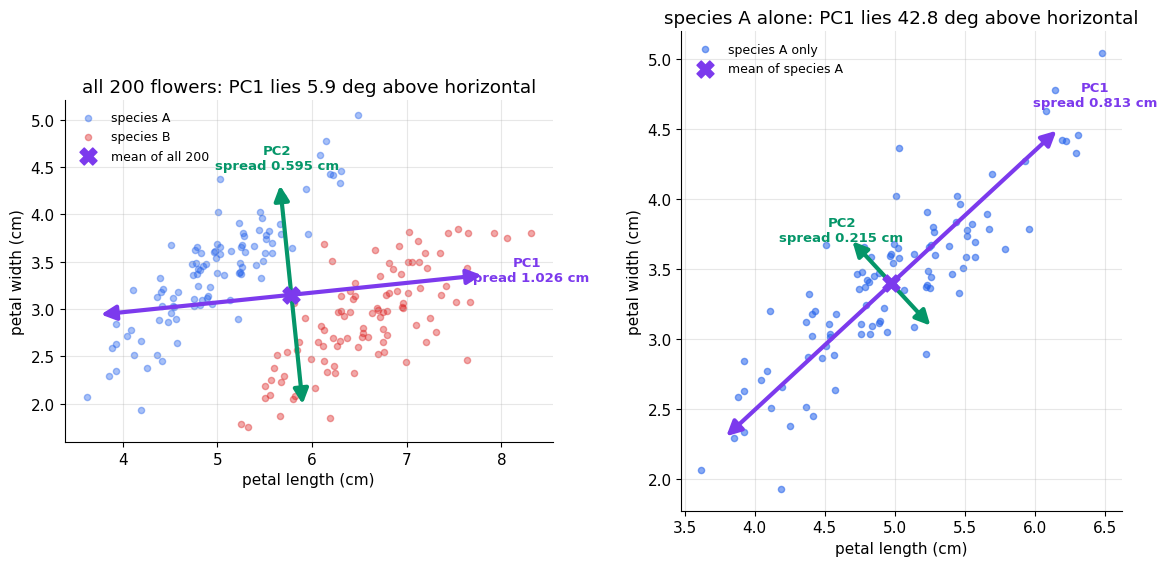

POOLED (all 200 flowers)
  PC1 [0.9947 0.1027]  spread sqrt(1.05249) = 1.0259 cm     5.90 deg above horizontal
  PC2 [-0.1027  0.9947]  spread sqrt(0.35435) = 0.5953 cm
  PC1 is 1.72x wider than PC2.
  correlation between the two measurements = 0.1160  (weak)

SPECIES A ALONE
  PC1 [0.734  0.6791]    42.78 deg above horizontal
  correlation between the two measurements = 0.8688  (strong -- THIS is the lean)
  angle between pooled PC1 and species-A PC1 = 36.88 degrees

BRUTE FORCE over 3601 directions, no eigenvectors used:
  widest direction found = [0.9947 0.1028]   variance 1.052494
  PC1 from eigh          = [0.9947 0.1027]   eigenvalue 1.052494
  angle between them     = 0.0044 degrees


In [78]:
# ============================================================
#  PCA STEP 4 -- INTERPRET. This is the picture Part 8 drew and
#  refused to explain. Arrows scaled by sqrt(eigenvalue), because
#  eigenvalues are variances and sqrt(variance) is a LENGTH.
# ============================================================
def pca_of(D):
    """The whole of steps 1-3, as a function, so we can point it at any data."""
    m  = D.mean(axis=0)
    Dc = D - m
    Cd = (Dc.T @ Dc) / (D.shape[0] - 1)
    w, V = np.linalg.eigh(Cd)
    o = np.argsort(w)[::-1]
    w, V = w[o], V[:, o]
    for k in range(V.shape[1]):                      # same sign convention
        if V[np.argmax(np.abs(V[:, k])), k] < 0:
            V[:, k] *= -1
    return m, w, V

def draw_axes(ax, m, w, V, cols, labels):
    for v, lam, col, lab in zip(V.T, w, cols, labels):
        L = 2.0 * np.sqrt(lam)                       # 2 standard deviations
        for s in (+1, -1):
            ax.annotate("", xy=m + s * L * v, xytext=m,
                        arrowprops=dict(arrowstyle="-|>", lw=3.0, color=col,
                                        mutation_scale=22))
        ax.text(*(m + L * v * 1.22), f"{lab}\nspread {np.sqrt(lam):.3f} cm",
                color=col, fontsize=9.5, ha="center", va="center", weight="bold")

XA = X[species == 0]                                 # species A on its own
muA, evalsA, evecsA = pca_of(XA)
pcA1 = evecsA[:, 0]

ang_pc1  = np.degrees(np.arctan2(pc1[1],  pc1[0]))
ang_pcA1 = np.degrees(np.arctan2(pcA1[1], pcA1[0]))

fig, (axL, axR) = plt.subplots(1, 2, figsize=(12.0, 5.8))

axL.scatter(*X[species == 0].T, s=20, c=C_F,     alpha=0.40, label="species A")
axL.scatter(*X[species == 1].T, s=20, c=C_SLOPE, alpha=0.40, label="species B")
axL.scatter(*mu, s=150, c=C_EXACT, marker="X", zorder=5, label="mean of all 200")
draw_axes(axL, mu, evals, evecs, [C_EXACT, C_AREA], ["PC1", "PC2"])
axL.set_title(f"all 200 flowers: PC1 lies {ang_pc1:.1f} deg above horizontal")

axR.scatter(*XA.T, s=20, c=C_F, alpha=0.55, label="species A only")
axR.scatter(*muA, s=150, c=C_EXACT, marker="X", zorder=5, label="mean of species A")
draw_axes(axR, muA, evalsA, evecsA, [C_EXACT, C_AREA], ["PC1", "PC2"])
axR.set_title(f"species A alone: PC1 lies {ang_pcA1:.1f} deg above horizontal")

for ax in (axL, axR):
    ax.set_xlabel(FEATURES[0]); ax.set_ylabel(FEATURES[1])
    ax.set_aspect("equal"); ax.legend(frameon=False, loc="upper left", fontsize=9)
fig.tight_layout(); plt.show()

print(f"POOLED (all 200 flowers)")
print(f"  PC1 {pc1.round(4)}  spread sqrt({lam1:.5f}) = {np.sqrt(lam1):.4f} cm"
      f"   {ang_pc1:6.2f} deg above horizontal")
print(f"  PC2 {pc2.round(4)}  spread sqrt({lam2:.5f}) = {np.sqrt(lam2):.4f} cm")
print(f"  PC1 is {np.sqrt(lam1) / np.sqrt(lam2):.2f}x wider than PC2.")
print(f"  correlation between the two measurements = "
      f"{C[0, 1] / np.sqrt(C[0, 0] * C[1, 1]):.4f}  (weak)")

print(f"\nSPECIES A ALONE")
print(f"  PC1 {pcA1.round(4)}   {ang_pcA1:6.2f} deg above horizontal")
CA = np.cov(XA, rowvar=False, ddof=1)
print(f"  correlation between the two measurements = "
      f"{CA[0, 1] / np.sqrt(CA[0, 0] * CA[1, 1]):.4f}  (strong -- THIS is the lean)")
print(f"  angle between pooled PC1 and species-A PC1 = "
      f"{np.degrees(np.arccos(np.clip(abs(pc1 @ pcA1), -1, 1))):.2f} degrees")

# Is PC1 really the widest direction? Brute-force it: try every angle.
angles = np.linspace(0, np.pi, 3601)
dirs   = np.column_stack([np.cos(angles), np.sin(angles)])
spread = np.var(Xc @ dirs.T, axis=0, ddof=1)         # variance along each direction
best   = dirs[np.argmax(spread)]
print(f"\nBRUTE FORCE over {len(angles)} directions, no eigenvectors used:")
print(f"  widest direction found = {best.round(4)}   variance {spread.max():.6f}")
print(f"  PC1 from eigh          = {pc1.round(4)}   eigenvalue {lam1:.6f}")
print(f"  angle between them     = "
      f"{np.degrees(np.arccos(min(1.0, abs(best @ pc1)))):.4f} degrees")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Two panels, each showing a cloud with a pair of arrows drawn from its mean (the purple X). Each arrow points both ways, because a direction has no preferred sign, and its length is two standard deviations — that is $2\sqrt{\lambda}$ — so it reaches roughly to where the cloud thins out along its own direction.

**This is the interpretation Part 8 withheld.** The eigenvectors of the covariance matrix are the axes of the data cloud, and the eigenvalue attached to each is the variance along it. Part 8 showed eigenvectors are the directions a matrix does not rotate; pointed at a covariance matrix, those directions turn out to be the frame the data would have chosen for itself. The printout is the honest version of that claim: a brute-force sweep over 3601 candidate directions, computing the variance along each with no eigenvector anywhere in the calculation, lands on the same direction as `eigh` to a small fraction of a degree.

**Now the surprise, which is the real lesson.** Look at the left panel. PC1 does **not** run along the diagonal lean you were shown in Part 0 — it lies within a few degrees of horizontal, almost exactly the petal-length axis. The right panel shows why: within a *single* species the two measurements really are strongly correlated and PC1 does run diagonally, at the angle printed above it. But pooled over both species, the largest source of spread is not that lean at all — it is the gap *between the two species*, which lies along petal length. PCA reports the widest direction it can find, and the between-group separation is wider than the within-group correlation. The printed correlation coefficients, weak for the pooled data and strong for species A alone, say the same thing in one number each.

**The common misread:** taking the arrows as lines you could have drawn by eye through the two coloured clumps. They are not a classifier and they know nothing about the colours — the labels were never handed to PCA, and it is a coincidence of *this* dataset that its answer happens to separate the species well. PCA maximises spread, full stop. When the structure you care about is not the widest direction, PCA will still confidently hand you the widest direction, and you will have to notice for yourself that it is the wrong question — which is exactly what the two panels here catch.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Where this trips people up

**An eigenvector's sign is arbitrary, so your plot can flip.**

If $\mathbf{C}\mathbf{v} = \lambda\mathbf{v}$ then $\mathbf{C}(-\mathbf{v}) = \lambda(-\mathbf{v})$ just as truly. Both are eigenvectors, both are unit length, and no rule of mathematics prefers one. `np.linalg.eigh`, `np.linalg.svd` and scikit-learn's `PCA` each make their own choice, and the choice can change between library versions or even between machines.

What this costs you in practice:

- Your PC1 arrow may point down-left where a colleague's points up-right, from the same data and the same code.
- Your projected scores may be the **negatives** of theirs, so a scatter of PC1 against PC2 can appear mirrored.
- Comparing your components to a reference by `np.allclose` will fail spuriously. Compare `abs(v_yours @ v_theirs)` to 1 instead — that is what the sklearn check later in this section does.

None of it changes the mathematics: the *line* PC1 spans is identical, the eigenvalue is identical, the explained variance is identical, and the reconstruction is identical, because flipping the sign of the direction also flips the sign of every score and the two cancel. If you need reproducible pictures, pick a convention and enforce it — for example, flip each component so its largest-magnitude entry is positive.

</div>

pc1 . pc1 = 1.0000000000  -> unit length, so the denominator is 1
scores.shape = (200,)  -- 200 flowers, ONE number each. 2D data, now 1D.
first five scores: [-1.7089 -0.942  -0.4414  0.5408 -0.6249]

flower 0 the long way: (Xc[0].pc1)/(pc1.pc1) = -1.708915
flower 0 from the batch:                       = -1.708915

EXPLAINED VARIANCE RATIO
  total variance in the data (trace of C) = 1.406841
  PC1: eigenvalue 1.052494  ->   74.81% of the total
  PC2: eigenvalue 0.354347  ->   25.19% of the total
  they sum to 1.0000000000

  Keeping only PC1 keeps 74.81% of the variance.
  Dropping PC2 throws away  25.19%.


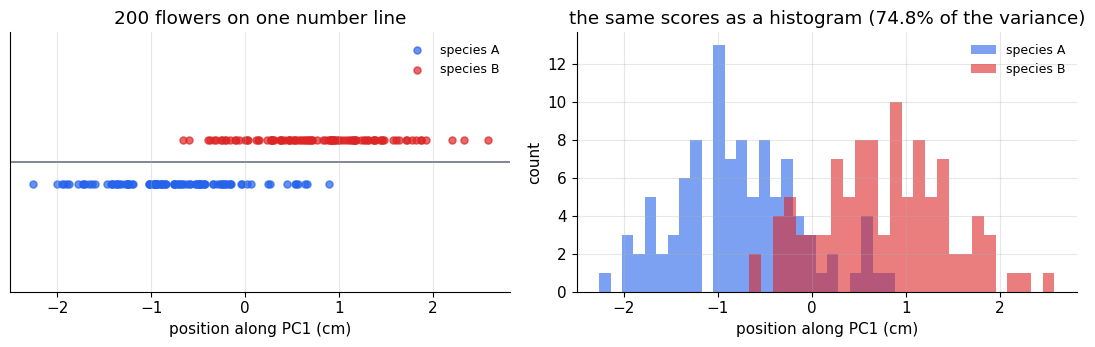

In [79]:
# ============================================================
#  PCA STEP 5 -- PROJECT onto PC1        (Part 3: projection)
#  PCA STEP 6 -- EXPLAINED VARIANCE RATIO
# ============================================================
# Part 3: the projection of xc onto v is  (xc . v)/(v . v) * v.
# Here |v| = 1, so v . v = 1 and the scalar is just the dot product.
print(f"pc1 . pc1 = {pc1 @ pc1:.10f}  -> unit length, so the denominator is 1")

scores = Xc @ pc1                 # one number per flower: position along PC1
print(f"scores.shape = {scores.shape}  -- 200 flowers, ONE number each. "
      f"2D data, now 1D.")
print(f"first five scores: {scores[:5].round(4)}")

# the same thing done the long way, for one flower, straight from Part 3:
i = 0
long_way = (Xc[i] @ pc1) / (pc1 @ pc1)
print(f"\nflower 0 the long way: (Xc[0].pc1)/(pc1.pc1) = {long_way:.6f}")
print(f"flower 0 from the batch:                       = {scores[i]:.6f}")

# --- explained variance ratio -----------------------------------------
EVR = evals / evals.sum()
print(f"\nEXPLAINED VARIANCE RATIO")
print(f"  total variance in the data (trace of C) = {evals.sum():.6f}")
for k in range(2):
    print(f"  PC{k+1}: eigenvalue {evals[k]:.6f}  ->  {EVR[k] * 100:6.2f}% of the total")
print(f"  they sum to {EVR.sum():.10f}")
print(f"\n  Keeping only PC1 keeps {EVR[0] * 100:.2f}% of the variance.")
print(f"  Dropping PC2 throws away  {EVR[1] * 100:.2f}%.")

fig, (axL, axR) = plt.subplots(1, 2, figsize=(11.0, 3.6))
for s, col, lab in [(0, C_F, "species A"), (1, C_SLOPE, "species B")]:
    m = species == s
    axL.scatter(scores[m], np.zeros(m.sum()) + (0.06 if s else -0.06),
                s=26, c=col, alpha=0.7, label=lab)
    axR.hist(scores[m], bins=26, color=col, alpha=0.6, label=lab)
axL.axhline(0, color=C_GREY, lw=1.2, zorder=0)
axL.set_yticks([]); axL.set_ylim(-0.35, 0.35)
axL.set_xlabel("position along PC1 (cm)")
axL.set_title("200 flowers on one number line")
axL.legend(frameon=False, fontsize=9)
axR.set_xlabel("position along PC1 (cm)"); axR.set_ylabel("count")
axR.set_title(f"the same scores as a histogram ({EVR[0] * 100:.1f}% of the variance)")
axR.legend(frameon=False, fontsize=9)
fig.tight_layout(); plt.show()


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

The left panel is the whole dataset after PCA has thrown a dimension away: every flower is now a single number, its position along PC1, and the two rows are nudged apart vertically only so the dots do not sit on top of each other. The right panel is the same numbers as a histogram.

This is what dimensionality reduction *is*. We began with 200 points on a plane and now have 200 points on a line, and the two species are still largely apart — which is the useful part, and is not something PCA was asked to arrange. It was told only to find the widest direction.

**The common misread:** reading the horizontal axis as "petal length". It is not either original measurement. It is distance along the diagonal direction PC1, measured from the mean, which is a **blend** of length and width in the proportions printed for `pc1` above. Its units are still centimetres — because PC1 is a unit vector, so the projection does not rescale anything — but its meaning is a new composite quantity, and it is negative for flowers on the far side of the mean.

</div>

<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Checked, not asserted

**Claimed:** the eigenvalue $\lambda_1$ *is* the variance of the data along PC1, so the explained-variance ratio means what it says.

That claim was never proved here, only asserted in the caption of the arrow figure. It is checkable directly, and the next cell does it: take the 200 projected scores — computed by dotting with PC1, an operation that never mentions eigenvalues — and compute their ordinary sample variance. If the interpretation is right, that number must come out equal to $\lambda_1$.

The same cell checks the projection itself two ways: the batched `Xc @ pc1` against Part 3's full projection formula $(\mathbf{x}_c\cdot\mathbf{v})/(\mathbf{v}\cdot\mathbf{v})$ written out for a single flower, printed above and agreeing to every decimal shown. And the ratios were printed summing to one, which they must, since their denominator is their own total.

</div>

IS THE EIGENVALUE THE VARIANCE ALONG THAT DIRECTION?
  var(scores along PC1, ddof=1) = 1.05249425
  eigenvalue lambda_1           = 1.05249425
  var(scores along PC2, ddof=1) = 0.35434703
  eigenvalue lambda_2           = 0.35434703
  covariance of the two score sets = -3.345e-17  (zero: PCA de-correlated the data)

RECONSTRUCTION from 1 dimension back to 2
  X_hat.shape = (200, 2)  (2D again, but every point lies on one line)
  mean distance from a flower to its reconstruction = 0.4834 cm
  RMSE (root mean squared distance)                 = 0.5938 cm
  worst single flower                               = 1.8130 cm

  The error is not arbitrary -- it is exactly the variance we dropped:
    sum of squared residuals / (n-1) = 0.35434703
    lambda_2                          = 0.35434703


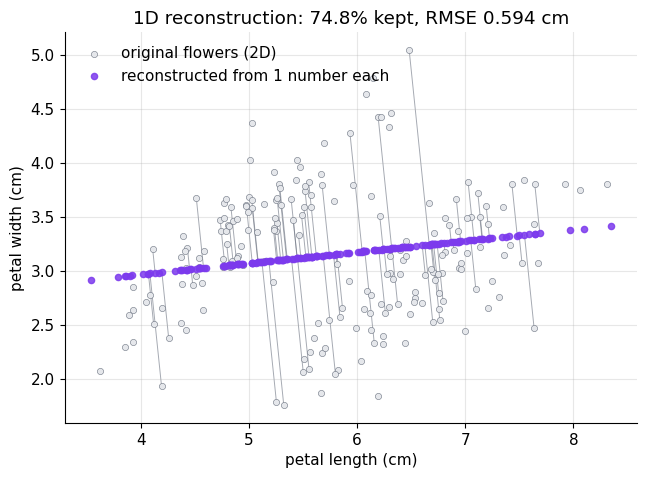

In [80]:
# ============================================================
#  PCA STEP 7 -- RECONSTRUCT from 1D, and measure what was lost
# ============================================================
# Does the eigenvalue really equal the variance of the scores?
scores2 = Xc @ pc2
print("IS THE EIGENVALUE THE VARIANCE ALONG THAT DIRECTION?")
print(f"  var(scores along PC1, ddof=1) = {np.var(scores,  ddof=1):.8f}")
print(f"  eigenvalue lambda_1           = {lam1:.8f}")
print(f"  var(scores along PC2, ddof=1) = {np.var(scores2, ddof=1):.8f}")
print(f"  eigenvalue lambda_2           = {lam2:.8f}")
print(f"  covariance of the two score sets = "
      f"{np.cov(scores, scores2, ddof=1)[0, 1]:.3e}  (zero: PCA de-correlated the data)")

# --- reconstruct: put each flower back at its point ON the PC1 line ---
Xc_hat = np.outer(scores, pc1)      # score * direction  (Part 3's projection vector)
X_hat  = Xc_hat + mu                # undo the centring (Part 4)

resid = X - X_hat
RMSE  = np.sqrt((resid ** 2).sum(axis=1).mean())
print(f"\nRECONSTRUCTION from 1 dimension back to 2")
print(f"  X_hat.shape = {X_hat.shape}  (2D again, but every point lies on one line)")
print(f"  mean distance from a flower to its reconstruction = "
      f"{np.linalg.norm(resid, axis=1).mean():.4f} cm")
print(f"  RMSE (root mean squared distance)                 = {RMSE:.4f} cm")
print(f"  worst single flower                               = "
      f"{np.linalg.norm(resid, axis=1).max():.4f} cm")

print(f"\n  The error is not arbitrary -- it is exactly the variance we dropped:")
print(f"    sum of squared residuals / (n-1) = {(resid ** 2).sum() / (n_obs - 1):.8f}")
print(f"    lambda_2                          = {lam2:.8f}")

fig, ax = plt.subplots(figsize=(6.6, 6.0))
for i in range(0, n_obs, 3):                       # every 3rd residual, for legibility
    ax.plot([X[i, 0], X_hat[i, 0]], [X[i, 1], X_hat[i, 1]],
            color=C_GREY, lw=0.7, alpha=0.6, zorder=1)
ax.scatter(*X.T,     s=20, c=C_SOFT,  edgecolors=C_GREY, linewidths=0.4,
           zorder=2, label="original flowers (2D)")
ax.scatter(*X_hat.T, s=20, c=C_EXACT, alpha=0.85, zorder=3,
           label="reconstructed from 1 number each")
ax.set_xlabel(FEATURES[0]); ax.set_ylabel(FEATURES[1])
ax.set_title(f"1D reconstruction: {EVR[0] * 100:.1f}% kept, RMSE {RMSE:.3f} cm")
ax.set_aspect("equal"); ax.legend(frameon=False, loc="upper left")
fig.tight_layout(); plt.show()


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Pale grey dots are the original flowers. Purple dots are what is left after squeezing each flower down to a single number and expanding it back out to two: every purple dot lies exactly on the PC1 line, because that line is the entire vocabulary the 1-D version has. The thin grey segments are the residuals — what was thrown away — and every one of them is **perpendicular to the line**, which is Part 3's projection: the closest point on a line is reached by dropping a perpendicular.

The whole of PCA is in this picture. Choosing PC1 as the line is *exactly* choosing the line that makes these grey segments as short as possible in total — maximising the spread you keep and minimising the error you make are the same problem, because the two add up to a fixed total (that is the trace identity checked in step 3).

**The common misread:** seeing the grey segments as *vertical* distances, the way residuals are drawn in ordinary least-squares regression. They are not. Least squares (Part 7) minimises error in one designated output variable and measures it vertically; PCA treats both measurements symmetrically and measures perpendicular to the line. Same data, different line — and the difference is not small when the measurements have comparable spread.

</div>

UNCENTRED 'PCA' -- eigenvectors of X^T X without subtracting the mean
  top direction, uncentred = [0.8809 0.4734]
  direction of the mean    = [0.8782 0.4784]
  the real PC1 (centred)   = [0.9947 0.1027]

  angle from the uncentred direction to THE MEAN :   0.32 degrees
  angle from the uncentred direction to REAL PC1 :  22.36 degrees

  It is pointing at the mean, not along the spread.


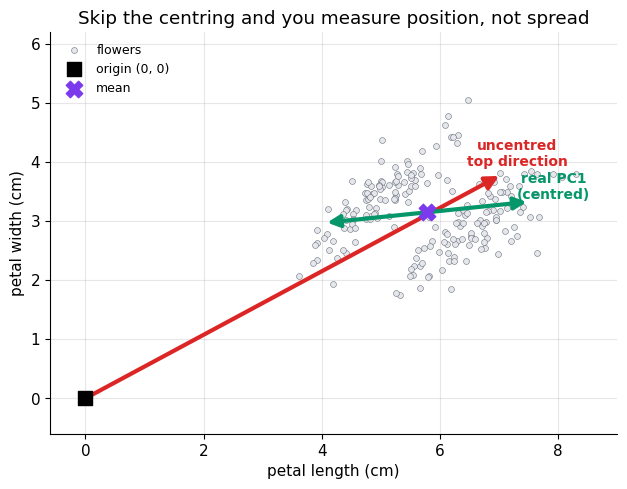

In [81]:
# ============================================================
#  THE MISTAKE EVERYONE MAKES: skipping the mean-centring.
#  If you eigen-decompose X^T X on RAW data, the top direction
#  points at the MEAN, not along the spread.
# ============================================================
C_raw = (X.T @ X) / (n_obs - 1)          # NOT centred -- deliberately wrong
ev_raw, V_raw = np.linalg.eigh(C_raw)
o = np.argsort(ev_raw)[::-1]
pc1_raw = V_raw[:, o[0]]
if pc1_raw @ mu < 0:                     # fix the arbitrary sign for the picture
    pc1_raw = -pc1_raw

mu_hat = mu / np.linalg.norm(mu)         # the direction of the mean, unit length
ang_to_mean = np.degrees(np.arccos(np.clip(abs(pc1_raw @ mu_hat), -1, 1)))
ang_to_pc1  = np.degrees(np.arccos(np.clip(abs(pc1_raw @ pc1),    -1, 1)))

print("UNCENTRED 'PCA' -- eigenvectors of X^T X without subtracting the mean")
print(f"  top direction, uncentred = {pc1_raw.round(4)}")
print(f"  direction of the mean    = {mu_hat.round(4)}")
print(f"  the real PC1 (centred)   = {pc1.round(4)}")
print(f"\n  angle from the uncentred direction to THE MEAN : {ang_to_mean:6.2f} degrees")
print(f"  angle from the uncentred direction to REAL PC1 : {ang_to_pc1:6.2f} degrees")
print(f"\n  It is pointing at the mean, not along the spread.")

fig, ax = plt.subplots(figsize=(6.4, 6.0))
ax.scatter(*X.T, s=18, c=C_SOFT, edgecolors=C_GREY, linewidths=0.4, label="flowers")
ax.scatter(0, 0, s=90, c="black", marker="s", zorder=5, label="origin (0, 0)")
ax.scatter(*mu, s=140, c=C_EXACT, marker="X", zorder=5, label="mean")
ax.annotate("", xy=8.0 * pc1_raw, xytext=(0, 0),
            arrowprops=dict(arrowstyle="-|>", lw=3, color=C_SLOPE, mutation_scale=20))
ax.text(*(8.3 * pc1_raw), "uncentred\ntop direction", color=C_SLOPE,
        fontsize=10, weight="bold", ha="center")
ax.annotate("", xy=mu + 1.7 * np.sqrt(lam1) * pc1, xytext=mu - 1.7 * np.sqrt(lam1) * pc1,
            arrowprops=dict(arrowstyle="<|-|>", lw=3, color=C_AREA, mutation_scale=18))
ax.text(*(mu + 2.1 * np.sqrt(lam1) * pc1), "real PC1\n(centred)", color=C_AREA,
        fontsize=10, weight="bold", ha="center")
ax.set_xlim(-0.6, 9.0); ax.set_ylim(-0.6, 6.2)
ax.set_xlabel(FEATURES[0]); ax.set_ylabel(FEATURES[1])
ax.set_title("Skip the centring and you measure position, not spread")
ax.set_aspect("equal"); ax.legend(frameon=False, loc="upper left", fontsize=9)
fig.tight_layout(); plt.show()


<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Where this trips people up

**Forgetting to mean-centre is the classic PCA bug, and it fails quietly.** The code runs, the eigenvalues look plausible, the components are unit length and perpendicular. Nothing complains. The answer is simply wrong.

The figure shows why. Without centring you are decomposing $\mathbf{X}^{\mathsf{T}}\mathbf{X}$, which measures how far the points are **from the origin**, not from each other. Our flowers sit around 5 cm by 3 cm, so their distance from `(0, 0)` utterly dominates their spread of a few tenths of a centimetre — and the top direction comes out pointing at the mean, as the printed angles show: a couple of degrees off the mean direction and tens of degrees away from the real PC1.

This is not a numerical nicety. Covariance is *defined* with the mean subtracted, and $\frac{1}{n-1}\mathbf{X}_c^{\mathsf{T}}\mathbf{X}_c$ is only a covariance matrix when the `c` is there. Skip it and you have decomposed a different matrix that answers a different question.

**Three habits that prevent it.** Print `Xc.mean(axis=0)` and confirm it is zero to machine precision, as step 1 does. Remember that `sklearn.decomposition.PCA` centres for you, which is exactly why hand-rolled PCA disagrees with it for people who forget. And note that centring is not the same as **scaling**: if your columns are in wildly different units (grams and kilometres), you usually want to divide each by its standard deviation too, or PCA will simply report whichever column has the biggest units.

</div>

In [82]:
# ============================================================
#  VERIFY THE WHOLE THING against machinery we did not write.
#  SVD always (it is fast and always available); sklearn too if
#  it imports -- guarded, because importing it is slow and it may
#  not be installed. A failure here must not break the notebook.
# ============================================================
# --- independent route 1: the SVD of the centred data -----------------
U, S, Vt = np.linalg.svd(Xc, full_matrices=False)
svd_evals = S ** 2 / (n_obs - 1)
svd_pc1   = Vt[0]
print("CHECK 1 -- np.linalg.svd on the centred data (no covariance matrix built)")
print(f"  eigenvalues from eigh : {evals.round(8)}")
print(f"  s^2/(n-1) from svd    : {svd_evals.round(8)}")
print(f"  max difference        : {np.abs(evals - svd_evals).max():.3e}")
print(f"  |PC1_eigh . PC1_svd|  : {abs(pc1 @ svd_pc1):.10f}   (1 = same line;"
      f" sign is arbitrary)")

# --- independent route 2: scikit-learn, if it is here -----------------
print("\nCHECK 2 -- scikit-learn's PCA")
try:
    from sklearn.decomposition import PCA as SKPCA
    sk = SKPCA(n_components=2).fit(X)                # sklearn centres internally
    print(f"  sklearn explained_variance_       : {sk.explained_variance_.round(8)}")
    print(f"  ours (eigenvalues)                : {evals.round(8)}")
    print(f"  sklearn explained_variance_ratio_ : {sk.explained_variance_ratio_.round(8)}")
    print(f"  ours (EVR)                        : {EVR.round(8)}")
    print(f"  |PC1_ours . PC1_sklearn|          : {abs(pc1 @ sk.components_[0]):.10f}")
    sk_scores = sk.transform(X)[:, 0]
    print(f"  scores agree (up to sign)         : "
          f"{np.allclose(np.abs(sk_scores), np.abs(scores))}")
    print(f"  largest score disagreement        : "
          f"{np.abs(np.abs(sk_scores) - np.abs(scores)).max():.3e}")
    SKLEARN_OK = True
except Exception as e:
    SKLEARN_OK = False
    print(f"  scikit-learn is not usable here ({type(e).__name__}: {e}).")
    print(f"  SKIPPED -- the SVD check above is independent of our eigh route")
    print(f"  and already confirms the result, so nothing is left unverified.")

print(f"\nsklearn cross-check performed: {SKLEARN_OK}")
print(f"\nFINAL PCA SUMMARY")
print(f"  PC1                        = {pc1.round(4)}")
print(f"  explained variance ratio   = {EVR[0] * 100:.2f}% (PC1), {EVR[1] * 100:.2f}% (PC2)")
print(f"  reconstruction RMSE from 1D = {RMSE:.4f} cm")


CHECK 1 -- np.linalg.svd on the centred data (no covariance matrix built)
  eigenvalues from eigh : [1.05249425 0.35434703]
  s^2/(n-1) from svd    : [1.05249425 0.35434703]
  max difference        : 6.661e-16
  |PC1_eigh . PC1_svd|  : 1.0000000000   (1 = same line; sign is arbitrary)

CHECK 2 -- scikit-learn's PCA
  sklearn explained_variance_       : [1.05249425 0.35434703]
  ours (eigenvalues)                : [1.05249425 0.35434703]
  sklearn explained_variance_ratio_ : [0.74812579 0.25187421]
  ours (EVR)                        : [0.74812579 0.25187421]
  |PC1_ours . PC1_sklearn|          : 1.0000000000
  scores agree (up to sign)         : True
  largest score disagreement        : 5.440e-15

sklearn cross-check performed: True

FINAL PCA SUMMARY
  PC1                        = [0.9947 0.1027]
  explained variance ratio   = 74.81% (PC1), 25.19% (PC2)
  reconstruction RMSE from 1D = 0.5938 cm


<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Checked, not asserted

**The capstone result, verified twice by machinery we did not write.**

**Route 1, the SVD.** `np.linalg.svd(Xc)` never forms a covariance matrix at all — it factors the centred data directly. Yet its squared singular values divided by $n-1$ reproduce our eigenvalues, and its top right singular vector spans the same line as our PC1 (the dot product of the two unit vectors has magnitude 1). That is a genuinely different computational path arriving at the same answer, and it is the route production code actually takes, because squaring the data to build $\mathbf{C}$ also squares its condition number — Part 7's warning about ill-conditioned systems, showing up in a new place.

**Route 2, scikit-learn.** Guarded in a `try`, because importing it is slow and it may be absent; the printed flag says whether it ran. Where it ran, its `explained_variance_`, its `explained_variance_ratio_`, its components and its transformed scores all match ours — the components and scores *up to sign*, for the reason given in the eigenvector-sign gotcha above.

Every number quoted in this section — the ratio, the RMSE, the eigenvalues — was printed by a cell, and each has now been confirmed by an independent method.

</div>

---

### 9.3 Where all of it turns up

Every idea in this notebook, and the place it does real work in machine
learning. Nothing in this table is a stretch — each row is the same operation
you implemented, under a different name.

| Linear algebra idea | Built in | Where it does the work in ML |
|---|---|---|
| Vector | Part 1 | One example; one row of your data; one word embedding; one image flattened |
| Vector addition, scaling | Part 2 | The gradient descent update $\mathbf{w} \leftarrow \mathbf{w} - \eta\,\mathbf{g}$ — a scaled vector added to a vector |
| Norm $\|\mathbf{v}\|$ | Part 2 | Loss values, L2 regularisation, gradient clipping, distance in k-nearest-neighbours |
| Dot product | Part 3 | The single most-executed operation in deep learning: one neuron's response, one attention score, cosine similarity in retrieval |
| Projection | Part 3 | PCA (§9.2), orthogonal decomposition, the residual in least squares |
| Data matrix $\mathbf{X}$ | Part 4 | Your dataset, or one mini-batch of it: rows are examples, columns are features |
| Transpose | Part 4 | Batched layers (`X @ W.T`), and the backward pass — backpropagation through a linear layer *is* a multiplication by $\mathbf{W}^{\mathsf{T}}$ |
| Matrix multiplication | Part 5 | One layer applied to a whole batch; the bulk of what a GPU spends its time on |
| Matrix as transformation | Part 6 | What a weight matrix *does*: rotate, stretch, project the representation into a new space |
| Determinant | Part 6 | Volume change — the change-of-variables term in normalising flows and in the multivariate Gaussian |
| Linear system, inverse | Part 7 | Closed-form ridge regression; Gaussian processes; Newton-type optimisers |
| Rank, singularity | Part 7 | Redundant features, collinearity, and why low-rank adapters (LoRA) can fine-tune a huge model with few parameters |
| Least squares | Part 7 | Linear regression, and the loss surface every regressor descends |
| Eigenvector, eigenvalue | Part 8 | PCA; spectral clustering; the curvature of a loss surface (the Hessian's eigenvalues set the largest safe learning rate) |
| Covariance matrix | §9.2 | Whitening, Mahalanobis distance, the multivariate Gaussian, Gaussian mixture models |
| $\mathbf{y} = \mathbf{W}\mathbf{x} + \mathbf{b}$ | §9.1 | Every dense layer of every neural network, without exception |

---

## ✅ Part 0 promised you eight things

Each was delivered by a part, and you did the work.

| # | The promise | Delivered |
|---|---|---|
| 1 | **Say what a vector is** — three ways, and know when each picture helps | ✅ Part 1 — the arrow, the list, the point, and one flower as all three |
| 2 | **Add and scale vectors, compute a length**, from the definition | ✅ Part 2 — and you used the length again in §9.2, where $\sqrt{\lambda}$ set the arrow lengths |
| 3 | **Explain the dot product** geometrically and algebraically, and why it measures similarity | ✅ Part 3 — then used three times per neuron in §9.1 |
| 4 | **Read a matrix as a transformation** and predict what it does before running it | ✅ Part 6 — and §9.1's collapse of two layers into one is that reading, applied |
| 5 | **Derive matrix multiplication** from the dot product, and say why it is not commutative | ✅ Part 5 — and §9.1 batched 200 flowers with it in one operation |
| 6 | **Solve a linear system, invert a matrix, recognise when you cannot** | ✅ Part 7 — and §9.2's warning about $\mathbf{X}^{\mathsf{T}}\mathbf{X}$ conditioning is that lesson recurring |
| 7 | **Explain eigenvectors** as the directions a transformation leaves pointing the same way | ✅ Part 8 — and §9.2 finally said what Part 8's two arrows meant |
| 8 | **Read `y = Wx + b` as a sentence, and implement PCA yourself** | ✅ §9.1 and §9.2 — both by hand, both checked against independent machinery |

That is the whole list. A matrix is a verb, and you can now say what it does.


---

## 🏋️ Exercises

No solutions. Every one of them is a small edit to a cell above, and the
checks in this notebook are the pattern for confirming you got it right —
compute the answer a second, independent way and compare.

**1. A wider layer.** Change `W1` in §9.1 to map the 2 measurements to 5
outputs instead of 3. Predict the shape of `W1`, of `H`, and of `OUT` *before*
running, and write your predictions down. Then run it. If you were wrong, the
error message will tell you which pair of inner dimensions failed to meet.
*Scaffold:* `W1 = RNG.normal(size=(?, ?))`, `b1 = np.zeros(?)`.

**2. Make the collapse visible.** In the composition cell, stack **four**
linear layers of shapes 2→8→8→8→2 with random weights, then multiply the four
matrices together into a single 2 × 2 `W_eq`. Check the four-step and one-step
outputs agree. Then insert a ReLU after each of the first three and confirm
they stop agreeing. *Scaffold:* build the weights in a list and use a `for`
loop with `H = H @ W.T + b`.

**3. Where does the speedup go?** Re-run the batching timing with `X` replaced
by a 20-row slice, then a 200-row copy, then a 20 000-row copy
(`np.tile(X, (100, 1))`). Plot the speedup against the number of rows. Does
the advantage grow, shrink, or level off — and can you say why from what the
loop and the `@` each have to do?

**4. Standardise before PCA.** Multiply the *second* column of `X` by 100
(pretend it was recorded in a different unit) and re-run §9.2. What happens to
PC1 and to the explained variance ratio? Now divide each column by its
standard deviation first and re-run again. *Scaffold:*
`Z = (X - X.mean(0)) / X.std(0, ddof=1)`. Which of the two answers is the one
you actually want, and what does that tell you about when to standardise?

**5. Prove the trade-off is exact.** §9.2 asserted that the variance you keep
and the error you make add up to a constant. Verify it: for a grid of angles
$\theta$, project the centred data onto $(\cos\theta, \sin\theta)$, and for
each angle compute both the variance of the scores and the mean squared
perpendicular residual. Plot the two curves on one axis and confirm their sum
is flat, and that the maximum of the first coincides with the minimum of the
second — at PC1.

**6. PCA on something with more than two dimensions.** Build a 200 × 5 matrix
whose columns are: petal length, petal width, their sum, their difference, and
a column of pure noise. Run your PCA on it. How many eigenvalues are
effectively zero, and why *must* that be so? *Scaffold:* compare
`np.linalg.matrix_rank` of the centred matrix to the number of non-negligible
eigenvalues — this is Part 7's rank, seen from the other side.

---

## 📚 References

**Books**

- Gilbert Strang, *Introduction to Linear Algebra*, 6th ed. — the standard, and
  the one to own. Chapters 1–7 cover everything in this notebook.
- Marc Peter Deisenroth, A. Aldo Faisal & Cheng Soon Ong,
  *Mathematics for Machine Learning* (Cambridge, 2020) — free at
  <https://mml-book.github.io>. Chapters 2–4 are linear algebra written for
  exactly this purpose; Chapter 10 is PCA at more depth than §9.2.
- Kevin Murphy, *Probabilistic Machine Learning: An Introduction* (MIT, 2022) —
  Chapter 7 is the linear algebra a working ML practitioner needs.

**Watch**

- 3Blue1Brown, *Essence of Linear Algebra* — 15 short videos. If any part of
  this notebook stayed abstract, watch these; they are the best visual
  treatment of matrices-as-transformations that exists.
- Gilbert Strang's MIT 18.06 lectures, free on MIT OpenCourseWare.

**On PCA specifically**

- Jonathon Shlens, *A Tutorial on Principal Component Analysis*,
  arXiv:1404.1100 — derives PCA twice, once from variance and once from the
  SVD, and is the clearest short treatment available.
- Karl Pearson (1901), *On lines and planes of closest fit to systems of points
  in space* — the original, and it is the perpendicular-residual view of the
  reconstruction figure in §9.2.
- Harold Hotelling (1933), *Analysis of a complex of statistical variables into
  principal components* — the variance-maximising view. The two papers found
  the same method from opposite ends, which is why the trade-off in Exercise 5
  is exact.

**Documentation**

- NumPy linear algebra: <https://numpy.org/doc/stable/reference/routines.linalg.html>
- `np.linalg.eigh` (symmetric matrices — the right function for covariance) and
  `np.linalg.svd` (what production PCA actually uses).
- scikit-learn `decomposition.PCA`:
  <https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html>

---

## 🗺️ The Ten Parts

This is a **refresher that assumes you have forgotten everything**. Part 1 starts at what a function is. Nothing later depends on anything we did not build earlier, and every rule is derived before it is used.

| Part | What it covers | |
|---|---|---|
| **0** | Why vectors and matrices, and the dataset we use |
| **1** | Vectors: arrows, lists, and what they mean |
| **2** | Vector arithmetic: adding, scaling, and length |
| **3** | The dot product: the one operation that matters most |
| **4** | Matrices: tables of numbers that DO something |
| **5** | Matrix multiplication, built from the dot product |
| **6** | Transformations: what a matrix does to space |
| **7** | Systems, inverses, and when they fail |
| **8** | Eigenvectors, and the directions that survive |
| **9** | Linear algebra doing ML: a layer, PCA, and a capstone |  &larr; **you are here**

Parts 1-3 are the ideas. Parts 4-5 make derivatives usable. Parts 6-7 do the same for integrals and then show the two are one idea. Parts 8-9 are where it becomes machine learning.


---

<div style="background: linear-gradient(135deg, #0F4C81 0%, #7C3AED 100%); padding: 28px; border-radius: 18px; color: white; margin: 12px 0;">


### That is the whole of it.

You started at "a vector is a list of numbers" and finished by implementing PCA from scratch and checking it against scikit-learn.

Along the way you never took a rule on faith. Matrix multiplication was **derived** from the dot product rather than memorised. The determinant was **watched** scaling an area. Eigenvectors were **found** as the directions that survive a transformation, and then, in this part, recognised as the axes a dataset would choose for itself. Every result in the notebook was checked a second way, and where a check could have failed, it was shown failing.

So the sentence from the very first cell has been earned: **a matrix is not a table of numbers, it is a verb.** `W` in `y = Wx + b` is doing something to your data — you can now say what, predict it before running the code, and read the shape of the answer off the shapes of the inputs.

The next thing to learn is calculus, because that is what tells `W` how to change. But the linear algebra is done.

**Well done.**


</div>